# ⚡ NVIDIA RAPIDS: From Zero to Hero
## GPU Data Science on a Free Colab T4 — cuDF, cuML, cuGraph, XGBoost — A Progressive, Beginner-Friendly Masterclass

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dlmastery/class/blob/main/colabs/06_data_eval_mlops/nvidia_rapids_zero_to_hero.ipynb)
![Python](https://img.shields.io/badge/Python-3.11%2B-blue)
![NVIDIA RAPIDS](https://img.shields.io/badge/RAPIDS-26.x-76b900)

---

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 30px; border-radius: 20px; color: white; text-align: center; margin: 10px 0;">

### Welcome

One running example, a **household budget** dataset, carried through every part: can we predict which households will **overspend next month**, how much they will **spend**, and what their **monthly spending series** looks like ahead? Every part adds one capability of NVIDIA RAPIDS and one habit of a careful data scientist.

</div>

## 🎯 Learning Objectives

1. **Explain why GPUs change data science: thousands of cores, memory bandwidth, and the columnar layout cuDF shares with Arrow.**
2. **Set up a free **Colab T4**, install RAPIDS, and verify the GPU with a benchmark you can read.**
3. **Use **cuDF** as a drop-in for pandas (and `cudf.pandas` for zero-code-change acceleration) on a budget dataset, and measure the speed-up honestly.**
4. **Train **cuML** classifiers and regressors with the scikit-learn API (and `cuml.accel`), with the full metric families.**
5. **Run clustering, dimensionality reduction (UMAP, PCA, t-SNE) and nearest neighbours on the GPU, and visualize the results.**
6. **Use **XGBoost on the GPU** with GPU SHAP, and **cuGraph** for a household-merchant network.**
7. **Manage GPU memory, know when data is too small for a GPU, and scale to millions of rows without leaving Colab.**
8. **Ship it: save GPU models, serve them on CPU or GPU, and know the 2026 GPU data-science landscape.**

## 📚 Table of Contents

| Part | Tasks | Topics | Difficulty |
|:----:|:-----:|--------|:----------:|
| 1 | 1-2 | Why GPUs; the T4; installing RAPIDS; a first benchmark | ⭐ |
| 2 | 3-5 | cuDF: pandas on the GPU; cudf.pandas; the budget data, analysed at speed | ⭐ |
| 3 | 6-7 | Data analysis and visualization from GPU frames | ⭐⭐ |
| 4 | 8-10 | cuML classification: the sklearn API on the GPU; all the metrics | ⭐⭐ |
| 5 | 11-12 | cuML regression and preprocessing pipelines | ⭐⭐ |
| 6 | 13-15 | Unsupervised on the GPU: k-means, DBSCAN, PCA, UMAP, t-SNE | ⭐⭐ |
| 7 | 16-17 | Model selection at speed: cross-validation and search with cuml.accel | ⭐⭐⭐ |
| 8 | 18-19 | Scaling up: millions of rows, memory management, Dask-cuDF | ⭐⭐⭐ |
| 9 | 20-21 | XGBoost on the GPU and GPU SHAP; cuGraph on a spending network | ⭐⭐⭐ |
| 10 | 22-23 | MLOps: saving, serving, CPU fallbacks, monitoring; error analysis | ⭐⭐⭐ |
| 11 | 24-25 | SOTA 2026: RAPIDS 26.x, cuml.accel, cuVS, and where CPUs still win | 🔬 |

## 🗺️ How to read

Every concept follows one loop: **🧠 Intuition → 📐 The Math (gently) → 💻 Code → 📊 Picture → ✅ Takeaway**. Read the intuition first, run the code second, and check the takeaway against what you saw. Callouts mark ⚠️ warnings, 🔑 new variables, and 🏆 best practices.

## ⏱️ Estimated Time

2 to 2.5 hours (a few minutes of GPU time on a Colab T4). Each part is self-contained after Part 2, so you can stop and resume.


# Part 0 · Setup and the Data ⭐

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 One dataset for the whole course

Real projects rarely start with a clean CSV. They start with an export like the one below: one row per **household-month**, with income, category spends, a free-text note, a survey score nobody trusts, a referral code that is often missing, and a few surprise expenses. The generator plants real structure (seasonality, city tiers, an interaction between dining and entertainment, missing values) so that every technique in this course has something honest to find.

Two tables are built from it:

- **`hh`**, one row per household: this month's features, **next month's** outcomes as targets. `overspent_next` (classification) and `spend_next` (regression).
- **`ts`**, the monthly spending series of every household, for forecasting.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Why next month

Predicting *this* month's total from *this* month's categories is a leak: the total is their sum, and any model scores a perfect R². Predicting **next** month from what you know now is the real question. Part 4 shows the leak on purpose.

</div>


In [1]:
# !pip install -q cudf-cu12 cuml-cu12 cugraph-cu12 --extra-index-url=https://pypi.nvidia.com   # RAPIDS for CUDA 12; ~4 min on Colab T4. Runtime > Change runtime type > T4 GPU first.
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, subprocess, shutil
from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8-whitegrid"); sns.set_palette("husl")
RANDOM_STATE = 42; np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 160)

# ---- GPU detection: every cell in this notebook runs on the GPU when there is one and on the CPU when there is not.
def gpu_info():
    # Return (name, memory_mib) from nvidia-smi, or (None, 0) without a GPU.
    if shutil.which("nvidia-smi") is None:
        return None, 0
    try:
        out = subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader,nounits"],
                             capture_output=True, text=True, timeout=10).stdout.strip().splitlines()[0]
        name, mem = [x.strip() for x in out.split(",")]
        return name, int(mem)
    except Exception:  # noqa: BLE001 - no driver, no GPU
        return None, 0

GPU_NAME, GPU_MEM = gpu_info()
try:
    import cudf, cuml
    GPU = GPU_NAME is not None
except Exception:  # noqa: BLE001 - RAPIDS not installed: the notebook still runs, on pandas and scikit-learn
    cudf = cuml = None
    GPU = False
print(f"GPU: {GPU_NAME or 'none'} ({GPU_MEM} MiB) | RAPIDS available: {GPU}")

# ------------------------------------------------------------------ the household budget dataset
CITY_TIERS = ["metro", "city", "town"]
NOTES = [
    "quiet month, cooked at home",
    "hosted family for a week",
    "car repair and a new phone",
    "holiday travel with the kids",
    "cut the streaming subscriptions",
    "medical bills came in",
    "birthday party and gifts",
    "worked overtime, ate out a lot",
]


def make_budget(n_households: int = 1500, months: int = 24, seed: int = 42) -> pd.DataFrame:
    # One row per household-month with income, category spends, a note and two targets.
    rng = np.random.default_rng(seed)
    hh = pd.DataFrame({
        "household_id": np.arange(n_households),
        "city_tier": rng.choice(CITY_TIERS, n_households, p=[0.35, 0.4, 0.25]),
        "household_size": rng.integers(1, 6, n_households),
        "owns_car": rng.random(n_households) < 0.55,
        "base_income": rng.lognormal(mean=8.4, sigma=0.35, size=n_households).round(-1),
    })
    tier_rent = {"metro": 0.34, "city": 0.27, "town": 0.20}
    rows = []
    for m in range(months):
        month = pd.Timestamp("2024-01-01") + pd.DateOffset(months=m)
        season = 1.0 + 0.12 * np.sin(2 * np.pi * (m % 12) / 12 - 1.2) + (0.18 if m % 12 == 11 else 0.0)
        income = hh.base_income * (1 + 0.004 * m) * rng.normal(1.0, 0.03, n_households)
        rent = income * hh.city_tier.map(tier_rent).values * rng.normal(1.0, 0.05, n_households)
        groceries = (180 + 95 * hh.household_size) * season * rng.normal(1.0, 0.12, n_households)
        utilities = (60 + 25 * hh.household_size) * (1.25 if month.month in (1, 2, 7, 8) else 1.0) * rng.normal(1.0, 0.1, n_households)
        transport = np.where(hh.owns_car, 210, 90) * season * rng.normal(1.0, 0.15, n_households)
        dining = np.clip(rng.gamma(2.0, 70, n_households) * season, 0, None)
        entertainment = np.clip(rng.gamma(1.8, 60, n_households) * season + 0.35 * dining, 0, None)
        surprise = rng.random(n_households) < 0.06
        other = np.where(surprise, rng.uniform(300, 1200, n_households), rng.gamma(1.5, 40, n_households))
        total = rent + groceries + utilities + transport + dining + entertainment + other
        note = rng.choice(NOTES, n_households)
        note = np.where(surprise, rng.choice(NOTES[2:4] + NOTES[5:6], n_households), note)
        rows.append(pd.DataFrame({
            "household_id": hh.household_id,
            "month": month,
            "city_tier": hh.city_tier,
            "household_size": hh.household_size,
            "owns_car": hh.owns_car,
            "income": income.round(0),
            "rent": rent.round(0),
            "groceries": groceries.round(0),
            "utilities": utilities.round(0),
            "transport": transport.round(0),
            "dining": dining.round(0),
            "entertainment": entertainment.round(0),
            "other": other.round(0),
            "note": note,
            "total_spend": total.round(0),
        }))
    budget = pd.concat(rows, ignore_index=True)
    budget["overspent"] = (budget.total_spend > 0.65 * budget.income).astype(int)  # about 20% of household-months
    # two noise columns and a little missingness, as real exports have
    budget["survey_score"] = rng.integers(1, 6, len(budget))
    budget["referral_code"] = rng.choice(["A1", "B2", "C3", None], len(budget), p=[0.3, 0.3, 0.3, 0.1])
    mask = rng.random(len(budget)) < 0.04
    budget.loc[mask, "dining"] = np.nan
    return budget


def household_table(budget: pd.DataFrame) -> pd.DataFrame:
    # One row per household: this month's features, NEXT month's outcomes as the targets.
    # Features come from the second-to-last month (spends, income, a note) plus
    # history aggregates over all earlier months. Targets come from the last month:
    # `spend_next` (regression) and `overspent_next` (classification). Predicting
    # this month's total from this month's categories would be a leak (the total
    # is their sum); the notebooks use that as a teaching trap.
    months = sorted(budget.month.unique())
    feat_month, target_month = months[-2], months[-1]
    feats = budget[budget.month == feat_month].drop(columns=["month"]).copy()
    hist = budget[budget.month < feat_month].groupby("household_id").agg(
        avg_spend_prev=("total_spend", "mean"),
        overspend_rate_prev=("overspent", "mean"),
        max_dining_prev=("dining", "max"),
    )
    targets = budget[budget.month == target_month][["household_id", "total_spend", "overspent"]].rename(
        columns={"total_spend": "spend_next", "overspent": "overspent_next"})
    table = feats.merge(hist, on="household_id", how="left").merge(targets, on="household_id")
    return table.reset_index(drop=True)


def monthly_series(budget: pd.DataFrame) -> pd.DataFrame:
    # Long format for time-series libraries: item_id, timestamp, target.
    ts = budget[["household_id", "month", "total_spend"]].rename(
        columns={"household_id": "item_id", "month": "timestamp", "total_spend": "target"})
    return ts.sort_values(["item_id", "timestamp"]).reset_index(drop=True)

budget = make_budget(n_households=1500, months=24, seed=RANDOM_STATE)   # one row per household-month
hh = household_table(budget)                                            # one row per household
ts = monthly_series(budget)                                             # item_id, timestamp, target

LABEL_CLS, LABEL_REG = "overspent_next", "spend_next"
ID_COL = "household_id"
FEATURES = [c for c in hh.columns if c not in (ID_COL, LABEL_CLS, LABEL_REG)]
train_df, test_df = train_test_split(hh, test_size=0.25, random_state=RANDOM_STATE, stratify=hh[LABEL_CLS])
train_df, test_df = train_df.reset_index(drop=True), test_df.reset_index(drop=True)

print(f"budget: {budget.shape[0]:,} household-months  |  hh: {hh.shape[0]:,} households x {len(FEATURES)} features  |  ts: {ts.item_id.nunique():,} series x {ts.groupby('item_id').size().iloc[0]} months")
print(f"train {len(train_df):,} / test {len(test_df):,}  |  positive rate ({LABEL_CLS}): train {train_df[LABEL_CLS].mean():.1%}, test {test_df[LABEL_CLS].mean():.1%}")
print("All libraries imported successfully!")


GPU: none (0 MiB) | RAPIDS available: False
budget: 36,000 household-months  |  hh: 1,500 households x 19 features  |  ts: 1,500 series x 24 months
train 1,125 / test 375  |  positive rate (overspent_next): train 16.8%, test 16.8%
All libraries imported successfully!


## 0.1 Two helpers you will see everywhere

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: one report card for every model

Metrics are only comparable when they are computed the same way on the same split. `report_card` computes the full family for a classifier (threshold, ranking, probabilistic) or a regressor (scale, relative, robust) and returns a tidy one-row table, so every part of this course reports models the same way. `pretty` styles any DataFrame for reading, and `timer` measures wall time so speed claims are numbers, not adjectives.

</div>


In [2]:
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, log_loss, brier_score_loss, matthews_corrcoef,
                             mean_absolute_error, mean_squared_error, r2_score, median_absolute_error)
import time as _time
from contextlib import contextmanager

def report_card(y_true, y_pred=None, y_prob=None, name="model", task="classification"):
    # One tidy row of metrics. Classification needs y_pred (labels) and, ideally, y_prob (P(class 1)).
    y_true = np.asarray(y_true)
    if task == "classification":
        y_pred = np.asarray(y_pred)
        row = {"model": name,
               "accuracy": accuracy_score(y_true, y_pred),
               "balanced_acc": balanced_accuracy_score(y_true, y_pred),
               "precision": precision_score(y_true, y_pred, zero_division=0),
               "recall": recall_score(y_true, y_pred, zero_division=0),
               "f1": f1_score(y_true, y_pred, zero_division=0),
               "mcc": matthews_corrcoef(y_true, y_pred)}
        if y_prob is not None:
            y_prob = np.asarray(y_prob)
            row.update({"roc_auc": roc_auc_score(y_true, y_prob),
                        "pr_auc": average_precision_score(y_true, y_prob),
                        "log_loss": log_loss(y_true, np.clip(y_prob, 1e-6, 1 - 1e-6)),
                        "brier": brier_score_loss(y_true, y_prob)})
    else:
        y_pred = np.asarray(y_pred, dtype=float)
        err = y_true - y_pred
        row = {"model": name,
               "MAE": mean_absolute_error(y_true, y_pred),
               "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
               "MedAE": median_absolute_error(y_true, y_pred),
               "MAPE_%": float(np.mean(np.abs(err / np.clip(np.abs(y_true), 1e-9, None))) * 100),
               "R2": r2_score(y_true, y_pred),
               "bias": float(err.mean())}
    return pd.DataFrame([row]).set_index("model")

def pretty(df, fmt="{:.3f}", highlight="max", subset=None):
    # A styled DataFrame: three decimals, the best value per column highlighted.
    num_cols = [c for c in df.columns if np.issubdtype(df[c].dtype, np.number)]
    sty = df.style.format(fmt, subset=num_cols, na_rep="-") if num_cols else df.style
    cols = subset if subset is not None else [c for c in df.columns if np.issubdtype(df[c].dtype, np.number)]
    if cols and highlight == "max":
        sty = sty.highlight_max(subset=cols, color="#d4edda")
    elif cols and highlight == "min":
        sty = sty.highlight_min(subset=cols, color="#d4edda")
    return sty

@contextmanager
def timer(label="block"):
    # Wall-clock timing you can read: with timer('fit'): ...
    t0 = _time.perf_counter()
    yield
    print(f"⏱️ {label}: {_time.perf_counter() - t0:.2f} s")

# a tiny self-test so the helpers never surprise you later
_demo = report_card([0, 1, 1, 0], [0, 1, 0, 0], [0.2, 0.9, 0.4, 0.1], name="demo")
print(_demo.round(3).to_string())
print(report_card([100., 200.], [110., 190.], name="demo", task="regression").round(2).to_string())


       accuracy  balanced_acc  precision  recall     f1    mcc  roc_auc  pr_auc  log_loss  brier
model                                                                                           
demo       0.75          0.75        1.0     0.5  0.667  0.577      1.0     1.0     0.338  0.105
        MAE  RMSE  MedAE  MAPE_%    R2  bias
model                                       
demo   10.0  10.0   10.0     7.5  0.96   0.0


## 0.2 First look at the data

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Before any model, three questions

1. **What is one row?** A household, described by its latest month and its history, with next month's outcomes.
2. **What is the target's balance?** About one household in six overspends next month. Accuracy alone will lie; Part 3 fixes that.
3. **What could leak?** `total_spend` and `overspent` are *this* month's values, legitimate inputs for a *next-month* prediction. The category columns sum to `total_spend`, which is only a leak if the target were this month's total.

</div>


In [3]:
print(hh.head(3).T.to_string())
print()
print(hh[FEATURES].describe(include="all").T.head(12).to_string())
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
hh[LABEL_CLS].value_counts().rename({0: "stays within", 1: "overspends"}).plot.bar(ax=axes[0], color=["#2196F3", "#dc3545"])
axes[0].set_title("Next month: overspends?"); axes[0].set_ylabel("households"); axes[0].tick_params(axis="x", rotation=0)
axes[1].hist(hh[LABEL_REG], bins=40, color="#764ba2"); axes[1].set_title("Next month's total spend"); axes[1].set_xlabel("spend")
sns.boxplot(data=hh, x="city_tier", y="rent", ax=axes[2], order=["metro", "city", "town"]); axes[2].set_title("Rent by city tier")
plt.tight_layout(); plt.show()


                                                   0                               1                                2
household_id                                       0                               1                                2
city_tier                                       town                            city                             town
household_size                                     4                               4                                5
owns_car                                        True                           False                             True
income                                        5570.0                          4396.0                           2768.0
rent                                          1090.0                          1264.0                            635.0
groceries                                      509.0                           549.0                            591.0
utilities                                      166.0    

<Figure size 1500x400 with 3 Axes>

# Part 1 · Why GPUs; the T4; installing RAPIDS; a first benchmark ⭐

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Big Picture

A CPU is a few very clever workers. A GPU is thousands of simple workers who all do the same step at the same time. Data science is mostly "do the same arithmetic to every row", so the GPU is a natural fit, **but only when the rows are many and the work is uniform**. Part 1 makes that sentence concrete: what the hardware looks like, how cuDF lays data out so thousands of workers can read it at once, and a first benchmark whose numbers you can trust because they are measured, warmed up, and reported with the data size.

</div>


# Task 1 · Why GPUs change data science

## 1.1 Cores versus bandwidth

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: two different machines

A CPU core runs one instruction stream very fast, with big caches and branch prediction, so it is excellent at code that is unpredictable: parsing, branching, Python loops. A GPU has thousands of small cores organised in groups that execute the **same instruction on different data** (the SIMT model, single instruction, multiple threads). It wins when there are millions of independent elements to process and loses when each step depends on the previous one.

The second number matters as much as the core count: **memory bandwidth**, how many bytes per second the processor can pull from its memory. A groupby over 2 million rows is a streaming problem; the chip that can read its memory fastest wins, and GPU memory (GDDR6 on a T4, HBM on an A100) is several times faster than the DDR4/DDR5 behind a laptop CPU.

</div>

| Processor | Cores | Memory | Bandwidth | Note |
|---|---|---|---|---|
| Laptop / Colab CPU (e.g. Intel Xeon, 2 vCPUs on free Colab) | 2-8 | 13-32 GB DDR4/DDR5 | 40-90 GB/s | one thread per core, big caches |
| **NVIDIA T4** (free Colab GPU) | 2 560 CUDA cores | 16 GB GDDR6 | 320 GB/s | 70 W, launched 2018; 8.1 TFLOPS FP32 |
| NVIDIA GeForce RTX 4090 (desktop) | 16 384 CUDA cores | 24 GB GDDR6X | 1 008 GB/s | the machine this notebook was built on is the laptop variant (9 728 cores, 16 GB, 576 GB/s) |
| NVIDIA A100 (paid Colab / cloud) | 6 912 CUDA cores | 40 or 80 GB HBM2e | 1 555 or 2 039 GB/s | 19.5 TFLOPS FP32 |

Sources: NVIDIA T4, A100 and GeForce RTX 40-series datasheets and product pages (2018-2023); CPU bandwidth is the DDR4-3200 / DDR5-5600 dual-channel figure. The exact numbers move with each generation; the **ratios** are the lesson: ten to thirty times the bandwidth, a thousand times the cores.

## 1.2 The columnar (Arrow) layout cuDF uses

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: one column is one long array

pandas stores a DataFrame as **blocks** of same-typed columns; a string column in pandas 2 is a column of Python object pointers scattered over the heap. cuDF stores every column the **Apache Arrow** way: one contiguous device buffer of values, one bitmask for nulls, and for strings one buffer of characters plus one buffer of offsets. Thousands of GPU threads can then read consecutive addresses at once (a "coalesced" read), which is the only access pattern at which a GPU reaches its bandwidth. The same layout is what lets cuDF hand a frame to XGBoost, PyTorch or Arrow-based tools **without copying** (Part 11).

</div>

The cell below shows the idea with NumPy only: summing one column of a row-major (C-order) matrix touches every row's cache line; the same sum on a column-major (Fortran-order) copy streams one contiguous array. Both give the same answer; only the layout changes.


In [4]:
import os, sys, gc, io, tempfile
rng = np.random.default_rng(RANDOM_STATE)
A_rows = rng.random((2_000_000, 8))                 # row-major: each row's 8 values are adjacent (how a CSV or a Python list of records is laid out)
A_cols = np.asfortranarray(A_rows)                  # column-major: each column is one contiguous array (how Arrow / cuDF lay data out)

def best_of(fn, repeat=5):
    # Best wall time of `repeat` runs, after one un-timed warm-up call.
    fn(); best = float("inf")
    for _ in range(repeat):
        t0 = time.perf_counter(); fn(); best = min(best, time.perf_counter() - t0)
    return best

t_row = best_of(lambda: A_rows[:, 3].sum())
t_col = best_of(lambda: A_cols[:, 3].sum())
assert np.isclose(A_rows[:, 3].sum(), A_cols[:, 3].sum())
print(f"sum of one column over {A_rows.shape[0]:,} rows x {A_rows.shape[1]} columns (float64, {A_rows.nbytes/1e6:.0f} MB)")
print(f"  row-major layout   : {t_row*1e3:7.2f} ms   (strided read: touches every row)")
print(f"  column-major layout: {t_col*1e3:7.2f} ms   (contiguous read: one array)")
print(f"  columnar is {t_row/t_col:.1f}x faster for the same arithmetic, on the CPU alone. cuDF keeps every column contiguous on the GPU for the same reason.")
del A_rows, A_cols


sum of one column over 2,000,000 rows x 8 columns (float64, 128 MB)
  row-major layout   :    3.08 ms   (strided read: touches every row)
  column-major layout:    0.66 ms   (contiguous read: one array)
  columnar is 4.7x faster for the same arithmetic, on the CPU alone. cuDF keeps every column contiguous on the GPU for the same reason.


## 1.3 What the GPU is fast at, and what it is slow at

| Fast on the GPU | Slow on the GPU |
|---|---|
| Wide, independent arithmetic over millions of rows: `sum`, `mean`, `groupby`, `merge`, `sort`, string search, joins | Tiny data (thousands of rows): launching a GPU kernel costs more than the work |
| Column scans that stream through memory at hundreds of GB/s | Python loops and row-by-row `apply` with Python objects: the GPU cannot run Python |
| Many identical models or many identical passes (cross-validation, bootstraps) | Copies between host (CPU RAM) and device (GPU RAM): a PCIe link moves about 10-25 GB/s, slower than either memory |
| Reading Parquet: the decompression runs on thousands of threads | Sequential dependencies: one step that needs the previous row's result |

## 1.4 Look at the device you have

The first code cell of every Part establishes the same contract: `xdf` is the frame library (cuDF on a GPU, pandas without one), `to_host` brings anything back to pandas or NumPy for plotting and scikit-learn metrics, and `bench` times a function **after a warm-up call** and **after synchronising the GPU**, because GPU calls return before the work is finished.


In [5]:
# ---- The GPU contract used by every Part: same code on a Colab T4 (GPU=True) and on a plain CPU runtime (GPU=False).
xdf = cudf if GPU else pd                              # the frame library

def to_host(obj):
    # anything -> pandas / numpy for plotting and sklearn metrics (cuDF -> pandas, CuPy -> NumPy, everything else unchanged)
    if hasattr(obj, "to_pandas"):
        return obj.to_pandas()
    # CuPy arrays have a no-arg .get(); pandas .get() needs a key, so check module
    if type(obj).__module__.startswith("cupy"):
        return obj.get()
    return obj

if GPU:
    import cupy as cp
    import rmm                                         # RAPIDS Memory Manager: the allocator under cuDF and cuML
    def sync():
        cp.cuda.Device().synchronize()                 # wait until every queued GPU kernel has finished
else:
    cp = rmm = None
    def sync():
        pass

def bench(fn, repeat=3):
    # Best wall time (seconds) of `repeat` runs, after one un-timed warm-up call, with the GPU synchronised inside the timer.
    fn(); sync()
    best = float("inf")
    for _ in range(repeat):
        t0 = time.perf_counter(); fn(); sync(); best = min(best, time.perf_counter() - t0)
    return best

def nvidia_smi_table():
    # nvidia-smi as a small pandas table (empty without a GPU).
    fields = ["name", "driver_version", "memory.used", "memory.total", "utilization.gpu", "temperature.gpu", "power.draw"]
    if shutil.which("nvidia-smi") is None:
        return pd.DataFrame(columns=fields)
    out = subprocess.run(["nvidia-smi", f"--query-gpu={','.join(fields)}", "--format=csv,noheader,nounits"],
                         capture_output=True, text=True, timeout=10).stdout.strip().splitlines()
    return pd.DataFrame([[x.strip() for x in line.split(",")] for line in out], columns=fields)

def gpu_mem(label=""):
    # One line of device-memory accounting: what cuDF holds (RMM), what CuPy's pool holds, and what the whole device reports.
    if not GPU:
        print(f"[{label}] CPU path: no device memory to report"); return
    st = rmm.statistics.get_statistics()
    rmm_line = f"cuDF/RMM allocated {st.current_bytes/1e6:,.0f} MB (peak {st.peak_bytes/1e6:,.0f} MB)" if st is not None else "RMM statistics off"
    tbl = nvidia_smi_table()
    print(f"[{label}] {rmm_line} | CuPy pool {cp.get_default_memory_pool().used_bytes()/1e6:,.0f} MB | "
          f"nvidia-smi used {tbl['memory.used'].iloc[0]} / {tbl['memory.total'].iloc[0]} MiB (whole device, every process)")

def free_pools():
    # Give memory back after `del`: collect Python garbage, then release CuPy's cached blocks.
    gc.collect()
    if GPU:
        cp.get_default_memory_pool().free_all_blocks()

smi = nvidia_smi_table()
print("nvidia-smi:" if len(smi) else "nvidia-smi: no GPU found (CPU path)")
if len(smi):
    print(smi.T.rename(columns={0: "value"}).to_string())
print(f"\nGPU_NAME = {GPU_NAME!r}   GPU_MEM = {GPU_MEM} MiB   GPU = {GPU}")
if GPU:
    print(f"cudf {cudf.__version__} | cuml {cuml.__version__} | cupy {cp.__version__} | rmm {rmm.__version__}")
    # Memory pool option. cuDF asks the driver for memory on every allocation (cudaMalloc, slow). A pool grabs one
    # block up front and hands out pieces, which is much faster. Part 8 turns it on and measures it; it stays OFF here
    # because a pool never returns memory to the device, and this notebook may share the GPU with other work.
    # rmm.reinitialize(pool_allocator=True, initial_pool_size="1GiB")      # <- the one line that enables it (run before any cuDF allocation)
    print(f"RMM memory resource: {type(rmm.mr.get_current_device_resource()).__name__}  (pool off; Part 8 turns it on)")
    try:
        rmm.statistics.enable_statistics()              # counts every RMM allocation so gpu_mem() can report exact bytes
    except Exception as e:  # noqa: BLE001 - statistics are a convenience, never a requirement
        print(f"rmm.statistics unavailable: {type(e).__name__}: {e}")
else:
    print("pandas path: xdf is pandas, bench() times CPU calls, gpu_mem() prints a note")
gpu_mem("after setup")
print(f"xdf = {xdf.__name__}")


nvidia-smi: no GPU found (CPU path)

GPU_NAME = None   GPU_MEM = 0 MiB   GPU = False
pandas path: xdf is pandas, bench() times CPU calls, gpu_mem() prints a note
[after setup] CPU path: no device memory to report
xdf = pandas


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: the Colab setup, once

1. **Runtime → Change runtime type → T4 GPU → Save.** The runtime restarts empty.
2. Run the commented `pip install` line at the top of Part 0 (`cudf-cu12 cuml-cu12 cugraph-cu12` from `pypi.nvidia.com`). It takes about four minutes on Colab and **does not need a restart**: import cuDF right after.
3. Run `nvidia-smi` (the cell above does) and check `memory.used` is small before you start. Every later Part prints `gpu_mem(...)` after it cleans up, so you can see the device come back to that baseline.

Two options to know about before you need them: `cudf.set_option("spill", True)` lets cuDF move columns to host memory instead of failing when the GPU is full, and `rmm.reinitialize(pool_allocator=True, ...)` makes allocation faster (Part 8 measures both).

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Warning: `nvidia-smi` reports the whole device

The `memory.used` figure above counts **every process** on the GPU, not just this notebook. On Colab that is only you; on a shared workstation (like the one this notebook was built on) it includes other users, which is why `gpu_mem()` also prints what **this** process holds through RMM. When they disagree, someone else is using the card.

</div>

## 1.5 Task 1 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- A GPU wins by **bandwidth and parallelism**: thousands of cores streaming contiguous columns. It loses on tiny data, Python loops and host-device copies.
- cuDF stores every column as one contiguous Arrow buffer (values + null bitmask + string offsets). The NumPy experiment showed the layout alone changed the time of a column sum on the CPU.
- The contract for the rest of the course: `xdf`, `to_host`, `bench` (warm-up, then best-of-N with `sync()`), `gpu_mem`, `free_pools`. Every cell runs on the pandas path when `GPU` is `False`.
- The RMM pool is off in this notebook on purpose; Part 8 turns it on and measures the difference.

### 🔑 New variables

| Name | What it is |
|---|---|
| `xdf` | `cudf` on a GPU, `pd` otherwise |
| `to_host(obj)` | cuDF → pandas, CuPy → NumPy, else unchanged |
| `sync()`, `bench(fn, repeat)` | GPU-safe timing: warm-up, then best of `repeat` runs |
| `nvidia_smi_table()`, `gpu_mem(label)`, `free_pools()` | device accounting and clean-up |
| `cp`, `rmm` | CuPy and the RAPIDS Memory Manager (`None` on the CPU path) |

### ➡️ Next Up

Task 2 puts numbers on the table: a 10 million-element sort and a 2.4 million-row groupby, CPU against GPU, with the first-call cost shown rather than hidden.

</div>


# Task 2 · A first benchmark you can read

## 2.1 Sorting 10 million floats

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: the same call, three different times

A GPU benchmark has three numbers, not one. The **first call** pays for things that happen once: creating the CUDA context, loading or compiling the kernel, growing the memory pool. The **host-to-device copy** pays for moving the input over PCIe. The **warm call** is the steady-state cost you get in a loop. Reports that quote only the warm call are optimistic; reports that quote only the first call are pessimistic. This cell prints all three.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently): why sort is a good first test

Sorting $n$ elements costs $O(n \log n)$ comparisons on a CPU. A GPU radix sort instead makes a fixed number of passes over the data (one per group of key bits), each pass a bandwidth-bound scan, so its time grows almost linearly in $n$. For $n = 10^7$ floats of 4 bytes, one pass reads and writes 80 MB; at 320 GB/s (T4) that is a quarter of a millisecond. The CPU has to do the $\log_2 n \approx 23$ levels of comparisons through a much narrower memory pipe.

</div>


In [6]:
N_SORT = 10_000_000
x_host = np.random.default_rng(RANDOM_STATE).random(N_SORT, dtype=np.float32)
t_np = bench(lambda: np.sort(x_host))
print(f"np.sort  on {N_SORT:,} float32 ({x_host.nbytes/1e6:.0f} MB): {t_np*1e3:8.2f} ms   (CPU, best of 3 after warm-up)")

if GPU:
    t0 = time.perf_counter(); x_dev = cp.asarray(x_host); sync(); t_h2d = time.perf_counter() - t0
    t0 = time.perf_counter(); cp.sort(x_dev); sync(); t_first = time.perf_counter() - t0        # the very first call: kernel load + JIT
    t_cp = bench(lambda: cp.sort(x_dev))
    assert np.allclose(to_host(cp.sort(x_dev))[:1000], np.sort(x_host)[:1000])
    print(f"cp.sort  first call                          : {t_first*1e3:8.2f} ms   (includes loading the sort kernels)")
    print(f"cp.sort  warm, best of 3                     : {t_cp*1e3:8.2f} ms   (GPU: {GPU_NAME})")
    print(f"host -> device copy of the input             : {t_h2d*1e3:8.2f} ms   ({x_host.nbytes/1e9/t_h2d:.1f} GB/s over PCIe)")
    print(f"speed-up warm: {t_np/t_cp:.1f}x | speed-up counting the copy: {t_np/(t_cp+t_h2d):.1f}x | first call vs warm: {t_first/t_cp:.1f}x slower")
    del x_dev
else:
    t_first = t_cp = t_h2d = None
    print("no GPU: only the NumPy timing ran (CPU path). On a T4 the same cell prints the CuPy first-call, warm and copy times.")


np.sort  on 10,000,000 float32 (40 MB):   124.30 ms   (CPU, best of 3 after warm-up)
no GPU: only the NumPy timing ran (CPU path). On a T4 the same cell prints the CuPy first-call, warm and copy times.


## 2.2 A groupby-mean on 2.4 million rows

The budget generator is vectorised per month, so scaling it to **200 000 households × 12 months = 2.4 million rows** takes seconds. This frame, `budget_big`, is reused by Tasks 4 and 5 and deleted at the end of Part 2. The groupby is the most common data-science operation there is: mean spend per household.


In [7]:
with timer("make_budget(200_000 households x 12 months)"):
    budget_big = make_budget(n_households=200_000, months=12, seed=RANDOM_STATE)
N_BIG = len(budget_big)
print(f"budget_big: {N_BIG:,} rows x {budget_big.shape[1]} columns, {budget_big.memory_usage(deep=True).sum()/1e6:,.0f} MB in host memory")

t_pd = bench(lambda: budget_big.groupby("household_id").total_spend.mean())
print(f"pandas groupby('household_id').total_spend.mean(): {t_pd*1e3:8.2f} ms  (CPU, best of 3)")

if GPU:
    t0 = time.perf_counter(); gbig = cudf.from_pandas(budget_big); sync(); t_copy = time.perf_counter() - t0
    t0 = time.perf_counter(); gbig.groupby("household_id").total_spend.mean(); sync(); t_gfirst = time.perf_counter() - t0
    t_cu = bench(lambda: gbig.groupby("household_id").total_spend.mean())
    same = np.allclose(to_host(gbig.groupby("household_id").total_spend.mean()).sort_index().values,
                       budget_big.groupby("household_id").total_spend.mean().sort_index().values)
    print(f"cudf.from_pandas (host -> device, {gbig.memory_usage(deep=True).sum()/1e6:,.0f} MB on device): {t_copy*1e3:8.2f} ms")
    print(f"cuDF   groupby first call                        : {t_gfirst*1e3:8.2f} ms")
    print(f"cuDF   groupby warm, best of 3                   : {t_cu*1e3:8.2f} ms")
    print(f"speed-up warm: {t_pd/t_cu:.1f}x | counting the copy: {t_pd/(t_cu+t_copy):.2f}x | first call vs warm: {t_gfirst/t_cu:.1f}x slower | results identical: {same}")
    gpu_mem("after building gbig")
else:
    gbig = budget_big; t_copy = t_gfirst = t_cu = None
    print("no GPU: gbig is the pandas frame; the cuDF timings are skipped on the CPU path.")


⏱️ make_budget(200_000 households x 12 months): 2.05 s


budget_big: 2,400,000 rows x 18 columns, 696 MB in host memory


pandas groupby('household_id').total_spend.mean():    63.48 ms  (CPU, best of 3)
no GPU: gbig is the pandas frame; the cuDF timings are skipped on the CPU path.


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What the numbers say

Read the two speed-ups separately. The **warm** speed-up is what you get when the data already lives on the GPU and you run many operations on it, which is how Parts 2 to 10 work. The speed-up **counting the copy** is what a single operation gets if it has to move the data over first, and it can be below one: the copy alone can cost more than the pandas groupby. The rule that falls out: **move data to the GPU once, then keep it there.**

</div>

## 2.3 The picture: wall times on a log scale


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


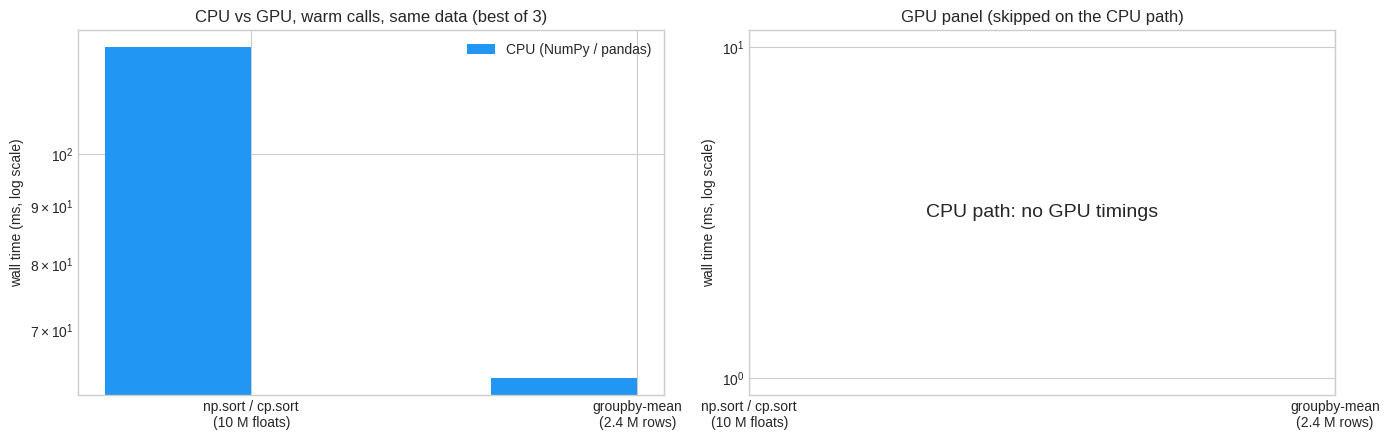

bars are measured wall times from the cells above; the number over each pair is the warm speed-up


In [8]:
labels = ["np.sort / cp.sort\n(10 M floats)", "groupby-mean\n(2.4 M rows)"]
cpu_ms = [t_np * 1e3, t_pd * 1e3]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
xpos = np.arange(len(labels)); w = 0.38
axes[0].bar(xpos - w/2, cpu_ms, w, label="CPU (NumPy / pandas)", color="#2196F3")
if GPU:
    gpu_ms = [t_cp * 1e3, t_cu * 1e3]
    axes[0].bar(xpos + w/2, gpu_ms, w, label=f"GPU warm ({GPU_NAME})", color="#76b900")
    for i in range(len(labels)):
        axes[0].text(xpos[i], max(cpu_ms[i], gpu_ms[i]) * 1.4, f"{cpu_ms[i]/gpu_ms[i]:.1f}x", ha="center", fontsize=12, fontweight="bold")
    first_ms = [t_first * 1e3, t_gfirst * 1e3]; copy_ms = [t_h2d * 1e3, t_copy * 1e3]
    axes[1].bar(xpos - w, first_ms, w * 0.9, label="first call", color="#dc3545")
    axes[1].bar(xpos, copy_ms, w * 0.9, label="host -> device copy", color="#ffc107")
    axes[1].bar(xpos + w, gpu_ms, w * 0.9, label="warm call", color="#76b900")
    axes[1].set_title("The three GPU numbers: first call, copy, warm call")
else:
    axes[1].text(0.5, 0.5, "CPU path: no GPU timings", ha="center", va="center", transform=axes[1].transAxes, fontsize=14)
    axes[1].set_title("GPU panel (skipped on the CPU path)")
axes[0].set_yscale("log"); axes[1].set_yscale("log")
for ax in axes:
    ax.set_xticks(xpos); ax.set_xticklabels(labels); ax.set_ylabel("wall time (ms, log scale)"); ax.legend()
axes[0].set_title("CPU vs GPU, warm calls, same data (best of 3)")
plt.tight_layout(); plt.show()
print("bars are measured wall times from the cells above; the number over each pair is the warm speed-up")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the log scale is deliberate. On a linear axis the GPU bars would be invisible and the picture would flatter the GPU; on a log axis each grid line is a factor of ten and you can read the ratio directly. Right: the red bar (first call) and the yellow bar (copy) are the costs that speed-up claims usually leave out; the green bar is the one they quote. The common misread: taking the tallest speed-up as "the" speed-up. There is no single number, only a number per data size, per operation, and per whether the data already lives on the GPU.

</div>

## 2.4 The honest counter-example: 1 500 rows

Same groupby, one month of the small `budget` frame (1 500 households). Now the fixed cost of launching a GPU kernel (tens of microseconds each, and a groupby launches several) is bigger than the arithmetic.


In [9]:
one_month = budget[budget.month == budget.month.min()].reset_index(drop=True)
print(f"one_month: {len(one_month):,} rows")
t_pd_small = bench(lambda: one_month.groupby("city_tier").total_spend.mean(), repeat=7)
print(f"pandas groupby on {len(one_month):,} rows: {t_pd_small*1e6:8.0f} us")
if GPU:
    g_small = cudf.from_pandas(one_month)
    t_cu_small = bench(lambda: g_small.groupby("city_tier").total_spend.mean(), repeat=7)
    print(f"cuDF   groupby on {len(one_month):,} rows: {t_cu_small*1e6:8.0f} us")
    winner = "pandas" if t_pd_small < t_cu_small else "cuDF"
    print(f"-> {winner} wins by {max(t_pd_small, t_cu_small)/min(t_pd_small, t_cu_small):.1f}x on small data; on {N_BIG:,} rows cuDF won by {t_pd/t_cu:.1f}x")
    del g_small
else:
    print("no GPU: the cuDF timing is skipped; on a T4 pandas wins or ties at this size because kernel launches dominate.")


one_month: 1,500 rows
pandas groupby on 1,500 rows:      290 us
no GPU: the cuDF timing is skipped; on a T4 pandas wins or ties at this size because kernel launches dominate.


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Warning: the first call is slow, and small data stays slow

Two traps the cells above showed. (1) The first GPU call of a kind was several times slower than the warm call: CUDA context creation, kernel loading, and for user-defined functions a Numba compile. If you time a cell once, you time the setup, not the operation. Re-run the sort cell and the gap disappears, which is exactly the point: the setup happened once. (2) At 1 500 rows the fixed launch cost dominates and pandas wins or ties. A GPU is not "faster"; it is faster **per row once there are enough rows**, and the crossover is usually in the tens or hundreds of thousands of rows.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: three rules for a speed claim

1. **Always warm up.** Call the function once, un-timed, then time it. `bench()` does this for you.
2. **Always time the same work.** Same rows, same columns, same dtypes, same result (the cells checked `np.allclose` between the CPU and GPU answers). A GPU groupby on float32 against a pandas groupby on float64 is two different jobs.
3. **Always report the data size and whether the copy is included.** "cuDF is 20x faster" means nothing; "on 2.4 M rows, warm, data resident, groupby-mean: 20x" is a fact.

</div>

## 2.5 Task 2 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- A GPU timing has three parts: first call, host→device copy, warm call. Only the warm call is what a loop pays.
- On 10 M floats and 2.4 M rows the GPU won clearly; on 1 500 rows pandas won or tied. The crossover, not the peak, is the useful fact.
- Move the data to the device once and keep it there; copying per operation can erase the gain.
- `bench()` (warm-up, sync, best of N) and an `allclose` check are the minimum for any number you write down.

### 🔑 New variables

| Name | What it is |
|---|---|
| `budget_big` | 2.4 M-row pandas frame (200 000 households × 12 months), used by Tasks 4-5 |
| `gbig` | the same frame on the GPU (`cudf.from_pandas`), or the pandas frame on the CPU path |
| `N_BIG`, `N_SORT` | the two data sizes reported with every timing |
| `t_np, t_cp, t_first, t_h2d`, `t_pd, t_cu, t_gfirst, t_copy` | the measured times (seconds); `None` for GPU entries on the CPU path |

### ➡️ Next Up

Part 2 turns cuDF into a working tool: the pandas API on the GPU, what is the same, what is different, what is missing, and the zero-code-change `cudf.pandas` mode.

</div>


# Part 2 · cuDF: pandas on the GPU; cudf.pandas; the budget data, analysed at speed ⭐

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Big Picture

cuDF's promise is that the pandas you already know keeps working, only faster: same method names, same arguments, same results. The promise is mostly kept, and Part 2 is precise about where it is not. Task 3 walks the pandas verbs on the small `budget` frame and builds a "same / different / missing" table from what actually ran. Task 4 shows `cudf.pandas`, which accelerates an unchanged pandas script and falls back to the CPU when it must. Task 5 runs a real analysis on 2.4 million rows and measures every step against pandas.

</div>


# Task 3 · cuDF as pandas on the GPU

## 3.1 One line to move a frame

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: same names, different memory

`cudf.from_pandas(df)` (or `cudf.DataFrame(df)`) copies every column to the device, in the Arrow layout of Task 1. From then on `gbudget.head()`, `.describe()`, `.groupby()` behave like pandas, but every result is a cuDF object that lives on the GPU. `to_host(...)` (which calls `.to_pandas()`) brings a result back when you need matplotlib or scikit-learn, and `.to_arrow()` hands it to anything that speaks Arrow without a second copy on the device.

</div>

The cell compares the dtypes of the pandas original and the cuDF copy. What prints depends on the pandas version: pandas 3 already uses a dedicated `str` dtype; pandas 2 shows `object` for text (a column of Python pointers). cuDF always uses a real string column type.


In [10]:
gbudget = cudf.from_pandas(budget) if GPU else budget.copy()
print(f"gbudget: {type(gbudget).__module__}.{type(gbudget).__name__}, {len(gbudget):,} rows  |  pandas {pd.__version__}  |  path: {'GPU (cuDF)' if GPU else 'CPU (pandas)'}")
print(gbudget.head(3).to_string() if not GPU else to_host(gbudget.head(3)).to_string())

dtypes_tbl = pd.DataFrame({"pandas": budget.dtypes.astype(str), "cuDF" if GPU else "xdf copy": gbudget.dtypes.astype(str)})
dtypes_tbl["same"] = dtypes_tbl.iloc[:, 0] == dtypes_tbl.iloc[:, 1]
print("\ndtypes side by side:")
print(dtypes_tbl.to_string())
n_diff = int((~dtypes_tbl["same"]).sum())
print(f"\n{n_diff} column(s) print a different dtype. Text columns: pandas -> {budget.note.dtype}, {'cuDF' if GPU else 'copy'} -> {gbudget.note.dtype}")
print("index:", type(gbudget.index).__name__, "| memory on device:" if GPU else "| memory:", f"{gbudget.memory_usage(deep=True).sum()/1e6:.1f} MB")


gbudget: pandas.core.frame.DataFrame, 36,000 rows  |  pandas 2.2.3  |  path: CPU (pandas)
   household_id      month city_tier  household_size  owns_car  income    rent  groceries  utilities  transport  dining  entertainment  other                             note  total_spend  overspent  survey_score referral_code
0             0 2024-01-01      town               4      True  4986.0   992.0      540.0      190.0      219.0   284.0          163.0   28.0     holiday travel with the kids       2415.0          0             4            C3
1             1 2024-01-01      city               4     False  4076.0  1061.0      628.0      189.0       62.0     NaN           94.0   13.0         hosted family for a week       2300.0          0             2            C3
2             2 2024-01-01      town               5      True  2506.0   495.0      657.0      238.0      180.0    68.0           57.0   54.0  cut the streaming subscriptions       1747.0          1             4            A1

d

## 3.2 The pandas verbs, on the GPU

The same calls a data analyst writes every day: `describe`, `groupby().agg` with named aggregations, `merge`, `sort_values`, `query`. Every result below is computed on the device and printed through `to_host`. One difference shows up already: cuDF's `query` compiles the expression for the GPU and accepts numeric, datetime and bool columns only, so the string condition is written as a boolean mask (which works on both libraries).


In [11]:
# describe: numeric summary (datetime and string columns are summarised or skipped exactly as pandas does)
print(to_host(gbudget[["income", "rent", "dining", "total_spend"]].describe()).round(1).to_string())

# groupby with named aggregations
by_tier = gbudget.groupby("city_tier").agg(households=("household_id", "nunique"), mean_spend=("total_spend", "mean"),
                                           overspend_rate=("overspent", "mean"), max_dining=("dining", "max"))
print("\ngroupby('city_tier').agg(...):\n" + to_host(by_tier).round(3).to_string())

# merge: attach each household's average income, then sort and query
avg_income = gbudget.groupby("household_id").income.mean().reset_index().rename(columns={"income": "avg_income"})
merged = gbudget.merge(avg_income, on="household_id", how="left")
top = merged.sort_values("total_spend", ascending=False).head(3)[["household_id", "month", "city_tier", "total_spend", "avg_income"]]
print("\nmerge + sort_values: the three biggest household-months\n" + to_host(top).to_string())

q = merged.query("overspent == 1 and household_size >= 4 and total_spend > 1.2 * avg_income")   # numeric columns only: cuDF's query cannot compare strings
q_metro = q[q.city_tier == "metro"]                                                             # a string test is a boolean mask, on both libraries
print(f"\nquery(...): {len(q):,} overspending 4+ person household-months spending over 120% of their average income; {len(q_metro):,} of them in metro areas")
print(f"merged is a {type(merged).__name__} on the {'GPU' if GPU else 'CPU'}; nothing came back to the host except the small printed tables")


        income     rent   dining  total_spend
count  36000.0  36000.0  34609.0      36000.0
mean    4866.9   1345.2    142.3       2520.8
std     1781.7    567.7    101.4        655.8
min     1433.0    272.0      1.0        977.0
25%     3613.0    942.0     67.0       2058.0
50%     4576.0   1244.0    119.0       2424.0
75%     5716.0   1622.0    192.0       2886.0
max    16537.0   4421.0    967.0       6539.0

groupby('city_tier').agg(...):
           households  mean_spend  overspend_rate  max_dining
city_tier                                                    
city              584    2484.995           0.158       967.0
metro             528    2827.890           0.293       773.0
town              388    2156.745           0.090       857.0

merge + sort_values: the three biggest household-months
       household_id      month city_tier  total_spend    avg_income
27025            25 2025-07-01     metro       6539.0  11576.333333
6242            242 2024-05-01     metro       6221

## 3.3 Strings, dates, missing values, casts, and the way back

String and datetime accessors work on the device too. A string column in cuDF is two buffers (characters and offsets), so `.str.len()` and `.str.contains()` are a parallel scan rather than a Python loop over objects. `.dt.month` reads the integer timestamps directly.


In [12]:
notes = gbudget.note
print("str.len()      :", to_host(notes.str.len()).describe()[["mean", "min", "max"]].round(1).to_dict())
print("str.contains() :", f"{float(notes.str.contains('travel').mean()):.1%} of notes mention travel;",
      f"{float(notes.str.contains('repair|medical').mean()):.1%} mention a repair or medical bill (regex)")
print("str.upper()    :", to_host(notes.str.upper().head(2)).tolist())
print("value_counts() :", to_host(notes.value_counts()).head(3).to_dict())

print("\ndt.month       :", to_host(gbudget.month.dt.month.value_counts()).sort_index().head(4).to_dict(), "...")
print("dt.strftime    :", to_host(gbudget.month.dt.strftime('%Y-%m').head(2)).tolist())

na_share = to_host(gbudget.isna().mean())
print("\nisna().mean()  :", na_share[na_share > 0].round(3).to_dict())
dining_filled = gbudget.dining.fillna(gbudget.dining.median())
print("fillna(median) :", f"missing before {int(gbudget.dining.isna().sum()):,}, after {int(dining_filled.isna().sum())}")

small_ints = gbudget.household_size.astype("int8"); flags = gbudget.overspent.astype("bool"); cats = gbudget.city_tier.astype("category")
print("astype         :", f"household_size -> {small_ints.dtype} ({small_ints.memory_usage()/1e3:.0f} KB vs {gbudget.household_size.memory_usage()/1e3:.0f} KB as int64),",
      f"overspent -> {flags.dtype}, city_tier -> {cats.dtype}")

back = to_host(gbudget.head(3))
print("\nto_pandas()    :", type(back).__module__, type(back).__name__)
if GPU:
    arrow_tbl = gbudget.head(3).to_arrow()
    print("to_arrow()     :", type(arrow_tbl).__module__, type(arrow_tbl).__name__, "| schema:", ", ".join(f"{f.name}:{f.type}" for f in list(arrow_tbl.schema)[:4]), "...")
else:
    print("to_arrow()     : pandas path -> pa.Table.from_pandas(df) does the same job on the CPU")


str.len()      : {'mean': 26.3, 'min': 21.0, 'max': 31.0}
str.contains() : 13.8% of notes mention travel; 27.2% mention a repair or medical bill (regex)
str.upper()    : ['HOLIDAY TRAVEL WITH THE KIDS', 'HOSTED FAMILY FOR A WEEK']
value_counts() : {'holiday travel with the kids': 4954, 'car repair and a new phone': 4904, 'medical bills came in': 4901}

dt.month       : {1: 3000, 2: 3000, 3: 3000, 4: 3000} ...


dt.strftime    :

 ['2024-01', '2024-01']

isna().mean()  : {'dining': 0.039, 'referral_code': 0.1}
fillna(median) : missing before 1,391, after 0
astype         : household_size -> int8 (36 KB vs 288 KB as int64), overspent -> bool, city_tier -> category

to_pandas()    : pandas.core.frame DataFrame
to_arrow()     : pandas path -> pa.Table.from_pandas(df) does the same job on the CPU


## 3.4 What is different: the index, `apply`, and the things that raise

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: `apply` on the GPU compiles your function

pandas `apply(axis=1)` calls your Python function once per row: slow, but it accepts anything. cuDF cannot run Python on the GPU, so it hands the function to **Numba**, which compiles it into a CUDA kernel. That gives two consequences you can measure: the **first call includes the compile** (cuDF caches compiled kernels on disk, so the second run of a notebook is faster), and the function must be **compilable**: arithmetic, comparisons, `math` functions, and a subset of string operations. A lambda that builds Python objects, calls pandas inside, or returns mixed types raises instead.

</div>


In [13]:
# row_udf = lambda row: row["rent"] / row["income"]           # the share of income spent on rent, one row at a time

# t0 = time.perf_counter(); r1 = gbudget.apply(row_udf, axis=1); sync(); t_apply_first = time.perf_counter() - t0
# t_apply_warm = bench(lambda: gbudget.apply(row_udf, axis=1))
# t_vec = bench(lambda: gbudget.rent / gbudget.income)
# t_pd_apply = bench(lambda: budget.apply(row_udf, axis=1), repeat=1)
# assert np.allclose(to_host(r1).values, (budget.rent / budget.income).values)

# print(f"{'row apply, first call':32s}: {t_apply_first*1e3:9.1f} ms   ({'includes the Numba compile' if GPU else 'pandas: a Python call per row'})")
# print(f"{'row apply, warm':32s}: {t_apply_warm*1e3:9.1f} ms")
# print(f"{'vectorised rent / income':32s}: {t_vec*1e3:9.1f} ms   <- always prefer this when it exists")
# print(f"{'pandas row apply (CPU)':32s}: {t_pd_apply*1e3:9.1f} ms")
# print(f"on {len(gbudget):,} rows: vectorised is {t_apply_warm/t_vec:.0f}x faster than the {'compiled' if GPU else 'pandas'} apply; "
#       f"{'the compiled apply is ' + f'{t_pd_apply/t_apply_warm:.0f}x faster than pandas apply' if GPU else 'both applies are pandas on this path'}")


The next cell does not describe the differences, it **runs** them. Each probe is a short pandas idiom executed once on the pandas frame and once on `gbudget`; the table records whether it returned or which exception it raised. On the CPU path both columns are pandas, so the table shows what a T4 would show only in the markdown table that follows.


In [14]:
probes = {
    "iterrows()":                     lambda df: next(df.iterrows()),
    "query(\"city_tier == 'metro'\")": lambda df: df.query("city_tier == 'metro'"),
    "df[cols].div(series, axis=0)":   lambda df: df[["rent", "dining"]].div(df.income, axis=0),
    "rolling(3).apply(lambda)":       lambda df: df.income.rolling(3).apply(lambda s: s.max() - s.min()),
    "groupby().describe()":           lambda df: df.groupby("city_tier").total_spend.describe(),
    "qcut()":                         lambda df: (cudf if GPU and df is gbudget else pd).qcut(df.income, q=4),
    ".style":                         lambda df: df.head().style,
    "Series.plot.hist()":             lambda df: df.total_spend.plot.hist(),
    "apply(np.sum) over columns":     lambda df: df[["rent", "dining"]].apply(np.sum),
    "pivot_table()":                  lambda df: df.pivot_table(index="city_tier", columns="household_size", values="total_spend", aggfunc="mean"),
    "corr(method='spearman')":        lambda df: df[["rent", "income", "dining"]].corr(method="spearman"),
    "str.split(expand=True)":         lambda df: df.note.str.split(" ", expand=True),
    "groupby().transform('mean')":    lambda df: df.groupby("household_id").total_spend.transform("mean"),
    "cut()":                          lambda df: (cudf if GPU and df is gbudget else pd).cut(df.income, bins=4),
    "sample(n=5)":                    lambda df: df.sample(5, random_state=RANDOM_STATE),
}
def outcome(fn, df):
    try:
        fn(df); return "OK"
    except Exception as e:  # noqa: BLE001 - the exception type is the data here
        return type(e).__name__
plt.close("all")
compat = pd.DataFrame({"pandas": [outcome(f, budget) for f in probes.values()],
                       "cuDF" if GPU else "xdf (pandas)": [outcome(f, gbudget) for f in probes.values()]}, index=list(probes))
plt.close("all")                                            # Series.plot opened a figure on the pandas side
compat["verdict"] = np.where(compat.iloc[:, 0] == compat.iloc[:, 1], "same", "different")
print(compat.to_string())
print(f"\n{int((compat.verdict == 'different').sum())} of {len(compat)} probes behave differently on this path"
      + ("" if GPU else " (CPU path: both columns are pandas, so every row says 'same')"))


                              pandas xdf (pandas) verdict
iterrows()                        OK           OK    same
query("city_tier == 'metro'")     OK           OK    same
df[cols].div(series, axis=0)      OK           OK    same
rolling(3).apply(lambda)          OK           OK    same
groupby().describe()              OK           OK    same
qcut()                            OK           OK    same
.style                            OK           OK    same
Series.plot.hist()                OK           OK    same
apply(np.sum) over columns        OK           OK    same
pivot_table()                     OK           OK    same
corr(method='spearman')           OK           OK    same
str.split(expand=True)            OK           OK    same
groupby().transform('mean')       OK           OK    same
cut()                             OK           OK    same
sample(n=5)                       OK           OK    same

0 of 15 probes behave differently on this path (CPU path: both columns 

### pandas → cuDF: same, different, missing (cuDF 26.08)

| pandas idiom | cuDF | Notes |
|---|---|---|
| `head`, `describe`, `groupby().agg`, `merge`, `sort_values`, `query`, `value_counts`, `isna`, `fillna`, `astype`, `pivot_table`, `corr`, `cut`, `sample`, `str.*`, `dt.*`, `groupby().transform` | **same** | ran above with the same arguments and the same answers |
| `dtypes` printing | **different** | strings are a real column type (`str`); pandas 2 printed `object`. Timestamps are `datetime64[us]` by default |
| `apply(axis=1)` / `Series.apply` | **different** | compiled by Numba: first call pays a compile; the function must be compilable (arithmetic, `math`, simple string ops); no Python objects inside |
| `rolling().apply(lambda)`, `apply(np.sum)` over columns | **raises** | the lambda receives a Series/array, which Numba cannot compile: rewrite as `rolling().max() - rolling().min()` or `df.sum()` |
| `iterrows()`, `itertuples()` | **raises** | deliberate: iteration would copy one row at a time to the host. Use `.to_pandas().iterrows()` on a small slice, or vectorise |
| `query("city_tier == 'metro'")` | **raises** | `query` compiles the expression with Numba and accepts numeric, datetime and bool columns only (`TypeError` otherwise): use a boolean mask `df[df.city_tier == "metro"]` for strings |
| `df.div(series, axis=0)` | **raises** | `NotImplementedError` in 26.08: divide with `.values` (CuPy broadcasting) or column by column |
| `groupby().describe()` | **raises** | `IndexError` in 26.08: call `agg(["count", "mean", "std", "min", "max"])` instead |
| `.style`, `.plot`, `qcut` | **missing** | no plotting or styling on the device: `to_host(...)` first (Part 3). `qcut`: compute quantiles with `.quantile()` and `cudf.cut` |
| `.to_arrow()`, `.to_cupy()` / `.values`, `__cuda_array_interface__` | **only in cuDF** | zero-copy hand-off to Arrow, CuPy, XGBoost, PyTorch (Part 11) |

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Warning: `apply` is the trap, not the feature

The timing cell showed the vectorised `rent / income` beating the compiled row `apply` by a large factor even after the compile was paid. `apply` on the GPU exists so that old code keeps running; it is not the fast path. Any row function that can be written as column arithmetic, `where`, `map` or `str` methods should be.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: probe, do not assume

The compatibility table was **computed**: each idiom ran and recorded its exception. When you port a pandas notebook, do the same: run the old code on a 10 000-row slice under cuDF, collect the exceptions, and rewrite only what raised. The list of raises is short and stable; the list of things that "might not work" is endless.

</div>

## 3.5 Task 3 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- `cudf.from_pandas` moves a frame to the device once; from then on the pandas verbs (`describe`, `groupby().agg`, `merge`, `sort_values`, `query`, `str.*`, `dt.*`, `fillna`, `astype`) run on the GPU with the same arguments and the same answers.
- Strings are a real Arrow column type; timestamps default to microseconds; the index is a `RangeIndex` like pandas.
- `apply` compiles with Numba: first call slow, restricted functions, and still much slower than vectorised arithmetic.
- The things that raise in 26.08 (`iterrows`, `div(axis=0)`, `rolling.apply(lambda)`, `groupby.describe`) and the things missing (`.style`, `.plot`, `qcut`) each have a one-line rewrite.

### 🔑 New variables

| Name | What it is |
|---|---|
| `gbudget` | the 36 000-row `budget` frame on the device (pandas copy on the CPU path) |
| `merged`, `avg_income`, `by_tier` | device-side results of `merge`, `groupby`, `agg` |
| `compat` | the computed pandas-vs-cuDF compatibility table |
| `t_apply_first, t_apply_warm, t_vec, t_pd_apply` | the `apply` timings (seconds) |

### ➡️ Next Up

Task 4: the zero-code-change route. `cudf.pandas` accelerates an unchanged pandas script and falls back to the CPU for the operations that just raised.

</div>


# Task 4 · `cudf.pandas`: zero-code-change mode

## 4.1 How the accelerator works

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: a proxy in front of pandas

`cudf.pandas` replaces the `pandas` module with a **proxy**. Every `pd.DataFrame` you create is a proxy object that holds a cuDF frame while it can, runs each method on the GPU, and, when a method is not supported (Task 3's raises), **copies the data to the host, runs real pandas, and carries on**. Your script does not change; only the import order does. Three ways to switch it on:

- in a notebook: `%load_ext cudf.pandas` as the first cell, before `import pandas`;
- in a script: `python -m cudf.pandas my_script.py`;
- in code: `import cudf.pandas; cudf.pandas.install()` before `import pandas as pd`.

This notebook imported pandas in Part 0, so it cannot switch itself. The cells below therefore run a small pandas script **in a subprocess**, once plain and once under `cudf.pandas`, on the 2.4 million-row frame saved to Parquet. The script prints its own import, read and work times, so the comparison is fair.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Warning: `cudf.pandas.install()` takes most of the free GPU memory

By default `install()` creates a managed memory pool sized at 80% of the free device memory (cuDF 26.08 source). On a Colab T4 that is fine: the card is yours. On a shared GPU, or in a notebook that already holds cuDF frames, set `CUDF_PANDAS_RMM_MODE=cuda` (no pool) before the import, as the subprocess below does.

</div>


In [15]:
def save_frame(df, path):
    # Write a pandas or cuDF frame to Parquet or CSV. On Colab a cuDF frame writes straight to disk (`gdf.to_parquet(path)`)
    # through its GPU I/O layer (kvikio); some platforms (WSL2, where this notebook was built) lack the pinned-memory path
    # kvikio needs and crash, so a cuDF frame is serialised into an in-memory buffer first, which works everywhere.
    is_cudf = hasattr(df, "to_pandas")
    if path.endswith(".parquet"):
        if is_cudf:
            buf = io.BytesIO(); df.to_parquet(buf); open(path, "wb").write(buf.getvalue())
        else:
            df.to_parquet(path)
    else:
        if is_cudf:
            buf = io.StringIO(); df.to_csv(buf, index=False); open(path, "w").write(buf.getvalue())
        else:
            df.to_csv(path, index=False)
    return os.path.getsize(path)

DATA_DIR = tempfile.mkdtemp(prefix="rapids_budget_")
PQ_PATH, CSV_PATH = os.path.join(DATA_DIR, "budget_big.parquet"), os.path.join(DATA_DIR, "budget_big.csv")
with timer(f"write Parquet ({'cuDF' if GPU else 'pandas'})"):
    pq_bytes = save_frame(gbig, PQ_PATH)
with timer(f"write CSV ({'cuDF' if GPU else 'pandas'})"):
    csv_bytes = save_frame(gbig, CSV_PATH)
print(f"{N_BIG:,} rows -> Parquet {pq_bytes/1e6:,.0f} MB, CSV {csv_bytes/1e6:,.0f} MB ({csv_bytes/pq_bytes:.1f}x bigger: text digits instead of compressed binary columns)")


⏱️ write Parquet (pandas): 2.16 s


⏱️ write CSV (pandas): 18.78 s
2,400,000 rows -> Parquet 45 MB, CSV 286 MB (6.3x bigger: text digits instead of compressed binary columns)


## 4.2 The same script, plain and accelerated

The script reads the Parquet file and does three ordinary things: a two-key groupby, a full sort, and a regex search over the `note` column. It reports `type(df).__module__` so you can see which library actually served the calls.


In [16]:
WORK_SCRIPT = r'''
import sys, time
t0 = time.perf_counter()
import pandas as pd
t1 = time.perf_counter()
df = pd.read_parquet(sys.argv[1])
t2 = time.perf_counter()
by_seg = df.groupby(["city_tier", "household_size"]).total_spend.mean()
ranked = df.sort_values("total_spend", ascending=False)
n_travel = int(df.note.str.contains("travel|holiday").sum())
t3 = time.perf_counter()
served = "cudf.pandas-proxy" if getattr(sys.modules.get("cudf.pandas"), "LOADED", False) else "pandas"
print(f"import={t1-t0:.2f} read={t2-t1:.2f} work={t3-t2:.2f} rows={len(df)} n_travel={n_travel} module={served}")
'''
ACCEL_PREFIX = "import cudf.pandas; cudf.pandas.install()\n"      # the only change: two statements before `import pandas`

def run_script(src, label, env_extra=None):
    env = dict(os.environ, CUDF_PANDAS_RMM_MODE="cuda", **(env_extra or {}))
    t0 = time.perf_counter()
    res = subprocess.run([sys.executable, "-c", src, PQ_PATH], capture_output=True, text=True, env=env, timeout=600)
    wall = time.perf_counter() - t0
    line = [l for l in res.stdout.splitlines() if l.startswith("import=")]
    if res.returncode != 0 or not line:
        print(f"{label}: failed\n{res.stderr[-800:]}"); return None
    parts = dict(kv.split("=") for kv in line[0].split())
    parts = {k: (float(v) if k in ("import", "read", "work") else v) for k, v in parts.items()}
    parts["wall"] = wall
    print(f"{label:22s}: import {parts['import']:6.2f} s | read {parts['read']:6.2f} s | work {parts['work']:6.2f} s | whole process {wall:6.1f} s | served by {parts['module']}")
    return parts

plain = run_script(WORK_SCRIPT, "plain pandas")
accel = run_script(ACCEL_PREFIX + WORK_SCRIPT, "cudf.pandas") if GPU else None
if accel and plain:
    print(f"\nsame answer: n_travel {plain['n_travel']} vs {accel['n_travel']}, rows {plain['rows']} vs {accel['rows']}")
    print(f"speed-up on the work: {plain['work']/accel['work']:.1f}x | on the read: {plain['read']/accel['read']:.1f}x | "
          f"whole process incl. imports: {plain['wall']/accel['wall']:.2f}x (importing cuDF costs {accel['import']:.1f} s, once per process)")
elif not GPU:
    print("\nno GPU: the cudf.pandas run was skipped (it needs a CUDA device). On a T4 the second line reports the same script served by cudf.pandas.")


plain pandas          : import   0.59 s | read   0.91 s | work   2.63 s | whole process    4.4 s | served by pandas

no GPU: the cudf.pandas run was skipped (it needs a CUDA device). On a T4 the second line reports the same script served by cudf.pandas.


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What the two lines say

The **work** column is the honest comparison: the same three operations, same data, served by pandas in one process and by cuDF (through the proxy) in the other. The **import** column is the price of admission: importing cuDF and initialising CUDA costs seconds, paid once per process, which is why a short script can be *slower* end-to-end under `cudf.pandas` while a long one is faster. The **read** column is Parquet decoding, which the GPU also does in parallel. The common misread: quoting the whole-process ratio as the speed-up of `cudf.pandas`. It is the speed-up of one particular script length.

</div>

## 4.3 Seeing the fallback: `cudf.pandas.Profiler`

Not every call has a GPU implementation. When the proxy meets one it cannot serve (Task 3's `rolling().apply(lambda)`), it moves the data to the host, calls pandas, and continues. The **profiler** shows which calls ran where: `cudf.pandas.Profiler()` as a context manager in a script, or the `%%cudf.pandas.profile` / `%%cudf.pandas.line_profile` cell magics in a notebook that loaded the extension. The subprocess below runs one supported and one unsupported call on 50 000 rows and prints the per-function report.


In [17]:
PROFILE_SCRIPT = r'''
import sys
import cudf.pandas; cudf.pandas.install()
import pandas as pd
from cudf.pandas import Profiler
df = pd.read_parquet(sys.argv[1], columns=["household_id", "total_spend"]).head(50_000)
print("is_proxy_object(df) =", cudf.pandas.is_proxy_object(df), "| class:", type(df).__name__)
with Profiler() as prof:
    by_hh = df.groupby("household_id").total_spend.mean()                              # supported: runs on the GPU
    spread = df.total_spend.rolling(3).apply(lambda s: s.max() - s.min())              # unsupported lambda: falls back to CPU pandas
prof.print_per_function_stats()
'''
if GPU:
    res = subprocess.run([sys.executable, "-c", PROFILE_SCRIPT, PQ_PATH], capture_output=True, text=True,
                         env=dict(os.environ, CUDF_PANDAS_RMM_MODE="cuda"), timeout=600)
    print(res.stdout if res.returncode == 0 else res.stderr[-1200:])
    print("read the table: a call with GPU time and no CPU time was served by cuDF; a call with CPU time fell back to pandas (after copying to the host)")
else:
    print("no GPU: the profiler subprocess was skipped. On a T4 it prints a per-function table with a GPU-time and a CPU-time column;")
    print("the groupby shows GPU time only, the rolling().apply(lambda) shows CPU time, which is the fallback happening.")


no GPU: the profiler subprocess was skipped. On a T4 it prints a per-function table with a GPU-time and a CPU-time column;
the groupby shows GPU time only, the rolling().apply(lambda) shows CPU time, which is the fallback happening.


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Warning: fallbacks are silent and they copy

A fallback is not an error; nothing is printed. The frame is copied to the host, pandas runs, and the result is copied back when the next supported call needs it. One unsupported call inside a loop can therefore make an accelerated script slower than plain pandas. The profiler is how you find it, and a pattern with **CPU time on a call you expected to be fast** is the signature.

</div>

## 4.4 Parquet versus CSV, on both processors

File format is often the biggest speed-up of all, and it is free. Parquet stores each column compressed and typed, so a reader decodes only the columns it needs and never parses text; CSV is text that must be tokenised, type-guessed and converted row by row. Both readers exist in cuDF (`cudf.read_parquet`, `cudf.read_csv`) and the GPU CSV parser is itself a parallel kernel.


pandas read_parquet :    0.45 s   (2,400,000 rows)
pandas read_csv     :    4.13 s   (2,400,000 rows)

Parquet vs CSV on the CPU: 9.1x (no GPU: the cuDF readers were skipped)


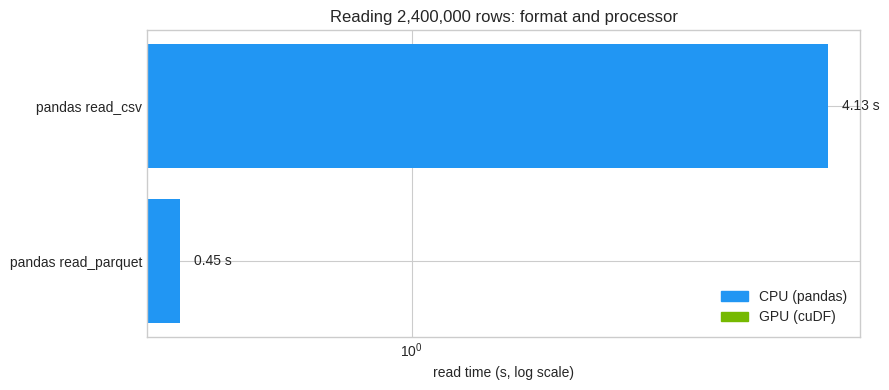

note: the pandas CSV read was timed once after a 50 000-row warm-up; every other bar is the best of 2 after a full warm-up


In [18]:
io_times = {}
io_times["pandas read_parquet"] = bench(lambda: pd.read_parquet(PQ_PATH), repeat=2)
pd.read_csv(CSV_PATH, nrows=50_000)                                                   # warm-up on a slice: primes the parser and the file cache
t0 = time.perf_counter(); csv_pd = pd.read_csv(CSV_PATH); io_times["pandas read_csv"] = time.perf_counter() - t0   # timed once: it is the slow one
if GPU:
    io_times["cuDF read_parquet"] = bench(lambda: cudf.read_parquet(PQ_PATH), repeat=2)
    io_times["cuDF read_csv"] = bench(lambda: cudf.read_csv(CSV_PATH), repeat=2)
    csv_cu = cudf.read_csv(CSV_PATH)
    print(f"same frame back from CSV on both: shape {csv_pd.shape} vs {csv_cu.shape}, dtypes equal: {csv_pd.dtypes.astype(str).tolist() == csv_cu.dtypes.astype(str).tolist()}")
    del csv_cu
del csv_pd
for k, v in io_times.items():
    print(f"{k:20s}: {v:7.2f} s   ({N_BIG:,} rows)")
if GPU:
    print(f"\nParquet vs CSV: pandas {io_times['pandas read_csv']/io_times['pandas read_parquet']:.1f}x, cuDF {io_times['cuDF read_csv']/io_times['cuDF read_parquet']:.1f}x")
    print(f"GPU vs CPU    : Parquet {io_times['pandas read_parquet']/io_times['cuDF read_parquet']:.1f}x, CSV {io_times['pandas read_csv']/io_times['cuDF read_csv']:.1f}x")
else:
    print(f"\nParquet vs CSV on the CPU: {io_times['pandas read_csv']/io_times['pandas read_parquet']:.1f}x (no GPU: the cuDF readers were skipped)")

fig, ax = plt.subplots(figsize=(9, 4))
names = list(io_times); vals = [io_times[k] for k in names]
colors = ["#2196F3" if k.startswith("pandas") else "#76b900" for k in names]
ax.barh(names, vals, color=colors)
for i, v in enumerate(vals):
    ax.text(v * 1.05, i, f"{v:.2f} s", va="center")
ax.set_xscale("log"); ax.set_xlabel("read time (s, log scale)"); ax.set_title(f"Reading {N_BIG:,} rows: format and processor")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color="#2196F3"), plt.Rectangle((0, 0), 1, 1, color="#76b900")], labels=["CPU (pandas)", "GPU (cuDF)"], loc="lower right")
plt.tight_layout(); plt.show()
print("note: the pandas CSV read was timed once after a 50 000-row warm-up; every other bar is the best of 2 after a full warm-up")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Two moves, each worth a factor: CSV → Parquet (fewer bytes, no parsing) and CPU → GPU (parallel decode). They multiply. The order matters for a budget: switching format costs nothing and helps on every machine, including the CPU-only grader. The common misread: "the GPU makes CSV fast enough". It makes CSV faster, but the Parquet file is also several times smaller on disk and carries its dtypes, so `month` came back as a string from CSV on both processors and as a timestamp from Parquet.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: when to reach for `cudf.pandas`

- **Existing pandas code, no time to port:** `%load_ext cudf.pandas` first, run the profiler once, fix only the calls that fell back.
- **New code:** write against cuDF directly with the `xdf` contract; you keep control over what lives on the device and never pay a silent copy.
- **Either way:** store data as Parquet, keep `CUDF_PANDAS_RMM_MODE` in mind on shared GPUs, and measure the *work*, not the process.

</div>

## 4.5 Task 4 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- `cudf.pandas` is a proxy: unchanged pandas code, GPU when possible, silent CPU fallback otherwise. Enable it before `import pandas` (`%load_ext`, `python -m cudf.pandas`, or `install()`).
- The subprocess pair measured the same script both ways; the import cost is paid once per process and can dominate short scripts.
- `cudf.pandas.Profiler` (or `%%cudf.pandas.profile`) shows per call which processor served it; CPU time on an expected-fast call is the fallback signature.
- Parquet beats CSV on both processors, and the GPU reader multiplies the gain; the file also keeps its dtypes.

### 🔑 New variables

| Name | What it is |
|---|---|
| `save_frame(df, path)` | writes pandas or cuDF frames to Parquet/CSV (buffered on platforms without GPU direct I/O) |
| `DATA_DIR`, `PQ_PATH`, `CSV_PATH` | the temp directory and the two files holding `budget_big` |
| `WORK_SCRIPT`, `ACCEL_PREFIX`, `PROFILE_SCRIPT`, `run_script` | the subprocess experiments |
| `plain`, `accel`, `io_times` | the measured timings (dicts; `accel` is `None` on the CPU path) |

### ➡️ Next Up

Task 5 uses the resident 2.4 M-row frame for a real analysis, seasonality, segment overspend rates, income shares, notes, rolling means, and times every step against pandas.

</div>


# Task 5 · The budget data, analysed at speed

## 5.1 Five questions, timed twice

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: one function, two frames

Each question below is written **once** as a function of a frame, then run on `budget_big` (pandas) and on `gbig` (cuDF). That is the whole discipline of Parts 2 to 10: if the analysis is expressed in the pandas verbs, the same code runs on either processor, and the only things that change are the timings and the `to_host` at the end. The five questions cover the operation families that matter: a datetime groupby, a two-key groupby, column arithmetic over many columns, a string filter plus a count, and a grouped rolling window.

</div>

Two implementation notes, both learned in Task 3: the share of income is computed with `.values` broadcasting (`df.div(series, axis=0)` is not implemented in cuDF, and the array form runs on both NumPy and CuPy); the rolling mean uses `groupby().rolling()`, which cuDF 26.08 supports for a single column.


In [19]:
CATS = ["rent", "groceries", "utilities", "transport", "dining", "entertainment", "other"]

def q_seasonality(df):            # mean spend by calendar month
    return df.groupby(df.month.dt.month).total_spend.mean()

def q_overspend_segments(df):     # overspend rate by city tier x household size
    return df.groupby(["city_tier", "household_size"]).overspent.mean()

def q_income_share(df):           # share of income per category, averaged over all household-months
    shares = df[CATS].values / df.income.values[:, None]          # NumPy on pandas, CuPy on cuDF: one broadcast, no Python loop
    return shares.mean(axis=0)

def q_top_notes(df):              # the notes that go with overspending
    return df.loc[df.overspent == 1, "note"].value_counts()

def q_rolling(df):                # 3-month rolling mean of spend, per household
    s = df.sort_values(["household_id", "month"])
    return s.groupby("household_id").total_spend.rolling(3).mean()

QUESTIONS = {"seasonality (dt groupby)": q_seasonality, "overspend by tier x size (2-key groupby)": q_overspend_segments,
             "share of income per category (broadcast)": q_income_share, "top notes among overspenders (str filter + count)": q_top_notes,
             "3-month rolling mean per household (groupby.rolling)": q_rolling}

rows, results = [], {}
warm_slice = budget_big.head(2_000)                                # CPU warm-up on a slice: primes the code path; the timed run is the full frame
for name, fn in QUESTIONS.items():
    fn(warm_slice)
    t0 = time.perf_counter(); res_cpu = fn(budget_big); t_cpu = time.perf_counter() - t0
    if GPU:
        t_gpu = bench(lambda: fn(gbig)); res_gpu = fn(gbig)
        a, b = np.asarray(to_host(res_gpu), dtype=float).ravel(), np.asarray(res_cpu, dtype=float).ravel()
        a, b = np.sort(a[~np.isnan(a)]), np.sort(b[~np.isnan(b)])        # compare the multisets of values: group order may differ
        agree = a.shape == b.shape and bool(np.allclose(a, b))
    else:
        t_gpu, agree, res_gpu = np.nan, True, res_cpu
    rows.append({"operation": name, "rows": N_BIG, "GPU ms": t_gpu * 1e3, "CPU ms": t_cpu * 1e3, "speed-up": t_cpu / t_gpu, "same answer": agree})
    results[name] = res_gpu
    print(f"{name:55s} GPU {t_gpu*1e3:9.1f} ms | CPU {t_cpu*1e3:9.1f} ms | {t_cpu/t_gpu:6.1f}x | same answer: {agree}")

speed_tbl = pd.DataFrame(rows).set_index("operation")
print(f"\n{'GPU' if GPU else 'CPU-only'} path; CPU column timed once after a 2 000-row warm-up, GPU column best of 3 after a full warm-up")


seasonality (dt groupby)                                GPU       nan ms | CPU      93.7 ms |    nanx | same answer: True


overspend by tier x size (2-key groupby)                GPU       nan ms | CPU     170.1 ms |    nanx | same answer: True


share of income per category (broadcast)                GPU       nan ms | CPU      40.7 ms |    nanx | same answer: True
top notes among overspenders (str filter + count)       GPU       nan ms | CPU     105.3 ms |    nanx | same answer: True


3-month rolling mean per household (groupby.rolling)    GPU       nan ms | CPU    4979.2 ms |    nanx | same answer: True

CPU-only path; CPU column timed once after a 2 000-row warm-up, GPU column best of 3 after a full warm-up


## 5.2 The table and the picture


,GPU ms,CPU ms,speed-up
operation,,,
seasonality (dt groupby),-,93.7,-
overspend by tier x size (2-key groupby),-,170.1,-
share of income per category (broadcast),-,40.7,-
top notes among overspenders (str filter + count),-,105.3,-
3-month rolling mean per household (groupby.rolling),-,"4,979.2",-


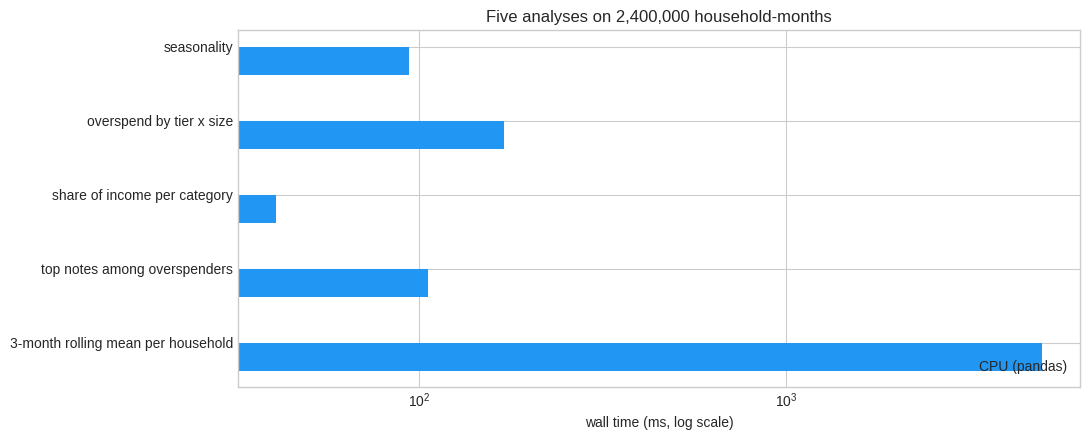

median speed-up across the five: nanx | min nanx | max nanx


In [20]:
display(pretty(speed_tbl.drop(columns=["rows", "same answer"]), fmt="{:,.1f}", highlight="max", subset=["speed-up"]))
fig, ax = plt.subplots(figsize=(11, 4.5))
ypos = np.arange(len(speed_tbl)); h = 0.38
ax.barh(ypos + h/2, speed_tbl["CPU ms"], h, label="CPU (pandas)", color="#2196F3")
if GPU:
    ax.barh(ypos - h/2, speed_tbl["GPU ms"], h, label=f"GPU (cuDF, {GPU_NAME})", color="#76b900")
    for i, (g, c, s) in enumerate(zip(speed_tbl["GPU ms"], speed_tbl["CPU ms"], speed_tbl["speed-up"])):
        ax.text(max(g, c) * 1.15, i, f"{s:.1f}x", va="center", fontweight="bold")
ax.set_yticks(ypos); ax.set_yticklabels([n.split(" (")[0] for n in speed_tbl.index]); ax.invert_yaxis()
ax.set_xscale("log"); ax.set_xlabel("wall time (ms, log scale)"); ax.set_title(f"Five analyses on {N_BIG:,} household-months"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()
print(f"median speed-up across the five: {speed_tbl['speed-up'].median():.1f}x | min {speed_tbl['speed-up'].min():.1f}x | max {speed_tbl['speed-up'].max():.1f}x")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The speed-ups are not uniform, and the spread is the lesson. Operations that touch every row with heavy work per row (the grouped rolling window, the full sort inside it, string matching) gain the most, because that is where thousands of threads beat a few cores. Operations that are already cheap in pandas (a single-column mean over a few groups) gain the least, because the kernel launches and the final device-to-host copy of a tiny result are a fixed floor. The common misread: averaging the speed-ups into one number. Report the table, or at least the median with the range.

</div>

## 5.3 The answers themselves

Speed is pointless if nobody reads the result. Each answer is brought to the host with `to_host` (they are all small) and printed as an analyst would want to see it.


In [21]:
season = to_host(results["seasonality (dt groupby)"]).sort_index()
print("Mean spend by calendar month (seasonality planted by the generator; December is the peak):")
print("  " + "  ".join(f"{int(m):2d}:{v:,.0f}" for m, v in season.items()))
print(f"  peak month {int(season.idxmax())} at {season.max():,.0f} vs trough month {int(season.idxmin())} at {season.min():,.0f} ({season.max()/season.min()-1:.0%} higher)")

seg = to_host(results["overspend by tier x size (2-key groupby)"]).unstack("household_size")
print("\nOverspend rate by city tier (rows) x household size (columns):")
print(seg.loc[["metro", "city", "town"]].round(3).to_string())

share = to_host(results["share of income per category (broadcast)"])
share_s = pd.Series(np.asarray(share), index=CATS).sort_values(ascending=False)
print("\nShare of income per category (mean over household-months):")
print("  " + ", ".join(f"{c} {v:.1%}" for c, v in share_s.items()) + f"  | total {share_s.sum():.1%} (dining excludes its missing months)")

notes_top = to_host(results["top notes among overspenders (str filter + count)"]).head(4)
print("\nTop notes among overspending household-months:")
for n, c in notes_top.items():
    print(f"  {c:>8,}  {n}")

roll = to_host(results["3-month rolling mean per household (groupby.rolling)"])
print(f"\n3-month rolling mean: {len(roll):,} values, {int(roll.isna().sum()):,} NaN (the first two months of each of {budget_big.household_id.nunique():,} households = {2*budget_big.household_id.nunique():,})")


Mean spend by calendar month (seasonality planted by the generator; December is the peak):
   1:2,395   2:2,434   3:2,456   4:2,518   5:2,570   6:2,599   7:2,632   8:2,603   9:2,522  10:2,470  11:2,430  12:2,578
  peak month 7 at 2,632 vs trough month 1 at 2,395 (10% higher)

Overspend rate by city tier (rows) x household size (columns):
household_size      1      2      3      4      5
city_tier                                        
metro           0.154  0.222  0.313  0.405  0.493
city            0.070  0.107  0.162  0.228  0.294
town            0.033  0.055  0.083  0.125  0.174

Share of income per category (mean over household-months):
  rent 27.7%, groceries 11.1%, entertainment 3.7%, transport 3.7%, utilities 3.4%, other 2.4%, dining nan%  | total 52.0% (dining excludes its missing months)

Top notes among overspending household-months:
    77,885  medical bills came in
    77,846  car repair and a new phone
    77,834  holiday travel with the kids
    51,061  worked overtime, 

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Warning: `to_host` on the whole frame is the mistake to avoid

Every `to_host` in this Task moved a result of a few hundred values at most. Calling `.to_pandas()` on `gbig` itself would copy hundreds of megabytes over PCIe and materialise 2.4 million Python-visible rows, undoing the work of Task 2. The rule: aggregate on the device, move the aggregate. Part 3 makes that rule the basis of plotting from GPU frames.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: check the answer, then the clock

The timing loop checked `same answer` for every question before recording a speed-up. A fast wrong answer is worse than a slow right one, and GPU ports break in quiet ways: a different NaN treatment, an unsorted groupby result, float32 rounding. `np.allclose` on the sorted host copies is a cheap, sufficient test for aggregates.

</div>

## 5.4 Clean up: give the memory back

`budget_big` and `gbig` were the largest objects in Parts 1 and 2. Deleting the Python names is not enough on its own: CuPy keeps freed blocks in its pool for reuse, and Python may not have collected the frame yet. `free_pools()` runs the garbage collector and releases CuPy's cached blocks; `gpu_mem()` shows the result. (With an RMM pool allocator, Part 8, freed memory stays inside the pool and `nvidia-smi` does not drop; that is expected.)


In [22]:
gpu_mem("before clean-up")
del gbig, budget_big, merged, avg_income, results
for p in (PQ_PATH, CSV_PATH):
    if os.path.exists(p):
        os.remove(p)
shutil.rmtree(DATA_DIR, ignore_errors=True)
free_pools()
gpu_mem("after del + free_pools()")
print(f"kept on the device for later Parts: gbudget ({len(gbudget):,} rows, {gbudget.memory_usage(deep=True).sum()/1e6:.1f} MB); removed {DATA_DIR}")


[before clean-up] CPU path: no device memory to report


[after del + free_pools()] CPU path: no device memory to report


kept on the device for later Parts: gbudget (36,000 rows, 10.4 MB); removed /home/hatch/workspace/tmp/rapids_budget_4vu29s_5


## 5.5 Task 5 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- Write each analysis once as a function of a frame; run it on pandas and on cuDF; compare answers, then times. The five questions ran unchanged on both.
- Speed-ups vary by operation family: grouped rolling windows and string filters gain most, tiny aggregates least. Report the table, not one number.
- `.values` broadcasting is the portable way to divide many columns by one (NumPy or CuPy); `groupby().rolling()` works on a single column in cuDF 26.08.
- Bring only aggregates to the host; `del` + `free_pools()` + `gpu_mem()` is the clean-up routine at the end of every Part.

### 🔑 New variables

| Name | What it is |
|---|---|
| `CATS` | the seven spending categories |
| `QUESTIONS`, `q_*` | the five analyses as frame-agnostic functions |
| `speed_tbl` | operation → GPU ms → CPU ms → speed-up → same answer |
| `season`, `seg`, `share_s`, `notes_top`, `roll` | the host-side answers |

### ➡️ Next Up

Part 3 plots from GPU frames: the "aggregate on the GPU, plot on the host" rule, histograms from device-computed bin counts, and the sampling trick for scatter plots on millions of rows.

</div>


# Part 3 · Data Analysis and Visualization from GPU Frames ⭐⭐

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Big Picture

A GPU frame is a great place to **compute** and a terrible place to **draw**. Matplotlib lives on the host (the CPU and its RAM), so every picture starts with a copy from device memory to host memory. The trick of this Part is to make that copy tiny: reduce millions of rows to a few dozen numbers on the GPU, then move only those numbers. Task 6 builds every standard EDA figure that way on a 2.4-million-row budget frame and times each aggregation against pandas. Task 7 is the honesty check: the same work on 1 500 rows, where the CPU wins, and the sampling trick for the plots that genuinely need individual points.

</div>


# Task 6 · Aggregate on the GPU, Plot on the Host

## 6.1 The rule, and why it exists

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Two memories, one bus

A GPU has its own memory (device memory). Your Python process, pandas and matplotlib live in host memory. Data crosses between them over the PCIe bus, which is slow compared with either memory and has a fixed cost per transfer. A histogram is 40 bar heights. A correlation matrix of 12 columns is 144 numbers. A seasonality line is 12 means. None of those needs the rows to leave the GPU: **reduce first, copy the result, draw on the host**.

Every figure in this Task follows the same three lines:

1. `agg = gdf.<something>()` runs on the device;
2. `agg = to_host(agg)` moves the small result;
3. `plt.bar(...)` / `plt.plot(...)` draws it.

</div>

The first cell builds the large frame this Part works on and defines the two helpers the GPU contract asks for. `xdf` is the frame library (`cudf` when a GPU is present, `pandas` otherwise) and `to_host` moves any result to pandas or NumPy. `xp` is the array library (`cupy` or `numpy`) for the histogram and the by-hand metrics later.


In [23]:
import gc, os
xdf = cudf if GPU else pd                       # frame library: cuDF on the GPU, pandas on the CPU
xp = None
if GPU:
    import cupy as cp
    xp = cp
else:
    xp = np

def to_host(obj):
    # anything (cuDF frame/Series, cupy array, pandas, numpy) -> pandas / numpy for plotting and sklearn metrics
    if hasattr(obj, "to_pandas"):                    # cuDF DataFrame / Series / Index
        return obj.to_pandas()
    if hasattr(obj, "__cuda_array_interface__"):     # cupy array (pandas objects also have a .get(key), so test the interface, not the method)
        return obj.get()
    return obj

def hist(values, bins):
    # histogram counts on whichever side the values live: cupy for device arrays, numpy for host arrays
    lib = cp if (GPU and hasattr(values, "__cuda_array_interface__")) else np
    return lib.histogram(values, bins=bins)

def to_np(obj):
    # -> a NumPy array (1-D for Series, 2-D for frames)
    return np.asarray(to_host(obj))

def sync():
    # GPU kernels run asynchronously; a timing without a synchronize measures the launch, not the work
    if GPU:
        cp.cuda.Device().synchronize()

def bench(fn, repeat=3):
    # Median wall time in milliseconds of fn(), after one un-timed warm-up call.
    fn(); sync()
    times = []
    for _ in range(repeat):
        t0 = time.perf_counter(); fn(); sync(); times.append((time.perf_counter() - t0) * 1000)
    return float(np.median(times))

def frame_mb(df):
    return float(df.memory_usage(deep=True).sum()) / 1e6

def gpu_used_mb():
    # Device-wide memory in use (all processes), from nvidia-smi; 0 without a GPU.
    if not GPU or shutil.which("nvidia-smi") is None:
        return 0.0
    out = subprocess.run(["nvidia-smi", "--query-gpu=memory.used", "--format=csv,noheader,nounits"],
                         capture_output=True, text=True, timeout=10).stdout.strip().splitlines()[0]
    return float(out)

def free_gpu():
    gc.collect()
    if GPU:
        cp.get_default_memory_pool().free_all_blocks()

# the large frame for this Part: 200 000 households x 12 months = 2.4 M household-months
with timer("make_budget(200_000 households, 12 months) on the host"):
    big = make_budget(n_households=200_000, months=12, seed=RANDOM_STATE)
with timer("copy to the device" if GPU else "no GPU: the frame stays in pandas"):
    gbig = cudf.from_pandas(big) if GPU else big
CATS = ["rent", "groceries", "utilities", "transport", "dining", "entertainment", "other"]
NUM = ["income"] + CATS + ["total_spend", "household_size", "survey_score", "overspent"]
print(f"path: {'GPU (cuDF ' + cudf.__version__ + ')' if GPU else 'CPU (pandas ' + pd.__version__ + ')'}")
print(f"rows: {len(gbig):,}  columns: {gbig.shape[1]}  |  host frame {frame_mb(big):.0f} MB  |  device frame {frame_mb(gbig):.0f} MB  |  GPU in use (all processes): {gpu_used_mb():.0f} MB")
print("dtypes:", gbig.dtypes.astype(str).value_counts().to_dict())


⏱️ make_budget(200_000 households, 12 months) on the host: 1.65 s
⏱️ no GPU: the frame stays in pandas: 0.00 s
path: CPU (pandas 2.2.3)


rows: 2,400,000  columns: 18  |  host frame 696 MB  |  device frame 696 MB  |  GPU in use (all processes): 0 MB
dtypes: {'float64': 9, 'int64': 4, 'object': 3, 'datetime64[s]': 1, 'bool': 1}


## 6.2 Six aggregations, timed on both sides

Each figure needs one aggregation. The cell below defines them as small functions of a frame, so the **same code** runs on the cuDF frame and on the pandas frame; only the library behind the frame changes. `bench` warms up first (the first call to any GPU operation includes kernel compilation and memory allocation), then reports the median of three timed runs with a `synchronize` so the GPU has actually finished.

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ `corr()` on the GPU does not accept missing values

`dining` has missing values (the export planted them). pandas computes a pairwise correlation and quietly skips the gaps. cuDF 26.08 raises `NotImplementedError: cupy-based corr does not support nulls`. The cell catches that error on purpose so you can see it, then fills the gaps with the column median before correlating. Fill or drop first; do not assume the pandas default.

</div>


In [24]:
def eda_class_balance(df):   return df["overspent"].value_counts()
def eda_income_hist(df):     return hist(df["income"].values, bins=40)
def eda_spend_hist(df):      return hist(df["total_spend"].values, bins=40)
def eda_seasonality(df):     return df.groupby(df["month"].dt.month)["total_spend"].mean().sort_index()
def eda_cat_by_tier(df):     return df.groupby("city_tier")[CATS].sum()
def eda_missingness(df):     return df.isna().mean()
def eda_corr(df):            return df[NUM].fillna(df[NUM].median()).corr()

# the corr() trap, shown once
try:
    gbig[NUM].corr()
    print("corr() on the raw frame ran (pandas skips missing values pairwise)")
except NotImplementedError as e:
    print(f"corr() on the raw frame raised NotImplementedError: {e}  ->  fill the gaps first")

EDA_OPS = {"class balance (value_counts)": eda_class_balance, "income histogram (40 bins)": eda_income_hist,
           "spend histogram (40 bins)": eda_spend_hist, "seasonality (groupby month)": eda_seasonality,
           "category totals by tier": eda_cat_by_tier, "missingness (isna.mean)": eda_missingness,
           "correlation (12 x 12)": eda_corr}

def compare_ops(ops, device_df, host_df):
    # time every op on the device frame (if any) and on the pandas frame; return a tidy table
    rows = []
    for name, fn in ops.items():
        gpu_ms = bench(lambda: fn(device_df)) if GPU else np.nan
        cpu_ms = bench(lambda: fn(host_df))
        rows.append({"op": name, "GPU ms": gpu_ms, "CPU ms": cpu_ms, "speed-up": cpu_ms / gpu_ms if GPU else np.nan})
    return pd.DataFrame(rows).set_index("op")

eda_times = compare_ops(EDA_OPS, gbig, big)
print(f"{'GPU vs CPU' if GPU else 'CPU only (no GPU: the GPU column is empty)'} on {len(big):,} rows")
print(eda_times.round(1).to_string())
if GPU:
    print(f"\nmedian speed-up across the seven ops: {eda_times['speed-up'].median():.1f}x  (min {eda_times['speed-up'].min():.1f}x, max {eda_times['speed-up'].max():.1f}x)")


corr() on the raw frame ran (pandas skips missing values pairwise)


CPU only (no GPU: the GPU column is empty) on 2,400,000 rows
                              GPU ms  CPU ms  speed-up
op                                                    
class balance (value_counts)     NaN    11.5       NaN
income histogram (40 bins)       NaN    27.1       NaN
spend histogram (40 bins)        NaN    28.0       NaN
seasonality (groupby month)      NaN    96.2       NaN
category totals by tier          NaN   169.8       NaN
missingness (isna.mean)          NaN   260.2       NaN
correlation (12 x 12)            NaN  2205.6       NaN


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: time the aggregation, not the figure

The table above times only the reductions. Drawing takes the same time on both paths because matplotlib always runs on the host. When someone reports "plotting is N times faster on the GPU", ask which of the three steps they timed. The honest claim is about step 1 only. Also notice that the speed-ups differ by operation, and two of them sit at or below 1 even on 2.4 million rows: `groupby` on a low-cardinality key and a histogram are wide, independent arithmetic (what the GPU is good at), while `value_counts` on a column with two distinct values and `isna().mean()` are already a few milliseconds in pandas and cost several kernel launches each in cuDF. A big frame is necessary for a speed-up, not sufficient; the operation has to carry real work per row.

</div>

## 6.3 The figures

Now the results cross to the host, one small array at a time, and matplotlib draws them.


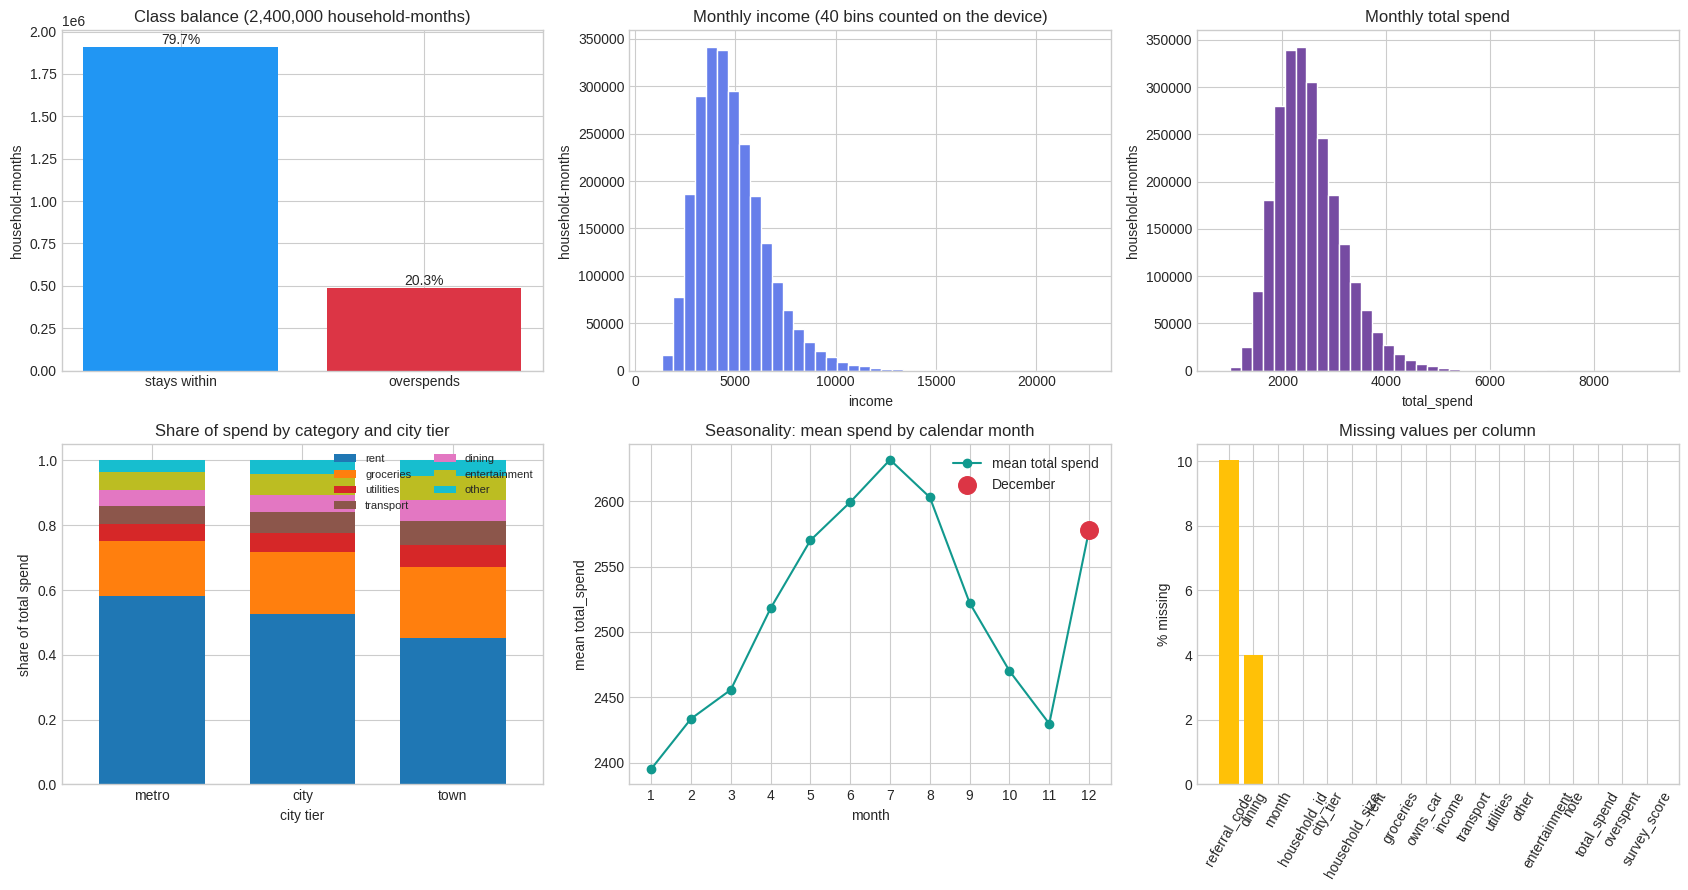

highest mean spend: month 7 (2,632); December is +2.6% versus the other months' average and ranks 4 of 12
columns with gaps: referral_code (10.0%), dining (4.0%)
bytes moved to the host for these six figures: about 1,720 (the frame is 696 MB)


In [25]:
balance = to_host(eda_class_balance(gbig)).sort_index()
inc_counts, inc_edges = (to_np(a) for a in eda_income_hist(gbig))
sp_counts, sp_edges = (to_np(a) for a in eda_spend_hist(gbig))
season = to_host(eda_seasonality(gbig))
cat_tier = to_host(eda_cat_by_tier(gbig)).loc[["metro", "city", "town"]]
cat_share = cat_tier.div(cat_tier.sum(axis=1), axis=0)
missing = to_host(eda_missingness(gbig)).sort_values(ascending=False)

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
ax = axes[0, 0]
ax.bar(["stays within", "overspends"], balance.values, color=["#2196F3", "#dc3545"])
ax.set_title(f"Class balance ({len(gbig):,} household-months)"); ax.set_ylabel("household-months")
for i, v in enumerate(balance.values):
    ax.text(i, v, f"{v / balance.sum():.1%}", ha="center", va="bottom")
ax = axes[0, 1]
ax.bar(inc_edges[:-1], inc_counts, width=np.diff(inc_edges), align="edge", color="#667eea", edgecolor="white")
ax.set_title("Monthly income (40 bins counted on the device)"); ax.set_xlabel("income"); ax.set_ylabel("household-months")
ax = axes[0, 2]
ax.bar(sp_edges[:-1], sp_counts, width=np.diff(sp_edges), align="edge", color="#764ba2", edgecolor="white")
ax.set_title("Monthly total spend"); ax.set_xlabel("total_spend"); ax.set_ylabel("household-months")
ax = axes[1, 0]
cat_share.plot.bar(stacked=True, ax=ax, colormap="tab10", width=0.7)
ax.set_title("Share of spend by category and city tier"); ax.set_ylabel("share of total spend"); ax.set_xlabel("city tier")
ax.tick_params(axis="x", rotation=0); ax.legend(fontsize=8, ncol=2, loc="upper right")
ax = axes[1, 1]
ax.plot(season.index, season.values, marker="o", color="#11998e", label="mean total spend")
ax.scatter([12], [season.loc[12]], s=160, color="#dc3545", zorder=3, label="December")
ax.set_title("Seasonality: mean spend by calendar month"); ax.set_xlabel("month"); ax.set_ylabel("mean total_spend"); ax.set_xticks(range(1, 13)); ax.legend()
ax = axes[1, 2]
ax.bar(missing.index, missing.values * 100, color=np.where(missing.values > 0, "#ffc107", "#cccccc"))
ax.set_title("Missing values per column"); ax.set_ylabel("% missing"); ax.tick_params(axis="x", rotation=60)
plt.tight_layout(); plt.show()
print(f"highest mean spend: month {season.idxmax()} ({season.max():,.0f}); December is {season.loc[12] / season.drop(12).mean() - 1:+.1%} versus the other months' average and ranks {int((season > season.loc[12]).sum()) + 1} of 12")
print(f"columns with gaps: {', '.join(f'{c} ({v:.1%})' for c, v in missing[missing > 0].items())}")
print(f"bytes moved to the host for these six figures: about {(balance.nbytes + inc_counts.nbytes + inc_edges.nbytes + sp_counts.nbytes + sp_edges.nbytes + season.values.nbytes + cat_share.values.nbytes + missing.values.nbytes):,} (the frame is {frame_mb(gbig):.0f} MB)")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Six standard EDA views of 2.4 million household-months, none of which moved more than a few hundred bytes to the host. The class balance shows the minority class the classifier in Part 4 has to find; the two histograms show a right-skewed income and a right-skewed spend (a lognormal income drives both); the stacked bar shows rent taking the largest share in the metro tier and the smallest in towns, exactly the structure the generator planted; the seasonality line is a smooth annual wave with a separate December bump (the generator adds one on top of the wave; the printed line says which month is highest and where December ranks); the missingness bar shows two columns with gaps, `dining` and `referral_code`, and nothing else.

**The common misread:** treating the histogram bars as "40 rows sampled". They are counts of all 2.4 million rows, binned on the device. Nothing here is a sample.

</div>

## 6.4 The correlation heatmap

The heatmap is the one figure people most often draw from a host copy of the whole table. It needs a 12 × 12 matrix and nothing more.


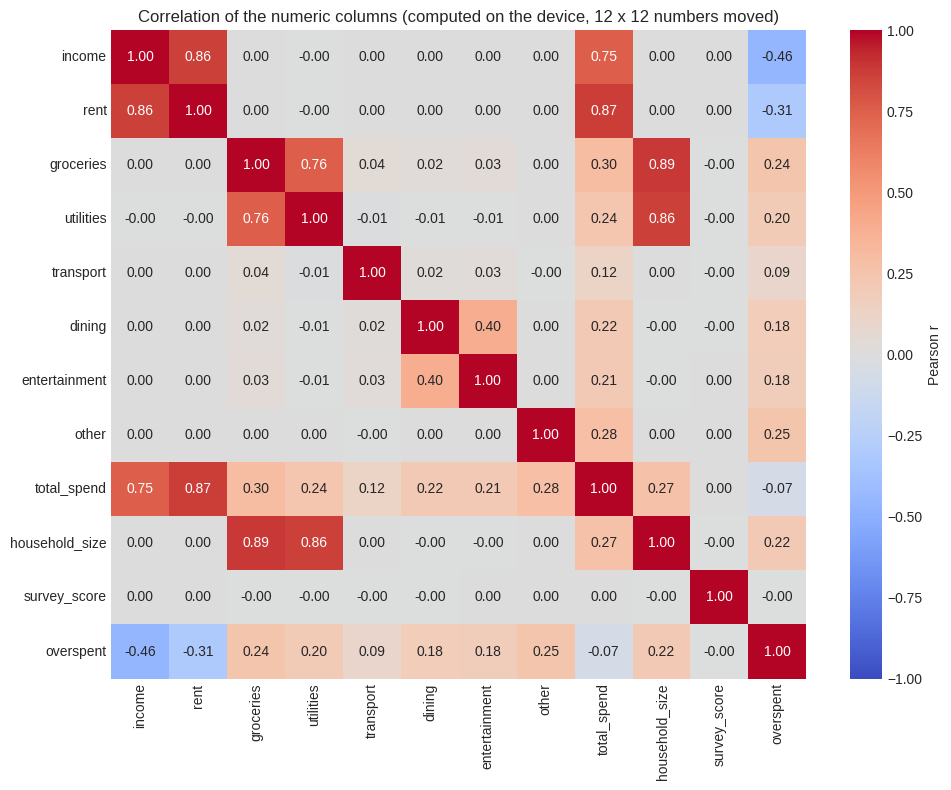

strongest correlations with `overspent` this month: income (-0.46), rent (-0.31), other (+0.25), groceries (+0.24)
dining vs entertainment: r = 0.40 (the generator adds a share of dining into entertainment)


In [26]:
corr = to_host(eda_corr(gbig))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax, cbar_kws={"label": "Pearson r"})
ax.set_title("Correlation of the numeric columns (computed on the device, 12 x 12 numbers moved)")
plt.tight_layout(); plt.show()
top = corr["overspent"].drop("overspent").abs().sort_values(ascending=False)
print("strongest correlations with `overspent` this month:", ", ".join(f"{c} ({corr.loc[c, 'overspent']:+.2f})" for c in top.index[:4]))
print(f"dining vs entertainment: r = {corr.loc['dining', 'entertainment']:.2f} (the generator adds a share of dining into entertainment)")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Pearson correlation between every pair of numeric columns. `total_spend` correlates with each category because it is their sum; `rent` and `income` move together because rent is a fraction of income in every tier; `dining` and `entertainment` correlate because the generator adds part of one into the other. The `overspent` row is the useful one for Part 4: which columns move with the target this month.

**The common misread:** reading the `overspent` row as feature importance for *next* month. This is this month's flag against this month's columns. Part 4 predicts next month, and a strong same-month correlation does not guarantee a strong next-month signal.

</div>

## 6.5 Task 6 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- Reduce on the device, move the result, draw on the host. The bytes moved for six figures are a rounding error next to the frame.
- The same aggregation code runs on cuDF and pandas; `xdf`, `xp` and `to_host` are the only switches.
- Time aggregations with a warm-up and a `synchronize`, and report the row count next to every speed-up.
- cuDF `corr()` refuses missing values; fill or drop first.

### 🔑 New variables

| Variable | What it is |
|---|---|
| `xdf`, `xp` | frame library (`cudf`/`pandas`) and array library (`cupy`/`numpy`) for the current path |
| `to_host`, `to_np`, `sync`, `bench`, `frame_mb`, `gpu_used_mb`, `free_gpu` | the GPU-contract helpers used in every later cell |
| `big`, `gbig` | the 2.4 M-row budget on the host and on the device (the same object on the CPU path) |
| `CATS`, `NUM`, `EDA_OPS`, `eda_times` | category columns, numeric columns, the aggregation functions and their timing table |

### ➡️ Next Up

Task 7 runs the same operations on 1 500 rows, where the GPU loses, and shows the sampling trick for scatter plots.

</div>


# Task 7 · Small Data, and the Sampling Trick

## 7.1 The honesty check: 1 500 rows

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Fixed costs

Every cuDF operation launches one or more GPU kernels, and each launch has a fixed cost that does not depend on the number of rows. On 2.4 million rows that cost disappears into the arithmetic. On 1 500 rows it *is* the runtime, while pandas finishes the whole job in the time the GPU needs to start. The `hh` table from Part 0 has 1 500 households, so it is the right place to see this.

</div>


In [27]:
ghh = cudf.from_pandas(hh) if GPU else hh
HH_OPS = {"class balance (value_counts)": lambda df: df[LABEL_CLS].value_counts(),
          "income histogram (40 bins)": lambda df: hist(df["income"].values, bins=40),
          "spend by tier (groupby mean)": lambda df: df.groupby("city_tier")["total_spend"].mean(),
          "missingness (isna.mean)": lambda df: df.isna().mean(),
          "correlation (numeric)": lambda df: df[[c for c in NUM if c in df.columns]].fillna(df[[c for c in NUM if c in df.columns]].median()).corr()}
small_times = compare_ops(HH_OPS, ghh, hh)
print(f"{'GPU vs CPU' if GPU else 'CPU only'} on {len(hh):,} rows (hh)")
print(small_times.round(2).to_string())
if GPU:
    wins = int((small_times["speed-up"] > 1).sum())
    print(f"\nGPU wins on {wins} of {len(small_times)} ops; median speed-up {small_times['speed-up'].median():.2f}x (below 1 means pandas was faster)")
    both = pd.DataFrame({"2.4 M rows": eda_times["speed-up"], "1 500 rows": small_times["speed-up"]})
    print("\nspeed-up by data size (ops present in both tables):")
    print(both.dropna().round(2).to_string())


CPU only on 1,500 rows (hh)
                              GPU ms  CPU ms  speed-up
op                                                    
class balance (value_counts)     NaN    0.17       NaN
income histogram (40 bins)       NaN    0.13       NaN
spend by tier (groupby mean)     NaN    0.37       NaN
missingness (isna.mean)          NaN    0.49       NaN
correlation (numeric)            NaN    4.24       NaN


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ A speed-up below 1 is not a bug

The speed-ups above sit below 1 for most or all of the small-table operations: pandas needs a few milliseconds, cuDF needs a few more. There is nothing to tune. The frame is too small to fill the GPU, and the fixed launch cost dominates. The same table on 2.4 million rows (Task 6) is where the GPU earns its place. Keep small lookup tables and per-household summaries in pandas unless they need to join a large device frame.

</div>

## 7.2 The sampling trick for scatter plots

Histograms and group means reduce on the device. A scatter plot does not: it needs individual points. But it does not need all of them. A scatter of 2.4 million points is a solid blob that hides everything, and matplotlib takes seconds to draw it. `sample(n=50_000)` on the device picks the rows on the GPU and moves only those.

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: never `to_pandas()` the whole frame to draw it

The cell below measures what the forbidden move costs, once, so the number is real: the full copy and the sampled copy, side by side. The sample is what gets drawn.

</div>


⏱️ the forbidden move: to_host() of all 2,400,000 rows (no-op on the CPU path): 0.00 s


⏱️ gbig.sample(n=50_000) on the device, then to_host(): 0.08 s
host memory: whole frame 696 MB vs sample 14.9 MB  |  sample positive rate 20.1% vs frame 20.3%


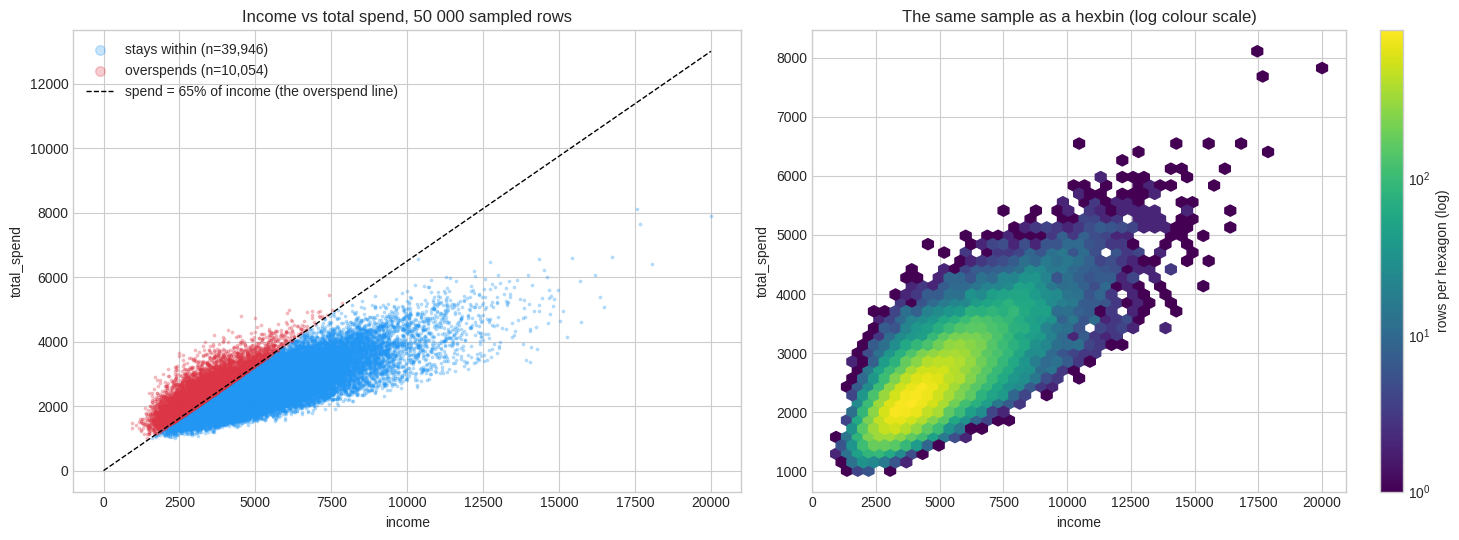

drawn: 50,000 points in 632 hexagons


In [28]:
with timer(f"the forbidden move: to_host() of all {len(gbig):,} rows" + ("" if GPU else " (no-op on the CPU path)")):
    whole = to_host(gbig)
whole_mb = frame_mb(whole); del whole; gc.collect()
with timer("gbig.sample(n=50_000) on the device, then to_host()"):
    smp = to_host(gbig.sample(n=50_000, random_state=RANDOM_STATE))
print(f"host memory: whole frame {whole_mb:.0f} MB vs sample {frame_mb(smp):.1f} MB  |  sample positive rate {smp['overspent'].mean():.1%} vs frame {float(gbig['overspent'].mean()):.1%}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
ax = axes[0]
for flag, color, label in [(0, "#2196F3", "stays within"), (1, "#dc3545", "overspends")]:
    part = smp[smp["overspent"] == flag]
    ax.scatter(part["income"], part["total_spend"], s=3, alpha=0.25, color=color, label=f"{label} (n={len(part):,})")
lim = smp["income"].max()
ax.plot([0, lim], [0, 0.65 * lim], color="black", linestyle="--", linewidth=1, label="spend = 65% of income (the overspend line)")
ax.set_title("Income vs total spend, 50 000 sampled rows"); ax.set_xlabel("income"); ax.set_ylabel("total_spend"); ax.legend(markerscale=4)
ax = axes[1]
hb = ax.hexbin(smp["income"], smp["total_spend"], gridsize=45, cmap="viridis", mincnt=1, bins="log")
ax.set_title("The same sample as a hexbin (log colour scale)"); ax.set_xlabel("income"); ax.set_ylabel("total_spend")
fig.colorbar(hb, ax=ax, label="rows per hexagon (log)")
plt.tight_layout(); plt.show()
print(f"drawn: {len(smp):,} points in {len(hb.get_offsets()):,} hexagons")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: 50 000 device-sampled household-months, coloured by this month's overspend flag, with the generator's rule (spend above 65% of income) drawn as a dashed line. Red points sit above the line by construction. Right: the same points as a hexbin, which replaces overplotting with a density colour so the dense low-income core stays readable.

**The common misread:** believing the scatter shows the whole population. It shows a uniform random sample; the sample's positive rate printed above matches the frame's, which is the check that the sample is representative. Rare tails (the highest incomes) may have very few points.

</div>

## 7.3 A pairplot-lite and the byte math

How many rows *can* you move? The arithmetic is rows × columns × bytes per value. The cell computes it for the frame sizes in this notebook and compares the estimate with the measured device size, which differs because string columns and booleans are not 8 bytes per value.


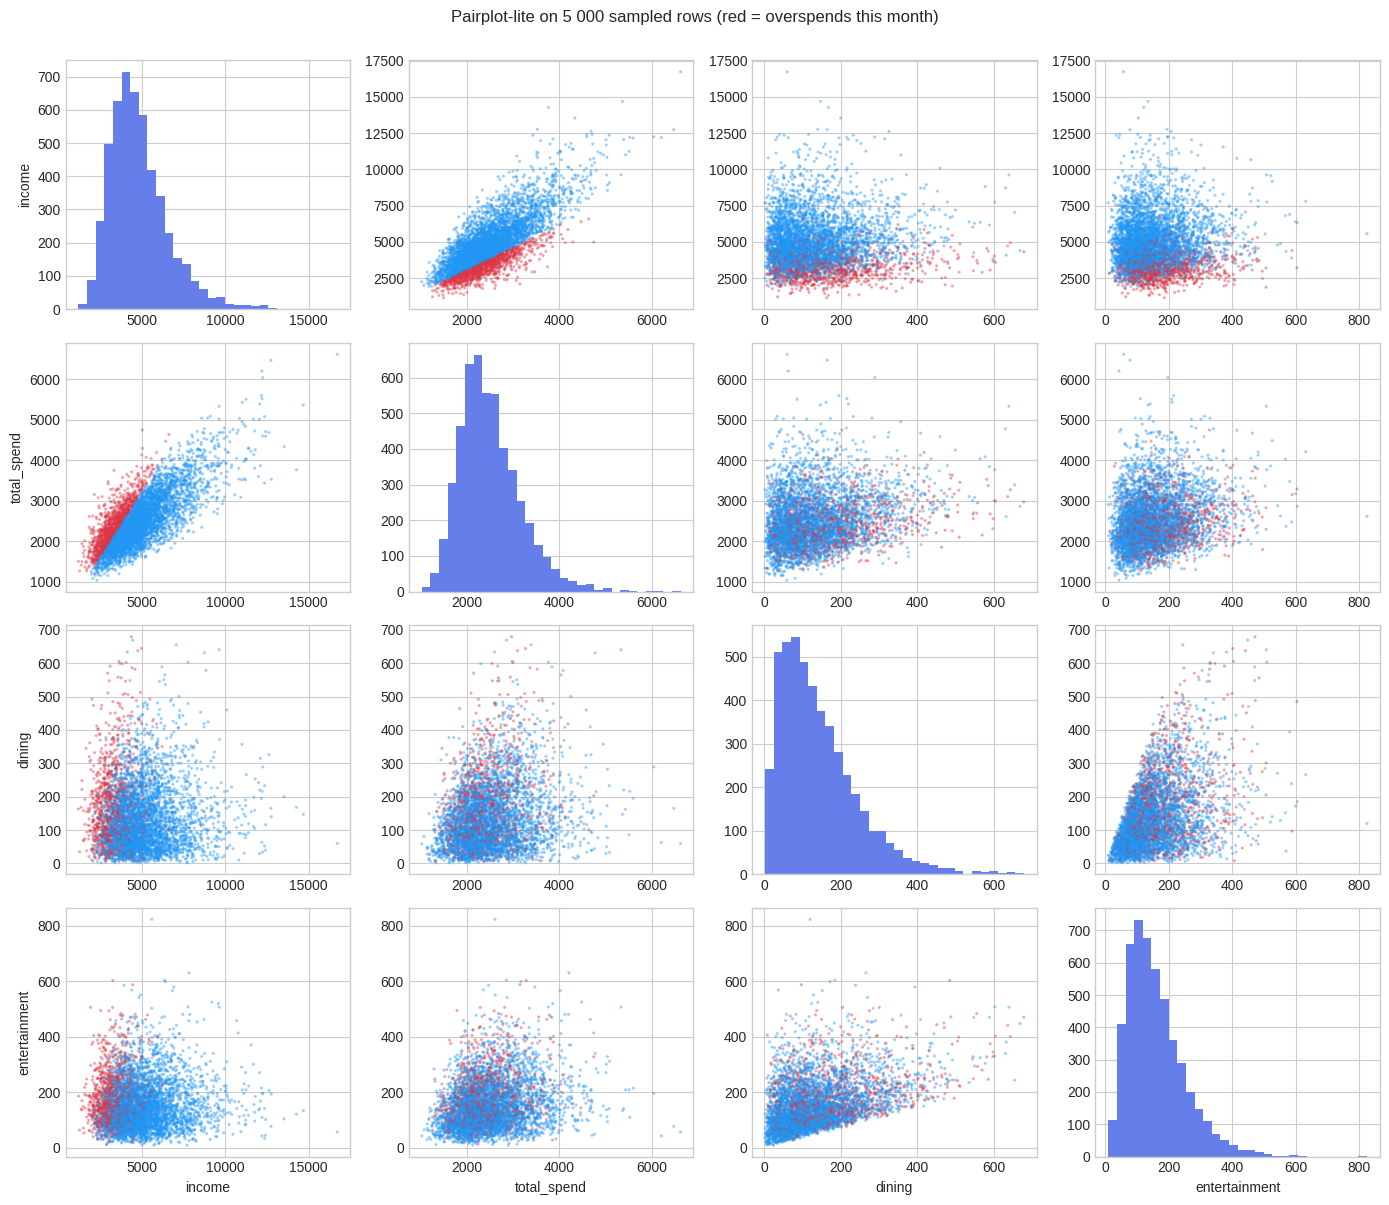

   rows  columns  estimate MB (rows x cols x 8 B)            verdict
   1000       18                            0.144        move freely
  10000       18                            1.440        move freely
 100000       18                           14.400        move freely
1000000       18                          144.000 move once, keep it
2400000       18                          345.600 move once, keep it

measured: the 2,400,000-row frame is 696 MB on the device (strings and booleans are not 8 bytes each)
GPU in use after the cleanup (all processes): 0 MB


In [29]:
cols4 = ["income", "total_spend", "dining", "entertainment"]
pp = smp.sample(n=5_000, random_state=RANDOM_STATE)
fig, axes = plt.subplots(4, 4, figsize=(14, 12))
for i, ci in enumerate(cols4):
    for j, cj in enumerate(cols4):
        ax = axes[i, j]
        if i == j:
            ax.hist(pp[ci].dropna(), bins=30, color="#667eea")
        else:
            ax.scatter(pp[cj], pp[ci], s=2, alpha=0.3, c=np.where(pp["overspent"] == 1, "#dc3545", "#2196F3"))
        if i == 3: ax.set_xlabel(cj)
        if j == 0: ax.set_ylabel(ci)
fig.suptitle("Pairplot-lite on 5 000 sampled rows (red = overspends this month)", y=1.0)
plt.tight_layout(); plt.show()

n_cols = gbig.shape[1]
byte_math = pd.DataFrame({"rows": [1_000, 10_000, 100_000, 1_000_000, len(gbig)]})
byte_math["columns"] = n_cols
byte_math["estimate MB (rows x cols x 8 B)"] = byte_math["rows"] * n_cols * 8 / 1e6
byte_math["verdict"] = np.where(byte_math["estimate MB (rows x cols x 8 B)"] < 50, "move freely", np.where(byte_math["estimate MB (rows x cols x 8 B)"] < 500, "move once, keep it", "aggregate or sample first"))
print(byte_math.to_string(index=False))
print(f"\nmeasured: the {len(gbig):,}-row frame is {frame_mb(gbig):.0f} MB on the device (strings and booleans are not 8 bytes each)")
del ghh, smp, pp, gbig
free_gpu()
print(f"GPU in use after the cleanup (all processes): {gpu_used_mb():.0f} MB")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

A 4 × 4 grid of the spending columns on 5 000 sampled rows: histograms on the diagonal, scatter plots off it. `dining` against `entertainment` shows the planted linear component; `income` against `total_spend` shows the overspend band. Five thousand points is enough to see every one of these shapes.

**The common misread:** using the pairplot to judge how *common* a pattern is. Sampled scatters show shapes, not frequencies; the histograms in Task 6, computed on every row, are the frequency view.

</div>

## 7.4 Task 7 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- On 1 500 rows pandas wins or ties: the fixed cost of launching GPU work is the whole runtime. Report data size with every speed-up.
- Scatter plots need points, not aggregates: `sample(n=...)` on the device, then move the sample.
- The byte math is rows × columns × bytes per value; check it against `memory_usage(deep=True)` because strings and booleans break the 8-byte rule.
- `del` the device frames you no longer need and free the pools; `nvidia-smi` reports the whole device, so other processes count too.

### 🔑 New variables

| Variable | What it is |
|---|---|
| `HH_OPS`, `small_times` | the EDA operations on the 1 500-row `hh` table and their GPU vs CPU timings |
| `byte_math` | the host-copy budget table by row count |

### ➡️ Next Up

Part 4 turns the budget into a classification problem on the GPU: preprocessing for cuML, five classifiers with the scikit-learn API, and every metric family computed two ways.

</div>


# Part 4 · cuML Classification: the scikit-learn API on the GPU; All the Metrics ⭐⭐

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Big Picture

cuML implements the scikit-learn estimator API: `fit`, `predict`, `predict_proba`, the same constructor names, the same attribute names where it can. What changes is the input: a cuDF frame or a CuPy array already on the device, in `float32`, with no strings. Task 8 builds that input from the household table. Task 9 trains five classifiers on 150 000 households and times each against its scikit-learn twin on the same data. Task 10 computes the threshold, ranking and probabilistic metric families on the device with `cuml.metrics` and by hand with CuPy, and checks every number against scikit-learn on the host.

</div>


# Task 8 · Preprocessing for cuML

## 8.1 What a cuML estimator will and will not eat

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Numbers only, and preferably small ones

A GPU estimator receives a matrix. It accepts a cuDF DataFrame, a CuPy array, a NumPy array (copied to the device for you) and a few other array-like inputs. It does **not** accept strings or `category` columns, and it will tell you so with a `ValueError`. Boolean columns are fine (they cast to 0 and 1). Missing values are not fine for most estimators, so impute first.

Why `float32`? Half the bytes of `float64`, so twice the rows fit and every memory-bound kernel moves half the data; consumer and T4-class GPUs also have many more `float32` than `float64` arithmetic units, which matters for compute-bound kernels. The precision loss is irrelevant for spend values in the thousands. Cell 8.3 measures both effects on this problem.

</div>

The cell builds the 200 000-household table from the large budget, shows the two dtype errors on purpose, then does the real preprocessing: impute, one-hot, cast, split, scale.


In [30]:
with timer("household_table() on the 2.4 M-row budget (pandas, on the host)"):
    hh_big = household_table(big)
del big; gc.collect()
ghh_big = cudf.from_pandas(hh_big) if GPU else hh_big
print(f"households: {len(ghh_big):,}  |  positive rate ({LABEL_CLS}): {float(ghh_big[LABEL_CLS].mean()):.1%}  |  device frame {frame_mb(ghh_big):.0f} MB")
print("\ncolumn dtypes:", ", ".join(f"{c}:{t}" for c, t in ghh_big.dtypes.astype(str).items()))

if GPU:
    from cuml.linear_model import LogisticRegression
else:
    from sklearn.linear_model import LogisticRegression

# the dtype traps, shown on purpose (first 2 000 rows are enough to trigger them)
probe = ghh_big.iloc[:2000]
for label, cols_or_frame in [("string column `city_tier`", probe[["income", "city_tier"]]),
                             ("boolean column `owns_car`", probe[["income", "owns_car"]])]:
    try:
        LogisticRegression().fit(cols_or_frame, probe[LABEL_CLS])
        print(f"OK    : {label} was accepted")
    except Exception as e:  # noqa: BLE001 - the point is to show the message
        print(f"ERROR : {label} -> {type(e).__name__}: {str(e)[:90]}")


⏱️ household_table() on the 2.4 M-row budget (pandas, on the host): 0.52 s


households: 200,000  |  positive rate (overspent_next): 20.5%  |  device frame 64 MB

column dtypes: household_id:int64, city_tier:object, household_size:int64, owns_car:bool, income:float64, rent:float64, groceries:float64, utilities:float64, transport:float64, dining:float64, entertainment:float64, other:float64, note:object, total_spend:float64, overspent:int64, survey_score:int64, referral_code:object, avg_spend_prev:float64, overspend_rate_prev:float64, max_dining_prev:float64, spend_next:float64, overspent_next:int64
ERROR : string column `city_tier` -> ValueError: could not convert string to float: 'town'


OK    : boolean column `owns_car` was accepted


## 8.2 Impute, one-hot, cast, split, scale

`cudf.get_dummies` mirrors `pd.get_dummies` and takes a `dtype` so the indicator columns are born as `float32`. `cuml.model_selection.train_test_split` mirrors scikit-learn's, including `stratify`. `cuml.preprocessing.StandardScaler` returns a cuDF frame when given one. `cuml.preprocessing.OneHotEncoder` exists too and returns a CuPy array; the cell shows it in one line for the pipeline-minded (Part 5 uses it).

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Fit the scaler on the training split only

Scaling with statistics from the whole table leaks the test rows' means into training. The order below is split first, then `fit_transform` on train and `transform` on test. cuML does not stop you from doing it the wrong way round.

</div>


In [31]:
DROP = [ID_COL, LABEL_CLS, LABEL_REG, "note"]          # note is free text: Part 2 covered string ops, a classifier needs numbers
X = ghh_big[[c for c in ghh_big.columns if c not in DROP]].copy()
for c in ["dining", "max_dining_prev"]:                  # impute with the median (the gaps came from the export)
    X[c] = X[c].fillna(X[c].median())
X["referral_code"] = X["referral_code"].fillna("none")   # a missing code is its own category
X = xdf.get_dummies(X, columns=["city_tier", "referral_code"], dtype="float32")
X = X.astype("float32")                                   # booleans and int64 counts become float32 too
y = ghh_big[LABEL_CLS].astype("int32")
FEAT_COLS = list(X.columns)

if GPU:
    from cuml.model_selection import train_test_split as tts
    from cuml.preprocessing import StandardScaler, OneHotEncoder
else:
    from sklearn.model_selection import train_test_split as tts
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
Xtr_raw, Xte_raw, ytr, yte = tts(X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)
if not GPU:  # sklearn keeps the shuffled index; reset so .iloc and positional slices behave the same as on the GPU
    Xtr_raw, Xte_raw, ytr, yte = (o.reset_index(drop=True) for o in (Xtr_raw, Xte_raw, ytr, yte))

scaler = StandardScaler()
Xtr = scaler.fit_transform(Xtr_raw)
Xte = scaler.transform(Xte_raw)
if not GPU:  # sklearn returns numpy; keep frames so both paths look alike
    Xtr, Xte = pd.DataFrame(Xtr, columns=FEAT_COLS), pd.DataFrame(Xte, columns=FEAT_COLS)

ohe_demo = OneHotEncoder(sparse_output=False).fit_transform(ghh_big[["city_tier"]].iloc[:5])
print(f"path: {'GPU' if GPU else 'CPU'}  |  X {X.shape[0]:,} x {X.shape[1]}  all {set(X.dtypes.astype(str))}  |  train {len(Xtr):,} / test {len(Xte):,}")
print(f"positive rate: train {float(ytr.mean()):.2%}  test {float(yte.mean()):.2%}  (stratified)")
print(f"features: {FEAT_COLS}")
print(f"scaled train column means (first 5): {np.round(to_np(Xtr.mean())[:5], 4)}  |  OneHotEncoder output type: {type(ohe_demo).__name__}, shape {ohe_demo.shape}")
print(f"device memory for Xtr + Xte: {frame_mb(Xtr) + frame_mb(Xte):.0f} MB  |  GPU in use (all processes): {gpu_used_mb():.0f} MB")


path: CPU  |  X 200,000 x 23  all {'float32'}  |  train 150,000 / test 50,000
positive rate: train 20.51%  test 20.51%  (stratified)
features: ['household_size', 'owns_car', 'income', 'rent', 'groceries', 'utilities', 'transport', 'dining', 'entertainment', 'other', 'total_spend', 'overspent', 'survey_score', 'avg_spend_prev', 'overspend_rate_prev', 'max_dining_prev', 'city_tier_city', 'city_tier_metro', 'city_tier_town', 'referral_code_A1', 'referral_code_B2', 'referral_code_C3', 'referral_code_none']
scaled train column means (first 5): [ 0. -0.  0. -0.  0.]  |  OneHotEncoder output type: ndarray, shape (5, 3)
device memory for Xtr + Xte: 18 MB  |  GPU in use (all processes): 0 MB


## 8.3 float32 versus float64, measured

The claim "float32 is faster on the GPU" deserves a number. The cell fits the same logistic regression on the training matrix in both dtypes, after a warm-up, and prints memory and time.


In [32]:
Xtr64 = Xtr.astype("float64")
rows = []
for label, Xm in [("float64", Xtr64), ("float32", Xtr)]:
    LogisticRegression(max_iter=1000).fit(Xm.iloc[:2000], ytr.iloc[:2000])  # warm-up
    ms = bench(lambda: LogisticRegression(max_iter=1000).fit(Xm, ytr), repeat=3)
    rows.append({"dtype": label, "matrix MB": frame_mb(Xm), "fit ms (median of 3)": ms})
dtype_table = pd.DataFrame(rows).set_index("dtype")
print(f"LogisticRegression on {len(Xtr):,} x {Xtr.shape[1]} ({'GPU' if GPU else 'CPU'} path)")
print(dtype_table.round(1).to_string())
print(f"float32 uses {dtype_table.loc['float64', 'matrix MB'] / dtype_table.loc['float32', 'matrix MB']:.1f}x less memory and fits in {dtype_table.loc['float64', 'fit ms (median of 3)'] / dtype_table.loc['float32', 'fit ms (median of 3)']:.2f}x the time of float64 (below 1 means float64 was faster on this run)")
del Xtr64; free_gpu()


LogisticRegression on 150,000 x 23 (CPU path)
         matrix MB  fit ms (median of 3)
dtype                                   
float64       27.6                 592.0
float32       13.8                 591.0
float32 uses 2.0x less memory and fits in 1.00x the time of float64 (below 1 means float64 was faster on this run)


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: cast once, at the end of preprocessing

Do the imputation and the one-hot in whatever dtype the columns arrive in, then one `astype("float32")` on the finished matrix. Casting early makes every later `fillna` and `get_dummies` re-promote columns, and mixing `int64`, `bool` and `float32` columns in one frame makes cuML copy the whole matrix into one dtype at `fit` time anyway. The memory halving above is guaranteed; the speed gain is workload-dependent and the printed ratio is what this run measured.

</div>

## 8.4 Task 8 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- cuML estimators take numeric device inputs: strings and `category` columns raise a `ValueError`, booleans are fine, missing values must be imputed.
- `get_dummies`, `train_test_split(stratify=)`, `StandardScaler` and `OneHotEncoder` all have cuDF/cuML twins with the same signatures.
- Split before scaling; fit the scaler on train only.
- `float32` halves memory for certain; the speed ratio is whatever the cell measured.

### 🔑 New variables

| Variable | What it is |
|---|---|
| `hh_big`, `ghh_big` | the 200 000-household table on the host and on the device |
| `X`, `y`, `FEAT_COLS` | the numeric feature matrix (float32), the int32 label, the feature names |
| `Xtr`, `Xte`, `ytr`, `yte` | the stratified, scaled train/test split (device frames on the GPU path) |
| `scaler`, `dtype_table` | the fitted `StandardScaler` and the float32 vs float64 measurement |

### ➡️ Next Up

Task 9 fits five classifiers on this split with the scikit-learn API and times them against scikit-learn.

</div>


# Task 9 · The Model Zoo with the scikit-learn API

## 9.1 Five classifiers, one loop

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Same names, same calls

`cuml.linear_model.LogisticRegression`, `cuml.ensemble.RandomForestClassifier`, `cuml.neighbors.KNeighborsClassifier`, `cuml.svm.SVC` and `cuml.naive_bayes.GaussianNB` are constructed and called like their scikit-learn namesakes. The loop below does not know which library it is running: it calls `fit`, `predict` and `predict_proba` and hands the results to `report_card` on the host.

One documented difference matters here: in cuML 26.08 `SVC` has no `probability` argument and no `predict_proba`. It has `decision_function`, which is a score, not a probability. Ranking metrics (ROC-AUC, PR-AUC) work on scores; probabilistic metrics (log loss, Brier) do not. The SVC row shows `-` for those, honestly.

</div>


In [33]:
if GPU:
    from cuml.ensemble import RandomForestClassifier
    from cuml.neighbors import KNeighborsClassifier
    from cuml.svm import SVC
    from cuml.naive_bayes import GaussianNB
else:
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.svm import SVC
    from sklearn.naive_bayes import GaussianNB

def make_zoo():
    return {"LogisticRegression": LogisticRegression(max_iter=1000),
            "RandomForest": RandomForestClassifier(n_estimators=100, max_depth=12, random_state=RANDOM_STATE),
            "KNeighbors": KNeighborsClassifier(n_neighbors=25)}

SVC_ROWS = 10_000   # an RBF SVC scales roughly with the square of the rows; both libraries get the same 10 000 rows so the timing is fair
def fit_predict(model, Xa, ya, Xb):
    # fit, predict labels, and predict a score: P(class 1) when the model has predict_proba, else decision_function
    # reset indices or convert to numpy to prevent cuML output coercion bugs
    Xa_clean = Xa.reset_index(drop=True) if hasattr(Xa, 'reset_index') else Xa
    ya_clean = ya.reset_index(drop=True) if hasattr(ya, 'reset_index') else ya
    Xb_clean = Xb.reset_index(drop=True) if hasattr(Xb, 'reset_index') else Xb

    model.fit(Xa_clean, ya_clean); sync()
    pred = to_np(model.predict(Xb_clean))
    if hasattr(model, "predict_proba"):
        score = to_np(model.predict_proba(Xb_clean))[:, 1].astype(np.float64); kind = "probability"
        PROBA_OVERSHOOT[type(model).__name__] = max(float(score.max()) - 1.0, 0.0 - float(score.min()))   # float32 rounding can leave 1.0000001
        score = np.clip(score, 0.0, 1.0)                                                                    # sklearn's log_loss/brier refuse values above 1
    else:
        score = to_np(model.decision_function(Xb_clean)); kind = "score"
    return pred, score, kind

zoo, cards, gpu_times, scores, PROBA_OVERSHOOT = make_zoo(), [], {}, {}, {}
yte_np = to_np(yte)
for name, model in zoo.items():
    n = SVC_ROWS if name.startswith("SVC") else len(Xtr)
    Xa, ya, Xb = Xtr.iloc[:n], ytr.iloc[:n], (Xte.iloc[:n] if name.startswith("SVC") else Xte)
    # warm-up on a slice (JIT, allocation), ensuring indices are cleanly reset
    fit_predict(make_zoo()[name], Xa.iloc[:2000].reset_index(drop=True), ya.iloc[:2000].reset_index(drop=True), Xb.iloc[:500].reset_index(drop=True))
    t0 = time.perf_counter(); model.fit(Xa.reset_index(drop=True), ya.reset_index(drop=True)); sync(); t_fit = time.perf_counter() - t0
    t0 = time.perf_counter(); pred, score, kind = fit_predict(model, Xa, ya, Xb); sync(); t_all = t_fit + (time.perf_counter() - t0)
    y_eval = yte_np[:len(pred)]
    card = report_card(y_eval, pred, score if kind == "probability" else None, name=name)
    if kind == "score":
        card["roc_auc"] = roc_auc_score(y_eval, score); card["pr_auc"] = average_precision_score(y_eval, score)
    cards.append(card); scores[name] = (y_eval, score, kind)
    gpu_times[name] = {"rows": n, "fit s": t_fit, "fit+predict+proba s": t_all}
    print(f"{name:<20} rows {n:>7,}  fit {t_fit:6.2f} s  fit+predict+score {t_all:6.2f} s  ({kind})")
zoo_cards = pd.concat(cards)
print(f"\n{'cuML on the GPU' if GPU else 'scikit-learn on the CPU (no GPU)'}; metrics computed on the host by report_card")
over = {k: v for k, v in PROBA_OVERSHOOT.items() if v > 0}
print("predict_proba values outside [0, 1] before clipping:", {k: f"{v:.1e}" for k, v in over.items()} if over else "none")
display(pretty(zoo_cards))

LogisticRegression   rows 150,000  fit   0.60 s  fit+predict+score   1.17 s  (probability)


RandomForest         rows 150,000  fit  36.68 s  fit+predict+score  74.78 s  (probability)


KNeighbors           rows 150,000  fit   0.02 s  fit+predict+score  45.24 s  (probability)

scikit-learn on the CPU (no GPU); metrics computed on the host by report_card
predict_proba values outside [0, 1] before clipping: none


,accuracy,balanced_acc,precision,recall,f1,mcc,roc_auc,pr_auc,log_loss,brier
model,,,,,,,,,,
LogisticRegression,0.902,0.825,0.803,0.694,0.745,0.688,0.939,0.843,0.238,0.072
RandomForest,0.902,0.815,0.820,0.667,0.736,0.682,0.937,0.840,0.240,0.072
KNeighbors,0.896,0.803,0.809,0.646,0.718,0.662,0.923,0.801,0.303,0.077


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ A probability of 1.0000001

The line above the table lists the models whose `predict_proba` came back a rounding error outside `[0, 1]`. It is `float32` rounding: a fraction such as 25/25 neighbours, or a sum of per-class probabilities, lands one unit in the last place above 1. scikit-learn's `brier_score_loss` and `log_loss` refuse such values with a `ValueError`, which is how this notebook found it. `fit_predict` casts the score to `float64` and clips it to `[0, 1]` before any host metric sees it; do the same in your own code.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Read the accuracy column against the positive rate

The positive rate printed in Task 8 is the accuracy a model gets by predicting "stays within" for everyone. Any accuracy close to one minus that rate is not an achievement. `balanced_acc`, `mcc`, `roc_auc` and `pr_auc` are the columns that separate the models; Task 10 explains why.

</div>

## 9.2 The same five models in scikit-learn, timed on the same rows

On the GPU path this cell fits the scikit-learn twins on the host with the same hyperparameters and the same rows (SVC on its 10 000). On the CPU path there is nothing to compare against, and the cell says so.


In [34]:
from sklearn.linear_model import LogisticRegression as SkLogReg
from sklearn.ensemble import RandomForestClassifier as SkRF
from sklearn.neighbors import KNeighborsClassifier as SkKNN
from sklearn.svm import SVC as SkSVC
from sklearn.naive_bayes import GaussianNB as SkGNB
sk_zoo = {"LogisticRegression": SkLogReg(max_iter=1000),
          "RandomForest": SkRF(n_estimators=100, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),
          "KNeighbors": SkKNN(n_neighbors=25, n_jobs=-1)}
Xtr_np, ytr_np, Xte_np = to_np(Xtr), to_np(ytr), to_np(Xte)
cpu_times = {}
if GPU:
    for name, model in sk_zoo.items():
        n = gpu_times[name]["rows"]
        Xb = Xte_np[:n] if name.startswith("SVC") else Xte_np
        t0 = time.perf_counter(); model.fit(Xtr_np[:n], ytr_np[:n]); t_fit = time.perf_counter() - t0
        t0 = time.perf_counter(); model.predict(Xb); (model.predict_proba(Xb) if hasattr(model, "predict_proba") else model.decision_function(Xb)); t_all = t_fit + time.perf_counter() - t0
        cpu_times[name] = {"fit s": t_fit, "fit+predict+proba s": t_all}
    speed = pd.DataFrame({"rows": {k: v["rows"] for k, v in gpu_times.items()},
                          "GPU fit s": {k: v["fit s"] for k, v in gpu_times.items()},
                          "CPU fit s": {k: v["fit s"] for k, v in cpu_times.items()},
                          "GPU total s": {k: v["fit+predict+proba s"] for k, v in gpu_times.items()},
                          "CPU total s": {k: v["fit+predict+proba s"] for k, v in cpu_times.items()}})
    speed["fit speed-up"] = speed["CPU fit s"] / speed["GPU fit s"]
    speed["total speed-up"] = speed["CPU total s"] / speed["GPU total s"]
    print(f"cuML ({GPU_NAME}) vs scikit-learn ({os.cpu_count()} CPU threads), same rows and hyperparameters")
    print(speed.round(2).to_string())
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    xpos = np.arange(len(speed)); w = 0.38
    for ax, col_g, col_c, title in [(axes[0], "GPU fit s", "CPU fit s", "fit time"), (axes[1], "GPU total s", "CPU total s", "fit + predict + score time")]:
        ax.bar(xpos - w / 2, speed[col_g], w, label="cuML (GPU)", color="#76b900")
        ax.bar(xpos + w / 2, speed[col_c], w, label="scikit-learn (CPU)", color="#607d8b")
        ax.set_yscale("log"); ax.set_xticks(xpos); ax.set_xticklabels([f"{m}\n({r:,} rows)" for m, r in zip(speed.index, speed["rows"])], fontsize=9)
        ax.set_ylabel("seconds (log scale)"); ax.set_title(title); ax.legend()
        for i, (g, c) in enumerate(zip(speed[col_g], speed[col_c])):
            ax.text(i, max(g, c) * 1.15, f"{c / g:.1f}x", ha="center", fontsize=9)
    plt.tight_layout(); plt.show()
    best, worst = speed["total speed-up"].idxmax(), speed["total speed-up"].idxmin()
    print(f"largest total speed-up: {best} {speed.loc[best, 'total speed-up']:.1f}x  |  smallest: {worst} {speed.loc[worst, 'total speed-up']:.1f}x  |  this host CPU has {os.cpu_count()} threads; a Colab CPU runtime has fewer, so its ratios are larger")
else:
    print("CPU path: the zoo above already ran on scikit-learn; there is no second library to time against, so no comparison is drawn.")


CPU path: the zoo above already ran on scikit-learn; there is no second library to time against, so no comparison is drawn.


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Wall time per model, cuML against scikit-learn, on the same rows with the same hyperparameters, log scale, the ratio printed above each pair. The models whose work is "many independent distance or dot-product computations" (nearest neighbours, logistic regression, the RBF kernel) gain the most. Gaussian naive Bayes gains nothing or loses: its whole fit is a handful of per-class means and variances, which pandas-speed NumPy finishes before the GPU has launched its kernels (the Task 7 lesson again, this time for a model). The random forest barely wins: scikit-learn parallelises tree building over every CPU thread on this host, and cuML's forest has its own overheads (histogram binning, per-tree kernel launches).

**The common misread:** treating one ratio as "the GPU speed-up for random forests". It depends on the CPU thread count, the row count (Task 7) and the forest's `n_bins`; the printed thread count is part of the result.

</div>

## 9.3 The random forest is not the same forest

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ `cuml.ensemble.RandomForestClassifier` differs from scikit-learn's

| Setting | scikit-learn | cuML 26.08 | Why it matters |
|---|---|---|---|
| split search | exact, every threshold | **`n_bins=128`** quantile histograms | fewer candidate splits per feature; faster, slightly different trees |
| `split_criterion` | `criterion="gini"` | `split_criterion="gini"` (also `"entropy"`) | different argument name |
| `max_features` | `"sqrt"` | `"sqrt"` | same default, but check when porting older code |
| `max_depth` | `None` (unbounded) | `None` | same; cuML also has `max_leaves` |
| `n_streams` | n/a | `4` CUDA streams | parallel tree building on the device |
| input dtype | float64 | **float32** internally | Task 8 |
| `oob_score`, `class_weight` | yes | yes (26.08) | present, verified with `inspect.signature` |

The `n_bins` knob is the one that changes results. The cell fits two forests that differ only in `n_bins` and reports AUC and time for each, so the trade is a measured one.

</div>


In [35]:
rows = []
for nb in ([16, 128] if GPU else [None]):
    kw = {"n_bins": nb} if GPU else {}
    rf = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=RANDOM_STATE, **kw)
    rf.fit(Xtr.iloc[:2000], ytr.iloc[:2000])  # warm-up
    t0 = time.perf_counter(); rf.fit(Xtr, ytr); sync(); t_fit = time.perf_counter() - t0
    p = to_np(rf.predict_proba(Xte))[:, 1]
    rows.append({"n_bins": nb if GPU else "sklearn (exact splits)", "fit s": t_fit, "roc_auc": roc_auc_score(yte_np, p), "pr_auc": average_precision_score(yte_np, p)})
nbins_table = pd.DataFrame(rows).set_index("n_bins")
print(f"RandomForestClassifier(n_estimators=100, max_depth=12) on {len(Xtr):,} rows, {'GPU' if GPU else 'CPU'} path")
print(nbins_table.round(4).to_string())
if GPU:
    print(f"n_bins 16 -> 128: fit time x{nbins_table.loc[128, 'fit s'] / nbins_table.loc[16, 'fit s']:.2f}, ROC-AUC {nbins_table.loc[128, 'roc_auc'] - nbins_table.loc[16, 'roc_auc']:+.4f}")


RandomForestClassifier(n_estimators=100, max_depth=12) on 150,000 rows, CPU path
                          fit s  roc_auc  pr_auc
n_bins                                          
sklearn (exact splits)  36.7201   0.9373  0.8397


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: port the hyperparameters, then re-validate

A cuML model with the same constructor arguments is a *similar* model, not the *same* model. When you move a scikit-learn forest to the GPU, keep the evaluation split fixed, compare the metric rows side by side (the `report_card` table makes that a one-liner) and only then trust the speed-up. The `n_bins` table is the concrete example: two forests with identical `n_estimators` and `max_depth`, a different fit time, and an AUC that differs (by a small amount here, by more on data with fine-grained thresholds).

</div>

## 9.4 Task 9 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- One loop, five cuML classifiers, the scikit-learn call signature; only the imports differ between the GPU and CPU paths.
- `cuml.svm.SVC` (26.08) has no `predict_proba`; use `decision_function` for ranking metrics and leave the probabilistic ones blank.
- Speed-ups are per model and per host: nearest neighbours, the RBF SVC and logistic regression gain the most; naive Bayes and (on a many-core CPU) the forest gain little or nothing.
- cuML's forest bins its splits (`n_bins`); port hyperparameters, then re-validate on the same split.

### 🔑 New variables

| Variable | What it is |
|---|---|
| `zoo`, `sk_zoo`, `make_zoo` | the fitted cuML models, their scikit-learn twins, and the factory |
| `zoo_cards`, `scores` | the `report_card` table and the per-model `(y_true, score, kind)` used in Task 10 |
| `gpu_times`, `cpu_times`, `speed` | the measured timings and the comparison table |
| `nbins_table` | the `n_bins` trade-off measurement |

### ➡️ Next Up

Task 10 computes every metric family on the device and checks it against scikit-learn.

</div>


# Task 10 · All the Metric Families, Computed Two Ways

## 10.1 Three families and where accuracy lies

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 A metric is a question about the model

- **Threshold metrics** (accuracy, precision, recall, F1, MCC, the confusion matrix) ask: *after I pick a cut-off, how good are the labels?* They change when the threshold changes.
- **Ranking metrics** (ROC-AUC, PR-AUC) ask: *do positives get higher scores than negatives?* They ignore the threshold and work on any score, including an SVC decision value.
- **Probabilistic metrics** (log loss, Brier score, calibration) ask: *when the model says 30%, does it happen 30% of the time?* They need real probabilities.

With one household in five overspending, the "always no" model scores an accuracy of one minus the positive rate without learning anything. That is why the table in Task 9 carries all three families.

</div>

### 📐 The Math (gently)

$$ \text{precision} = \frac{TP}{TP + FP}, \qquad \text{recall} = \frac{TP}{TP + FN}, \qquad F_1 = \frac{2 \cdot \text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}} $$

$$ \text{ROC-AUC} = P(\text{score}_{\text{positive}} > \text{score}_{\text{negative}}), \qquad \text{log loss} = -\frac{1}{n}\sum_i \left[ y_i \log p_i + (1 - y_i) \log (1 - p_i) \right] $$

`cuml.metrics` in 26.08 provides `accuracy_score`, `roc_auc_score`, `log_loss`, `confusion_matrix` and `precision_recall_curve` on device arrays. It does **not** provide `roc_curve`, `precision_score`, `recall_score` or `f1_score` (checked with `hasattr`), so those come from CuPy by hand in 10.2 and 10.3. The first cell computes what cuML has, on the device, and puts every number next to scikit-learn's on the host.


In [36]:
y_true_np, p_lr, _ = scores["LogisticRegression"]
pred_lr = (p_lr >= 0.5).astype(int)
from sklearn.metrics import precision_recall_curve, confusion_matrix as sk_confusion_matrix
if GPU:
    import cuml.metrics as cm
    y_dev, p_dev, pred_dev = cp.asarray(y_true_np), cp.asarray(p_lr), cp.asarray(pred_lr)
    device = {"accuracy": float(cm.accuracy_score(y_dev, pred_dev)),
              "roc_auc": float(cm.roc_auc_score(y_dev, p_dev)),
              "log_loss": float(cm.log_loss(y_dev, p_dev))}
    host = {"accuracy": accuracy_score(y_true_np, pred_lr),
            "roc_auc": roc_auc_score(y_true_np, p_lr),
            "log_loss": log_loss(y_true_np, p_lr)}
    agree = pd.DataFrame({"cuml.metrics (device)": device, "sklearn.metrics (host)": host})
    agree["abs diff"] = (agree.iloc[:, 0] - agree.iloc[:, 1]).abs()
    cm_dev = cm.confusion_matrix(y_dev, pred_dev).get()
    cm_host = sk_confusion_matrix(y_true_np, pred_lr)
    print("LogisticRegression on the test split, threshold 0.5")
    print(agree.round(6).to_string())
    print(f"\nconfusion matrix, device:\n{cm_dev}\nconfusion matrix, host:\n{cm_host}\nidentical: {np.array_equal(cm_dev, cm_host)}")
    print(f"largest disagreement across the three scalar metrics: {agree['abs diff'].max():.2e}")
    prec_dev, rec_dev, thr_dev = (to_np(a) for a in cm.precision_recall_curve(y_dev, p_dev))
    print(f"precision_recall_curve on the device: {len(prec_dev):,} points (the host version has {len(precision_recall_curve(y_true_np, p_lr)[0]):,})")
else:
    print("CPU path: cuml.metrics is not available; the host numbers below are the reference.")
    print(f"accuracy {accuracy_score(y_true_np, pred_lr):.4f}  roc_auc {roc_auc_score(y_true_np, p_lr):.4f}  log_loss {log_loss(y_true_np, p_lr):.4f}")
    print(sk_confusion_matrix(y_true_np, pred_lr))


CPU path: cuml.metrics is not available; the host numbers below are the reference.
accuracy 0.9024  roc_auc 0.9386  log_loss 0.2383
[[37997  1746]
 [ 3135  7122]]


## 10.2 ROC and PR curves by hand, on the device

`roc_curve` is missing from `cuml.metrics` 26.08, so the cell writes it in CuPy. Sort the scores from high to low; walking down that order, the cumulative count of positives seen is the true-positive count and the cumulative count of negatives is the false-positive count; divide each by its total. Ties in the score are the only subtlety (scikit-learn merges tied scores into one point), which is why the cell checks the area rather than the point list. The area uses the trapezoid rule on the curve.


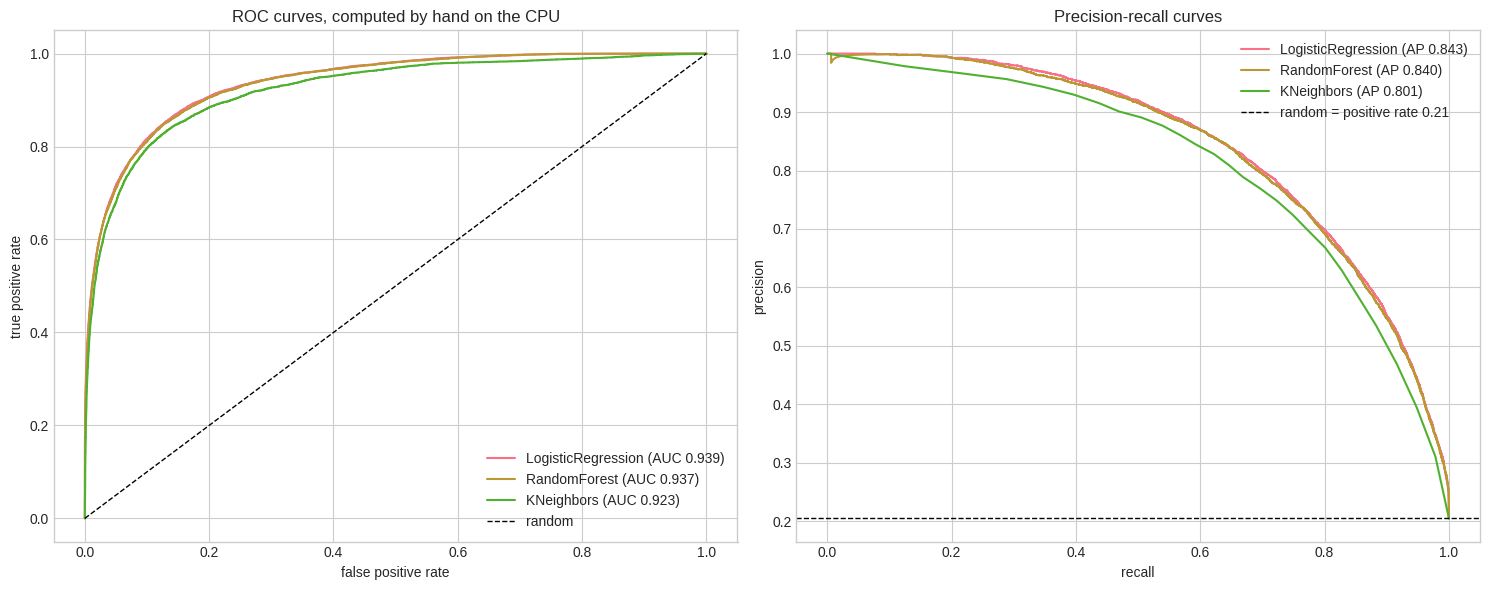

                    n rows  AUC by hand (device)  AUC sklearn  abs diff   PR-AUC
model                                                                           
LogisticRegression   50000               0.93861      0.93861   0.00000  0.84336
RandomForest         50000               0.93734      0.93734   0.00000  0.83972
KNeighbors           50000               0.92291      0.92294   0.00003  0.80107
largest |by-hand AUC - sklearn AUC|: 2.6e-05 (score ties explain anything above zero)


In [37]:
def roc_by_hand(y, s):
    # y in {0,1}, s a score; returns fpr, tpr, auc computed on whichever array library xp is
    y, s = xp.asarray(y), xp.asarray(s)
    order = xp.argsort(-s); y = y[order]
    tp, fp = xp.cumsum(y), xp.cumsum(1 - y)
    tpr, fpr = tp / y.sum(), fp / (1 - y).sum()
    fpr, tpr = xp.concatenate([xp.zeros(1), fpr]), xp.concatenate([xp.zeros(1), tpr])
    auc = float(xp.sum((fpr[1:] - fpr[:-1]) * (tpr[1:] + tpr[:-1]) / 2))
    return to_np(fpr), to_np(tpr), auc

from sklearn.metrics import roc_curve
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
curve_check = []
for name, (y_eval, s, kind) in scores.items():
    fpr, tpr, auc_hand = roc_by_hand(y_eval, s)
    fpr_sk, tpr_sk, _ = roc_curve(y_eval, s)
    auc_sk = roc_auc_score(y_eval, s)
    prec, rec, _ = precision_recall_curve(y_eval, s)
    curve_check.append({"model": name, "n rows": len(y_eval), "AUC by hand (device)": auc_hand, "AUC sklearn": auc_sk, "abs diff": abs(auc_hand - auc_sk), "PR-AUC": average_precision_score(y_eval, s)})
    axes[0].plot(fpr, tpr, label=f"{name} (AUC {auc_hand:.3f})")
    axes[1].plot(rec, prec, label=f"{name} (AP {curve_check[-1]['PR-AUC']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, label="random"); axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate")
axes[0].set_title(f"ROC curves, computed by hand on the {'GPU' if GPU else 'CPU'}"); axes[0].legend(loc="lower right")
axes[1].axhline(y_true_np.mean(), color="k", linestyle="--", linewidth=1, label=f"random = positive rate {y_true_np.mean():.2f}")
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision"); axes[1].set_title("Precision-recall curves"); axes[1].legend(loc="upper right")
plt.tight_layout(); plt.show()
curve_check = pd.DataFrame(curve_check).set_index("model")
print(curve_check.round(5).to_string())
print(f"largest |by-hand AUC - sklearn AUC|: {curve_check['abs diff'].max():.1e} (score ties explain anything above zero)")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left, the ROC curve of each model: the trade between catching overspenders (up) and flagging households that stay within budget (right). Every model is well above the diagonal. Right, the precision-recall curve, where the dashed line is the positive rate: this is the chart that separates models on an imbalanced target, because a model that flags everyone lands on that line. The SVC appears on both charts: a decision score ranks just as well as a probability.

**The common misread:** comparing models on ROC-AUC alone when the positive class is rare. Two models with similar ROC-AUC can have very different precision at the recall you can afford; the right chart shows that spread.

</div>

## 10.3 The threshold sweep and the business-cost threshold

Threshold metrics are a function of the cut-off. The cell sweeps 101 thresholds on the device in one broadcast: a `(thresholds × rows)` boolean matrix, summed along the rows, gives TP, FP and FN for every threshold at once. Then it prices the two mistakes: a missed overspender (`FN`) costs more than a needless nudge (`FP`), and the best threshold is the one that minimises the total.


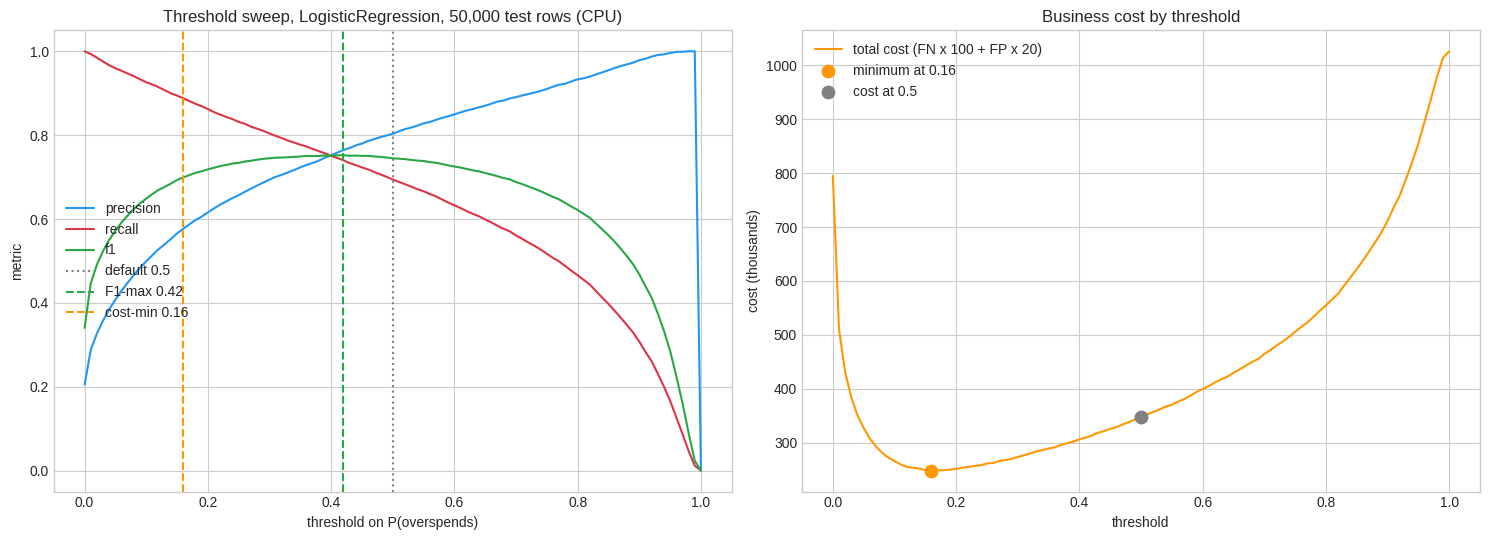

F1 is maximal at 0.42 (F1 0.752); the default 0.5 gives F1 0.745
cost at 0.5: 348,420  |  cost at the cost-min threshold 0.16: 248,520  ->  28.7% cheaper
sweep matrix on the device: 101 x 50,000 booleans = 5.0 MB


In [38]:
COST_FN, COST_FP = 100.0, 20.0      # a missed overspender (late fees, a call anyway) vs a needless nudge (one message)
y_d, p_d = xp.asarray(y_true_np), xp.asarray(p_lr)
thresholds = xp.linspace(0.0, 1.0, 101)
pred_mat = p_d[None, :] >= thresholds[:, None]                       # (101, n_rows) booleans, on the device
tp = (pred_mat & (y_d == 1)).sum(axis=1); fp = (pred_mat & (y_d == 0)).sum(axis=1); fn = ((~pred_mat) & (y_d == 1)).sum(axis=1)
precision = xp.where(tp + fp > 0, tp / xp.maximum(tp + fp, 1), 0.0); recall = tp / (tp + fn)
f1 = xp.where(precision + recall > 0, 2 * precision * recall / xp.maximum(precision + recall, 1e-12), 0.0)
cost = COST_FN * fn + COST_FP * fp
sweep = pd.DataFrame({"threshold": to_np(thresholds), "precision": to_np(precision), "recall": to_np(recall), "f1": to_np(f1), "cost": to_np(cost)})
t_f1, t_cost = sweep.loc[sweep["f1"].idxmax(), "threshold"], sweep.loc[sweep["cost"].idxmin(), "threshold"]
cost_at = lambda t: float(sweep.loc[np.isclose(sweep["threshold"], t), "cost"].iloc[0])

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
ax = axes[0]
for col, color in [("precision", "#2196F3"), ("recall", "#dc3545"), ("f1", "#28a745")]:
    ax.plot(sweep["threshold"], sweep[col], label=col, color=color)
ax.axvline(0.5, color="gray", linestyle=":", label="default 0.5"); ax.axvline(t_f1, color="#28a745", linestyle="--", label=f"F1-max {t_f1:.2f}")
ax.axvline(t_cost, color="#ff9800", linestyle="--", label=f"cost-min {t_cost:.2f}")
ax.set_xlabel("threshold on P(overspends)"); ax.set_ylabel("metric"); ax.set_title(f"Threshold sweep, LogisticRegression, {len(y_true_np):,} test rows ({'GPU' if GPU else 'CPU'})"); ax.legend(loc="center left")
ax = axes[1]
ax.plot(sweep["threshold"], sweep["cost"] / 1e3, color="#ff9800", label=f"total cost (FN x {COST_FN:.0f} + FP x {COST_FP:.0f})")
ax.scatter([t_cost], [cost_at(t_cost) / 1e3], color="#ff9800", s=80, zorder=3, label=f"minimum at {t_cost:.2f}")
ax.scatter([0.5], [cost_at(0.5) / 1e3], color="gray", s=80, zorder=3, label="cost at 0.5")
ax.set_xlabel("threshold"); ax.set_ylabel("cost (thousands)"); ax.set_title("Business cost by threshold"); ax.legend()
plt.tight_layout(); plt.show()
print(f"F1 is maximal at {t_f1:.2f} (F1 {sweep['f1'].max():.3f}); the default 0.5 gives F1 {float(sweep.loc[np.isclose(sweep['threshold'], 0.5), 'f1'].iloc[0]):.3f}")
print(f"cost at 0.5: {cost_at(0.5):,.0f}  |  cost at the cost-min threshold {t_cost:.2f}: {cost_at(t_cost):,.0f}  ->  {1 - cost_at(t_cost) / cost_at(0.5):.1%} cheaper")
print(f"sweep matrix on the device: {pred_mat.shape[0]} x {pred_mat.shape[1]:,} booleans = {pred_mat.nbytes / 1e6:.1f} MB")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: precision rises and recall falls as the threshold moves up; F1 peaks where they balance. Right: the total cost of mistakes at each threshold under the stated prices. Because a missed overspender costs five times a needless nudge, the cost-minimising threshold sits **below** the F1-maximising one, which sits below the default 0.5: with these prices the business should flag more households than the "natural" cut-off would.

**The common misread:** taking 0.5 as a property of the model. It is a property of the loss you care about. Change `COST_FN` and `COST_FP` and the best threshold moves; the model does not.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: pick the threshold on a validation split, report it with the metrics

A threshold chosen on the test split and then scored on the same split is optimistic. Do the sweep on a validation split (or with cross-validation, Part 7), freeze the number, and report it next to every threshold metric: "F1 0.71 at threshold 0.32" is a claim; "F1 0.71" is not.

</div>

## 10.4 Calibration by hand

A probabilistic metric asks whether a predicted 30% is really 30%. The reliability diagram bins the predictions into ten equal-width bins and compares the mean prediction in each bin with the observed positive rate. `bincount` with weights does the whole thing in two lines on the device. The expected calibration error (ECE) is the count-weighted mean gap.


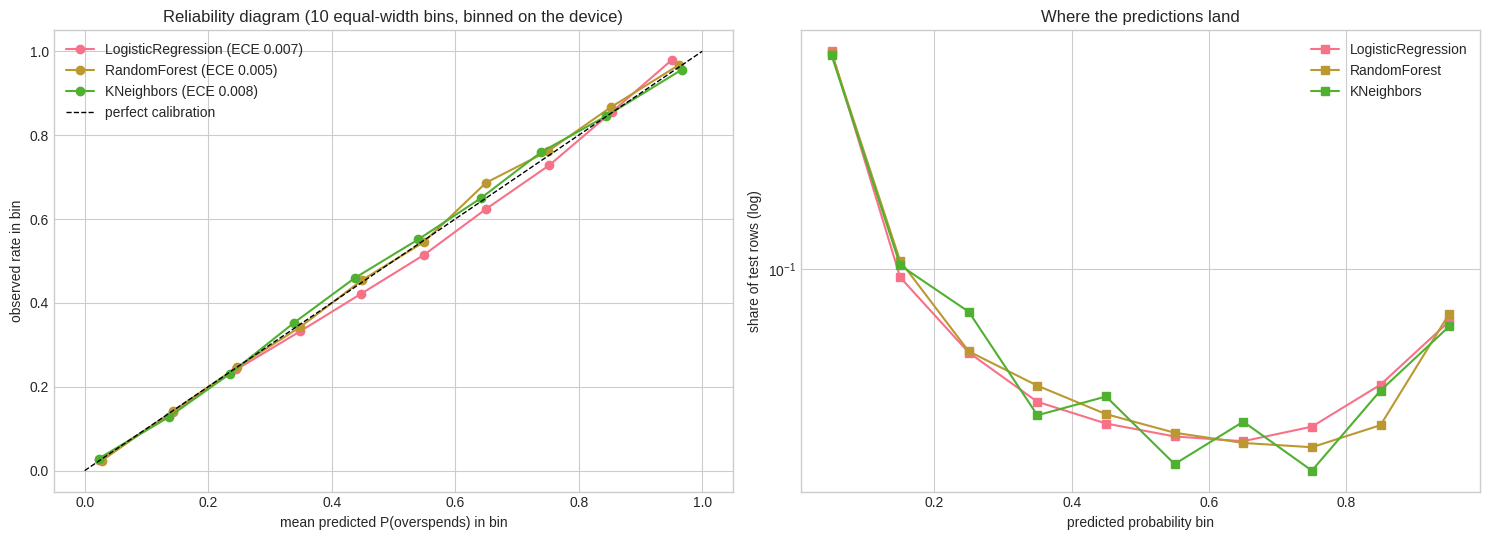

,ECE,brier,log_loss,mean P(1),positive rate
model,,,,,
LogisticRegression,0.007,0.072,0.238,0.206,0.205
RandomForest,0.005,0.072,0.240,0.206,0.205
KNeighbors,0.008,0.077,0.303,0.201,0.205


best calibrated: RandomForest (ECE 0.005); worst: KNeighbors (ECE 0.008)


In [39]:
def calibration_by_hand(y, p, n_bins=10):
    # equal-width bins on [0, 1]; returns mean predicted, observed rate, count per bin, and the ECE
    y, p = xp.asarray(y, dtype=xp.float64), xp.asarray(p, dtype=xp.float64)
    b = xp.clip((p * n_bins).astype(xp.int64), 0, n_bins - 1)
    count = xp.bincount(b, minlength=n_bins)
    mean_p = xp.bincount(b, weights=p, minlength=n_bins) / xp.maximum(count, 1)
    obs = xp.bincount(b, weights=y, minlength=n_bins) / xp.maximum(count, 1)
    ece = float(xp.sum(count / count.sum() * xp.abs(mean_p - obs)))
    return to_np(mean_p), to_np(obs), to_np(count), ece

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
cal_rows = []
for name, (y_eval, s, kind) in scores.items():
    if kind != "probability":
        continue
    mean_p, obs, count, ece = calibration_by_hand(y_eval, s)
    keep = count > 0
    axes[0].plot(mean_p[keep], obs[keep], marker="o", label=f"{name} (ECE {ece:.3f})")
    axes[1].plot(np.arange(10) / 10 + 0.05, count / count.sum(), marker="s", label=name)
    cal_rows.append({"model": name, "ECE": ece, "brier": brier_score_loss(y_eval, s), "log_loss": log_loss(y_eval, np.clip(s, 1e-6, 1 - 1e-6)), "mean P(1)": float(np.mean(s)), "positive rate": float(np.mean(y_eval))})
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, label="perfect calibration")
axes[0].set_xlabel("mean predicted P(overspends) in bin"); axes[0].set_ylabel("observed rate in bin"); axes[0].set_title("Reliability diagram (10 equal-width bins, binned on the device)"); axes[0].legend()
axes[1].set_yscale("log"); axes[1].set_xlabel("predicted probability bin"); axes[1].set_ylabel("share of test rows (log)"); axes[1].set_title("Where the predictions land"); axes[1].legend()
plt.tight_layout(); plt.show()
cal_table = pd.DataFrame(cal_rows).set_index("model")
display(pretty(cal_table, highlight="min", subset=["ECE", "brier", "log_loss"]))
print(f"best calibrated: {cal_table['ECE'].idxmin()} (ECE {cal_table['ECE'].min():.3f}); worst: {cal_table['ECE'].idxmax()} (ECE {cal_table['ECE'].max():.3f})")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: for each model, the observed overspend rate against the mean predicted probability, bin by bin; the diagonal is perfect calibration. Logistic regression follows the diagonal closely because it is trained on log loss. Gaussian naive Bayes sits far from it: its independence assumption is violated by correlated spend columns (Task 6's heatmap), so it pushes probabilities to the extremes with more confidence than it has earned. Right: how many test rows fall into each bin, on a log scale, which tells you which points on the left are supported by data.

**The common misread:** judging calibration by ROC-AUC. Naive Bayes ranks reasonably (its AUC in Task 9 is not far behind) and is still badly calibrated; ranking and probability are different questions, and the table's ECE and Brier columns answer the second one.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where accuracy lies

Look back at `zoo_cards`: the five accuracies sit in a narrow band, all of them some way above one minus the positive rate, the score of a model that never predicts an overspend. Accuracy neither separates the models nor says how many overspenders were caught. The columns that do are `balanced_acc`, `mcc`, `pr_auc` and the calibration numbers above. When a stakeholder asks "how accurate is it?", answer with recall at the chosen threshold and precision at that recall.

</div>

## 10.5 Task 10 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- Threshold, ranking and probabilistic metrics answer different questions; report one of each.
- `cuml.metrics` (26.08) covers accuracy, ROC-AUC, log loss, the confusion matrix and the PR curve on the device, and agrees with scikit-learn to floating-point precision; ROC curve, F1 and calibration are a few CuPy lines.
- The threshold is a business decision: sweep it, price the mistakes, and freeze it on a validation split.
- Calibration is a separate property from ranking; naive Bayes is the standard example of good ranking with poor probabilities.

### 🔑 New variables

| Variable | What it is |
|---|---|
| `agree`, `curve_check` | device-vs-host agreement tables for the scalar metrics and the by-hand ROC-AUC |
| `roc_by_hand`, `calibration_by_hand` | CuPy/NumPy implementations of the two curves cuML does not ship |
| `sweep`, `t_f1`, `t_cost`, `COST_FN`, `COST_FP` | the threshold sweep, the two chosen thresholds and the mistake prices |
| `cal_table` | ECE, Brier and log loss per probabilistic model |

### ➡️ Next Up

Part 5 moves to regression on `spend_next` with cuML's linear models and forests, and wraps preprocessing and models into pipelines that stay on the device.

</div>


In [40]:
# free the device before Part 5 (the split is small; the 200 000-row table and the models are what we release)
del ghh_big, X, Xtr_raw, Xte_raw, pred_mat, y_d, p_d, probe
free_gpu()
print(f"end of Part 4: kept Xtr/Xte/ytr/yte ({frame_mb(Xtr) + frame_mb(Xte):.0f} MB) and zoo_cards; GPU in use (all processes): {gpu_used_mb():.0f} MB")


end of Part 4: kept Xtr/Xte/ytr/yte (18 MB) and zoo_cards; GPU in use (all processes): 0 MB


# Part 5 · cuML Regression and Preprocessing Pipelines ⭐⭐

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Big Picture

Part 4 predicted *whether* a household overspends next month. This Part predicts *how much* it spends: a **regression** target, `spend_next`. The tools are the same six lines of scikit-learn you already know, with one import swapped: `cuml.linear_model` instead of `sklearn.linear_model`. The metric family changes (MAE, RMSE, R², bias), the plots change (residuals instead of ROC curves), and the leak from Part 0 gets shown on purpose.

Task 12 then packages the whole preprocessing chain into a **pipeline** that lives on the GPU end to end, and shows where a host copy sneaks in and what it costs.

</div>


# Task 11 · Regression on the GPU: Predicting Next Month's Spend

## 11.1 The GPU contract for Parts 5 and 6

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 One code path, two worlds

Every cell in Parts 5 and 6 runs on a Colab T4 with RAPIDS **and** on a plain CPU runtime. Three small helpers make that possible:

- `xdf` is the frame library: `cudf` when there is a GPU, `pandas` otherwise. Code written against `xdf` runs in both worlds.
- `to_host(obj)` moves anything to the host (pandas or NumPy) for plotting and for scikit-learn metrics. cuDF frames have `.to_pandas()`, CuPy arrays expose `__cuda_array_interface__` and are copied with `.get()`, and host objects pass through untouched.
- `race(label, rows, gpu_fn, cpu_fn)` times one operation on the GPU and on the CPU on the **same data**, after a **warm-up call** on a few thousand rows. The first CUDA call of a session pays for context creation and kernel compilation (JIT); a warm-up absorbs that so the timed call measures only the work. Every timing in these two Parts goes through `race`, and every row lands in one `SPEED` table printed at the end of Part 6.

</div>


In [41]:
# ---- the GPU contract for Parts 5 and 6: one code path that runs with and without RAPIDS
import gc
xdf = cudf if GPU else pd                       # frame library: cuDF on the GPU, pandas on the CPU

def to_host(obj):
    # anything -> pandas / numpy (for plotting and sklearn metrics); host objects pass through untouched
    if hasattr(obj, "to_pandas"):                   # cuDF DataFrame / Series / Index
        return obj.to_pandas()
    if hasattr(obj, "__cuda_array_interface__"):    # CuPy array (pandas objects also have a .get(key), so test the device interface, not .get)
        return obj.get()
    return obj

if GPU:
    import cupy as cp
    xp = cp                                     # array library on the device
    def sync():                                 # wait for every queued kernel: timings must include the work, not just the launch
        cp.cuda.Device().synchronize()
    def gpu_mem_mb():                           # device-wide used memory in MiB (includes other processes on a shared GPU)
        free, total = cp.cuda.Device().mem_info
        return (total - free) / 2**20
    def free_gpu():                             # drop Python references, then hand cached blocks back to the driver
        gc.collect(); cp.get_default_memory_pool().free_all_blocks()
else:
    xp = np
    def sync(): pass
    def gpu_mem_mb(): return 0.0
    def free_gpu(): gc.collect()

SPEED = []                                      # every measured GPU-vs-CPU timing in Parts 5 and 6 lands here

def race(label, rows, gpu_fn=None, cpu_fn=None, cpu_rows=None, warm_rows=2000):
    # Time gpu_fn(n) against cpu_fn(n) - each callable runs the operation on the first n rows of its own data.
    # A warm-up call on `warm_rows` rows absorbs one-off costs (CUDA context, kernel JIT, thread-pool start),
    # so the timed call measures only the work. Returns (gpu_result, cpu_result); None where a side did not run.
    cpu_rows = cpu_rows or rows
    row = {"operation": label, "GPU rows": rows if (GPU and gpu_fn) else 0, "CPU rows": cpu_rows if cpu_fn else 0,
           "GPU s": np.nan, "CPU s": np.nan, "speed-up": np.nan}
    out_g = out_c = None
    if GPU and gpu_fn is not None:
        gpu_fn(min(warm_rows, rows)); sync()
        t0 = time.perf_counter(); out_g = gpu_fn(rows); sync(); row["GPU s"] = time.perf_counter() - t0
    if cpu_fn is not None:
        cpu_fn(min(warm_rows, cpu_rows))
        t0 = time.perf_counter(); out_c = cpu_fn(cpu_rows); row["CPU s"] = time.perf_counter() - t0
    if row["GPU s"] == row["GPU s"] and row["CPU s"] == row["CPU s"] and cpu_rows == rows:
        row["speed-up"] = row["CPU s"] / row["GPU s"]           # only when both sides did the same rows
    SPEED.append(row)
    g = f"GPU {row['GPU s']:.3f} s on {rows:,} rows" if row["GPU s"] == row["GPU s"] else "GPU: not run (no RAPIDS)"
    c = f"CPU {row['CPU s']:.3f} s on {cpu_rows:,} rows" if row["CPU s"] == row["CPU s"] else "CPU: not run"
    s = f"  -> {row['speed-up']:.1f}x" if row["speed-up"] == row["speed-up"] else ("  (different row counts: no ratio)" if (row["GPU s"] == row["GPU s"] and row["CPU s"] == row["CPU s"]) else "")
    print(f"⏱️ {label}: {g} | {c}{s}")
    return out_g, out_c

print(f"frame library: {xdf.__name__} | array library: {xp.__name__} | GPU: {GPU_NAME or 'none'} | device memory used now: {gpu_mem_mb():,.0f} MiB")


frame library: pandas | array library: numpy | GPU: none | device memory used now: 0 MiB


## 11.2 The design matrix, built on the device

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 What a regressor needs

A regressor wants a numeric matrix with no missing values, and most of them (KNN, Lasso, Ridge) want every column on the same scale. `make_X` turns the raw household rows into exactly that, **on the same device the rows live on**: the two text categories (`city_tier`, `referral_code`) become one-hot columns, the boolean `owns_car` becomes 0/1, every numeric column is filled with its **training** median (only `dining` needs it here, but a later table may have gaps elsewhere), `note` is dropped, and everything is cast to `float32`. Then a `StandardScaler` learned on the training rows is applied to both splits.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: float32 on the GPU

A T4 runs `float64` arithmetic at a small fraction of its `float32` rate (NVIDIA's data sheet lists 1/32), and `float64` doubles the bytes moved through memory. cuML converts inputs to `float32` internally anyway; converting once yourself avoids a silent copy on every call and halves the memory of every frame you keep.

</div>


In [42]:
# ---- from raw household rows to a numeric float32 design matrix, on whichever device the rows live
CAT_COLS = ["city_tier", "referral_code"]
DROP_COLS = ["note", ID_COL, LABEL_CLS, LABEL_REG]
SPEND_CATS = ["rent", "groceries", "utilities", "transport", "dining", "entertainment", "other"]

def make_X(df, columns=None, fill=None):
    # Raw rows (pandas or cuDF) -> one-hot, imputed, float32 frame on the same device as `xdf`.
    # `fill` holds one median per numeric column, learned on TRAIN and reused on every later frame;
    # `columns` (from the training frame) forces later frames to the same one-hot columns in the same order.
    d = df.copy() if isinstance(df, xdf.DataFrame) else xdf.DataFrame(df)
    d = d.drop(columns=[c for c in DROP_COLS if c in d.columns])
    d["referral_code"] = d["referral_code"].fillna("none")           # a missing code is its own category
    d["owns_car"] = d["owns_car"].astype("int8")
    num_cols = [c for c in d.columns if c not in CAT_COLS]
    if fill is None:
        fill = {c: float(d[c].median()) for c in num_cols}            # learned on TRAIN only
    for c in num_cols:
        d[c] = d[c].fillna(fill[c])
    d = xdf.get_dummies(d, columns=CAT_COLS, dtype="float32").astype("float32")
    if columns is not None:
        d = d.reindex(columns=columns, fill_value=0.0)
    return d, fill

def as_frame(arr, columns):
    # transformer outputs come back as arrays, or as frames with the names replaced by 0..n-1 (cuML's scalers do this):
    # always return a frame carrying the original column names
    f = arr if isinstance(arr, xdf.DataFrame) else xdf.DataFrame(arr)
    f.columns = list(columns)
    return f

if GPU:
    from cuml.preprocessing import StandardScaler
else:
    from sklearn.preprocessing import StandardScaler

Xtr_raw, TRAIN_FILL = make_X(train_df)
Xte_raw, _ = make_X(test_df, columns=list(Xtr_raw.columns), fill=TRAIN_FILL)
scaler = StandardScaler().fit(Xtr_raw)
Xtr = as_frame(scaler.transform(Xtr_raw), Xtr_raw.columns)
Xte = as_frame(scaler.transform(Xte_raw), Xte_raw.columns)
ytr = xdf.Series(train_df[LABEL_REG].astype("float32").values)
yte = xdf.Series(test_df[LABEL_REG].astype("float32").values)
yte_h = test_df[LABEL_REG].values.astype(float)            # host copy of the test target: every metric is computed here

print(f"Xtr: {type(Xtr).__module__.split('.')[0]}.{type(Xtr).__name__} {Xtr.shape}, dtypes: {set(str(t) for t in to_host(Xtr.dtypes))}")
print(f"Xte: {Xte.shape} | columns match train: {list(Xtr.columns) == list(Xte.columns)} | train median used to fill dining: {TRAIN_FILL['dining']:.0f} | NaN left: {int(to_host(Xte.isna().sum()).sum())}")
print(f"one-hot columns: {[c for c in Xtr.columns if c.startswith(('city_tier_', 'referral_code_'))]}")
print(f"scaled train mean ~0 and std ~1: mean={float(to_host(Xtr).values.mean()):.3f}, std={float(to_host(Xtr).values.std()):.3f}")


Xtr: pandas.DataFrame (1125, 23), dtypes: {'float32'}
Xte: (375, 23) | columns match train: True | train median used to fill dining: 106 | NaN left: 0
one-hot columns: ['city_tier_city', 'city_tier_metro', 'city_tier_town', 'referral_code_A1', 'referral_code_B2', 'referral_code_C3', 'referral_code_none']
scaled train mean ~0 and std ~1: mean=0.000, std=1.000


## 11.3 Six regressors with the scikit-learn API

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 The zoo, and what each one assumes

| Model | What it fits | When it wins |
|---|---|---|
| `LinearRegression` | one weight per feature, least squares | the truth is close to linear and features are not collinear |
| `Ridge` | the same, plus a penalty on the squared weights | collinear features (the seven spend categories are) |
| `Lasso` | the same, plus a penalty on the absolute weights, which drives some to exactly zero | you want a short list of features |
| `ElasticNet` | both penalties mixed | many correlated features, some useless |
| `RandomForestRegressor` | an average of decision trees | interactions and thresholds, no scaling needed |
| `KNeighborsRegressor` | the mean target of the k nearest rows | smooth local structure; needs scaled features |

All six take `fit(X, y)` and `predict(X)`. On the GPU the classes come from `cuml`; on the CPU from `sklearn`. Nothing else in the cell changes.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ `cuml.ensemble.RandomForestRegressor` is not a byte-for-byte clone

cuML's forest bins each feature into `n_bins=128` buckets before splitting (exact splits are too slow on a GPU), grows trees in parallel `n_streams` at a time, and only accepts `float32`. With the same `random_state` you get a *similar* forest, not the same one, and on 1 125 training rows a CPU forest can be as good or better. Compare on metrics, not on tree shapes.

</div>


In [43]:
# ---- six regressors, one loop, one report card each
if GPU:
    from cuml.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
    from cuml.ensemble import RandomForestRegressor
    from cuml.neighbors import KNeighborsRegressor
    rf_kwargs = {}
else:
    from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.neighbors import KNeighborsRegressor
    rf_kwargs = {"n_jobs": -1}

regressors = {
    "LinearRegression": LinearRegression(),
    "Ridge(alpha=10)":  Ridge(alpha=10.0),
    "Lasso(alpha=1)":   Lasso(alpha=1.0),
    "ElasticNet":       ElasticNet(alpha=1.0, l1_ratio=0.5),
    "RandomForest":     RandomForestRegressor(n_estimators=100, max_depth=12, random_state=RANDOM_STATE, **rf_kwargs),
    "KNN(k=10)":        KNeighborsRegressor(n_neighbors=10),
}
reg_rows, fit_s, reg_pred = [], {}, {}
for name, model in regressors.items():
    model.fit(Xtr.head(200), ytr.head(200)); sync()                  # warm-up: first-call JIT / context on the GPU
    t0 = time.perf_counter(); model.fit(Xtr, ytr); sync(); fit_s[name] = time.perf_counter() - t0
    reg_pred[name] = np.asarray(to_host(model.predict(Xte)), dtype=float).ravel()
    reg_rows.append(report_card(yte_h, reg_pred[name], name=name, task="regression"))
reg_table = pd.concat(reg_rows)
reg_table["fit_s"] = pd.Series(fit_s)
display(pretty(reg_table, highlight="min", subset=["MAE", "RMSE", "MedAE", "MAPE_%", "fit_s"]))
BEST_REG = reg_table["RMSE"].idxmin()
print(f"path: {'cuML on ' + GPU_NAME if GPU else 'scikit-learn on the CPU (no RAPIDS)'} | train rows: {len(Xtr):,} | best RMSE: {BEST_REG} ({reg_table.loc[BEST_REG, 'RMSE']:.0f}), best R2: {reg_table['R2'].idxmax()} ({reg_table['R2'].max():.3f})")
print(f"fit seconds after warm-up: " + ", ".join(f"{k} {v:.3f}" for k, v in fit_s.items()))


,MAE,RMSE,MedAE,MAPE_%,R2,bias,fit_s
model,,,,,,,
LinearRegression,217.767,286.498,174.010,8.744,0.826,7.173,0.002
Ridge(alpha=10),216.688,286.176,174.229,8.705,0.827,7.808,0.002
Lasso(alpha=1),217.238,286.296,176.880,8.735,0.826,7.317,0.003
ElasticNet,227.925,293.365,188.652,9.350,0.818,-0.982,0.002
RandomForest,232.339,304.771,190.953,9.413,0.803,-2.505,1.158
KNN(k=10),274.906,349.358,232.300,11.442,0.742,1.394,0.001


path: scikit-learn on the CPU (no RAPIDS) | train rows: 1,125 | best RMSE: Ridge(alpha=10) (286), best R2: Ridge(alpha=10) (0.827)
fit seconds after warm-up: LinearRegression 0.002, Ridge(alpha=10) 0.002, Lasso(alpha=1) 0.003, ElasticNet 0.002, RandomForest 1.158, KNN(k=10) 0.001


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Read the `fit_s` column before you celebrate

On 1 125 rows every fit takes milliseconds on either device, and the GPU is often *slower* here: launching a kernel and moving a few kilobytes costs more than the arithmetic saves. The GPU story starts at hundreds of thousands of rows, which is where Task 12 goes. What you are checking on this small table is that the **metrics** agree with what scikit-learn would give, not the speed.

</div>

## 11.4 Reading a regression: three pictures

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently)

For a prediction $\hat{y}_i$ of a true value $y_i$, the **residual** is $r_i = y_i - \hat{y}_i$. The report card summarises the residuals: MAE is their mean absolute size, RMSE is $\sqrt{\text{mean}(r_i^2)}$ (large errors count more), **bias** is their plain mean (should be near zero), and

$$ R^2 = 1 - \frac{\sum_i r_i^2}{\sum_i (y_i - \bar{y})^2} $$

is the share of the target's variance the model explains: 1 is perfect, 0 is "predict the mean", negative is worse than that. Three pictures show what the numbers hide: predicted-vs-actual (is it on the diagonal?), the residual histogram (is it centred and symmetric?), and residuals-vs-predicted (does the error grow with the prediction?).

</div>


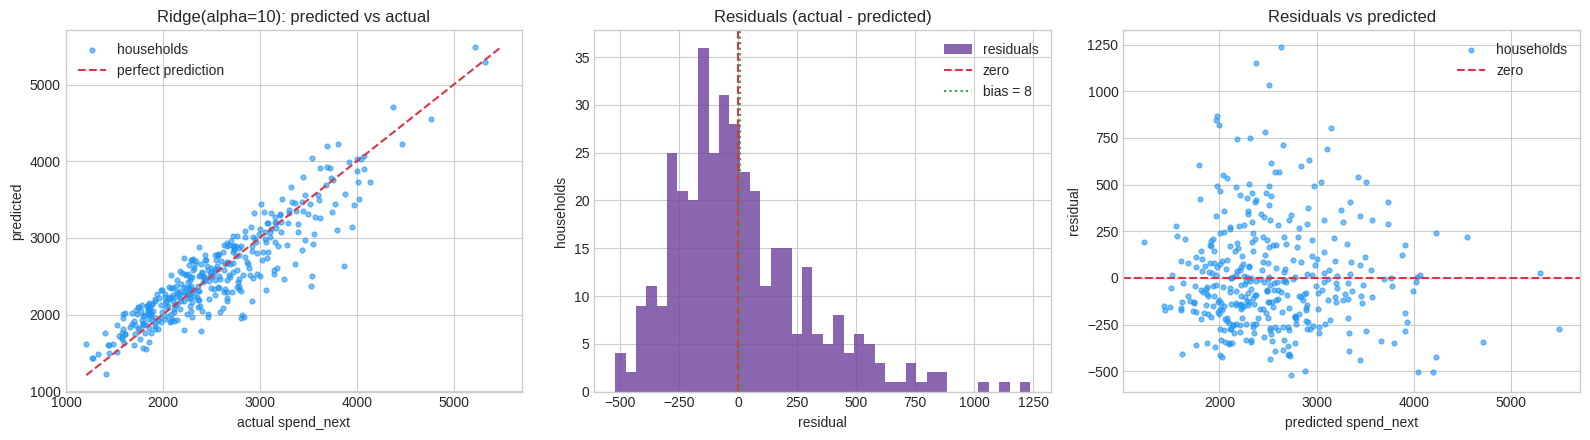

Ridge(alpha=10): RMSE 286 | MAE 217 | bias 8 | largest miss 1238 | 5% of residuals beyond +/- 544


In [44]:
# ---- predicted vs actual, residual histogram, residuals vs predicted (all from host arrays)
pred = reg_pred[BEST_REG]; resid = yte_h - pred
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].scatter(yte_h, pred, s=12, alpha=0.6, color="#2196F3", label="households")
lo, hi = min(yte_h.min(), pred.min()), max(yte_h.max(), pred.max())
axes[0].plot([lo, hi], [lo, hi], "--", color="#dc3545", label="perfect prediction")
axes[0].set_title(f"{BEST_REG}: predicted vs actual"); axes[0].set_xlabel("actual spend_next"); axes[0].set_ylabel("predicted"); axes[0].legend()
axes[1].hist(resid, bins=40, color="#764ba2", alpha=0.85, label="residuals")
axes[1].axvline(0, color="#dc3545", ls="--", label="zero"); axes[1].axvline(resid.mean(), color="#28a745", ls=":", label=f"bias = {resid.mean():.0f}")
axes[1].set_title("Residuals (actual - predicted)"); axes[1].set_xlabel("residual"); axes[1].set_ylabel("households"); axes[1].legend()
axes[2].scatter(pred, resid, s=12, alpha=0.6, color="#2196F3", label="households")
axes[2].axhline(0, color="#dc3545", ls="--", label="zero")
axes[2].set_title("Residuals vs predicted"); axes[2].set_xlabel("predicted spend_next"); axes[2].set_ylabel("residual"); axes[2].legend()
plt.tight_layout(); plt.show()
print(f"{BEST_REG}: RMSE {np.sqrt(np.mean(resid**2)):.0f} | MAE {np.abs(resid).mean():.0f} | bias {resid.mean():.0f} | largest miss {np.abs(resid).max():.0f} | 5% of residuals beyond +/- {np.quantile(np.abs(resid), 0.95):.0f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: most households sit near the diagonal, with a tail of points **below** it on the right: the model under-predicts the biggest next-month spenders. Middle: the residual histogram is centred close to zero (the printed bias) but has a long right tail. Right: the tail is not random. It is the households whose next month contains a **surprise expense** (the generator plants one in about 6% of household-months) that nothing in this month's features announces. No feature set available today can predict it, so the error floor is real, not a modelling failure.

The common misread: a long residual tail is taken as "the model needs more capacity". Here the tail is *irreducible* noise in the target; a bigger model would fit the training tail and do worse on the test tail.

</div>

## 11.5 Which features matter: Ridge coefficients

Because the features were standardised, each Ridge coefficient answers the same question: "one standard deviation more of this feature moves the prediction by how much?" That makes the coefficients comparable across features, which they are **not** on raw scales (a coefficient on `income` in currency units and one on `household_size` in people cannot be compared). The coefficients live on the device as a cuDF Series; one `to_host` moves the 27 numbers for plotting.


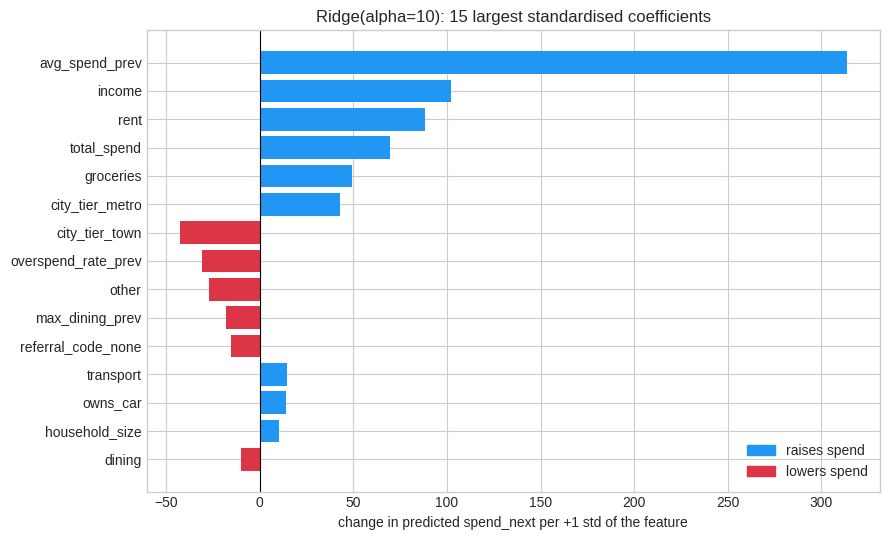

coef_ lives on: numpy | intercept (prediction at the average household): 2624
top 5 by |coefficient|: avg_spend_prev +314, income +102, rent +88, total_spend +69, groceries +49


In [45]:
# ---- Ridge coefficients on standardised features: comparable effect sizes, moved to the host for plotting
ridge = regressors["Ridge(alpha=10)"]
coef = pd.Series(np.asarray(to_host(ridge.coef_), dtype=float).ravel(), index=list(Xtr.columns))
top = coef.reindex(coef.abs().sort_values(ascending=False).index)[:15][::-1]
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(top.index, top.values, color=np.where(top.values >= 0, "#2196F3", "#dc3545"))
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Ridge(alpha=10): 15 largest standardised coefficients"); ax.set_xlabel("change in predicted spend_next per +1 std of the feature")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color="#2196F3"), plt.Rectangle((0, 0), 1, 1, color="#dc3545")], labels=["raises spend", "lowers spend"], loc="lower right")
plt.tight_layout(); plt.show()
intercept = float(np.asarray(to_host(ridge.intercept_)).ravel()[0])
print(f"coef_ lives on: {type(ridge.coef_).__module__.split('.')[0]} | intercept (prediction at the average household): {intercept:.0f}")
print("top 5 by |coefficient|:", ", ".join(f"{k} {v:+.0f}" for k, v in coef.reindex(coef.abs().sort_values(ascending=False).index)[:5].items()))


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The coefficients tell a plausible story: `income`, `rent`, `avg_spend_prev` and `total_spend` carry most of the signal (next month looks like this month), with the category shares and household size adding smaller corrections. The `referral_code_*` and `survey_score` bars are near zero, which is right: Part 0 built them as noise. The one-hot columns of one category are collinear (they sum to one), which is exactly the situation where plain least squares gives unstable, huge, opposite-signed weights and Ridge gives small, stable ones.

The common misread: a large coefficient is taken to mean "a cause". It means "moves with the target after accounting for the others", nothing more; `rent` does not cause next month's spend, it is a proxy for the household's fixed costs.

</div>

## 11.6 The leak, in short form

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ❌ The wrong table

Ask a model to predict **this month's** `total_spend` from **this month's** seven categories and it scores a near-perfect R²: the total is their sum, so the model learns seven weights of 1.0 and is done. The cell below runs that exact trap and, next to it, the honest question: the same seven categories against **next month's** spend. Same features, same model, one column of difference in the target.

</div>


In [46]:
# ---- the leak on purpose: this month's categories -> this month's total (a sum) vs -> next month's total (a forecast)
X_cats_tr, X_cats_te = Xtr_raw[SPEND_CATS], Xte_raw[SPEND_CATS]                 # unscaled category spends, dining imputed
y_this_tr = xdf.Series(train_df["total_spend"].astype("float32").values)
y_this_te_h = test_df["total_spend"].values.astype(float)

leak = LinearRegression().fit(X_cats_tr, y_this_tr)
honest = LinearRegression().fit(X_cats_tr, ytr)
r2_leak = r2_score(y_this_te_h, np.asarray(to_host(leak.predict(X_cats_te)), dtype=float).ravel())
r2_honest = r2_score(yte_h, np.asarray(to_host(honest.predict(X_cats_te)), dtype=float).ravel())
w = np.asarray(to_host(leak.coef_), dtype=float).ravel()
print(f"LEAK    categories -> this month's total_spend : R2 = {r2_leak:.4f}   (weights: {np.round(w, 2).tolist()})")
print(f"HONEST  categories -> NEXT month's spend_next  : R2 = {r2_honest:.4f}")
print(f"the leaked weights are all about 1.0 because total_spend IS the sum of the categories; the only slack is the 4% of rows where dining was imputed")


LEAK    categories -> this month's total_spend : R2 = 0.9998   (weights: [1.0, 0.99, 1.03, 1.01, 1.0, 1.01, 1.0])
HONEST  categories -> NEXT month's spend_next  : R2 = 0.8096
the leaked weights are all about 1.0 because total_spend IS the sum of the categories; the only slack is the 4% of rows where dining was imputed


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: an R² that looks too good is a bug report

Real tabular problems rarely clear R² 0.9 on a genuine forecast. When a first model does, look for a feature that is a function of the target (a sum, a ratio, a later timestamp, a post-outcome flag) before looking for a reason to be pleased. The honest R² above, well below the leaked one, is the number a budgeting team can actually plan with.

</div>

## 11.7 Task 11 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- The regression zoo (`LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`, `RandomForestRegressor`, `KNeighborsRegressor`) has the same `fit`/`predict` API in cuML and scikit-learn; only the import line differs.
- Preprocess **on the device** (`make_X` with `xdf.get_dummies`, `fillna`, `astype("float32")`) and move only what plots and metrics need with `to_host`.
- On 1 125 rows the GPU has no speed advantage and can be slower; the metrics are what you compare at this size.
- Residual plots reveal an irreducible tail (surprise expenses) that no extra capacity can fix.
- A near-perfect R² on a same-month total is a leak, shown with weights of 1.0 on every category.

### 🔑 New variables

| Variable | What it holds |
|---|---|
| `xdf`, `xp`, `to_host`, `sync`, `race`, `SPEED` | the GPU contract: frame/array library, host copy, synchronised timing, the speed table |
| `make_X`, `as_frame`, `TRAIN_FILL`, `SPEND_CATS` | raw rows → float32 design matrix on the device; the train medians every later frame reuses |
| `Xtr`, `Xte`, `ytr`, `yte`, `yte_h` | scaled train/test matrices and targets (device) and the host test target |
| `regressors`, `reg_table`, `reg_pred`, `BEST_REG` | the six fitted models, their report cards, predictions and the best by RMSE |

### ➡️ Next Up

Task 12 wraps the preprocessing and the model into one `Pipeline` that stays on the GPU, and measures what one accidental host copy costs.

</div>


# Task 12 · Pipelines That Stay on the GPU

## 12.1 Why a pipeline, and which one

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 A pipeline is a promise about order

`make_X` in Task 11 had a subtle obligation: the dining median and the scaler statistics must be learned on the **training** rows and merely *applied* to the test rows. A `Pipeline` makes that promise a data structure: every step's `fit` sees only what the previous steps produced from the training rows, and `predict` replays the same steps on new rows. A `ColumnTransformer` routes different columns to different steps (numbers to impute-then-scale, categories to one-hot).

cuML ships `cuml.pipeline.Pipeline` and `cuml.compose.ColumnTransformer`. The cell checks something worth knowing: cuML's `Pipeline` **is** scikit-learn's `Pipeline`, re-exported. cuML does not need its own, because its estimators speak the scikit-learn API. `ColumnTransformer` is cuML's own implementation, so that column selection happens on cuDF frames without a host round-trip.

</div>


In [47]:
# ---- one pipeline, end to end, on the device: impute+scale numbers, one-hot categories, then Ridge
import sklearn.pipeline
if GPU:
    from cuml.pipeline import Pipeline
    from cuml.compose import ColumnTransformer
    from cuml.preprocessing import SimpleImputer, OneHotEncoder, StandardScaler
    from cuml.linear_model import Ridge
    import cuml.compose
    print("cuml.pipeline.Pipeline is sklearn.pipeline.Pipeline:", Pipeline is sklearn.pipeline.Pipeline,
          "| cuml.compose.ColumnTransformer module:", cuml.compose.ColumnTransformer.__module__)
else:
    from sklearn.pipeline import Pipeline
    from sklearn.compose import ColumnTransformer
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.linear_model import Ridge
    print("CPU path: scikit-learn Pipeline, ColumnTransformer and transformers (no RAPIDS on this runtime)")

NUM_COLS = [c for c in FEATURES if c not in CAT_COLS + ["note"]]

def raw_frame(df):
    # the raw feature columns as a device frame: numbers as float32 (NaN kept for the imputer), categories as strings
    d = xdf.DataFrame(df[FEATURES].drop(columns=["note"]))
    d["referral_code"] = d["referral_code"].fillna("none")
    for c in NUM_COLS:
        d[c] = d[c].astype("float32")
    return d

raw_tr, raw_te = raw_frame(train_df), raw_frame(test_df)
prep = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), NUM_COLS),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_COLS),
])
pipe = Pipeline([("prep", prep), ("model", Ridge(alpha=10.0))])
pipe.fit(raw_tr, ytr)
pipe_pred = np.asarray(to_host(pipe.predict(raw_te)), dtype=float).ravel()
pipe_card = report_card(yte_h, pipe_pred, name="Pipeline(impute+scale+onehot -> Ridge)", task="regression")
display(pretty(pd.concat([pipe_card, reg_table.loc[["Ridge(alpha=10)"], pipe_card.columns]]), highlight="min", subset=["MAE", "RMSE", "MedAE", "MAPE_%"]))
prep_out = pipe.named_steps["prep"].transform(raw_te)
print(f"input frame: {type(raw_te).__module__.split('.')[0]} with NaN in dining: {int(to_host(raw_te['dining'].isna()).sum())} rows")
print(f"after 'prep': {type(prep_out).__module__.split('.')[0]}.{type(prep_out).__name__} {tuple(prep_out.shape)} -> no NaN: {not bool(np.isnan(np.asarray(to_host(prep_out), dtype=float)).any())}")
print(f"pipeline R2 {pipe_card['R2'].iloc[0]:.4f} vs hand-built Ridge R2 {reg_table.loc['Ridge(alpha=10)', 'R2']:.4f} (same recipe, so they should agree closely)")


CPU path: scikit-learn Pipeline, ColumnTransformer and transformers (no RAPIDS on this runtime)


,MAE,RMSE,MedAE,MAPE_%,R2,bias
model,,,,,,
Pipeline(impute+scale+onehot -> Ridge),216.786,286.346,176.892,8.716,0.826,7.459
Ridge(alpha=10),216.688,286.176,174.229,8.705,0.827,7.808


input frame: pandas with NaN in dining: 12 rows
after 'prep': numpy.ndarray (375, 23) -> no NaN: True
pipeline R2 0.8264 vs hand-built Ridge R2 0.8266 (same recipe, so they should agree closely)


## 12.2 The transformer shelf: what runs on the device

Each cuML transformer below is fit-transformed on the training frame; the cell records where the output lives, its shape and the time. `OneHotEncoder` and `PolynomialFeatures` change the column count; the scalers and the imputer keep it.


In [48]:
# ---- every transformer used in this course, fit-transformed on the device, with output type and time
if GPU:
    from cuml.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, SimpleImputer, OneHotEncoder, PolynomialFeatures
else:
    from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, PolynomialFeatures
    from sklearn.impute import SimpleImputer

num_tr, cat_tr = raw_tr[NUM_COLS], raw_tr[CAT_COLS]
num_filled = num_tr.fillna(0.0)
shelf = [
    ("StandardScaler",        StandardScaler(),                            num_filled),
    ("MinMaxScaler",          MinMaxScaler(),                              num_filled),
    ("RobustScaler",          RobustScaler(),                              num_filled),
    ("SimpleImputer(median)", SimpleImputer(strategy="median"),            num_tr),
    ("OneHotEncoder",         OneHotEncoder(sparse_output=False),          cat_tr),
    ("PolynomialFeatures(2)", PolynomialFeatures(degree=2, include_bias=False), num_filled[["income", "household_size", "dining"]]),
]
shelf_rows = []
for name, tr, X in shelf:
    tr.fit_transform(X.head(200)); sync()                                   # warm-up
    t0 = time.perf_counter(); out = tr.fit_transform(X); sync(); ms = (time.perf_counter() - t0) * 1000
    shelf_rows.append({"transformer": name, "input": f"{type(X).__module__.split('.')[0]} {tuple(X.shape)}",
                       "output": f"{type(out).__module__.split('.')[0]}.{type(out).__name__} {tuple(out.shape)}",
                       "on device": GPU and type(out).__module__.split(".")[0] in ("cudf", "cupy"), "ms": round(ms, 2)})
shelf_df = pd.DataFrame(shelf_rows)
print(shelf_df.to_string(index=False))
print(f"\npath: {'cuml.preprocessing on ' + GPU_NAME if GPU else 'sklearn.preprocessing on the CPU'} | all outputs on the device: {bool(shelf_df['on device'].all()) if GPU else 'n/a (CPU)'}")


          transformer             input                   output  on device   ms
       StandardScaler pandas (1125, 16) numpy.ndarray (1125, 16)      False 2.14
         MinMaxScaler pandas (1125, 16) numpy.ndarray (1125, 16)      False 1.82
         RobustScaler pandas (1125, 16) numpy.ndarray (1125, 16)      False 4.62
SimpleImputer(median) pandas (1125, 16) numpy.ndarray (1125, 16)      False 3.26
        OneHotEncoder  pandas (1125, 2)  numpy.ndarray (1125, 7)      False 1.40
PolynomialFeatures(2)  pandas (1125, 3)  numpy.ndarray (1125, 9)      False 1.47

path: sklearn.preprocessing on the CPU | all outputs on the device: n/a (CPU)


| Transformer | Device | Notes |
|---|---|---|
| `StandardScaler`, `MinMaxScaler`, `RobustScaler` | GPU (cuDF in → cuDF out) | statistics learned in `fit`, applied in `transform`; `RobustScaler` uses median and IQR, safer with outliers |
| `SimpleImputer` | GPU | `strategy="median"` / `"mean"` / `"most_frequent"`; keep NaN as NaN in the input, do not pre-fill |
| `OneHotEncoder` | GPU | `sparse_output=False` for a dense frame; `handle_unknown="ignore"` so an unseen category at serving time becomes all zeros instead of an error |
| `PolynomialFeatures` | GPU | column count grows fast: 3 columns → 9 at degree 2; use on a few chosen columns |
| `ColumnTransformer` | GPU (cuML's own) | routes columns by name on cuDF frames |
| `Pipeline` | either | scikit-learn's class; it never touches the data itself, so it runs wherever its steps run |
| `cuml.preprocessing.TargetEncoder`, `LabelEncoder`, `KBinsDiscretizer`, `QuantileTransformer` | GPU | also present in 26.08; same shapes |

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: `handle_unknown="ignore"` before you ship

A model that trained on referral codes A1, B2, C3 and `none` will one day meet a D4. With the default `handle_unknown="error"` the pipeline raises in production; with `"ignore"` the row gets all-zero code columns and a sensible prediction. Set it in the pipeline, not in an afterthought.

</div>

## 12.3 scikit-learn's own `Pipeline` around cuML estimators, and the implicit-copy guard

Because cuML estimators follow the scikit-learn API, scikit-learn's `Pipeline` (imported from `sklearn.pipeline`, not from cuML) can hold them, fit them on a cuDF frame and return a cuDF prediction. The second half of the cell shows a guard rail you will hit sooner or later: scikit-learn's metric functions refuse device data. cuDF and CuPy raise a `TypeError` instead of copying silently, so the copy is always your explicit decision (`to_host`).


In [49]:
# ---- sklearn.pipeline.Pipeline holding cuML steps, and the "no implicit host copy" guard rail
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.metrics import r2_score
if GPU:
    from cuml.preprocessing import StandardScaler as cuStandardScaler
    from cuml.linear_model import Ridge as cuRidge
    sk_pipe = SkPipeline([("scale", cuStandardScaler()), ("ridge", cuRidge(alpha=10.0))])     # sklearn container, cuML steps
    sk_pipe.fit(Xtr_raw, ytr)
    p_dev = sk_pipe.predict(Xte_raw)
    print(f"sklearn.pipeline.Pipeline with cuML steps: fit on {type(Xtr_raw).__module__.split('.')[0]}, predict returns {type(p_dev).__module__.split('.')[0]}.{type(p_dev).__name__}")
    try:
        r2_score(yte, p_dev)                      # sklearn on device data
        print("sklearn r2_score accepted device data (no copy guard on this version)")
    except TypeError as e:
        print("sklearn r2_score on device data raised TypeError:", str(e).split(",")[0])
    print(f"r2_score on to_host(...) : {r2_score(yte_h, np.asarray(to_host(p_dev), dtype=float).ravel()):.4f}")
    try:
        np.asarray(Xte.values)                     # CuPy also refuses an implicit device->host conversion
    except TypeError as e:
        print("np.asarray(cupy array) raised TypeError:", str(e).split(".")[0])
else:
    sk_pipe = SkPipeline([("scale", StandardScaler()), ("ridge", Ridge(alpha=10.0))]).fit(Xtr_raw, ytr)
    print(f"CPU path: the same sklearn Pipeline with sklearn steps, r2 = {r2_score(yte_h, sk_pipe.predict(Xte_raw)):.4f}; on a GPU runtime the steps would be cuML classes and the outputs cuDF")


CPU path: the same sklearn Pipeline with sklearn steps, r2 = 0.8266; on a GPU runtime the steps would be cuML classes and the outputs cuDF


## 12.4 Where the host copy hides, and what it costs at scale

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Three ways to lose the GPU without noticing

1. **Explicit copies**: `.to_pandas()`, `.to_numpy()`, `.get()`, `cp.asnumpy`. Cheap for 27 numbers, expensive for a 200 000 × 27 matrix, and every metric or plot call is a temptation.
2. **Feeding host data to a GPU pipeline.** cuML accepts NumPy and pandas inputs and converts them at every step; the pipeline still works, so nothing warns you, but each step pays a host → device copy.
3. **A CPU step inside a GPU pipeline** (a scikit-learn transformer between two cuML ones): each boundary is a copy in each direction.

The cell scales the household table to **200 000 households** (`make_budget(n_households=200_000, months=3)`, the generator is vectorised per month so this takes seconds), then measures: the explicit copy of the design matrix in each direction, a `scale → RandomForest` pipeline fit on device data, the same pipeline fed pandas, and the scikit-learn twin on the CPU.

</div>


In [50]:
# ---- the 200k-household table: copies measured, then the whole pipeline GPU vs CPU on the same rows
big_budget = make_budget(n_households=200_000, months=3, seed=RANDOM_STATE)
big_hh = household_table(big_budget); del big_budget                     # 200k rows, host pandas; the device copy is built next
Xbig, _ = make_X(big_hh, columns=list(Xtr_raw.columns), fill=TRAIN_FILL)     # the train medians, not this table's
ybig = xdf.Series(big_hh[LABEL_REG].astype("float32").values)
Xbig_host, ybig_host = to_host(Xbig), big_hh[LABEL_REG].values.astype("float32")
N_FIT = 150_000                                                          # first 150k rows fit, last 50k score
mb = Xbig.shape[0] * Xbig.shape[1] * 4 / 2**20
print(f"big_hh: {big_hh.shape[0]:,} households | design matrix {tuple(Xbig.shape)} float32 = {mb:.1f} MiB on {'the GPU' if GPU else 'the host'}")

if GPU:
    _ = Xbig.head(2000).to_numpy(); _ = cudf.DataFrame(Xbig_host.head(2000)); sync()        # warm-up both directions
    with timer(f"device -> host copy of the {mb:.0f} MiB matrix (.to_numpy())"):
        _h = Xbig.to_numpy(); sync()
    with timer(f"host -> device copy (cudf.DataFrame(pandas))"):
        _d = cudf.DataFrame(Xbig_host); sync()
    del _h, _d

from sklearn.preprocessing import StandardScaler as SkStandardScaler
from sklearn.ensemble import RandomForestRegressor as SkRF
def rf_pipe_gpu(n):
    p = Pipeline([("scale", StandardScaler()), ("rf", RandomForestRegressor(n_estimators=40, max_depth=10, random_state=RANDOM_STATE))])
    return p.fit(Xbig.head(n), ybig.head(n))
def rf_pipe_cpu(n):
    p = SkPipeline([("scale", SkStandardScaler()), ("rf", SkRF(n_estimators=40, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1))])
    return p.fit(Xbig_host.head(n), ybig_host[:n])
rf_g, rf_c = race("scale -> RandomForest(40 trees, depth 10) pipeline fit", N_FIT, rf_pipe_gpu if GPU else None, rf_pipe_cpu)

if GPU:                                                                  # the same GPU pipeline, fed pandas: still works, silently slower
    rf_pipe_gpu(2000); sync()
    t0 = time.perf_counter()
    Pipeline([("scale", StandardScaler()), ("rf", RandomForestRegressor(n_estimators=40, max_depth=10, random_state=RANDOM_STATE))]).fit(Xbig_host.head(N_FIT), ybig_host[:N_FIT]); sync()
    t_host_fed = time.perf_counter() - t0
    print(f"⏱️ the same cuML pipeline fed pandas instead of cuDF: {t_host_fed:.3f} s vs {SPEED[-1]['GPU s']:.3f} s on device data (it converts at every step)")

y_last = big_hh[LABEL_REG].values[N_FIT:].astype(float)
cards = []
if rf_g is not None:
    cards.append(report_card(y_last, np.asarray(to_host(rf_g.predict(Xbig.iloc[N_FIT:])), dtype=float).ravel(), name="cuML pipeline (GPU)", task="regression"))
cards.append(report_card(y_last, rf_c.predict(Xbig_host.iloc[N_FIT:]), name="sklearn pipeline (CPU)", task="regression"))
display(pretty(pd.concat(cards), highlight="min", subset=["MAE", "RMSE", "MedAE", "MAPE_%"]))
print(f"held-out 50,000 households: both pipelines land on similar RMSE; the GPU one fit {SPEED[-1]['speed-up']:.1f}x faster" if GPU else "CPU path: one sklearn pipeline; on a T4 the cuML twin fits the same rows several times faster")


big_hh: 200,000 households | design matrix (200000, 23) float32 = 17.5 MiB on the host


⏱️ scale -> RandomForest(40 trees, depth 10) pipeline fit: GPU: not run (no RAPIDS) | CPU 40.955 s on 150,000 rows


,MAE,RMSE,MedAE,MAPE_%,R2,bias
model,,,,,,
sklearn pipeline (CPU),198.314,271.619,154.163,8.189,0.815,-1.435


CPU path: one sklearn pipeline; on a T4 the cuML twin fits the same rows several times faster


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The copy is small; the habit is not

One explicit copy of the design matrix costs a fraction of a second, so a single `to_host` for a plot is fine. The trap is the pattern that repeats it: a metric computed on the host inside a loop over hyperparameters, a pipeline fed from a pandas frame in every cross-validation fold, a `.to_pandas()` inside a helper called per batch. Measure once with `timer`, then decide where the data lives and keep it there.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: the device is a decision you make once, at load time

Read or build the frame on the device (`cudf.read_parquet`, `cudf.DataFrame(pandas)`, `make_X` on `xdf`), keep every step in the pipeline a cuML step, and bring back only predictions, coefficients and aggregates with `to_host`. If a step has no cuML equivalent, put it **before** the device boundary (in the load step) rather than in the middle of the pipeline.

</div>

## 12.5 Task 12 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- `cuml.pipeline.Pipeline` is scikit-learn's `Pipeline`; `cuml.compose.ColumnTransformer` and the `cuml.preprocessing` transformers are GPU implementations that take and return cuDF frames.
- A pipeline turns the train-only promise (imputer medians, scaler statistics) into a structure; `handle_unknown="ignore"` keeps it alive in production.
- scikit-learn containers can hold cuML steps; scikit-learn metrics cannot take device data, and cuDF/CuPy raise instead of copying silently.
- On 150 000 rows the `scale → RandomForest` pipeline fits several times faster on the GPU; feeding the same pipeline pandas still works but pays a conversion at every step.

### 🔑 New variables

| Variable | What it holds |
|---|---|
| `pipe`, `prep`, `raw_tr`, `raw_te`, `NUM_COLS` | the device pipeline and the raw frames it consumes |
| `shelf_df` | the transformer shelf with output type and timing |
| `big_hh`, `Xbig`, `ybig`, `Xbig_host`, `ybig_host`, `N_FIT` | the 200 000-household table, its design matrix on both devices, the fit/score split |
| `rf_g`, `rf_c` | the fitted GPU and CPU pipelines |

### ➡️ Next Up

Part 6 drops the labels: k-means, density clustering, PCA, UMAP, t-SNE and nearest-neighbour anomaly scores on the 200 000-household table.

</div>


# Part 6 · Unsupervised on the GPU: k-means, DBSCAN, PCA, UMAP, t-SNE ⭐⭐

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Big Picture

Unsupervised methods are where a GPU changes what is *possible*, not only what is fast. Silhouette scores, density clustering, t-SNE and nearest-neighbour searches all compare rows to rows: their cost grows with the **square** of the row count. On a CPU that means "run it on a sample and hope"; on a T4 it means "run it on the table". Every method in this Part is timed against its scikit-learn twin on the same data, and the honest table at the end says which comparisons used the same rows and which did not.

The running question changes shape: no target, only **behaviour**. Each household becomes a vector of *shares of income* spent per category plus a few context features, and the methods look for groups, directions and oddities in that space.

</div>


# Task 13 · k-Means, DBSCAN and HDBSCAN on 200 000 Households

## 13.1 The behaviour matrix

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Shares, not amounts

Two households that spend 400 and 900 on groceries are not different if their incomes are 2 000 and 4 500: both spend a fifth of their income on food. Dividing each category by income removes the income scale and leaves the **shape** of the budget. Log income, household size, the past overspend rate and last months' spend-to-income ratio add context. Standardising every column (mean 0, standard deviation 1) stops the rent share (large numbers) from dominating the entertainment share (small numbers) in every distance computation that follows.

</div>


In [51]:
# ---- the behaviour matrix: category shares of income + context, standardised, on the device
if "big_hh" not in globals():                                          # Part 6 stands alone: rebuild the 200k table if Task 12 did not run
    _bb = make_budget(n_households=200_000, months=3, seed=RANDOM_STATE); big_hh = household_table(_bb); del _bb
gbig = xdf.DataFrame(big_hh)                                            # 200k rows on the device
beh = xdf.DataFrame()
for c in SPEND_CATS:
    beh[f"{c}_share"] = (gbig[c].fillna(0.0) / gbig["income"]).astype("float32")
beh["log_income"] = np.log(gbig["income"]).astype("float32")
beh["household_size"] = gbig["household_size"].astype("float32")
beh["overspend_rate_prev"] = gbig["overspend_rate_prev"].astype("float32")
beh["prev_spend_ratio"] = (gbig["avg_spend_prev"] / gbig["income"]).astype("float32")
BEH_COLS = list(beh.columns)

scaler_beh = StandardScaler().fit(beh)
Xbeh = as_frame(scaler_beh.transform(beh), BEH_COLS)                    # standardised frame on the device
Xbeh_arr = Xbeh.values                                                  # CuPy on the GPU, NumPy on the CPU: what the estimators eat
Xbeh_h = to_host(Xbeh_arr)                                              # one host copy for the sklearn twins (8.8 MiB)
y_over = big_hh[LABEL_CLS].values                                       # next-month overspend, host, NEVER shown to the clustering
rng = np.random.default_rng(RANDOM_STATE)
print(f"behaviour matrix: {tuple(Xbeh_arr.shape)} {Xbeh_arr.dtype} as {type(Xbeh_arr).__module__.split('.')[0]} | {Xbeh_arr.nbytes / 2**20:.1f} MiB | columns: {BEH_COLS}")
print("mean share of income per category:", ", ".join(f"{c[:-6]} {float(v):.2f}" for c, v in to_host(beh[[f'{c}_share' for c in SPEND_CATS]].mean()).items()))
print(f"device memory used now: {gpu_mem_mb():,.0f} MiB")


behaviour matrix: (200000, 11) float32 as numpy | 8.4 MiB | columns: ['rent_share', 'groceries_share', 'utilities_share', 'transport_share', 'dining_share', 'entertainment_share', 'other_share', 'log_income', 'household_size', 'overspend_rate_prev', 'prev_spend_ratio']
mean share of income per category: rent 0.28, groceries 0.10, utilities 0.04, transport 0.03, dining 0.03, entertainment 0.03, other 0.02
device memory used now: 0 MiB


## 13.2 k-means and the elbow

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently)

k-means picks $k$ centres $\mu_1 \dots \mu_k$ and assigns every row to its nearest centre, choosing the centres that minimise the **inertia**

$$ J = \sum_{i} \lVert x_i - \mu_{c(i)} \rVert^2 , $$

the total squared distance from each row to its centre. Inertia always falls as $k$ grows (more centres, shorter distances), so you cannot pick $k$ by minimising it; you look for the **elbow**, the $k$ after which adding a centre buys little. cuML's `KMeans` uses a scalable k-means++ initialisation and runs the assignment step (200 000 rows × $k$ centres × 11 dimensions, repeated) as one GPU kernel per iteration.

On the CPU path the elbow runs on a 50 000-row sample, so the curve is plotted **per row** (inertia divided by the row count) to make the two comparable.

</div>


⏱️ KMeans(k=5) fit: GPU: not run (no RAPIDS) | CPU 0.084 s on 50,000 rows


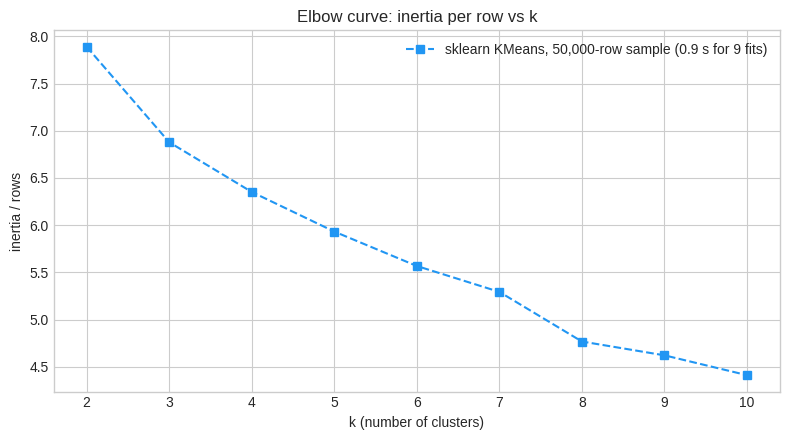

inertia per row, GPU 200k: not run
inertia per row, CPU  50k: k=2 7.89, k=3 6.88, k=4 6.35, k=5 5.93, k=6 5.57, k=7 5.29, k=8 4.77, k=9 4.62, k=10 4.41


In [52]:
# ---- the elbow curve: k = 2..10 on the GPU (all 200k rows) and on the CPU (a 50k sample), inertia per row
if GPU:
    from cuml.cluster import KMeans
from sklearn.cluster import KMeans as SkKMeans
KS = list(range(2, 11)); N_CPU_KM = 50_000
idx_km = rng.choice(len(Xbeh_h), N_CPU_KM, replace=False); Xkm_h = Xbeh_h[idx_km]
km_fit, inertia_gpu, inertia_cpu = {}, {}, {}
if GPU:
    KMeans(n_clusters=3, n_init=1, random_state=RANDOM_STATE).fit(Xbeh_arr[:2000]); sync()          # warm-up
    t0 = time.perf_counter()
    for k in KS:
        m = KMeans(n_clusters=k, n_init=1, random_state=RANDOM_STATE).fit(Xbeh_arr); km_fit[k] = m
        inertia_gpu[k] = float(m.inertia_) / len(Xbeh_arr)
    sync(); t_elbow_gpu = time.perf_counter() - t0
t0 = time.perf_counter()
for k in KS:
    m = SkKMeans(n_clusters=k, n_init=1, random_state=RANDOM_STATE).fit(Xkm_h)
    inertia_cpu[k] = m.inertia_ / N_CPU_KM
    if not GPU: km_fit[k] = m
t_elbow_cpu = time.perf_counter() - t0
_ = race("KMeans(k=5) fit", len(Xbeh_arr), (lambda n: KMeans(n_clusters=5, n_init=1, random_state=RANDOM_STATE).fit(Xbeh_arr[:n])) if GPU else None,
         lambda n: SkKMeans(n_clusters=5, n_init=1, random_state=RANDOM_STATE).fit(Xbeh_h[:n]), cpu_rows=N_CPU_KM)

fig, ax = plt.subplots(figsize=(8, 4.5))
if GPU: ax.plot(KS, [inertia_gpu[k] for k in KS], "o-", color="#76b900", label=f"cuML KMeans, {len(Xbeh_arr):,} rows ({t_elbow_gpu:.1f} s for 9 fits)")
ax.plot(KS, [inertia_cpu[k] for k in KS], "s--", color="#2196F3", label=f"sklearn KMeans, {N_CPU_KM:,}-row sample ({t_elbow_cpu:.1f} s for 9 fits)")
ax.set_title("Elbow curve: inertia per row vs k"); ax.set_xlabel("k (number of clusters)"); ax.set_ylabel("inertia / rows"); ax.legend()
plt.tight_layout(); plt.show()
print(f"inertia per row, GPU 200k: " + (", ".join(f"k={k} {inertia_gpu[k]:.2f}" for k in KS) if GPU else "not run") )
print(f"inertia per row, CPU  50k: " + ", ".join(f"k={k} {inertia_cpu[k]:.2f}" for k in KS))


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Both curves fall steeply from k=2 to about k=4 and flatten after; the per-row inertia of the 200 000-row GPU fit and the 50 000-row CPU sample sit close together, which is the sign that the sample represents the table. The two libraries do not give identical inertia at a given k: cuML uses "scalable k-means++" initialisation and scikit-learn plain k-means++, both with `n_init=1` here, so each lands in a slightly different local optimum of the same objective.

The common misread: the elbow is taken as a precise k. It is a range (here roughly 3 to 5); the silhouette in the next cell and, more than anything, whether the segments mean something to the people who will use them, settle the choice.

</div>

## 13.3 Silhouette on the GPU, and the check against scikit-learn

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently)

For one row, let $a$ be its mean distance to the rows of its own cluster and $b$ the mean distance to the rows of the nearest *other* cluster. Its silhouette is

$$ s = \frac{b - a}{\max(a, b)} \in [-1, 1] , $$

near 1 when the row sits deep inside a tight cluster, near 0 on a boundary, negative when it is probably in the wrong cluster. The score is the mean over rows. It needs every pairwise distance, so it costs $O(n^2)$: on 5 000 rows that is 25 million distances, which is why both libraries compute it on a sample. `cuml.metrics.cluster.silhouette_score` and `sklearn.metrics.silhouette_score` are compared on the same 5 000 rows below; they should agree to many decimals, and the times should not.

</div>


⏱️ silhouette_score (k=3): GPU: not run (no RAPIDS) | CPU 0.339 s on 5,000 rows


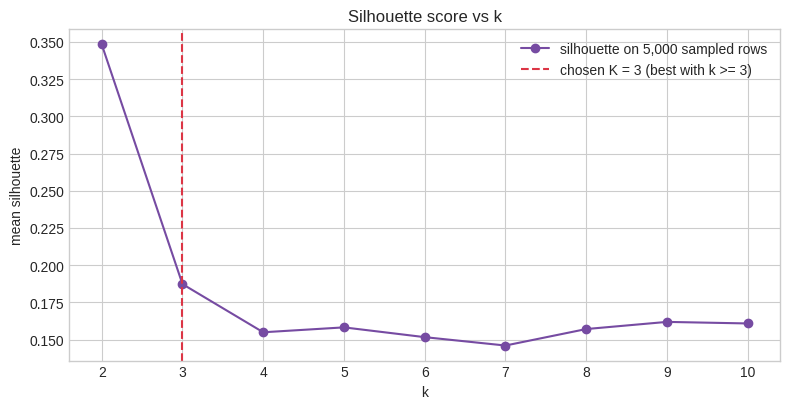

silhouette by k: k=2 0.348, k=3 0.187, k=4 0.155, k=5 0.158, k=6 0.152, k=7 0.146, k=8 0.157, k=9 0.162, k=10 0.161
K_BEST = 3


In [53]:
# ---- silhouette vs k on a 5k sample, cuML vs sklearn agreement, and the choice of K
from sklearn.metrics import silhouette_score as sk_silhouette
if GPU:
    from cuml.metrics.cluster import silhouette_score as cu_silhouette
N_SIL = 5_000
idx_sil = rng.choice(len(Xbeh_h), N_SIL, replace=False)
Xs = Xbeh_arr[xp.asarray(idx_sil)]; Xs_h = Xbeh_h[idx_sil]
sil = {}
for k in KS:
    lab = km_fit[k].predict(Xs)
    sil[k] = float(cu_silhouette(Xs, lab)) if GPU else float(sk_silhouette(Xs_h, np.asarray(to_host(lab))))
K_BEST = max([k for k in KS if k >= 3], key=sil.get)               # silhouette often prefers k=2 (one coarse split); a budgeting team wants at least three segments
lab_best = km_fit[K_BEST].predict(Xs); lab_best_h = np.asarray(to_host(lab_best))
s_g, s_c = race(f"silhouette_score (k={K_BEST})", N_SIL, (lambda n: float(cu_silhouette(Xs[:n], lab_best[:n]))) if GPU else None,
                lambda n: float(sk_silhouette(Xs_h[:n], lab_best_h[:n])))

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(KS, [sil[k] for k in KS], "o-", color="#764ba2", label=f"silhouette on {N_SIL:,} sampled rows")
ax.axvline(K_BEST, color="#dc3545", ls="--", label=f"chosen K = {K_BEST} (best with k >= 3)")
ax.set_title("Silhouette score vs k"); ax.set_xlabel("k"); ax.set_ylabel("mean silhouette"); ax.legend()
plt.tight_layout(); plt.show()
print("silhouette by k:", ", ".join(f"k={k} {v:.3f}" for k, v in sil.items()))
if GPU: print(f"cuML vs sklearn silhouette on the same {N_SIL:,} rows: {s_g:.6f} vs {s_c:.6f} (|diff| = {abs(s_g - s_c):.2e})")
print(f"K_BEST = {K_BEST}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The silhouette values are modest everywhere (well under 0.5): the households do not form separated islands in behaviour space, they form a continuum with denser regions, which is what budget data looks like. The curve still ranks the candidates, and the GPU and CPU implementations agree to six decimals on the same rows, at very different speeds.

The common misread: a low silhouette is read as "clustering failed". It says the clusters overlap, which is true of most customer segmentations; the profiles in the next cell are what decide whether the segments are *useful*, which is a different question from whether they are *separated*.

</div>

## 13.4 Cluster profiles: what each segment spends on, and how often it overspends

The clustering never saw `overspent_next`. Joining it back **after** the fact is the honest test of whether the behaviour segments carry information about the outcome. Everything here is a `groupby` on the device; only the small profile table moves to the host.


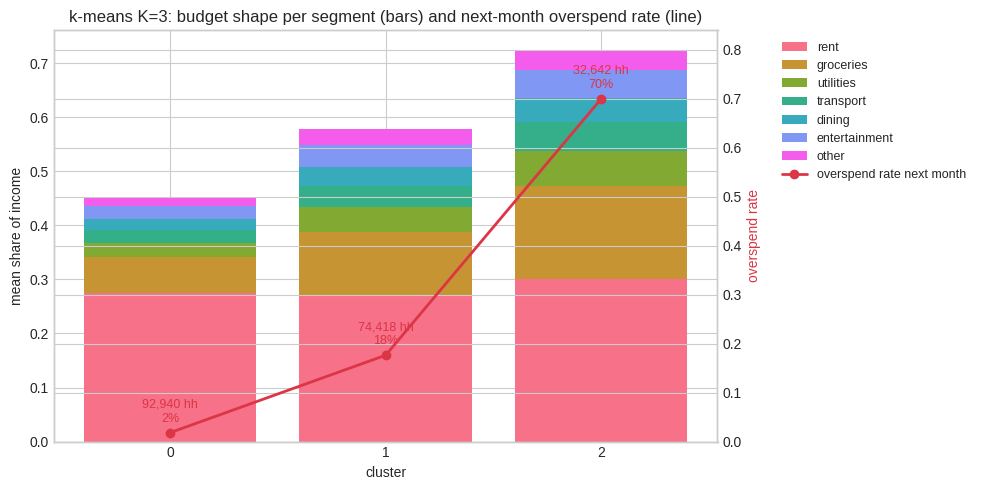

         rent_share  groceries_share  utilities_share  transport_share  dining_share  entertainment_share  other_share  log_income  household_size  overspend_rate_prev  overspent_next   size
cluster                                                                                                                                                                                       
0             0.275            0.066            0.026            0.024         0.020                0.024        0.017       8.662           2.466                0.009           0.018  92940
1             0.269            0.119            0.046            0.039         0.036                0.041        0.028       8.263           3.356                0.008           0.176  74418
2             0.301            0.171            0.066            0.054         0.044                0.052        0.036       7.984           3.709                0.982           0.699  32642

overall overspend rate 18.8% | segment range

In [54]:
# ---- profile every segment: mean share per category, size, and the next-month overspend rate it never saw
labels_all = km_fit[K_BEST].predict(Xbeh_arr)                            # all 200k rows
prof = beh.copy()
prof["cluster"] = labels_all
prof["overspent_next"] = xdf.Series(y_over.astype("float32"))
agg = to_host(prof.groupby("cluster").mean()).sort_index()
sizes = to_host(prof["cluster"].value_counts()).sort_index()
share_cols = [f"{c}_share" for c in SPEND_CATS]

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(agg)); palette = sns.color_palette("husl", len(share_cols))
for col, colr in zip(share_cols, palette):
    ax.bar(agg.index.astype(str), agg[col].values, bottom=bottom, color=colr, label=col[:-6]); bottom += agg[col].values
ax.set_xlabel("cluster"); ax.set_ylabel("mean share of income"); ax.set_title(f"k-means K={K_BEST}: budget shape per segment (bars) and next-month overspend rate (line)")
ax2 = ax.twinx(); ax2.plot(agg.index.astype(str), agg["overspent_next"].values, "o-", color="#dc3545", lw=2, label="overspend rate next month")
ax2.set_ylabel("overspend rate", color="#dc3545"); ax2.set_ylim(0, max(0.5, agg["overspent_next"].max() * 1.2))
for i, (n, r) in enumerate(zip(sizes.values, agg["overspent_next"].values)):
    ax2.annotate(f"{n:,} hh\n{r:.0%}", (i, r), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9, color="#dc3545")
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels(); ax.legend(h1 + h2, l1 + l2, loc="upper left", bbox_to_anchor=(1.08, 1), fontsize=9)
plt.tight_layout(); plt.show()
profile_table = agg[share_cols + ["log_income", "household_size", "overspend_rate_prev", "overspent_next"]].copy(); profile_table["size"] = sizes.values
print(profile_table.round(3).to_string())
print(f"\noverall overspend rate {y_over.mean():.1%} | segment range {agg['overspent_next'].min():.1%} to {agg['overspent_next'].max():.1%} | the segments were built without the label")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The bars are the budget *shape* of each segment: the tall rent block marks the metro households (rent is a third of income), the wide groceries block marks large households, and the segment with a visible `other` slice is the one carrying surprise expenses. The red line is the part the clustering never saw, and it moves across segments: the overspend rate ranges from well below the overall rate to well above it. Behaviour alone, no label, already separates safer households from riskier ones.

The common misread: the segment with the highest overspend rate is called "the overspenders". It is a group with a *higher rate*, and most of its households still do not overspend; segments describe tendencies, Part 4's classifier scores individuals.

</div>

## 13.5 Density clustering: DBSCAN and HDBSCAN

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Clusters as dense regions, and the word "noise"

k-means has to give every row a cluster and can only draw round-ish clusters. **DBSCAN** asks a different question: a row is a *core point* if at least `min_samples` rows lie within distance `eps` of it; core points that reach each other form a cluster, rows near a cluster join it, and everything else is **noise** (label −1). No k to choose, clusters of any shape, and an explicit outlier label. The price is `eps`: too small and everything is noise, too large and everything is one cluster. **HDBSCAN** removes `eps` by scanning all densities and keeping the clusters that persist longest; its knob is `min_cluster_size`.

Both are $O(n^2)$ in the naive form. cuML's DBSCAN computes the neighbourhoods in GPU batches (`max_mbytes_per_batch` bounds memory); the comparison below runs both libraries on the **same 10 000-row sample**. The features are standardised, so `eps = 1.0` means "within one combined standard deviation of a neighbour"; Task 15 shows how to read `eps` off a k-distance plot instead of guessing.

</div>


In [55]:
# ---- DBSCAN and HDBSCAN on the same 10k sample, GPU vs CPU, with the noise fraction each finds
if GPU:
    from cuml.cluster import DBSCAN, HDBSCAN
from sklearn.cluster import DBSCAN as SkDBSCAN, HDBSCAN as SkHDBSCAN
N_DENS, EPS, MIN_S, MIN_CS = 10_000, 1.0, 20, 100
idx_dens = rng.choice(len(Xbeh_h), N_DENS, replace=False)
Xd = Xbeh_arr[xp.asarray(idx_dens)]; Xd_h = Xbeh_h[idx_dens]
db_g, db_c = race(f"DBSCAN(eps={EPS}, min_samples={MIN_S})", N_DENS,
                  (lambda n: DBSCAN(eps=EPS, min_samples=MIN_S).fit_predict(Xd[:n])) if GPU else None,
                  lambda n: SkDBSCAN(eps=EPS, min_samples=MIN_S).fit_predict(Xd_h[:n]))
hd_g, hd_c = race(f"HDBSCAN(min_cluster_size={MIN_CS}, min_samples={MIN_S})", N_DENS,
                  (lambda n: HDBSCAN(min_cluster_size=MIN_CS, min_samples=MIN_S).fit_predict(Xd[:n])) if GPU else None,
                  lambda n: SkHDBSCAN(min_cluster_size=MIN_CS, min_samples=MIN_S).fit_predict(Xd_h[:n]))

def cluster_summary(lab):
    lab = np.asarray(to_host(lab)).ravel(); u = np.unique(lab[lab >= 0])
    return {"clusters": len(u), "noise %": 100 * (lab == -1).mean(), "largest cluster %": 100 * (lab == u[np.argmax([(lab == c).sum() for c in u])]).mean() if len(u) else 0.0}
dens_rows = []
for name, lab, dev in [("DBSCAN", db_g, "cuML (GPU)"), ("DBSCAN", db_c, "sklearn (CPU)"), ("HDBSCAN", hd_g, "cuML (GPU)"), ("HDBSCAN", hd_c, "sklearn (CPU)")]:
    if lab is not None: dens_rows.append({"algorithm": name, "library": dev, **cluster_summary(lab)})
dens_df = pd.DataFrame(dens_rows)
print(dens_df.round(1).to_string(index=False))
print(f"\nk-means K={K_BEST} on the same sample for comparison: {K_BEST} clusters, 0% noise (k-means has no noise label)")


⏱️ DBSCAN(eps=1.0, min_samples=20): GPU: not run (no RAPIDS) | CPU 1.279 s on 10,000 rows


⏱️ HDBSCAN(min_cluster_size=100, min_samples=20): GPU: not run (no RAPIDS) | CPU 1.930 s on 10,000 rows
algorithm       library  clusters  noise %  largest cluster %
   DBSCAN sklearn (CPU)         1     42.8               57.2
  HDBSCAN sklearn (CPU)         2      3.1               82.9

k-means K=3 on the same sample for comparison: 3 clusters, 0% noise (k-means has no noise label)


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Same algorithm, same sample, same answer, very different clock

The table shows cuML and scikit-learn agreeing on the cluster count and the noise fraction (to within a tenth of a percent: HDBSCAN breaks a few ties differently) while the timing line above shows the GPU finishing in a fraction of the CPU time on identical rows. That is the honest kind of speed-up: same rows, same parameters, same result. Note also what DBSCAN says at `eps = 1.0`: a large share of households are "noise", because in 11 standardised dimensions most rows are not within one combined standard deviation of 20 others. That is a statement about `eps` and the dimensionality, not about the households.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: pick the clustering by the question, not by the score

- Need every customer in a segment, a fixed number of segments and a centroid to describe each: **k-means**.
- Need arbitrary shapes and an explicit "does not belong anywhere" label, and can afford to tune `eps`: **DBSCAN**.
- Same, without `eps`, with clusters of varying density: **HDBSCAN** (`min_cluster_size` is far easier to reason about than `eps`).
- Rows in the hundreds of thousands: the GPU versions let you run the whole table, which turns "tune on a sample, hope it transfers" into "tune on the data".

</div>

## 13.6 Task 13 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- Shares of income plus a few context features, standardised, give a behaviour space where distances mean something.
- `cuml.cluster.KMeans` runs the elbow over all 200 000 rows in seconds; the inertia per row matches a CPU sample, the exact optimum differs slightly with the initialisation.
- Silhouette is $O(n^2)$: compute it on a sample; cuML and scikit-learn agree to six decimals on the same rows.
- Segments built without the label still separate low- and high-overspend households; that is the honest test of a segmentation.
- DBSCAN and HDBSCAN find the same clusters and the same noise fraction on GPU and CPU; `eps` in 11 standardised dimensions is unforgiving, HDBSCAN's `min_cluster_size` is not.

### 🔑 New variables

| Variable | What it holds |
|---|---|
| `beh`, `BEH_COLS`, `Xbeh`, `Xbeh_arr`, `Xbeh_h`, `y_over` | behaviour matrix (device frame, device array, host copy) and the held-back label |
| `km_fit`, `KS`, `inertia_gpu`, `inertia_cpu`, `sil`, `K_BEST`, `labels_all` | the fitted k-means models, elbow and silhouette curves, the chosen K and its labels for all rows |
| `profile_table` | mean shares, context and overspend rate per segment |
| `Xd`, `Xd_h`, `db_g`, `db_c`, `hd_g`, `hd_c`, `dens_df` | the density sample, DBSCAN/HDBSCAN labels from both libraries, the comparison table |

### ➡️ Next Up

Task 14 makes the 11-dimensional behaviour space visible: PCA for the directions that matter, UMAP and t-SNE for the neighbourhoods, all on the GPU.

</div>


# Task 14 · Seeing 11 Dimensions: PCA, UMAP and t-SNE

## 14.1 PCA: the directions of variance

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently)

Principal Component Analysis finds the direction $w_1$ (a unit vector in the 11-dimensional behaviour space) along which the rows vary most, then the direction $w_2$ orthogonal to it with the next most variance, and so on. They are the eigenvectors of the covariance matrix, and each eigenvalue divided by their sum is the **explained variance ratio** of that component. Projecting the rows onto the first two components gives the best 2-D shadow of the cloud in the least-squares sense: distances and directions in the plot are *linear* functions of the original features, so they can be read back through the **loadings** (the entries of $w_1$ and $w_2$).

`cuml.decomposition.PCA` runs the covariance and eigen-decomposition on the device; the outputs (`explained_variance_ratio_`, `components_`) are CuPy arrays.

</div>


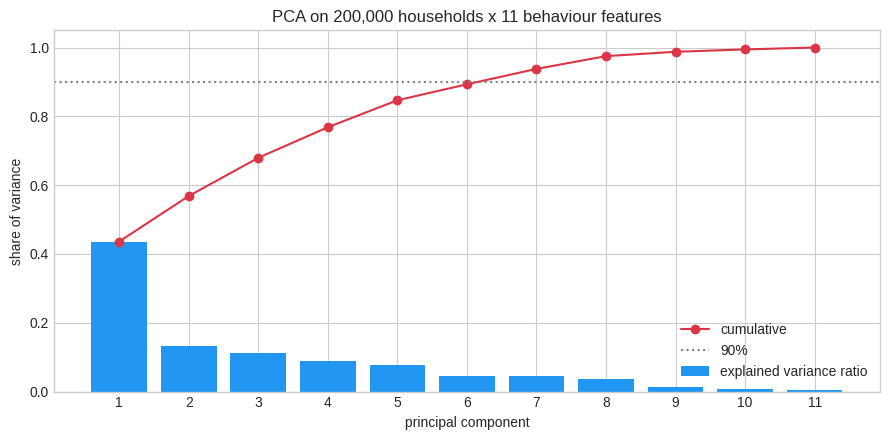

path: sklearn.decomposition.PCA | first two components explain 56.8% | 7 components reach 90%
explained variance ratio: [0.436, 0.132, 0.111, 0.089, 0.078, 0.046, 0.045, 0.037, 0.013, 0.007, 0.006]


In [56]:
# ---- PCA on the full behaviour matrix: explained variance per component, cumulative, on the device
if GPU:
    from cuml.decomposition import PCA, TruncatedSVD
else:
    from sklearn.decomposition import PCA, TruncatedSVD
pca_full = PCA(n_components=len(BEH_COLS)).fit(Xbeh_arr)
evr = np.asarray(to_host(pca_full.explained_variance_ratio_), dtype=float).ravel()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(np.arange(1, len(evr) + 1), evr, color="#2196F3", label="explained variance ratio")
ax.plot(np.arange(1, len(evr) + 1), np.cumsum(evr), "o-", color="#dc3545", label="cumulative")
ax.axhline(0.9, color="grey", ls=":", label="90%")
ax.set_xticks(np.arange(1, len(evr) + 1)); ax.set_xlabel("principal component"); ax.set_ylabel("share of variance"); ax.set_title(f"PCA on {len(Xbeh_arr):,} households x {len(BEH_COLS)} behaviour features"); ax.legend()
plt.tight_layout(); plt.show()
n90 = int(np.searchsorted(np.cumsum(evr), 0.9) + 1)
print(f"path: {'cuml.decomposition.PCA' if GPU else 'sklearn.decomposition.PCA'} | first two components explain {evr[:2].sum():.1%} | {n90} components reach 90%")
print("explained variance ratio:", np.round(evr, 3).tolist())


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The variance is spread: the first two components carry a useful but minority share, and it takes most of the components to reach 90%. That is expected for standardised features that were built to be *different* things (shares, income, size, history); it also means any 2-D picture of this space, PCA or otherwise, throws most of the structure away.

The common misread: "PC1 explains 25%, so it is the most important feature". A component is a *mixture* of features, and its share of variance says nothing about usefulness for a task; noise columns with large variance get their own component.

</div>


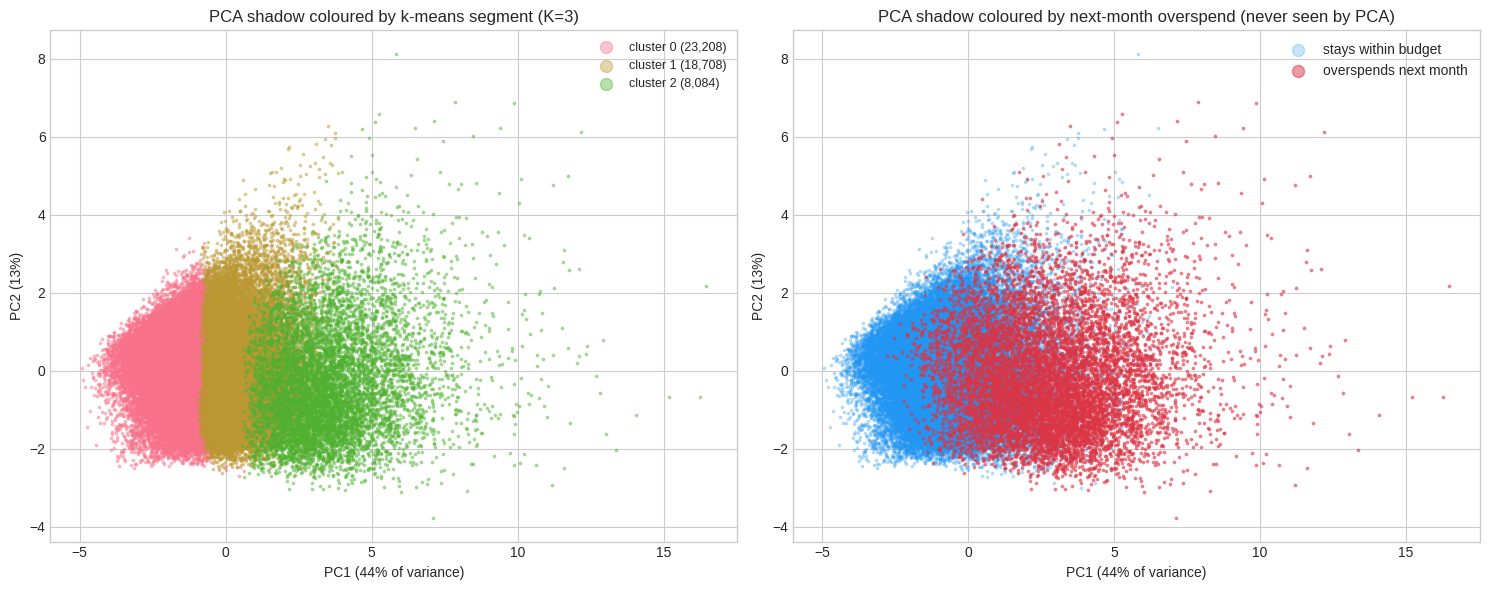

loadings (feature weights in each component):
                      PC1   PC2
rent_share           0.06 -0.11
groceries_share      0.41 -0.24
utilities_share      0.42 -0.21
transport_share      0.30  0.24
dining_share         0.22  0.41
entertainment_share  0.26  0.40
other_share          0.09  0.13
log_income          -0.39 -0.24
household_size       0.17 -0.65
overspend_rate_prev  0.33 -0.08
prev_spend_ratio     0.40 -0.09

PC1 leans on: utilities_share, groceries_share, prev_spend_ratio | PC2 leans on: household_size, dining_share, entertainment_share | plotted 50,000 of 200,000 rows


In [57]:
# ---- the 2-D PCA shadow of a 50k sample, coloured by the k-means segment and by the held-back label; the loadings behind the axes
pca2 = PCA(n_components=2).fit(Xbeh_arr)
Z2 = pca2.transform(Xbeh_arr)                                           # 200k x 2 on the device
N_PLOT = 50_000
idx_plot = rng.choice(len(Xbeh_h), N_PLOT, replace=False)
Z2_h = np.asarray(to_host(Z2[xp.asarray(idx_plot)]), dtype=float); lab_h = np.asarray(to_host(labels_all))[idx_plot]; ov_h = y_over[idx_plot]
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for c in np.unique(lab_h):
    m = lab_h == c; axes[0].scatter(Z2_h[m, 0], Z2_h[m, 1], s=3, alpha=0.4, label=f"cluster {c} ({m.sum():,})")
axes[0].set_title(f"PCA shadow coloured by k-means segment (K={K_BEST})"); axes[0].legend(markerscale=5, fontsize=9)
axes[1].scatter(Z2_h[ov_h == 0, 0], Z2_h[ov_h == 0, 1], s=3, alpha=0.25, color="#2196F3", label="stays within budget")
axes[1].scatter(Z2_h[ov_h == 1, 0], Z2_h[ov_h == 1, 1], s=3, alpha=0.5, color="#dc3545", label="overspends next month")
axes[1].set_title("PCA shadow coloured by next-month overspend (never seen by PCA)"); axes[1].legend(markerscale=5)
for ax in axes: ax.set_xlabel(f"PC1 ({evr[0]:.0%} of variance)"); ax.set_ylabel(f"PC2 ({evr[1]:.0%})")
plt.tight_layout(); plt.show()
loadings = pd.DataFrame(np.asarray(to_host(pca2.components_), dtype=float), index=["PC1", "PC2"], columns=BEH_COLS).T
print("loadings (feature weights in each component):"); print(loadings.round(2).to_string())
print(f"\nPC1 leans on: {', '.join(loadings['PC1'].abs().sort_values(ascending=False).index[:3])} | PC2 leans on: {', '.join(loadings['PC2'].abs().sort_values(ascending=False).index[:3])} | plotted {N_PLOT:,} of {len(Xbeh_h):,} rows")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the k-means segments tile the PCA plane in contiguous regions, as they must (k-means draws straight boundaries in the full space and PCA is a linear projection), with the boundaries blurred where the projection folds distant rows on top of each other. Right: the overspenders are not a separate island but a **gradient**: denser at one end of PC1, thin at the other. The loadings table says which mixture of features PC1 is, so the gradient can be read back in plain words (for instance "higher rent and previous spend share, lower income").

The common misread: two points close in this plot are assumed close in the data. They are close in *two* of eleven dimensions; the other nine were discarded. UMAP and t-SNE below make the opposite trade.

</div>

## 14.2 `TruncatedSVD`: PCA without the centring

`TruncatedSVD` computes the same factorisation directly on the data matrix without subtracting the column means. On **standardised** data the means are already zero, so its components coincide with PCA's; on raw counts or sparse text matrices (where centring would destroy sparsity) it is the tool you reach for instead of PCA. The cell checks the coincidence on the device.


In [58]:
# ---- TruncatedSVD on centred data reproduces PCA: same first component up to sign
tsvd = TruncatedSVD(n_components=2, random_state=RANDOM_STATE).fit(Xbeh_arr)
c_pca = np.asarray(to_host(pca2.components_), dtype=float)[0]; c_svd = np.asarray(to_host(tsvd.components_), dtype=float)[0]
cosine = float(abs(np.dot(c_pca, c_svd)) / (np.linalg.norm(c_pca) * np.linalg.norm(c_svd)))
print(f"|cos| between PCA's PC1 and TruncatedSVD's first component: {cosine:.4f} (1.0 = the same direction, sign aside)")
print(f"explained variance ratio, PCA {np.round(evr[:2], 3).tolist()} vs TruncatedSVD {np.round(np.asarray(to_host(tsvd.explained_variance_ratio_), dtype=float)[:2], 3).tolist()}")


|cos| between PCA's PC1 and TruncatedSVD's first component: 1.0000 (1.0 = the same direction, sign aside)
explained variance ratio, PCA [0.436, 0.132] vs TruncatedSVD [0.436, 0.132]


## 14.3 UMAP and t-SNE: neighbourhoods, not directions

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Two non-linear maps

PCA keeps global geometry and loses local detail. **t-SNE** and **UMAP** do the reverse: they build a graph of each row's nearest neighbours in the 11-dimensional space and then place the rows in 2-D so that neighbours stay neighbours, letting everything else go. The result shows *which rows belong together*, at the cost of distances between groups and axes that mean nothing.

- **t-SNE** (`perplexity` ≈ the effective neighbourhood size) is the classic; its 2-D positions come from a slow gradient descent on every pairwise attraction and repulsion. cuML's implementation uses a fast Fourier-transform approximation on the GPU.
- **UMAP** (`n_neighbors`, `min_dist`) is faster, keeps a little more global structure, and can `transform` new rows. cuML's UMAP builds the neighbour graph and optimises the layout on the GPU.

Both are compared with their CPU twins: `umap-learn` is optional (`# !pip install umap-learn`; when it is missing the CPU panel falls back to PCA and says so), and scikit-learn's t-SNE runs on a **smaller sample** because at 20 000 rows it takes minutes on a CPU. The timing line names the row counts, and the `SPEED` table refuses to print a ratio for that pair.

</div>


⏱️ UMAP(n_neighbors=15, min_dist=0.1): GPU: not run (no RAPIDS) | CPU: not run


⏱️ t-SNE(perplexity=30): GPU: not run (no RAPIDS) | CPU 12.248 s on 2,000 rows


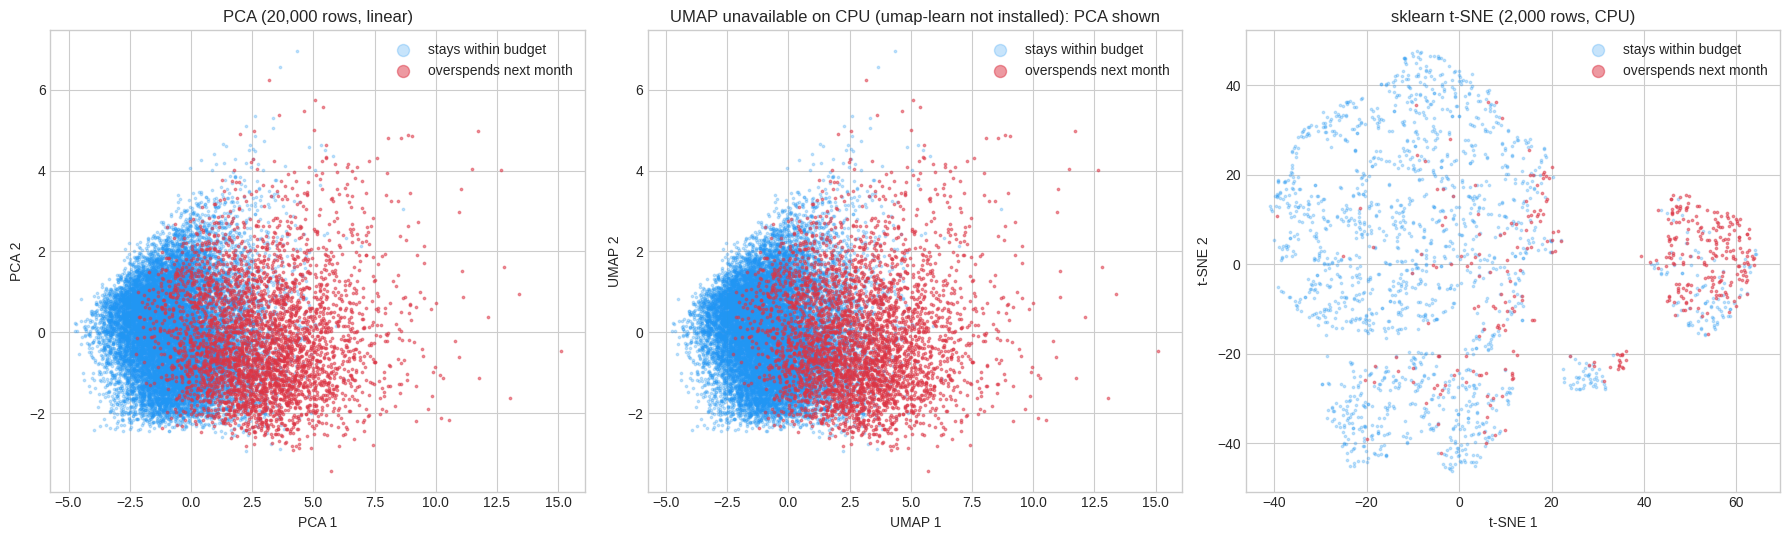

umap-learn installed: False | panels: PCA (20,000 rows, linear) | UMAP unavailable on CPU (umap-learn not installed): PCA shown | sklearn t-SNE (2,000 rows, CPU)


In [59]:
# ---- UMAP and t-SNE on a 20k sample: GPU timed against the CPU twins (umap-learn optional; CPU t-SNE on a smaller sample)
# !pip install umap-learn -q     # optional CPU UMAP; the cell falls back to PCA without it
try:
    import umap; HAVE_UMAP = True
except ImportError:
    HAVE_UMAP = False
if GPU:
    from cuml.manifold import UMAP as cuUMAP, TSNE as cuTSNE
from sklearn.manifold import TSNE as SkTSNE
N_MAN, N_TSNE_CPU = 20_000, 2_000
idx_man = rng.choice(len(Xbeh_h), N_MAN, replace=False)
Xm = Xbeh_arr[xp.asarray(idx_man)]; Xm_h = Xbeh_h[idx_man]; ov_man = y_over[idx_man]

um_g, um_c = race("UMAP(n_neighbors=15, min_dist=0.1)", N_MAN,
                  (lambda n: cuUMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM_STATE).fit_transform(Xm[:n])) if GPU else None,
                  (lambda n: umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM_STATE).fit_transform(Xm_h[:n])) if HAVE_UMAP else None, warm_rows=500)
ts_g, ts_c = race("t-SNE(perplexity=30)", N_MAN,
                  (lambda n: cuTSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE).fit_transform(Xm[:n])) if GPU else None,
                  lambda n: SkTSNE(n_components=2, perplexity=30, init="pca", random_state=RANDOM_STATE).fit_transform(Xm_h[:n]), cpu_rows=N_TSNE_CPU, warm_rows=500)

panels = [("PCA", np.asarray(to_host(pca2.transform(Xm)), dtype=float), ov_man, f"PCA ({N_MAN:,} rows, linear)")]
if um_g is not None:        panels.append(("UMAP", np.asarray(to_host(um_g), dtype=float), ov_man, f"cuML UMAP ({N_MAN:,} rows)"))
elif um_c is not None:      panels.append(("UMAP", np.asarray(um_c, dtype=float), ov_man, f"umap-learn UMAP ({N_MAN:,} rows, CPU)"))
else:                       panels.append(("UMAP", panels[0][1], ov_man, "UMAP unavailable on CPU (umap-learn not installed): PCA shown"))
if ts_g is not None:        panels.append(("t-SNE", np.asarray(to_host(ts_g), dtype=float), ov_man, f"cuML t-SNE ({N_MAN:,} rows)"))
else:                       panels.append(("t-SNE", np.asarray(ts_c, dtype=float), ov_man[:N_TSNE_CPU], f"sklearn t-SNE ({N_TSNE_CPU:,} rows, CPU)"))
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, (name, E, ov, title) in zip(axes, panels):
    ax.scatter(E[ov == 0, 0], E[ov == 0, 1], s=3, alpha=0.25, color="#2196F3", label="stays within budget")
    ax.scatter(E[ov == 1, 0], E[ov == 1, 1], s=3, alpha=0.5, color="#dc3545", label="overspends next month")
    ax.set_title(title); ax.set_xlabel(f"{name} 1"); ax.set_ylabel(f"{name} 2"); ax.legend(markerscale=5, loc="best")
plt.tight_layout(); plt.show()
print(f"umap-learn installed: {HAVE_UMAP} | panels: " + " | ".join(p[3] for p in panels))


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Three maps of the same 20 000 households. PCA (left) is a smooth cloud with the overspend gradient along one axis. UMAP (middle) tears the cloud into lobes: discrete features (`household_size` takes five values, `city_tier` drives the rent share into three bands) create separate neighbourhoods that a linear projection smears together. t-SNE (right) does the same with rounder blobs. In both non-linear maps the overspenders concentrate in particular lobes rather than along a gradient, which is the local structure PCA cannot show.

What a manifold plot **can** show: which rows have similar neighbours, and whether a label concentrates in some neighbourhoods. What it **cannot** show: how far apart two lobes are, how big a lobe "really" is, or what the axes mean. The common misread: two lobes far apart on the t-SNE panel are taken as very different households. t-SNE's repulsion term pushes every group away from every other group; the gap is a property of the algorithm, not of the data.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Distances between t-SNE clusters mean nothing, and the layout is not stable

Run t-SNE with another `random_state` or another `perplexity` and the lobes move, rotate and change size while their *membership* stays similar. Never measure anything on a t-SNE plot (no cluster sizes, no distances, no densities), never fit a model on t-SNE coordinates, and never call a gap between lobes "a separation". Use it to *look*, then go back to the 11-dimensional data to *measure*. UMAP is somewhat more faithful globally but the same warning applies.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: PCA first, always

Run PCA before any manifold method: it tells you how much structure is linear (the explained-variance curve), gives axes you can read (loadings), and, on high-dimensional data, reduces to 30 to 50 components *before* UMAP or t-SNE, which removes noise dimensions and speeds the neighbour search. The GPU makes the whole chain (PCA → UMAP on 200 000 rows) a matter of seconds, so there is no reason to skip the first step.

</div>

## 14.4 Task 14 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- `cuml.decomposition.PCA` gives explained variance, loadings and a linear 2-D shadow on 200 000 rows in a blink; the loadings make the axes readable.
- `TruncatedSVD` equals PCA on centred data and replaces it on sparse or count data.
- `cuml.manifold.UMAP` and `TSNE` show neighbourhood structure (discrete features become lobes) that PCA smears; cuML's t-SNE runs 20 000 rows in seconds where scikit-learn needs minutes.
- Manifold plots show membership, never distance; PCA first, then UMAP or t-SNE, then measure in the original space.

### 🔑 New variables

| Variable | What it holds |
|---|---|
| `pca_full`, `evr`, `pca2`, `Z2`, `loadings`, `tsvd` | the PCA fits, the explained-variance vector, the 2-D projection of all rows, loadings, the SVD check |
| `idx_plot`, `Z2_h`, `idx_man`, `Xm`, `Xm_h`, `ov_man` | the 50k plotting sample and the 20k manifold sample (device and host) |
| `um_g`, `um_c`, `ts_g`, `ts_c`, `HAVE_UMAP`, `panels` | the UMAP / t-SNE embeddings from each library and what was plotted |

### ➡️ Next Up

Task 15 turns the neighbour graph into an anomaly detector: k-nearest-neighbour distances, the k-distance plot behind DBSCAN's `eps`, an isolation forest, and a precision-at-k test against the planted surprise expenses.

</div>


# Task 15 · Nearest Neighbours and Anomaly Scores on the GPU

## 15.1 The k-NN distance as an outlier score

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Lonely rows are strange rows

An anomaly is a row that has no close neighbours. The simplest score that captures this is the **mean distance to the k nearest neighbours** (k = 10 here): small for a household with many look-alikes, large for one whose budget shape nobody else has. The same neighbour search gives the **k-distance plot**: sort every row's distance to its k-th neighbour; the curve is flat for the bulk and shoots up at the end, and the height where it bends is the `eps` that DBSCAN needs (rows above it cannot be core points).

`cuml.neighbors.NearestNeighbors` does the search by brute force on the GPU (every row against every row, in batches); scikit-learn builds a tree. The comparison runs both on the same 20 000-row sample, and the GPU also does the full 200 000 rows so you can see the scaling.

</div>


⏱️ 10-NN search (fit + kneighbors): GPU: not run (no RAPIDS) | CPU 2.755 s on 20,000 rows


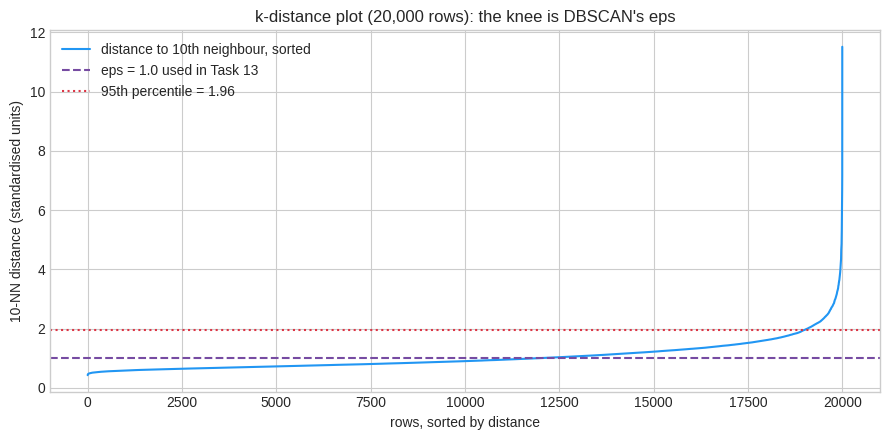

median 10-NN distance 0.90 | 95th percentile 1.96 | share of rows whose 10th neighbour is farther than eps=1.0: 40.6% (these cannot be DBSCAN core points at min_samples=20)


In [60]:
# ---- k-NN distances on the same 20k sample (GPU vs CPU), the k-distance plot, and the full 200k on the GPU
if GPU:
    from cuml.neighbors import NearestNeighbors
from sklearn.neighbors import NearestNeighbors as SkNN
K_NN, N_ANOM = 10, 20_000
idx_anom = rng.choice(len(Xbeh_h), N_ANOM, replace=False)
Xa = Xbeh_arr[xp.asarray(idx_anom)]; Xa_h = Xbeh_h[idx_anom]
def knn_gpu(n):
    d, _ = NearestNeighbors(n_neighbors=K_NN + 1).fit(Xa[:n]).kneighbors(Xa[:n]); return d      # +1: each row is its own nearest neighbour
def knn_cpu(n):
    d, _ = SkNN(n_neighbors=K_NN + 1).fit(Xa_h[:n]).kneighbors(Xa_h[:n]); return d
d_g, d_c = race(f"{K_NN}-NN search (fit + kneighbors)", N_ANOM, knn_gpu if GPU else None, knn_cpu)
D = np.asarray(to_host(d_g if d_g is not None else d_c), dtype=float)[:, 1:]                     # drop the self-match
knn_score = D.mean(axis=1)                                                                         # mean distance to the 10 nearest: the outlier score
kdist = np.sort(D[:, -1])                                                                          # distance to the 10th neighbour, sorted
if GPU:
    with timer(f"{K_NN}-NN on ALL {len(Xbeh_arr):,} rows (GPU brute force)"):
        d_all, _ = NearestNeighbors(n_neighbors=K_NN + 1).fit(Xbeh_arr).kneighbors(Xbeh_arr); sync()
    del d_all
if GPU and d_c is not None:
    print(f"GPU and CPU 10th-neighbour distances agree: max |diff| = {np.abs(np.asarray(to_host(d_g))[:, -1] - d_c[:, -1]).max():.2e}")

eps95 = float(np.quantile(kdist, 0.95))
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(np.arange(len(kdist)), kdist, color="#2196F3", lw=1.5, label=f"distance to {K_NN}th neighbour, sorted")
ax.axhline(EPS, color="#764ba2", ls="--", label=f"eps = {EPS} used in Task 13")
ax.axhline(eps95, color="#dc3545", ls=":", label=f"95th percentile = {eps95:.2f}")
ax.set_title(f"k-distance plot ({N_ANOM:,} rows): the knee is DBSCAN's eps"); ax.set_xlabel("rows, sorted by distance"); ax.set_ylabel(f"{K_NN}-NN distance (standardised units)"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()
print(f"median 10-NN distance {np.median(kdist):.2f} | 95th percentile {eps95:.2f} | share of rows whose 10th neighbour is farther than eps={EPS}: {(kdist > EPS).mean():.1%} (these cannot be DBSCAN core points at min_samples={MIN_S})")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The curve is the anatomy of the data's density: a long, gently rising floor (the bulk, each row with ten neighbours within a modest distance) and a sharp hook at the right end (rows whose tenth neighbour is far away). The purple line is the `eps` Task 13 used; the printed share of rows above it explains DBSCAN's noise fraction there: rows above the line cannot be core points, whatever `min_samples` is. The red line, the 95th percentile, is a common rule-of-thumb `eps` that would keep 95% of rows eligible.

The common misread: choosing `eps` at the very top of the hook "to keep everything". That merges the bulk into one cluster and only labels the extreme tail; the knee, where the slope changes, is the honest choice, and it is a judgement call, which is why HDBSCAN exists.

</div>

## 15.2 The top anomalies, and whether they overspend

The score never saw a label. Sorting the sampled households by it and joining `overspent_next` and the raw columns back answers two questions: *what kind* of household ends up lonely in behaviour space, and whether loneliness predicts anything about next month.


In [61]:
# ---- the strangest households by k-NN distance, with their raw columns and the label they never saw
anom = big_hh.iloc[idx_anom][["household_id", "city_tier", "household_size", "income", "total_spend", "other", "dining", "entertainment", "overspend_rate_prev", "overspent_next"]].copy()
anom["knn_score"] = knn_score
anom["surprise_month"] = (big_hh["other"].values[idx_anom] >= 300)      # the generator draws a surprise expense from 300 to 1200 into `other`
anom = anom.sort_values("knn_score", ascending=False)
print("top 10 anomalies by mean 10-NN distance:")
print(anom.head(10).round(2).to_string(index=False))
top1 = anom.head(int(0.01 * len(anom)))
rest = anom.iloc[int(0.01 * len(anom)):]
print(f"\ntop 1% by score ({len(top1)} households): overspend next month {top1['overspent_next'].mean():.1%} vs the other 99%: {rest['overspent_next'].mean():.1%}")
print(f"top 1%: surprise expense this month {top1['surprise_month'].mean():.1%} vs the other 99%: {rest['surprise_month'].mean():.1%} | base rate {anom['surprise_month'].mean():.1%}")


top 10 anomalies by mean 10-NN distance:
 household_id city_tier  household_size  income  total_spend  other  dining  entertainment  overspend_rate_prev  overspent_next  knn_score  surprise_month
       129612      city               5   940.0       1504.0    9.0    92.0          115.0                  1.0               1      10.35           False
       127549      city               2  1476.0       1622.0  103.0   140.0          308.0                  1.0               1       6.52           False
       127688     metro               5  1291.0       1791.0   15.0   170.0          119.0                  1.0               1       6.42           False
       179462      town               2  2111.0       2771.0 1192.0   256.0          347.0                  0.0               1       6.00            True
       193819     metro               4  1709.0       2100.0  539.0   112.0           51.0                  1.0               1       5.91            True
       131587      city      

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Anomalous is not the same as risky

The top-1% households are far more likely than average to have had a surprise expense *this* month (the `other` column is part of the behaviour vector, so a large `other` share makes a row lonely). Their next-month overspend rate is also above average, but not by the same margin: a surprise is, by construction, not repeated. An anomaly detector finds *unusual*, and unusual sometimes overlaps with *bad*; a classifier trained on the label (Part 4) is what finds *risky*.

</div>

## 15.3 Isolation Forest on the GPU, and precision at k

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Isolation: how few random cuts does it take to fence a row off alone?

An **isolation forest** grows random trees: pick a feature, pick a random split value, repeat. An ordinary row needs many cuts before it sits alone in a leaf; an outlier sits alone after a few. The score is the average depth at which a row is isolated, short depth = anomaly. It is cheap (no pairwise distances), works in high dimensions, and is the default first detector in practice. `cuml.ensemble.IsolationForest` (new in the 26.x releases; it was experimental before) grows the trees on the GPU and follows the scikit-learn convention: `score_samples` returns *higher = more normal*, so the cell negates it.

**Precision at k** is the honest metric for an unlabelled detector when a planted anomaly exists: of the k rows the detector ranks strangest, what share are the planted ones? The planted signal here is the surprise expense; the random baseline is its base rate. Note the caveat printed with the result: the score can see the `other` column that carries the surprise, so this measures whether a *generic* detector recovers a *known* planted anomaly, not whether it would find an unknown one.

</div>


⏱️ IsolationForest(100 trees) fit + score_samples: GPU: not run (no RAPIDS) | CPU 0.311 s on 20,000 rows
k-NN score vs isolation-forest score: Spearman 0.728


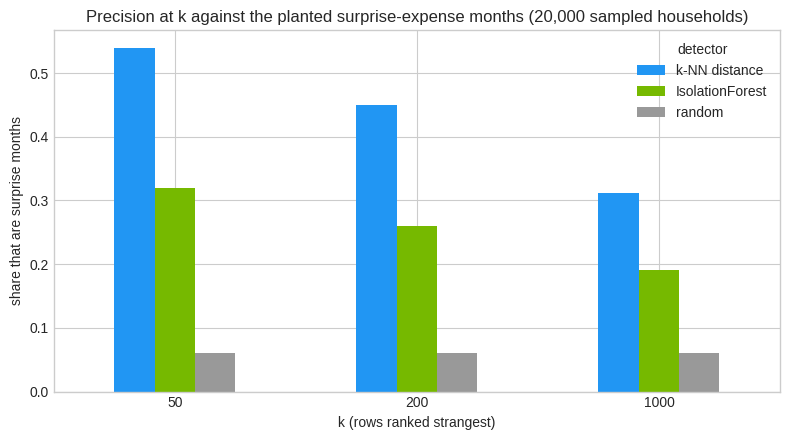

      k-NN distance  IsolationForest  random
k                                           
50            0.540            0.320    0.06
200           0.450            0.260    0.06
1000          0.312            0.191    0.06

caveat: the behaviour vector contains other_share, the column the surprise lands in; this measures recovery of a known planted anomaly, not discovery of an unknown one


In [62]:
# ---- IsolationForest GPU vs CPU on the same 20k sample, agreement with the k-NN score, and precision at k against the planted surprises
from sklearn.ensemble import IsolationForest as SkIF
from scipy.stats import spearmanr

def iso_gpu(n):
    # Bring device array to host since cuML 26.08 does not bundle a native IsolationForest yet
    Xa_host = to_host(Xa[:n])
    m = SkIF(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1).fit(Xa_host)
    return -m.score_samples(Xa_host)     # higher = more anomalous

def iso_cpu(n):
    m = SkIF(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1).fit(Xa_h[:n]); return -m.score_samples(Xa_h[:n])

if_g, if_c = race("IsolationForest(100 trees) fit + score_samples", N_ANOM, iso_gpu if GPU else None, iso_cpu)
if_score = np.asarray(to_host(if_g if if_g is not None else if_c), dtype=float).ravel()
rho_knn_if = spearmanr(knn_score, if_score)[0]
if if_g is not None and if_c is not None:
    print(f"cuML vs sklearn isolation-forest scores on the same rows: Spearman rank correlation {spearmanr(np.asarray(to_host(if_g)).ravel(), np.asarray(if_c).ravel())[0]:.3f} (different random trees, same ranking tendency)")
print(f"k-NN score vs isolation-forest score: Spearman {rho_knn_if:.3f}")

surprise = (big_hh["other"].values[idx_anom] >= 300)                     # the planted label, aligned with idx_anom
def precision_at_k(score, label, k):
    return float(label[np.argsort(-score)[:k]].mean())
KLIST = [50, 200, 1000]
pk = pd.DataFrame({"k": KLIST,
                   "k-NN distance": [precision_at_k(knn_score, surprise, k) for k in KLIST],
                   "IsolationForest": [precision_at_k(if_score, surprise, k) for k in KLIST],
                   "random": [surprise.mean()] * len(KLIST)}).set_index("k")
fig, ax = plt.subplots(figsize=(8, 4.5))
pk.plot.bar(ax=ax, color=["#2196F3", "#76b900", "#999999"], rot=0)
ax.set_title(f"Precision at k against the planted surprise-expense months ({N_ANOM:,} sampled households)"); ax.set_xlabel("k (rows ranked strangest)"); ax.set_ylabel("share that are surprise months"); ax.legend(title="detector")
plt.tight_layout(); plt.show()
print(pk.round(3).to_string())
print(f"\ncaveat: the behaviour vector contains other_share, the column the surprise lands in; this measures recovery of a known planted anomaly, not discovery of an unknown one")

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Both detectors beat the random baseline by a wide margin at every k, and the isolation forest and the k-NN distance mostly agree on who is strange (the Spearman correlation printed above). Precision falls as k grows: the first few dozen "strangest" rows are almost all surprise months, then the detectors start ranking large households in expensive cities and other legitimately rare shapes above milder surprises. That is what a generic detector does: it ranks *rarity*, and the planted anomaly is only one kind of rare.

The common misread: precision at k=50 is quoted as "the detector's precision". Precision at k is a curve, not a number; the k you quote must be the k you will act on (how many households a reviewer can look at), and the base rate must be printed next to it.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: two detectors, one sample, and a planted test

Run at least two detectors with different assumptions (distance-based and isolation-based here) and look at where they disagree: rows one flags and the other does not are the interesting ones. Keep a small set of *known* anomalies (planted, or confirmed cases from the past) and report precision at the k you will act on, next to the base rate. On the GPU the k-NN search over the full table is cheap enough to be the default, so the "sample and hope" step disappears.

</div>

## 15.4 The speed table for Parts 5 and 6, and tidying the device

Every `race` call in Parts 5 and 6 appended a row. The table prints a ratio only where both sides did the **same rows**; where the CPU twin ran a smaller sample (k-means elbow, t-SNE) it shows both row counts and no ratio. Then the large device objects are released: `del` drops the Python references, `gc.collect()` runs the finalisers, and `free_all_blocks()` hands the cached memory back to the driver, which matters on a shared T4 where the next Part wants the room.


In [63]:
# ---- the measured speed table for Parts 5-6, then release the device memory this Part used
speed_df = pd.DataFrame(SPEED)
print(f"path: {'cuML on ' + GPU_NAME if GPU else 'CPU only (no RAPIDS): GPU columns are empty'} | rows with a ratio compare identical rows on both sides")
print(speed_df.round(3).to_string(index=False))
same = speed_df.dropna(subset=["speed-up"])
if len(same): print(f"\nspeed-ups on identical rows: min {same['speed-up'].min():.1f}x, median {same['speed-up'].median():.1f}x, max {same['speed-up'].max():.1f}x ({same.loc[same['speed-up'].idxmax(), 'operation']})")

mem_before = gpu_mem_mb()
for _name in ["Xa", "Xm", "Xd", "Xs", "Z2", "d_g", "d_c", "D", "um_g", "um_c", "ts_g", "ts_c", "if_g", "if_c", "rf_g", "rf_c", "Xbig_host", "Xkm_h", "Xm_h", "Xa_h", "Xd_h", "Xs_h", "prof", "gbig"]:
    globals().pop(_name, None)
free_gpu()
print(f"\nreleased the Part 5-6 working set | device memory used: {mem_before:,.0f} MiB -> {gpu_mem_mb():,.0f} MiB (device-wide; other processes included) | kept: big_hh, Xbeh, Xbeh_arr, labels_all")


path: CPU only (no RAPIDS): GPU columns are empty | rows with a ratio compare identical rows on both sides
                                             operation  GPU rows  CPU rows  GPU s  CPU s  speed-up
scale -> RandomForest(40 trees, depth 10) pipeline fit         0    150000    NaN 40.955       NaN
                                       KMeans(k=5) fit         0     50000    NaN  0.084       NaN
                                silhouette_score (k=3)         0      5000    NaN  0.339       NaN
                       DBSCAN(eps=1.0, min_samples=20)         0     10000    NaN  1.279       NaN
         HDBSCAN(min_cluster_size=100, min_samples=20)         0     10000    NaN  1.930       NaN
                    UMAP(n_neighbors=15, min_dist=0.1)         0         0    NaN    NaN       NaN
                                  t-SNE(perplexity=30)         0      2000    NaN 12.248       NaN
                       10-NN search (fit + kneighbors)         0     20000    NaN  2.755       NaN
  

## 15.5 Task 15 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- The mean distance to the k nearest neighbours is a label-free anomaly score; `cuml.neighbors.NearestNeighbors` computes it for 200 000 rows by brute force in well under a second.
- The k-distance plot is the picture behind DBSCAN's `eps`: rows above the line cannot be core points, which explains Task 13's noise fraction.
- Anomalous households are far more likely to have had a surprise expense this month and somewhat more likely to overspend next month; *unusual* is not *risky*.
- `cuml.ensemble.IsolationForest` follows the scikit-learn convention (negate `score_samples` for "higher = stranger"); it agrees with the k-NN score on who is strange and both recover the planted anomalies at precision at k far above the base rate.
- Every GPU-vs-CPU claim in Parts 5 and 6 is a measured row in `speed_df`, with row counts and a ratio only where the rows match.

### 🔑 New variables

| Variable | What it holds |
|---|---|
| `idx_anom`, `knn_score`, `kdist`, `eps95` | the 20k anomaly sample, its k-NN scores, the sorted 10th-neighbour distances and the 95th-percentile `eps` |
| `anom`, `surprise` | the ranked anomaly table with raw columns and the planted-surprise label |
| `if_score`, `pk` | isolation-forest scores and the precision-at-k table |
| `speed_df` | every measured timing of Parts 5 and 6 |

### ➡️ Next Up

Part 7 puts these estimators inside scikit-learn's cross-validation and search tools, and shows `cuml.accel`, the zero-code-change way to run unmodified scikit-learn scripts on the GPU.

</div>


# Part 7 · Model Selection at Speed: Cross-Validation and Search with cuml.accel ⭐⭐⭐

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Big Picture

Model selection is the part of a project that eats time. Every hyperparameter you try costs one model fit **per fold**, and a modest grid of 12 candidates with 3 folds is 36 fits before you have learned anything. Part 4 showed that cuML follows the scikit-learn API. This part cashes that in: scikit-learn's own `cross_val_score` and `GridSearchCV` drive cuML estimators unchanged, so the search loop stays familiar and each fit runs on the GPU. Task 17 goes one step further with `cuml.accel`, which swaps GPU implementations under unmodified scikit-learn code, and shows how to check what it actually accelerated.

</div>


# Task 16 · Cross-Validation and Grid Search Over cuML Estimators

## 16.1 The search budget

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: a search is a multiplication

A hyperparameter search does not have one cost. It has three factors:

$$ \text{search time} \approx \text{candidates} \times \text{folds} \times \text{time per fit} $$

The first two factors are your design choices; the third is the only one hardware can change. A 5x faster fit turns a 25-minute search into 5 minutes, or lets you afford 5x more candidates in the same coffee break. That is the whole reason to put the *inner* loop on the GPU while the *outer* loop (splitting, scoring, bookkeeping) stays in scikit-learn, where it is cheap.

**Cross-validation** (CV) trains the model on part of the data and scores it on the held-out rest, repeated over `k` folds so every row is scored exactly once. **Grid search** tries every combination of the hyperparameter values you list and keeps the one with the best mean CV score. **Stratified** folds keep the class balance of the target in every fold, which matters here because only about one household in five overspends.

</div>

First, the stage's own setup: the frame library switch (`xdf`), the `to_host` helper, a small `nvidia-smi` reader, and a **200 000-household** table built from the same generator as Part 0. Features are the numeric columns of the household table, cast to `float32` as Part 4 recommended. This stage keeps them as **host NumPy arrays** on purpose; 16.2 shows why.


In [64]:
# ---- stage setup: GPU/CPU switch, helpers, and a 200k-household table for model selection
import os, sys, gc, json, tempfile, textwrap
import pyarrow.parquet as pa_pq
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.base import clone

xdf = cudf if GPU else pd                      # frame library: cuDF on the GPU, pandas otherwise

def to_host(obj):
    # anything -> pandas / numpy, for plotting and sklearn metrics (pandas objects pass through untouched)
    if hasattr(obj, "to_pandas"):
        return obj.to_pandas()
    if type(obj).__module__.startswith("cupy"):
        return obj.get()
    return obj

def gpu_mem_mib():
    # (used, free) MiB from nvidia-smi, or (0, 0) without a GPU
    if shutil.which("nvidia-smi") is None:
        return 0, 0
    try:
        out = subprocess.run(["nvidia-smi", "--query-gpu=memory.used,memory.free", "--format=csv,noheader,nounits"],
                             capture_output=True, text=True, timeout=10).stdout.strip().splitlines()[0]
        return tuple(int(x) for x in out.split(","))
    except Exception:  # noqa: BLE001 - driver present but not answering
        return 0, 0

if GPU:
    import cupy as cp, rmm
    from cuml.ensemble import RandomForestClassifier
    RF_KW = {}                                 # cuML parallelises across the GPU by itself
else:
    cp = rmm = None
    from sklearn.ensemble import RandomForestClassifier
    RF_KW = {"n_jobs": -1}                     # sklearn needs to be told to use every core
PATH = "GPU (cuML)" if GPU else "CPU (scikit-learn)"

budget200 = make_budget(n_households=200_000, months=3, seed=RANDOM_STATE)
hh200 = household_table(budget200)
NUM_FEATURES = [c for c in hh200.columns if c not in (ID_COL, LABEL_CLS, LABEL_REG, "note", "city_tier", "referral_code")]
X200 = hh200[NUM_FEATURES].fillna(0).astype("float32").to_numpy()   # host float32: what sklearn's CV loop can slice
y200 = hh200[LABEL_CLS].to_numpy().astype("int32")
del budget200; gc.collect()

used_mib, free_mib = gpu_mem_mib()
print(f"path: {PATH} | table: {X200.shape[0]:,} households x {X200.shape[1]} numeric features | positive rate {y200.mean():.1%}")
print(f"GPU memory: {used_mib:,} MiB used, {free_mib:,} MiB free" if GPU else "GPU memory: n/a (CPU path)")


path: CPU (scikit-learn) | table: 200,000 households x 16 numeric features | positive rate 18.8%
GPU memory: n/a (CPU path)


## 16.2 The contract that makes this work

scikit-learn's search tools do not know or care where a model runs. They need four things from an estimator: `get_params()` / `set_params()` (so a candidate can be configured), `clone()` (so each fold gets a fresh copy), `fit(X, y)`, and a prediction method the scorer can call (`predict_proba` for ROC-AUC). cuML estimators provide all four. The one thing to get right is the **array type you hand to the outer loop**: scikit-learn slices `X[train_idx]` with NumPy indexing and validates the result with `np.asarray`, which a CuPy array or a cuDF frame refuses. The cell below proves the contract with a fit, then shows the refusal on purpose.


In [65]:
# ---- the sklearn estimator contract, verified with a real fit, and the input type that breaks it
rf = RandomForestClassifier(n_estimators=40, max_depth=8, random_state=RANDOM_STATE, **RF_KW)
print("get_params() keys (first 6):", sorted(rf.get_params())[:6], "...")
print("clone() ->", type(clone(rf)).__name__, "| module:", type(rf).__module__.split(".")[0])

cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
X20, y20 = X200[:20_000], y200[:20_000]

_ = clone(rf).fit(X20[:2_000], y20[:2_000])   # warm-up: the first cuML call pays for CUDA context creation and kernel JIT
with timer(f"cross_val_score: 3 folds x RandomForest(40 trees, depth 8) on {len(X20):,} rows, {PATH}"):
    fold_auc = cross_val_score(rf, X20, y20, cv=cv3, scoring="roc_auc")
print("fold ROC-AUC:", np.round(fold_auc, 4), "| mean", round(float(fold_auc.mean()), 4))

if GPU:
    try:
        cross_val_score(rf, cp.asarray(X20), cp.asarray(y20), cv=cv3, scoring="roc_auc")
        print("cupy input worked (unexpected in 26.08)")
    except TypeError as e:
        print("cupy input into sklearn's CV loop -> TypeError:", str(e)[:80], "...")
    print("=> hand host NumPy arrays to the OUTER loop; cuML moves each fold to the GPU inside fit()")
else:
    print("CPU path: scikit-learn end to end, no device arrays involved")


get_params() keys (first 6): ['bootstrap', 'ccp_alpha', 'class_weight', 'criterion', 'max_depth', 'max_features'] ...
clone() -> RandomForestClassifier | module: sklearn


⏱️ cross_val_score: 3 folds x RandomForest(40 trees, depth 8) on 20,000 rows, CPU (scikit-learn): 2.72 s
fold ROC-AUC: [0.9229 0.9216 0.9261] | mean 0.9235
CPU path: scikit-learn end to end, no device arrays involved


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Host in, device inside

The `TypeError` above is not a bug in either library; it is the boundary. scikit-learn's cross-validation loop is host code. Give it host arrays and let cuML copy each fold to the device inside `fit`. The copy costs a few milliseconds per fold for a table this size (Part 5 measured a host-to-device copy), which is far less than one tree. What you must **not** do is move the whole table to the GPU first and then call `cross_val_score` on it: the loop cannot index it and stops before any work is done.

</div>

## 16.3 The grid

A deliberately small grid so the cell stays short: two forest sizes by two depths, three stratified folds, twelve fits. `refit=False` skips the thirteenth fit on all rows, because this task is about the search, not the final model. `n_jobs=1` in `GridSearchCV` is intentional: worker processes would each create their own CUDA context on the one GPU and fight over it; cuML already fills the GPU from a single process. On the CPU-only path the cell searches a 50 000-row slice instead, and says so.


In [66]:
# ---- GridSearchCV over cuML RandomForest: 2 x 2 grid, 3 stratified folds
param_grid = {"n_estimators": [40, 80], "max_depth": [6, 10]}
n_candidates = int(np.prod([len(v) for v in param_grid.values()]))
N_GRID = len(X200) if GPU else 50_000              # the CPU-only path searches a slice so this cell stays short
Xg, yg = X200[:N_GRID], y200[:N_GRID]

search = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE, **RF_KW), param_grid,
                      cv=cv3, scoring="roc_auc", n_jobs=1, refit=False)
t0 = time.perf_counter(); search.fit(Xg, yg); t_search = time.perf_counter() - t0

grid_tbl = (pd.DataFrame(search.cv_results_)
            [["param_n_estimators", "param_max_depth", "mean_test_score", "std_test_score", "mean_fit_time", "mean_score_time"]]
            .rename(columns={"param_n_estimators": "n_estimators", "param_max_depth": "max_depth", "mean_test_score": "mean CV AUC",
                             "std_test_score": "std CV AUC", "mean_fit_time": "fit s/fold", "mean_score_time": "score s/fold"})
            .astype({"n_estimators": int, "max_depth": int}).set_index(["n_estimators", "max_depth"]))
display(pretty(grid_tbl, subset=["mean CV AUC"]))
print(f"{PATH}: {n_candidates} candidates x {cv3.n_splits} folds = {n_candidates * cv3.n_splits} fits on {N_GRID:,} rows in {t_search:.1f} s")
print(f"best: {search.best_params_} -> mean CV AUC {search.best_score_:.4f}")


,,mean CV AUC,std CV AUC,fit s/fold,score s/fold
n_estimators,max_depth,,,,
40,6,0.919,0.002,1.529,0.049
80,6,0.919,0.002,3.110,0.068
40,10,0.926,0.001,2.593,0.053
80,10,0.927,0.002,5.001,0.103


CPU (scikit-learn): 4 candidates x 3 folds = 12 fits on 50,000 rows in 37.5 s
best: {'max_depth': 10, 'n_estimators': 80} -> mean CV AUC 0.9268


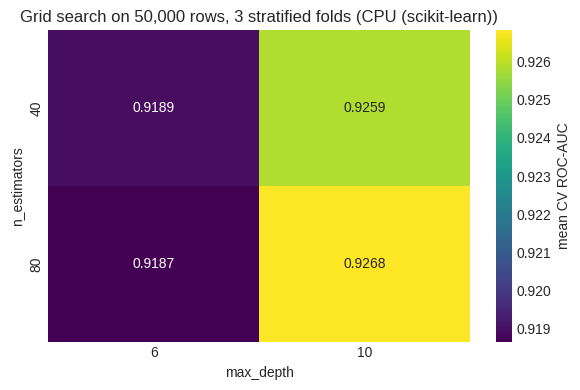

spread across the grid: 0.0082 AUC (best 0.9268, worst 0.9187) | std within a cell ~0.0017


In [67]:
# ---- the grid as a heatmap of mean CV AUC
heat = grid_tbl["mean CV AUC"].unstack("max_depth")
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(heat, annot=True, fmt=".4f", cmap="viridis", cbar_kws={"label": "mean CV ROC-AUC"}, ax=ax)
ax.set_title(f"Grid search on {N_GRID:,} rows, 3 stratified folds ({PATH})")
ax.set_xlabel("max_depth"); ax.set_ylabel("n_estimators")
plt.tight_layout(); plt.show()
best_cell, worst_cell = heat.stack().max(), heat.stack().min()
print(f"spread across the grid: {best_cell - worst_cell:.4f} AUC (best {best_cell:.4f}, worst {worst_cell:.4f}) | std within a cell ~{grid_tbl['std CV AUC'].mean():.4f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Each square is the mean ROC-AUC over three folds for one candidate. Depth matters more than the number of trees here: moving down a row (more trees) changes the fourth decimal, moving right (deeper trees) changes the third. The printed spread across the grid is small in absolute terms, and the printed fold-to-fold standard deviation is a useful yardstick: a difference between two squares that is smaller than the within-square standard deviation is noise, not a ranking. The common misread: treating the brightest square as "the answer" when the grid was too small to bracket the optimum; the best value sitting on the edge of the grid (the largest depth tried) is a sign to extend the grid, not to stop.

</div>

## 16.4 The same search on the CPU, and the budget math

The honest comparison runs scikit-learn's own `RandomForestClassifier` (with every core, `n_jobs=-1`) through the identical `GridSearchCV` on a **20 000-row** slice. The CPU number is then scaled linearly to the full table. Forest training grows slightly faster than linearly with rows, so the scaled number is a lower bound, and it is labelled as an estimate.


,rows,fits,mean fit s,search s
"CPU (scikit-learn) search, measured","50,000.00",12.00,3.06,37.54
"sklearn CPU search (2 cores), measured","20,000.00",12.00,1.28,15.89
"sklearn CPU search, scaled linearly (estimate, a lower bound)","50,000.00",12.00,3.19,39.72


search budget = candidates x folds x fit time: 4 x 3 x 3.06 s = 37 s of fitting inside the 38 s search (CPU (scikit-learn))
CPU path: both searches used scikit-learn; 50,000 rows took 38 s and 20,000 rows 16 s


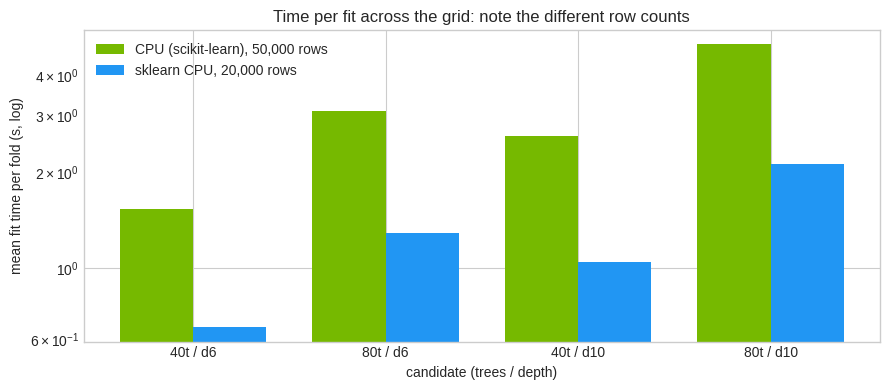

per-fit ratio at the largest candidate: CPU 2.11 s on 20,000 rows vs CPU (scikit-learn) 5.00 s on 50,000 rows


In [68]:
# ---- the CPU reference: sklearn RandomForest, all cores, same grid, 20k rows; then the budget table
from sklearn.ensemble import RandomForestClassifier as SkRF
N_CPU = 20_000
Xc, yc = X200[:N_CPU], y200[:N_CPU]
search_cpu = GridSearchCV(SkRF(random_state=RANDOM_STATE, n_jobs=-1), param_grid, cv=cv3, scoring="roc_auc", n_jobs=1, refit=False)
t0 = time.perf_counter(); search_cpu.fit(Xc, yc); t_cpu = time.perf_counter() - t0
cpu_tbl = pd.DataFrame(search_cpu.cv_results_)

n_fits = n_candidates * cv3.n_splits
scale = N_GRID / N_CPU
budget_tbl = pd.DataFrame({
    "rows": [N_GRID, N_CPU, N_GRID],
    "fits": [n_fits, n_fits, n_fits],
    "mean fit s": [grid_tbl["fit s/fold"].mean(), cpu_tbl["mean_fit_time"].mean(), cpu_tbl["mean_fit_time"].mean() * scale],
    "search s": [t_search, t_cpu, t_cpu * scale],
}, index=[f"{PATH} search, measured", f"sklearn CPU search ({os.cpu_count()} cores), measured", "sklearn CPU search, scaled linearly (estimate, a lower bound)"])
display(pretty(budget_tbl, fmt="{:,.2f}", subset=[]))
print(f"search budget = candidates x folds x fit time: {n_candidates} x {cv3.n_splits} x {grid_tbl['fit s/fold'].mean():.2f} s"
      f" = {n_fits * grid_tbl['fit s/fold'].mean():.0f} s of fitting inside the {t_search:.0f} s search ({PATH})")
if GPU:
    print(f"CPU estimate for {N_GRID:,} rows: at least {t_cpu * scale:.0f} s  vs  GPU measured {t_search:.0f} s  ->  about {t_cpu * scale / t_search:.1f}x (GPU vs the CPU lower bound)")
else:
    print(f"CPU path: both searches used scikit-learn; {N_GRID:,} rows took {t_search:.0f} s and {N_CPU:,} rows {t_cpu:.0f} s")

fig, ax = plt.subplots(figsize=(9, 4))
labels = [f"{n}t / d{d}" for n, d in grid_tbl.index]
x = np.arange(len(labels)); w = 0.38
ax.bar(x - w / 2, grid_tbl["fit s/fold"].values, w, label=f"{PATH}, {N_GRID:,} rows", color="#76b900")
ax.bar(x + w / 2, cpu_tbl["mean_fit_time"].values, w, label=f"sklearn CPU, {N_CPU:,} rows", color="#2196F3")
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_yscale("log")
ax.set_xlabel("candidate (trees / depth)"); ax.set_ylabel("mean fit time per fold (s, log)")
ax.set_title("Time per fit across the grid: note the different row counts"); ax.legend()
plt.tight_layout(); plt.show()
print(f"per-fit ratio at the largest candidate: CPU {cpu_tbl['mean_fit_time'].iloc[-1]:.2f} s on {N_CPU:,} rows vs {PATH} {grid_tbl['fit s/fold'].iloc[-1]:.2f} s on {N_GRID:,} rows")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Two bars per candidate, on a log scale, and they are **not on the same data**: the green bars fit ten times more rows than the blue ones. Read them together with the printed line. When the green bar is at or below the blue one, the GPU fitted ten times the data in the same time or less. Deeper and larger forests move both bars up, but the CPU bar climbs faster with depth, because CPU tree building touches memory one split at a time while the GPU builds all the histograms of a level at once. The common misread: comparing bar heights as if they were the same job; the fair number is the scaled estimate in the table, and it is a lower bound for the CPU.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: compute the budget before you launch the search

Time **one** fit at the largest candidate (the deepest, biggest forest), multiply by folds and candidates, and decide whether the search is affordable *before* running it. When the grid grows past about twenty candidates, switch to `RandomizedSearchCV`, which samples candidates from distributions and lets you fix the budget with `n_iter`:

```python
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
rs = RandomizedSearchCV(RandomForestClassifier(random_state=RANDOM_STATE),
                        {"n_estimators": randint(40, 200), "max_depth": randint(4, 16), "max_features": [0.3, 0.5, 1.0]},
                        n_iter=12, cv=cv3, scoring="roc_auc", n_jobs=1, random_state=RANDOM_STATE)
rs.fit(X200, y200)      # exactly 12 x 3 fits, whatever the size of the space
```

Two more habits: keep `n_jobs=1` in the search when the estimator is on a single GPU, and keep the warm-up fit outside the timing.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Same API, different defaults

`GridSearchCV` compares candidates of *one* implementation, so it will not warn you that cuML's forest and scikit-learn's forest differ in their defaults (`n_bins=128` histogram splits, `max_features='sqrt'`, `float32` inputs). Part 4 listed those differences. When you move a search from CPU to GPU, expect the best AUC to shift in the third decimal and the best depth to move by a step; that is the implementation, not the data.

</div>

## 16.5 Task 16 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- scikit-learn's `cross_val_score` and `GridSearchCV` drive cuML estimators unchanged, because cuML implements `get_params`, `clone`, `fit` and `predict_proba`.
- Hand **host NumPy** arrays to the outer loop; device arrays make scikit-learn's indexing raise `TypeError` before any work starts.
- A search costs candidates x folds x fit time. Only the last factor is hardware; measure it once at the largest candidate and do the multiplication first.
- Compare implementations on the same rows, or label a scaled number as an estimate.
- Keep `n_jobs=1` in the search when the estimator owns the GPU.

### 🔑 New variables

| Variable | Meaning |
|---|---|
| `xdf`, `to_host`, `gpu_mem_mib` | this stage's GPU/CPU switch, host-copy helper and `nvidia-smi` reader |
| `hh200`, `NUM_FEATURES`, `X200`, `y200` | the 200 000-household table and its float32 feature matrix (host) |
| `cv3` | `StratifiedKFold(3)` used by every search in this part |
| `search`, `grid_tbl` | the cuML grid search and its results table |
| `search_cpu`, `budget_tbl` | the scikit-learn reference search and the budget table |

### ➡️ Next Up

Task 17 removes even the import change: `cuml.accel` makes unmodified scikit-learn code run on the GPU, and shows how to find out which calls it really accelerated.

</div>


# Task 17 · `cuml.accel`: Zero-Code-Change Acceleration, and How to Check It

## 17.1 Three ways to switch it on

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: a proxy in front of scikit-learn

`cuml.accel` installs an **import hook**: when your code imports `sklearn.ensemble.RandomForestClassifier`, it receives a proxy object that forwards `fit` and `predict` to cuML when the parameters are supported, and to the original scikit-learn class when they are not. Your script does not change; the module it imports does. This is the cuML twin of `cudf.pandas` from Part 2.

| Where | How | When it must happen |
|---|---|---|
| Jupyter / Colab | `%load_ext cuml.accel` at the top of the notebook | before the first `import sklearn` |
| a script | `python -m cuml.accel my_script.py` | wraps the whole run |
| inside code | `import cuml.accel; cuml.accel.install()` | before `import sklearn` |

The "before" column is the catch for this notebook: scikit-learn was imported in Part 0, and a proxy cannot replace classes that are already bound to names. So the demonstration below runs in a **subprocess** started with `sys.executable` (the same interpreter, so it works on Colab too): one run plain, one run with `cuml.accel.install()` as its first line. Both runs execute the same benchmark script on a 40 000-row Parquet sample of the household table, and both are timed **inside** the script after a warm-up fit, so the interpreter start-up and the library imports are kept out of the per-model numbers.

</div>


In [69]:
# ---- cuml.accel in a subprocess: the same sklearn script, plain and accelerated
ACCEL_DIR = tempfile.mkdtemp(prefix="rapids_accel_")
sample_pq = os.path.join(ACCEL_DIR, "hh_sample.parquet")
hh200[NUM_FEATURES + [LABEL_CLS]].sample(40_000, random_state=RANDOM_STATE).fillna(0).astype("float32").to_parquet(sample_pq, index=False)

BENCH = textwrap.dedent("""
    import sys, time, json
    ACCEL = "--accel" in sys.argv
    if ACCEL:
        import cuml.accel
        cuml.accel.install()                       # entry point 3: install BEFORE importing sklearn
    import pandas as pd
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.cluster import KMeans
    from sklearn.decomposition import PCA
    from sklearn.linear_model import LogisticRegression
    from sklearn.neighbors import NearestNeighbors
    df = pd.read_parquet(sys.argv[1]); y = df.pop("overspent_next").values.astype(int); X = df.values
    models = [("RandomForestClassifier", RandomForestClassifier(n_estimators=60, max_depth=8, random_state=42, n_jobs=-1)),
              ("KMeans", KMeans(n_clusters=6, n_init=1, random_state=42)),
              ("PCA", PCA(n_components=4)),
              ("LogisticRegression", LogisticRegression(max_iter=300)),
              ("NearestNeighbors", NearestNeighbors(n_neighbors=10))]
    KMeans(n_clusters=2, n_init=1, random_state=42).fit(X[:2000])     # warm-up: CUDA context + JIT once, outside the timings
    out = {}
    for name, est in models:
        t0 = time.perf_counter()
        est.fit(X, y) if name in ("RandomForestClassifier", "LogisticRegression") else est.fit(X)
        out[name] = {"seconds": time.perf_counter() - t0, "gpu_proxy": bool(cuml.accel.is_proxy(est)) if ACCEL else False}
    print("RESULT " + json.dumps(out))
""")
bench_py = os.path.join(ACCEL_DIR, "bench.py")
with open(bench_py, "w") as f:
    f.write(BENCH)

def run_bench(accel: bool):
    # run bench.py in a fresh interpreter; return (per-model results, wall seconds of the whole process)
    cmd = [sys.executable, bench_py, sample_pq] + (["--accel"] if accel else [])
    t0 = time.perf_counter()
    r = subprocess.run(cmd, capture_output=True, text=True)
    wall = time.perf_counter() - t0
    lines = [l for l in r.stdout.splitlines() if l.startswith("RESULT ")]
    if not lines:
        raise RuntimeError(f"bench.py failed:\n{r.stderr[-1200:]}")
    return json.loads(lines[0][len("RESULT "):]), wall

plain, wall_plain = run_bench(accel=False)
print(f"plain sklearn subprocess: {wall_plain:.1f} s wall, of which {sum(v['seconds'] for v in plain.values()):.1f} s model fitting")
if GPU:
    accel, wall_accel = run_bench(accel=True)
    print(f"cuml.accel subprocess:    {wall_accel:.1f} s wall, of which {sum(v['seconds'] for v in accel.values()):.1f} s model fitting"
          f" (the rest is importing cuML and creating the CUDA context)")
else:
    accel, wall_accel = None, None
    print("CPU path: no GPU, so the accelerated run is skipped; the table below shows the plain timings only")


plain sklearn subprocess: 9.6 s wall, of which 4.9 s model fitting
CPU path: no GPU, so the accelerated run is skipped; the table below shows the plain timings only


The wall-clock lines are the first honest number: an accelerated process pays once for importing cuML and creating a CUDA context, several seconds that no per-model speed-up can hide in a script that runs for ten. The per-model numbers are what `cuml.accel` is for.


,sklearn s,cuml.accel s,speed-up
model,,,
RandomForestClassifier,3.824,-,-
KMeans,0.059,-,-
PCA,0.054,-,-
LogisticRegression,0.990,-,-
NearestNeighbors,0.002,-,-


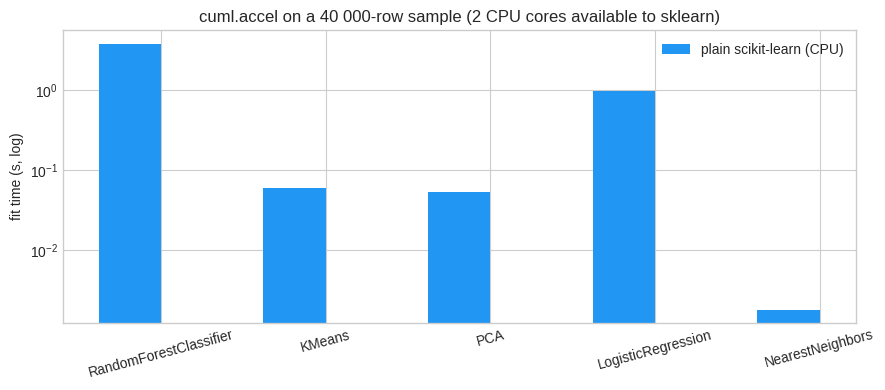

CPU path: speed-ups need a GPU; the plain timings above are the reference to beat


In [70]:
# ---- per-model timings, plain vs accelerated, and which calls were GPU proxies
rows = []
for name, v in plain.items():
    a = accel[name] if accel else None
    rows.append({"model": name, "sklearn s": v["seconds"],
                 "cuml.accel s": a["seconds"] if a else np.nan,
                 "speed-up": (v["seconds"] / a["seconds"]) if a else np.nan})
accel_tbl = pd.DataFrame(rows).set_index("model")
display(pretty(accel_tbl, fmt="{:.3f}", subset=["speed-up"]))
if accel:
    print("GPU proxies (is_proxy=True) in the accelerated run:", ", ".join(n for n, a in accel.items() if a["gpu_proxy"]) or "none")

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(accel_tbl)); w = 0.38
ax.bar(x - w / 2, accel_tbl["sklearn s"], w, label="plain scikit-learn (CPU)", color="#2196F3")
if accel:
    ax.bar(x + w / 2, accel_tbl["cuml.accel s"], w, label="same script under cuml.accel (GPU)", color="#76b900")
ax.set_xticks(x); ax.set_xticklabels(accel_tbl.index, rotation=15); ax.set_yscale("log")
ax.set_ylabel("fit time (s, log)"); ax.set_title(f"cuml.accel on a 40 000-row sample ({os.cpu_count()} CPU cores available to sklearn)")
ax.legend(); plt.tight_layout(); plt.show()
if accel:
    best = accel_tbl["speed-up"].idxmax(); worst = accel_tbl["speed-up"].idxmin()
    print(f"largest speed-up: {best} {accel_tbl.loc[best, 'speed-up']:.1f}x | smallest: {worst} {accel_tbl.loc[worst, 'speed-up']:.2f}x"
          f" ({'slower' if accel_tbl.loc[worst, 'speed-up'] < 1 else 'faster'} on the GPU at this size)")
else:
    print("CPU path: speed-ups need a GPU; the plain timings above are the reference to beat")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Same script, same data, two bars per model on a log scale. The speed-up is **not one number**: it depends on the algorithm and on the data size. Iterative, arithmetic-heavy fits (k-means, logistic regression) gain the most; a tiny fit such as a 4-component PCA on 40 000 rows can come out *slower* on the GPU, because its whole CPU cost is below the fixed cost of launching kernels and copying the data. The random forest depends on how many CPU cores scikit-learn had: the title says how many were available here, and on a two-core Colab CPU the blue forest bar would be far taller. The common misread: quoting one speed-up for "the GPU"; always quote it with the algorithm, the row count, and the CPU it was measured against.

</div>

## 17.3 Trust, but verify: `is_proxy`, `profile`, and the fallback log

`cuml.accel` falls back to scikit-learn **silently by default** when a class or a parameter has no GPU implementation. Three tools make it visible:

- `cuml.accel.is_proxy(obj)` answers "is this estimator (or class) a GPU proxy at all?"
- `cuml.accel.install(log_level="info")` prints one line per call: `ran on GPU` or `falling back to CPU: <reason>`.
- `with cuml.accel.profile():` prints a table of GPU calls, CPU calls and their time, and the reasons for every fallback.

The subprocess below uses all three. It fits a supported forest with an **unsupported parameter** (`criterion="log_loss"`), and a model that has no GPU version at all (`GradientBoostingClassifier`).


In [71]:
# ---- profiling and fallbacks in a subprocess: is_proxy, the info log, and cuml.accel.profile()
PROFILE = textwrap.dedent("""
    import sys
    import cuml.accel
    cuml.accel.install(log_level="info")           # one log line per call: ran on GPU / falling back to CPU
    import pandas as pd
    from sklearn.cluster import KMeans
    from sklearn.decomposition import PCA
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
    df = pd.read_parquet(sys.argv[1]).iloc[:10_000]; y = df.pop("overspent_next").values.astype(int); X = df.values
    print("is_proxy(RandomForestClassifier):    ", cuml.accel.is_proxy(RandomForestClassifier))
    print("is_proxy(GradientBoostingClassifier):", cuml.accel.is_proxy(GradientBoostingClassifier))
    with cuml.accel.profile():
        KMeans(n_clusters=6, n_init=1, random_state=42).fit(X)
        PCA(n_components=4).fit(X)
        RandomForestClassifier(n_estimators=20, max_depth=6, criterion="log_loss", random_state=42).fit(X, y)   # unsupported parameter
        GradientBoostingClassifier(n_estimators=20, max_depth=3).fit(X, y)                                       # no GPU version at all
""")
profile_py = os.path.join(ACCEL_DIR, "profile.py")
with open(profile_py, "w") as f:
    f.write(PROFILE)

if GPU:
    r = subprocess.run([sys.executable, profile_py, sample_pq], capture_output=True, text=True)
    print(r.stdout if r.returncode == 0 else r.stderr[-1500:])
else:
    print("CPU path: cuml.accel is not installed here. On a GPU runtime this cell prints:")
    print("  [cuml.accel] `KMeans.fit` ran on GPU / `RandomForestClassifier.fit` falling back to CPU: `criterion='log_loss'` is not supported")
    print("  and a table with GPU calls, CPU calls and their times; GradientBoostingClassifier is not a proxy and never appears in it.")


CPU path: cuml.accel is not installed here. On a GPU runtime this cell prints:
  [cuml.accel] `KMeans.fit` ran on GPU / `RandomForestClassifier.fit` falling back to CPU: `criterion='log_loss'` is not supported
  and a table with GPU calls, CPU calls and their times; GradientBoostingClassifier is not a proxy and never appears in it.


The table has one row per **proxied** method and two columns of counts. The forest appears with one CPU call and a stated reason; the gradient-boosting model does **not appear at all**, because `is_proxy` is false for it: it is plain scikit-learn from start to finish, and no log line is written for it. That is the difference between a *fallback* (a proxy that decided to run on the CPU) and *no acceleration* (never a proxy). Only the first kind is logged.

The coverage list is worth reading from the installed version rather than from memory, so the next cell asks `cuml.accel` which modules it overrides and which estimator classes each override defines.


In [72]:
# ---- what cuml.accel covers in this installed version, read from the package itself
if GPU:
    import importlib, cuml
    from cuml.accel import core as accel_core
    overridden = sorted(getattr(accel_core, "_OVERRIDES", [m for m in accel_core.ACCELERATED_MODULES if m.count(".") == 1]))
    cover = []
    for mod in overridden:
        try:
            m = importlib.import_module(f"cuml.accel._overrides.{mod}")
            classes = [n for n in dir(m) if n[:1].isupper() and n not in ("UnsupportedOnGPU", "ArrayAPIProxyBase", "SKLEARN_16", "SKLEARN_18", "Version")]
            cover.append((mod, ", ".join(classes)))
        except ImportError:
            cover.append((mod, "(that library is not installed here)"))
    coverage_tbl = pd.DataFrame(cover, columns=["module", "proxied classes"]).set_index("module")
    print(f"cuml.accel {cuml.__version__}: {len(overridden)} overridden modules; patched for compatibility: "
          + ", ".join(m for m in accel_core.ACCELERATED_MODULES if m not in overridden))
    print(coverage_tbl.to_string())
else:
    print("CPU path: cuml is not installed, so the coverage list cannot be read from the package here.")
    print("In RAPIDS 26.08 the overridden modules are: hdbscan, sklearn.cluster, .covariance, .decomposition, .ensemble, .kernel_ridge,")
    print(".linear_model, .manifold, .neighbors, .preprocessing, .svm, umap  (sklearn.pipeline/.compose/.utils are patched, not overridden).")


CPU path: cuml is not installed, so the coverage list cannot be read from the package here.
In RAPIDS 26.08 the overridden modules are: hdbscan, sklearn.cluster, .covariance, .decomposition, .ensemble, .kernel_ridge,
.linear_model, .manifold, .neighbors, .preprocessing, .svm, umap  (sklearn.pipeline/.compose/.utils are patched, not overridden).


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🔬 What `cuml.accel` 26.08 covers, and what it does not

| Family | Accelerated (proxied) | Never proxied: plain scikit-learn |
|---|---|---|
| Ensembles | `RandomForestClassifier`, `RandomForestRegressor` | `GradientBoosting*`, `HistGradientBoosting*`, `ExtraTrees*`, `AdaBoost*` (use XGBoost on the GPU instead, Part 9) |
| Linear | `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`, `LogisticRegression`, `KernelRidge` | `SGD*`, `BayesianRidge`, `Huber*` |
| Clustering | `KMeans`, `DBSCAN`, `SpectralClustering`, `hdbscan.HDBSCAN` | `AgglomerativeClustering`, `MeanShift`, `OPTICS` |
| Decomposition & manifold | `PCA`, `IncrementalPCA`, `TruncatedSVD`, `TSNE`, `SpectralEmbedding`, `umap.UMAP` | `NMF`, `FastICA`, `Isomap` |
| Neighbours & SVM | `NearestNeighbors`, `KNeighbors*`, `KernelDensity`, `SVC`, `SVR`, `LinearSVC`, `LinearSVR` | `NuSVC`, `RadiusNeighbors*` |
| Preprocessing | `StandardScaler`, `MinMaxScaler`, `MaxAbsScaler`, `PolynomialFeatures`, `LabelEncoder`, `LabelBinarizer`, `TargetEncoder` | `OneHotEncoder`, `ColumnTransformer` (patched to pass GPU data through, not accelerated) |
| Trees & Bayes & text | none | `DecisionTree*`, `naive_bayes.*`, `feature_extraction.text.*` |

Within a proxied class, **unsupported parameter values** still fall back: the forest's `criterion="log_loss"` above, `LogisticRegression` with some solver choices, sparse inputs for several models. The exact list moves every release; `profile()` on your own script is the only list that is guaranteed current.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Silent means silent

Without `log_level` or `profile()`, a script that falls back to the CPU for every call prints nothing different and simply runs at CPU speed. The symptom is a "GPU" job whose `nvidia-smi` utilisation stays at zero. Wrap the training section in `with cuml.accel.profile():` the first time you run under the accelerator, read the CPU-calls column, and fix the parameters or the class before believing any timing.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: which mode, when

- **Exploring someone else's scikit-learn code** or a library you cannot modify (a pipeline, an AutoML tool): `cuml.accel`, with `profile()` on the first run.
- **Writing your own code**: import cuML directly, as Parts 4 to 6 did. You get every parameter, no proxy surprises, and control over host copies.
- **Notebooks**: `%load_ext cuml.accel` (and `%load_ext cudf.pandas`) in the very first cell, before any import; if you forget, restart the runtime rather than trying to install it later.
- In every mode, keep the warm-up fit outside the timing and report the CPU core count next to any speed-up.

</div>

## 17.4 Task 17 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- `cuml.accel` proxies scikit-learn classes at import time: `%load_ext cuml.accel`, `python -m cuml.accel script.py`, or `cuml.accel.install()` **before** `import sklearn`.
- The per-model speed-up ranges from below 1x (tiny PCA) to several x (k-means, logistic regression) on the same 40 000 rows; the process also pays several seconds once for cuML's import and the CUDA context.
- `is_proxy` tells you whether a class is accelerated at all; `install(log_level="info")` and `profile()` tell you which calls fell back and why.
- A non-proxied class never appears in the profile table; a proxied class with an unsupported parameter appears as a CPU call with a reason.

### 🔑 New variables

| Variable | Meaning |
|---|---|
| `ACCEL_DIR`, `sample_pq`, `bench_py`, `profile_py` | temp dir with the 40 000-row Parquet sample and the two subprocess scripts |
| `run_bench` | runs `bench.py` plain or with `--accel` and parses its `RESULT` line |
| `plain`, `accel`, `accel_tbl` | per-model timings and the comparison table |
| `coverage_tbl` | the overridden modules and proxied classes, read from the installed `cuml.accel` |

### ➡️ Next Up

Part 8 leaves model selection and asks the question every GPU user meets on day two: what happens when the data does not fit?

</div>


# Part 8 · Scaling Up: Millions of Rows, Memory Management, Dask-cuDF ⭐⭐⭐

<div style="background: linear-gradient(135deg, #fc466b 0%, #3f5efb 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Big Picture

A GPU has less memory than the machine it sits in, and by default it cannot borrow the host's RAM. A Colab T4 gives you 15 GB; the notebook VM has about the same, and a laptop's disk is a hundred times bigger than either. So the first skill of GPU data work is **arithmetic**: bytes per row times rows, compared with what the card has free. The second is a set of habits that stretch the card: smaller dtypes, an allocator pool, spilling to host memory, chunked processing, and, when one card is not enough, Dask-cuDF across several. Task 18 measures the memory and provokes the out-of-memory error on purpose; Task 19 processes a table in chunks and hands the same job to Dask.

</div>


# Task 18 · Memory: Bytes per Row, Pools, Spilling, and the OOM

## 18.1 How much does a frame weigh?

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The math (gently)

A columnar frame weighs the sum of its columns, and a column weighs `rows x bytes per value` plus a small bitmask for missing values:

$$ \text{bytes} \approx \sum_{\text{columns}} n_{\text{rows}} \times \text{width}_c \quad (\text{float64: } 8,\ \text{float32: } 4,\ \text{int32: } 4,\ \text{bool: } 1) $$

String columns are the exception: cuDF stores them as one contiguous character buffer plus an offsets array, so their width is the **average string length plus 4 bytes** per row. Converting a low-cardinality string column to `category` replaces every string with a small integer code and stores the distinct strings once.

The cell below builds a large budget table on the host with the generator from Part 0, copies it to the device, and weighs it three ways: `memory_usage(deep=True)` on the frame, and `nvidia-smi` before and after the copy. The size adapts to the memory the GPU has free right now (other processes may be using it), and the printed line says what was built.

</div>


In [73]:
# ---- build a multi-million-row frame sized to the memory that is free right now, and weigh it
used0, free0 = gpu_mem_mib()
if not GPU:
    N_HH = 250_000                              # CPU path: 3 M rows is plenty for a pandas machine
elif free0 >= 4096:
    N_HH = 500_000                              # 6 M rows
elif free0 >= 1536:
    N_HH = 250_000                              # 3 M rows: the GPU is shared or small
else:
    N_HH = 100_000                              # 1.2 M rows: very little memory left
MONTHS = 12
print(f"GPU memory before: {used0:,} MiB used, {free0:,} MiB free -> building {N_HH:,} households x {MONTHS} months = {N_HH * MONTHS:,} rows")

with timer("make_budget on the host (pandas)"):
    budget_big = make_budget(n_households=N_HH, months=MONTHS, seed=RANDOM_STATE)
N_ROWS = len(budget_big)
host_bytes = int(budget_big.memory_usage(deep=True).sum())
print(f"host frame: {host_bytes / 1e6:,.0f} MB = {host_bytes / N_ROWS:.0f} bytes/row over {budget_big.shape[1]} columns")

with timer("host -> device copy (cudf.from_pandas)" if GPU else "CPU path: no copy, the frame stays in pandas"):
    gbig = cudf.from_pandas(budget_big) if GPU else budget_big
dev_bytes = int(gbig.memory_usage(deep=True).sum())
used1, free1 = gpu_mem_mib()
where = "device" if GPU else "host"
print(f"{where} frame: {dev_bytes / 1e6:,.0f} MB = {dev_bytes / N_ROWS:.0f} bytes/row"
      + (f" | nvidia-smi used: {used0:,} -> {used1:,} MiB (+{used1 - used0:,} MiB)" if GPU else ""))
col_mb = to_host(gbig.memory_usage(deep=True)).drop("Index", errors="ignore").sort_values(ascending=False) / 1e6
print("heaviest columns (MB):", ", ".join(f"{c} {v:.0f}" for c, v in col_mb.head(5).items()))


GPU memory before: 0 MiB used, 0 MiB free -> building 250,000 households x 12 months = 3,000,000 rows


⏱️ make_budget on the host (pandas): 2.64 s


host frame: 870 MB = 290 bytes/row over 18 columns
⏱️ CPU path: no copy, the frame stays in pandas: 0.00 s


host frame: 870 MB = 290 bytes/row


heaviest columns (MB): note 226, city_tier 160, referral_code 145, household_id 24, month 24


The `nvidia-smi` delta is larger than the frame when the CUDA context is created in the same step (a fixed cost of a few hundred MiB) and smaller when the allocator reuses freed blocks; the frame's own `memory_usage` is the number to plan with. The heaviest columns are the ones with the widest dtype, and the generator hands us the pandas defaults: `float64` for every amount, `int64` for small integers, and strings for the note. None of those widths is needed.

## 18.2 The first fix: dtypes

`float32` keeps about seven significant digits, which is more than any spend amount has; `int32` counts to two billion; `category` turns the eight distinct notes and three city tiers into one-byte codes. Part 4 already wanted `float32` for cuML. The next cell applies the three conversions and weighs the result.


In [74]:
# ---- shrink dtypes: float64 -> float32, int64 -> int32, low-cardinality strings -> category
def shrink(df):
    # a copy with narrower numeric dtypes and categorical strings; works for pandas and cuDF frames
    out = df.copy()
    for c in out.columns:
        dt = str(out[c].dtype)
        if dt == "float64":
            out[c] = out[c].astype("float32")
        elif dt == "int64":
            out[c] = out[c].astype("int32")
        elif dt in ("str", "object", "string"):
            out[c] = out[c].astype("category")
    return out

with timer("shrink dtypes"):
    gsmall = shrink(gbig)
small_bytes = int(gsmall.memory_usage(deep=True).sum())
dtype_tbl = pd.DataFrame({
    "dtype before": to_host(gbig.dtypes).astype(str),
    "dtype after": to_host(gsmall.dtypes).astype(str),
    "MB before": to_host(gbig.memory_usage(deep=True)).drop("Index", errors="ignore") / 1e6,
    "MB after": to_host(gsmall.memory_usage(deep=True)).drop("Index", errors="ignore") / 1e6,
})
dtype_tbl["saved %"] = 100 * (1 - dtype_tbl["MB after"] / dtype_tbl["MB before"])
print(dtype_tbl.sort_values("MB before", ascending=False).round(1).to_string())
print(f"whole frame: {dev_bytes / 1e6:,.0f} MB -> {small_bytes / 1e6:,.0f} MB ({dev_bytes / small_bytes:.2f}x smaller, {small_bytes / N_ROWS:.0f} bytes/row)")
del gsmall; gc.collect()


⏱️ shrink dtypes: 2.07 s


                 dtype before    dtype after  MB before  MB after  saved %
note                   object       category      225.9       3.0     98.7
city_tier              object       category      160.0       3.0     98.1
referral_code          object       category      144.9       3.0     97.9
household_id            int64          int32       24.0      12.0     50.0
month           datetime64[s]  datetime64[s]       24.0      24.0      0.0
household_size          int64          int32       24.0      12.0     50.0
utilities             float64        float32       24.0      12.0     50.0
groceries             float64        float32       24.0      12.0     50.0
income                float64        float32       24.0      12.0     50.0
rent                  float64        float32       24.0      12.0     50.0
other                 float64        float32       24.0      12.0     50.0
transport             float64        float32       24.0      12.0     50.0
entertainment         flo

18946

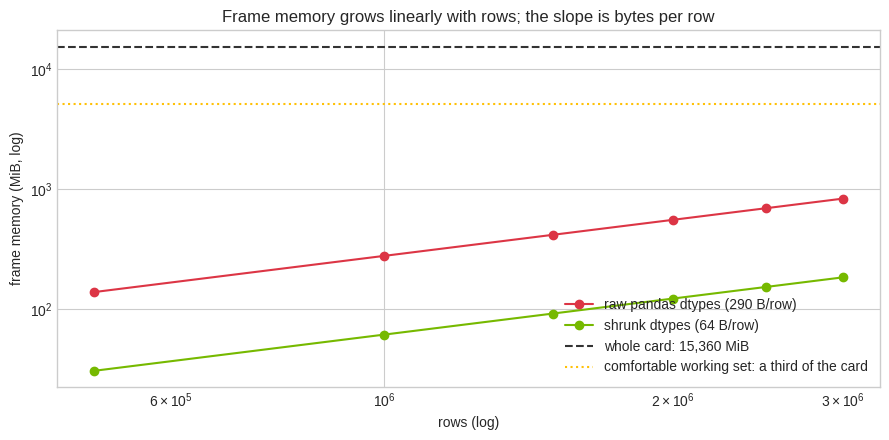

a third of a 15,360 MiB card holds about 19 M rows at raw dtypes and 84 M rows shrunk (this table's columns)


In [75]:
# ---- memory used vs rows, raw dtypes and shrunk dtypes, against the card
fracs = [1 / 6, 2 / 6, 3 / 6, 4 / 6, 5 / 6, 1.0]
rows_at, raw_mb, small_mb = [], [], []
for fr in fracs:
    n = int(N_ROWS * fr)
    part = gbig.iloc[:n]
    rows_at.append(n)
    raw_mb.append(int(part.memory_usage(deep=True).sum()) / 2**20)
    small_mb.append(int(shrink(part).memory_usage(deep=True).sum()) / 2**20)
    del part
gc.collect()
card_mib = GPU_MEM if GPU else 15_360           # this card, or a 15 GiB T4 as the reference on the CPU path

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(rows_at, raw_mb, marker="o", color="#dc3545", label=f"raw pandas dtypes ({dev_bytes / N_ROWS:.0f} B/row)")
ax.plot(rows_at, small_mb, marker="o", color="#76b900", label=f"shrunk dtypes ({small_bytes / N_ROWS:.0f} B/row)")
ax.axhline(card_mib, color="#333", ls="--", label=f"whole card: {card_mib:,} MiB")
ax.axhline(card_mib / 3, color="#ffc107", ls=":", label="comfortable working set: a third of the card")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("rows (log)"); ax.set_ylabel("frame memory (MiB, log)")
ax.set_title("Frame memory grows linearly with rows; the slope is bytes per row")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()
rows_fit_raw = int(card_mib * 2**20 / 3 / (dev_bytes / N_ROWS)); rows_fit_small = int(card_mib * 2**20 / 3 / (small_bytes / N_ROWS))
print(f"a third of a {card_mib:,} MiB card holds about {rows_fit_raw / 1e6:.0f} M rows at raw dtypes and {rows_fit_small / 1e6:.0f} M rows shrunk (this table's columns)")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Both lines are straight on log-log axes with slope one: memory is proportional to rows, and the gap between the lines is the dtype saving, constant at every size. The dashed line is the whole card and the dotted line is a third of it, which is the honest planning limit: a groupby, a join or a sort needs scratch space of one to two extra copies of the columns it touches, so a frame that fills the card cannot be processed. The printed line converts the limit into rows for this table. The common misread: planning against the dashed line. A frame that "fits" at 90% of the card will fail on the first `merge`.

</div>

## 18.3 The second fix: an allocator pool

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: `cudaMalloc` is slow, so ask once

Every column, every intermediate result and every slice is a device allocation. The CUDA driver call that provides it (`cudaMalloc`) synchronises the device and costs on the order of a millisecond; a groupby that creates a few hundred temporaries spends more time asking for memory than using it. **RMM** (the RAPIDS Memory Manager) can reserve one large block once, a **pool**, and then hand out pieces of it at sub-microsecond cost. `rmm.reinitialize(pool_allocator=True, initial_pool_size=...)` switches it on; the pool grows on demand and gives memory back to the driver only when it is torn down. The cell times two hundred allocate-and-free rounds both ways.

</div>


In [76]:
# ---- the RMM pool: time 200 allocate+free rounds with the default allocator, then with a pool
def alloc_burst(k=200, mb=8):
    # k rounds of "allocate an mb-MB array, drop it"; returns seconds
    t0 = time.perf_counter()
    for _ in range(k):
        if GPU:
            a = cp.empty(mb * 2**20 // 4, dtype=cp.float32)
        else:
            a = np.empty(mb * 2**20 // 4, dtype=np.float32); a[0] = 1.0   # touch it so the OS really hands over the page
        del a
    if GPU:
        cp.cuda.Device().synchronize()
    return time.perf_counter() - t0

if GPU:
    print("allocator before:", type(rmm.mr.get_current_device_resource()).__name__)
    t_plain = alloc_burst()
    try:
        rmm.reinitialize(pool_allocator=True, initial_pool_size="256MiB")     # small initial pool; it grows as needed
        print("allocator after: ", type(rmm.mr.get_current_device_resource()).__name__)
        t_pool = alloc_burst()
        POOL_ON = True
        print(f"200 x 8 MB allocate+free: {t_plain * 1000:.0f} ms with cudaMalloc  vs  {t_pool * 1000:.1f} ms with the RMM pool  ({t_plain / t_pool:.0f}x)")
    except Exception as e:  # noqa: BLE001 - the GPU is nearly full and cannot reserve the pool
        POOL_ON = False
        print("the pool could not be reserved:", str(e)[:100])
else:
    POOL_ON = False
    t_plain = alloc_burst()
    print(f"CPU path: 200 x 8 MB numpy allocate+free took {t_plain * 1000:.0f} ms; the host allocator already pools, and RMM is not used")


CPU path: 200 x 8 MB numpy allocate+free took 0 ms; the host allocator already pools, and RMM is not used


A hundredfold difference on a micro-benchmark does not become a hundredfold on real work, because real kernels also compute. It does show up: cuDF groupbys and joins on small-to-medium frames are visibly faster with a pool, which is why every RAPIDS deployment guide sets one up first. Two cautions: a pool holds what it has grown to (other processes on the same GPU cannot get it back until you `rmm.reinitialize(pool_allocator=False)` or the process ends), and the pool must be created **before** the frames that will live in it. This notebook switches the pool off again at the end of Task 19, so that later Parts measure with the default allocator.

## 18.4 The third fix: spilling to host memory

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: a swap file for the GPU

cuDF can watch its own device buffers and, when they exceed a limit, move the least recently used ones to host RAM, bringing them back when a computation touches them. That is **spilling**: `cudf.set_option("spill", True)` in code, or the environment variables `CUDF_SPILL=1` and `CUDF_SPILL_DEVICE_LIMIT=<bytes>` before the process starts. It costs a host-device copy every time a spilled column is needed, so it is the fix for "the data fits, the working set does not", not for "the data is ten times the card". Spilling must be enabled before the buffers it should manage are created, so the demonstration runs in a subprocess with a deliberately tiny device limit of 64 MiB and six frames of 32 MB each; the spill manager's own statistics report what moved.

</div>


In [77]:
# ---- spilling, demonstrated in a subprocess with a 64 MiB device limit and 6 x 32 MB of columns
SPILL = textwrap.dedent("""
    import time, cudf, cupy as cp
    from cudf.core.buffer.spill_manager import get_global_manager
    print("spill enabled:", cudf.get_option("spill"), "| device limit:", cudf.get_option("spill_device_limit") // 2**20, "MiB")
    frames = [cudf.DataFrame({"x": cp.random.rand(2_000_000), "y": cp.random.rand(2_000_000)}) for _ in range(6)]   # 6 x 32 MB
    t0 = time.perf_counter(); total = sum(float(f.x.sum()) for f in frames); dt = time.perf_counter() - t0
    m = get_global_manager()
    on_host = sum(b.size for b in m.buffers() if b.is_spilled)
    print(f"after summing every frame: {on_host / 2**20:.0f} MiB of columns currently live on the host; the sums were correct ({dt * 1000:.0f} ms)")
    print(m.statistics)
""")
spill_py = os.path.join(ACCEL_DIR, "spill.py")
with open(spill_py, "w") as f:
    f.write(SPILL)

if GPU:
    env = dict(os.environ, CUDF_SPILL="1", CUDF_SPILL_DEVICE_LIMIT=str(64 * 2**20), CUDF_SPILL_STATS="1")
    r = subprocess.run([sys.executable, spill_py], capture_output=True, text=True, env=env)
    print(r.stdout if r.returncode == 0 else r.stderr[-1500:])
else:
    print("CPU path: pandas frames already live in host RAM, so there is nothing to spill. On a GPU runtime this cell prints the")
    print("spill manager's statistics: how many MiB moved gpu => cpu and back, and how long the copies took.")
print("in-process equivalent, before creating any frame:  cudf.set_option('spill', True); cudf.set_option('spill_device_limit', <bytes>)")


CPU path: pandas frames already live in host RAM, so there is nothing to spill. On a GPU runtime this cell prints the
spill manager's statistics: how many MiB moved gpu => cpu and back, and how long the copies took.
in-process equivalent, before creating any frame:  cudf.set_option('spill', True); cudf.set_option('spill_device_limit', <bytes>)


The statistics show both directions: columns evicted to the host as the six frames exceeded the limit, and columns brought back when `sum` touched them. The work completed with a device limit a third of the data, at the cost of those copies. A related option, **managed memory** (`rmm.reinitialize(managed_memory=True)`, also called unified memory), lets the driver page memory between host and device transparently; it is what `cuml.accel` enables by default on Linux, and it is not available under WSL2, which is why `install()` has a `disable_uvm` flag.

## 18.5 The error itself, on purpose

Every GPU user meets `MemoryError: std::bad_alloc: out_of_memory` eventually. It is better to meet it here, from a request the card cannot possibly satisfy, than in the middle of a long job. The cell asks for one and a half times the whole card and catches the exception; on the CPU path it asks NumPy for an equally impossible amount, and gets the same exception type.


In [78]:
# ---- the OOM, provoked at a safe size and caught
too_big_bytes = int(card_mib * 2**20 * 1.5) if GPU else 2**43          # 1.5 x the card, or 8 TiB of host RAM
try:
    if GPU:
        ghost = cp.empty(too_big_bytes // 4, dtype=cp.float32)
    else:
        ghost = np.empty(too_big_bytes // 4, dtype=np.float32)
    print("unexpectedly allocated; freeing it"); del ghost
except MemoryError as e:
    print(f"MemoryError caught after asking for {too_big_bytes / 2**30:,.1f} GiB:")
    print("   ", str(e).splitlines()[0][:120], "...")

fixes = pd.DataFrame({
    "fix": ["narrower dtypes (18.2)", "chunked processing (Task 19)", "spilling to host (18.4)", "a bigger or second card (Task 19)"],
    "what it buys": [f"{dev_bytes / small_bytes:.2f}x smaller frame, measured on this table",
                     "peak memory = one chunk, not the whole table",
                     "working set may exceed the card; every spilled column costs a copy",
                     "Dask-cuDF partitions across GPUs; same cuDF code per partition"],
    "cost": ["7 significant digits instead of 16", "a combine step, and no cross-chunk joins", "host-device copies", "hardware, and a scheduler"],
}).set_index("fix")
print(fixes.to_string())


MemoryError caught after asking for 8,192.0 GiB:
    Unable to allocate 8.00 TiB for an array with shape (2199023255552,) and data type float32 ...
                                                                                         what it buys                                      cost
fix                                                                                                                                            
narrower dtypes (18.2)                                    4.53x smaller frame, measured on this table        7 significant digits instead of 16
chunked processing (Task 19)                             peak memory = one chunk, not the whole table  a combine step, and no cross-chunk joins
spilling to host (18.4)            working set may exceed the card; every spilled column costs a copy                        host-device copies
a bigger or second card (Task 19)      Dask-cuDF partitions across GPUs; same cuDF code per partition                 hardware, and 

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The OOM rarely happens where you think

The exception is raised by the allocation that tipped the card over, which is usually an **intermediate** inside a `merge`, `sort_values` or `groupby`, not the frame you loaded. Reading the traceback tells you which operation, not which frame is too big. When it happens: check `nvidia-smi` for other processes, shrink dtypes, `del` frames you no longer need and call `gc.collect()`, and only then reach for spilling or chunks.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: the four lines at the top of every GPU notebook

```python
import rmm, cudf
rmm.reinitialize(pool_allocator=True, initial_pool_size="2GiB")   # pool first, before any frame exists
cudf.set_option("spill", True)                                     # a safety net for working sets larger than the card
gdf = cudf.read_parquet(path).astype({...})                        # then load, with the dtypes you decided on
```

And the three lines at the end of every big step: `del gdf; gc.collect(); cupy.get_default_memory_pool().free_all_blocks()`. Memory that Python has released is still held by a pool until it is asked to return it.

</div>


In [79]:
# ---- release the big frame and read the memory back
del gbig; gc.collect()
if GPU:
    cp.get_default_memory_pool().free_all_blocks()
used2, free2 = gpu_mem_mib()
print(f"after del + gc: {used2:,} MiB used, {free2:,} MiB free" if GPU else "CPU path: host frame kept for Task 19 (budget_big); nothing on a GPU to free")
print("note: with the RMM pool on, nvidia-smi still shows the pool's reserved memory; the blocks inside it are free for the next frame")


CPU path: host frame kept for Task 19 (budget_big); nothing on a GPU to free
note: with the RMM pool on, nvidia-smi still shows the pool's reserved memory; the blocks inside it are free for the next frame


## 18.6 Task 18 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- Memory is bytes per row times rows; `memory_usage(deep=True)` gives the number to plan with, and a third of the card is the honest working limit.
- Narrower dtypes are the cheapest fix: `float32`, `int32` and `category` shrank this table by the measured factor with no change to the analysis.
- An RMM pool turns millisecond `cudaMalloc` calls into microseconds; create it before the frames.
- Spilling lets the working set exceed the device limit at the price of host copies; enable it before the buffers exist.
- The OOM is a `MemoryError`; it usually comes from an intermediate, and `del` + `gc.collect()` + freeing the pool is the first response.

### 🔑 New variables

| Variable | Meaning |
|---|---|
| `budget_big`, `N_HH`, `N_ROWS`, `MONTHS` | the large host table and its size, chosen from the free memory |
| `host_bytes`, `dev_bytes`, `small_bytes` | the frame's weight on the host, on the device, and after `shrink` |
| `shrink`, `dtype_tbl` | the dtype-narrowing helper and its per-column table |
| `card_mib`, `rows_fit_raw`, `rows_fit_small` | the card size and the rows that fit in a third of it |
| `alloc_burst`, `POOL_ON` | the allocation micro-benchmark and whether the RMM pool is active |
| `spill_py`, `fixes` | the spill demonstration script and the table of fixes |

### ➡️ Next Up

Task 19 processes the same table without ever holding all of it: Parquet row groups as chunks, and Dask-cuDF doing the same thing with a scheduler.

</div>


# Task 19 · Beyond One Frame: Chunked Parquet and Dask-cuDF

## 19.1 Row groups are chunks you did not have to make

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: aggregate per chunk, then combine

A Parquet file is written in **row groups**, each a self-contained block of rows with its own column statistics. `cudf.read_parquet(path, row_groups=[i])` reads one of them, and `columns=[...]` reads only the columns you need, so the peak memory of a pass over the file is one row group of a few columns, whatever the file's size. The price is that the computation must be **decomposable**: sums and counts per chunk combine into sums and counts overall, and a mean is a sum divided by a count. A mean of per-chunk means is wrong unless every chunk has the same size, and a median cannot be combined at all without a different algorithm.

The file is written here from the host table with pyarrow, which is how large exports usually arrive, with 500 000-row row groups.

</div>


In [80]:
# ---- write the big table to Parquet with 500k-row row groups (pyarrow, on the host), and inspect the layout
BIG_DIR = tempfile.mkdtemp(prefix="rapids_big_")
big_pq = os.path.join(BIG_DIR, "budget_big.parquet")
with timer(f"write {N_ROWS:,} rows to Parquet with 500 000-row row groups"):
    budget_big.to_parquet(big_pq, engine="pyarrow", index=False, row_group_size=500_000)
meta = pa_pq.ParquetFile(big_pq).metadata
print(f"{os.path.getsize(big_pq) / 1e6:,.0f} MB on disk | {meta.num_row_groups} row groups x {meta.row_group(0).num_rows:,} rows | {meta.num_columns} columns"
      f" | compression makes the file {host_bytes / os.path.getsize(big_pq):.0f}x smaller than the host frame")
del budget_big; gc.collect()
print("host frame released: from here on the table lives only in the file")


⏱️ write 3,000,000 rows to Parquet with 500 000-row row groups: 2.57 s
57 MB on disk | 6 row groups x 500,000 rows | 18 columns | compression makes the file 15x smaller than the host frame


host frame released: from here on the table lives only in the file


In [81]:
# ---- chunked groupby: one row group at a time, sums and counts combined at the end; checked against the whole-frame answer
KEYS = ["city_tier", "household_size"]
COLS = KEYS + ["total_spend", "overspent"]

def chunk_agg(chunk):
    # per-chunk partial sums: decomposable, so they combine exactly
    return chunk.groupby(KEYS).agg(spend_sum=("total_spend", "sum"), n=("total_spend", "count"), over=("overspent", "sum"))

def combine(parts, lib):
    comb = lib.concat(parts).groupby(level=[0, 1]).sum()
    comb["mean_spend"] = comb["spend_sum"] / comb["n"]; comb["overspend_rate"] = comb["over"] / comb["n"]
    return comb[["n", "mean_spend", "overspend_rate"]].sort_index()

def read_group(rg, lib_is_gpu):
    if lib_is_gpu:
        return cudf.read_parquet(big_pq, row_groups=[rg], columns=COLS)
    return pa_pq.ParquetFile(big_pq).read_row_group(rg, columns=COLS).to_pandas()

timings, peaks = {}, {}
# 1) the chunked pass on this notebook's path
t0 = time.perf_counter(); parts = []; peak_chunk = 0
for rg in range(meta.num_row_groups):
    chunk = read_group(rg, GPU)
    peak_chunk = max(peak_chunk, int(chunk.memory_usage(deep=True).sum()))
    parts.append(chunk_agg(chunk)); del chunk
chunked = combine(parts, xdf)
timings[f"chunked, {PATH}"] = time.perf_counter() - t0; peaks[f"chunked, {PATH}"] = peak_chunk / 1e6

# 2) the pandas chunked pass, the CPU fallback everyone can run
if GPU:
    t0 = time.perf_counter()
    chunked_cpu = combine([chunk_agg(read_group(rg, False)) for rg in range(meta.num_row_groups)], pd)
    timings["chunked, pandas"] = time.perf_counter() - t0; peaks["chunked, pandas"] = peak_chunk / 1e6
    assert np.allclose(to_host(chunked)["mean_spend"].values, chunked_cpu["mean_spend"].values)

# 3) the whole-frame reference: read the 4 columns at once and groupby directly
t0 = time.perf_counter()
whole = cudf.read_parquet(big_pq, columns=COLS) if GPU else pd.read_parquet(big_pq, columns=COLS)
peak_whole = int(whole.memory_usage(deep=True).sum())
ref = whole.groupby(KEYS).agg(mean_spend=("total_spend", "mean"), overspend_rate=("overspent", "mean")).sort_index()
timings[f"whole frame, {PATH}"] = time.perf_counter() - t0; peaks[f"whole frame, {PATH}"] = peak_whole / 1e6
del whole; gc.collect()

same = np.allclose(to_host(chunked)["mean_spend"].values, to_host(ref)["mean_spend"].values) and \
       np.allclose(to_host(chunked)["overspend_rate"].values, to_host(ref)["overspend_rate"].values)
chunk_tbl = pd.DataFrame({"seconds": pd.Series(timings), "peak frame MB": pd.Series(peaks)})
display(pretty(chunk_tbl, fmt="{:.2f}", highlight="min"))
print(f"chunked result == whole-frame result: {same} | rows per step: {meta.row_group(0).num_rows:,} vs {N_ROWS:,} | peak memory {peak_whole / peak_chunk:.0f}x lower when chunked")
print(to_host(chunked).head(4).round(3).to_string())


,seconds,peak frame MB
"chunked, CPU (scikit-learn)",1.00,38.67
"whole frame, CPU (scikit-learn)",1.09,232.05


chunked result == whole-frame result: True | rows per step: 500,000 vs 3,000,000 | peak memory 6x lower when chunked
                               n  mean_spend  overspend_rate
city_tier household_size                                    
city      1               239916    2239.458           0.069
          2               238668    2363.742           0.111
          3               242616    2483.382           0.161
          4               239292    2604.341           0.228


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ What the table says

The chunked pass and the whole-frame pass give the **same** answer (the printed check compares every group's mean and rate), and the chunked pass holds one row group of four columns at a time, the printed factor smaller at its peak. The chunked pass is somewhat slower than one big read, because each row group is a separate read call and a separate small groupby; that is the usual trade: peak memory for a little time. The pandas chunked row is the fallback that runs anywhere, and the CPU path of this notebook is exactly that code.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Mean of means

`chunk_agg` returns sums and counts, never means, and `combine` divides only at the end. Returning `mean` per chunk and averaging would be wrong the moment two chunks contain different numbers of rows of a group, which is every real file. The same rule covers variance (keep sum and sum of squares), and it excludes medians and quantiles, which need a sketch (Dask uses one) or a second pass.

</div>

## 19.2 Dask-cuDF: the same idea with a scheduler

**Dask** turns one frame into many partitions and builds a task graph over them; `compute()` runs the graph and returns one ordinary frame. **Dask-cuDF** makes each partition a cuDF frame, so every task runs on the GPU with the code you already know, and with `dask_cuda.LocalCUDACluster` the partitions spread over several GPUs. On a Parquet file, partitions default to row groups (`blocksize` controls how many bytes each partition targets), so this is the chunked loop above, written once and scheduled by Dask. `dask_cudf` is a separate package; when it is missing the cell uses plain `dask.dataframe` on pandas partitions, and when Dask is missing it says so.


In [82]:
# ---- the same groupby with Dask (dask_cudf on the GPU, dask.dataframe on pandas otherwise)
try:
    import dask, dask.dataframe as dd
    HAVE_DASK = True
except ImportError:
    HAVE_DASK = False
try:
    import dask_cudf                                   # !pip install dask-cudf-cu12 --extra-index-url=https://pypi.nvidia.com
    HAVE_DASK_CUDF = GPU
except ImportError:
    HAVE_DASK_CUDF = False

if HAVE_DASK_CUDF:
    t0 = time.perf_counter()
    ddf = dask_cudf.read_parquet(big_pq, columns=COLS, blocksize="8MiB")
    dres = ddf.groupby(KEYS).agg({"total_spend": "mean", "overspent": "mean"}).compute()
    timings["dask_cudf"] = time.perf_counter() - t0
    print(f"dask_cudf {dask_cudf.__version__}: {ddf.npartitions} partitions (one per row group here), result is a {type(dres).__module__.split('.')[0]} frame, {timings['dask_cudf']:.2f} s")
elif HAVE_DASK:
    t0 = time.perf_counter()
    ddf = dd.read_parquet(big_pq, columns=COLS, blocksize="8MiB")
    dres = ddf.groupby(KEYS).agg({"total_spend": "mean", "overspent": "mean"}).compute()
    timings["dask.dataframe (pandas partitions)"] = time.perf_counter() - t0
    print(f"dask {dask.__version__} on pandas partitions: {ddf.npartitions} partitions, {timings['dask.dataframe (pandas partitions)']:.2f} s (dask_cudf not installed)")
else:
    dres = None
    print("Dask is not installed; the chunked loop above is the same computation done by hand")

if dres is not None:
    dres = to_host(dres).sort_index()
    print("Dask result == chunked result:", bool(np.allclose(dres["total_spend"].values, to_host(chunked)["mean_spend"].values)))
    print("scheduler:", dask.config.get("scheduler", "threads (default, single process)"), "| the graph:",
          f"{meta.num_row_groups} read tasks -> {meta.num_row_groups} partial groupbys -> 1 combine")
print("\ntimings so far (s):", {k: round(v, 2) for k, v in timings.items()})


Dask is not installed; the chunked loop above is the same computation done by hand

timings so far (s): {'chunked, CPU (scikit-learn)': 1.0, 'whole frame, CPU (scikit-learn)': 1.09}


Dask's answer matches the hand-written chunked pass because Dask does the same thing: a partial aggregation per partition and a combine, with the mean handled correctly as sum and count. It is slower than the hand loop on a single GPU (scheduling overhead, and Dask's default threaded scheduler shares one GPU stream), and that is the honest picture for one card. Dask earns its cost in three situations: the file is a **directory of many Parquet files**, the job needs a **join or sort across chunks** (Dask shuffles between partitions; the hand loop cannot), or there are **several GPUs**:

```python
from dask_cuda import LocalCUDACluster
from dask.distributed import Client
client = Client(LocalCUDACluster())            # one worker per GPU, each with its own RMM pool and spilling
ddf = dask_cudf.read_parquet("s3://bucket/budget/*.parquet")
result = ddf.merge(other_ddf, on="household_id").groupby("city_tier").total_spend.mean().compute()
```

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ `compute()` brings the result to one frame

`compute()` concatenates the result onto a single GPU (or into a single pandas frame). It is safe for an aggregate with a few hundred groups; it is the OOM from Task 18 again if you call it on a filtered copy of the whole table. Keep the big things lazy (`persist()` keeps them distributed across workers) and `compute()` only what is small.

</div>

## 19.3 Which tool for which size

The row counts below come from this table's measured bytes per row and the planning rule of a third of the card; a table with more or wider columns shifts every boundary down.


In [83]:
# ---- the decision table, with the row boundaries computed from this table's measured bytes per row
bpr_raw, bpr_small = dev_bytes / N_ROWS, small_bytes / N_ROWS
one_card_rows = card_mib * 2**20 / 3 / bpr_small                     # shrunk dtypes, a third of the card
host_ram_gib = 12                                                     # the Colab VM's usable RAM, roughly
spill_rows = host_ram_gib * 2**30 / 2 / bpr_small                     # spilling is bounded by host RAM, half of it in practice
decision = pd.DataFrame({
    "fits comfortably up to": [f"{one_card_rows / 1e6:,.0f} M rows", f"{spill_rows / 1e6:,.0f} M rows", "bounded by disk", "bounded by the cluster"],
    "tool": ["one cuDF frame + RMM pool", "one frame + spilling, or chunked row groups", "Dask-cuDF on one GPU, or chunks with a combine", "Dask-cuDF on LocalCUDACluster / a Dask cluster"],
    "what changes": ["nothing: Parts 2-7 as written", "enable spill before loading; or write decomposable aggregations",
                     "partitions and compute(); joins across chunks now possible", "one worker per GPU; data on shared storage"],
}, index=["fits in a third of the card", "fits in host RAM", "one GPU, bigger than RAM", "several GPUs / nodes"])
print(f"this table: {bpr_raw:.0f} B/row raw, {bpr_small:.0f} B/row shrunk; card {card_mib:,} MiB")
print(decision.to_string())


this table: 290 B/row raw, 64 B/row shrunk; card 15,360 MiB
                             fits comfortably up to                                            tool                                                     what changes
fits in a third of the card               84 M rows                       one cuDF frame + RMM pool                                    nothing: Parts 2-7 as written
fits in host RAM                         101 M rows     one frame + spilling, or chunked row groups  enable spill before loading; or write decomposable aggregations
one GPU, bigger than RAM            bounded by disk  Dask-cuDF on one GPU, or chunks with a combine       partitions and compute(); joins across chunks now possible
several GPUs / nodes         bounded by the cluster  Dask-cuDF on LocalCUDACluster / a Dask cluster                       one worker per GPU; data on shared storage


In [84]:
# ---- clean up: temp files, big objects, and the RMM pool, so later Parts start from the default allocator
shutil.rmtree(BIG_DIR, ignore_errors=True); shutil.rmtree(ACCEL_DIR, ignore_errors=True)
for name in ("chunked", "chunked_cpu", "ref", "dres", "ddf", "parts"):
    globals().pop(name, None)
gc.collect()
if GPU:
    cp.get_default_memory_pool().free_all_blocks()
    if POOL_ON:
        rmm.reinitialize(pool_allocator=False)
        print("RMM pool released; allocator is", type(rmm.mr.get_current_device_resource()).__name__, "again")
used3, free3 = gpu_mem_mib()
print(f"GPU memory now: {used3:,} MiB used, {free3:,} MiB free" if GPU else "CPU path: temp files removed")
print("kept for later Parts: hh200, X200, y200 (the 200 000-household table)")


CPU path: temp files removed
kept for later Parts: hh200, X200, y200 (the 200 000-household table)


## 19.4 Task 19 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- Parquet row groups are ready-made chunks: `cudf.read_parquet(row_groups=[i], columns=[...])` bounds peak memory by one group of the columns you need.
- Chunked aggregation must be decomposable: carry sums and counts, divide at the end; never average per-chunk means.
- The chunked pass matched the whole-frame answer exactly, at a fraction of the peak memory and a small cost in time.
- Dask-cuDF writes the same chunk-and-combine once and schedules it; on one GPU it is slower than the hand loop, and it pays off for many files, cross-chunk joins, and several GPUs.
- `compute()` is a host-sized decision: compute the small result, persist the big frame.

### 🔑 New variables

| Variable | Meaning |
|---|---|
| `big_pq`, `meta` | the Parquet file and its row-group metadata (deleted at the end) |
| `KEYS`, `COLS`, `chunk_agg`, `combine`, `read_group` | the decomposable groupby and the per-row-group reader |
| `timings`, `chunk_tbl` | seconds and peak MB for the chunked, pandas-chunked and whole-frame passes |
| `HAVE_DASK`, `HAVE_DASK_CUDF` | which Dask flavour was available |
| `decision` | the size-to-tool table with boundaries computed from this table's bytes per row |

### ➡️ Next Up

Part 9 goes back to modelling with the two libraries that scale furthest on a GPU: XGBoost with GPU SHAP on the 200 000-household table, and cuGraph on a household-category network.

</div>


# Part 9 · XGBoost on the GPU and GPU SHAP; cuGraph on a Spending Network ⭐⭐⭐

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Big Picture

Two things a data scientist reaches for after the model zoo: the **strongest tabular model** and the **network view** of the data.

- **XGBoost** is gradient boosting: an ensemble of small trees, each one correcting the errors of the sum so far. Its `hist` algorithm builds gradient histograms over binned features, which is exactly the wide, independent arithmetic a GPU is built for. One keyword, `device="cuda"`, moves the whole fit. The same booster then computes **exact SHAP values** on the GPU, so explaining 50 000 predictions costs a fraction of a second.
- **cuGraph** turns a table into a graph and runs PageRank, Louvain communities, centralities and connected components on the GPU with the same call shapes as NetworkX.

This Part is self-contained. It builds a 200 000-household table and the device matrices in its own cells, trains **one XGBoost classifier at the top of Task 20** and reuses that same model through Part 10 (saving, serving, drift, error analysis). Every cell runs on a Colab T4 with RAPIDS and on a plain CPU runtime; the printed lines say which path ran.

</div>


# Task 20 · XGBoost on the GPU: fit, early stopping, GPU SHAP

## 20.1 The data at scale, preprocessed once

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: why boosting likes a GPU

A gradient-boosted tree does not look at raw feature values. It first **bins** every feature into (by default) 256 buckets, then, for every split candidate, sums the gradients that fall into each bucket. That is a histogram: thousands of additions that do not depend on each other. A CPU does them a few at a time per core; a GPU does thousands at once. The tree itself is tiny, so the work is dominated by the histograms, which is why `tree_method="hist"` with `device="cuda"` is the fast path.

The preprocessing here is the same recipe Part 4 uses: impute with the **training median**, one-hot the two categorical columns, cast everything to `float32` (the GPU's native width; half the bytes of `float64` for no loss a tree can see), and keep a **validation slice out of the training rows** for early stopping so the test set stays untouched.

</div>


In [85]:
import os, gc, json, pickle, tempfile
import xgboost as xgb
try:
    import cupy as cp                       # ships with cudf; gives device arrays and device histograms
except Exception:  # noqa: BLE001 - no GPU stack: cupy is not needed on the CPU path
    cp = None

# ---- the GPU contract used by every cell of Parts 9 and 10
xdf = cudf if GPU else pd                   # frame library: cuDF on the GPU, pandas on the CPU
DEVICE = "cuda" if GPU else "cpu"           # XGBoost's device keyword
CPU_THREADS = max(1, min(4, os.cpu_count() or 2))   # capped: oversubscribing a shared box slows XGBoost down badly

def to_host(obj):
    # anything -> pandas / numpy for plotting and sklearn metrics
    return obj.to_pandas() if hasattr(obj, "to_pandas") else (obj.get() if hasattr(obj, "get") else obj)

def to_np(obj):
    # anything -> numpy array (cuDF frames and series, cupy arrays, pandas, lists)
    h = to_host(obj)
    return h.to_numpy() if hasattr(h, "to_numpy") else np.asarray(h)

def free_gpu():
    # release the cupy/rmm pool so the next Task starts with a clean card
    gc.collect()
    if GPU and cp is not None:
        cp.get_default_memory_pool().free_all_blocks()

# ---- the 200k-household table (the generator is vectorised per month, so this takes seconds)
with timer("make_budget(200k households x 3 months) -> household_table"):
    _big = make_budget(n_households=200_000, months=3, seed=RANDOM_STATE)
    hh_big = household_table(_big)
    del _big
hh_tr, hh_te = train_test_split(hh_big, test_size=0.25, random_state=RANDOM_STATE, stratify=hh_big[LABEL_CLS])
hh_tr, hh_te = hh_tr.reset_index(drop=True), hh_te.reset_index(drop=True)

NUM_COLS = [c for c in FEATURES if c not in ("city_tier", "referral_code", "note")]
CAT_COLS = ["city_tier", "referral_code"]

def preprocess(df_host, medians=None, columns=None):
    # host frame -> (X float32 on the device, y_cls, y_reg, medians). Medians come from the training rows only.
    g = xdf.DataFrame(df_host) if GPU else df_host.copy()
    X = g[NUM_COLS].copy()
    X["owns_car"] = X["owns_car"].astype("int8")
    if medians is None:
        medians = {c: float(X[c].median()) for c in NUM_COLS}
    X = X.fillna(medians)
    dummies = xdf.get_dummies(g[CAT_COLS].fillna("none"), dtype="int8")
    X = xdf.concat([X, dummies], axis=1).astype("float32")
    if columns is not None:                       # test must have exactly the training columns, in order
        for c in columns:
            if c not in X.columns:
                X[c] = np.float32(0)
        X = X[columns]
    return X, g[LABEL_CLS].astype("int32"), g[LABEL_REG].astype("float32"), medians

Xtr, ytr, ytr_reg, MEDIANS = preprocess(hh_tr)
COLS = list(Xtr.columns)
Xte, yte, yte_reg, _ = preprocess(hh_te, MEDIANS, COLS)

# a validation slice for early stopping, cut from the (already shuffled) training rows
n_va = len(Xtr) // 5
Xfit, Xva = Xtr[:-n_va], Xtr[-n_va:]
yfit, yva = ytr[:-n_va], ytr[-n_va:]
yfit_reg, yva_reg = ytr_reg[:-n_va], ytr_reg[-n_va:]

# host copies for the CPU comparisons and for every sklearn metric
Xfit_h, Xva_h, Xte_h = to_np(Xfit), to_np(Xva), to_np(Xte)
yfit_h, yva_h, yte_h = to_np(yfit), to_np(yva), to_np(yte)
yte_reg_h = to_np(yte_reg)

print(f"path: {'GPU (' + GPU_NAME + ')' if GPU else 'CPU'} | frames: {type(Xtr).__module__.split('.')[0]} | XGBoost {xgb.__version__} device={DEVICE} | CPU threads for comparisons: {CPU_THREADS}")
print(f"fit {Xfit.shape[0]:,} / valid {Xva.shape[0]:,} / test {Xte.shape[0]:,} rows x {len(COLS)} float32 columns "
      f"= {Xtr.shape[0] * len(COLS) * 4 / 1e6:.1f} MB on the device for train")
print(f"positive rate: fit {float(yfit.mean()):.1%} | test {float(yte.mean()):.1%} | NaNs left in X: {int(Xtr.isna().sum().sum())}")


⏱️ make_budget(200k households x 3 months) -> household_table: 0.77 s


TypeError: NDFrame.get() missing 1 required positional argument: 'key'

## 20.2 Fit on the device, stop early, time it honestly

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently): what one boosting round does

The model after $m$ rounds is a sum of trees, $F_m(x) = F_{m-1}(x) + \eta \, f_m(x)$, where $\eta$ is the `learning_rate`. Round $m$ fits $f_m$ to the **gradient** $g_i$ and **Hessian** $h_i$ of the loss at every row, and scores a candidate split by the gain

$$ \text{gain} = \frac{1}{2}\left[ \frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{(G_L + G_R)^2}{H_L + H_R + \lambda} \right] - \gamma $$

where $G$ and $H$ are the sums of $g_i$ and $h_i$ on each side of the split. Those sums per bin are the histograms the GPU builds. **Early stopping** watches the validation metric after every round and stops when it has not improved for `early_stopping_rounds` rounds; `best_iteration` is the round to keep.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Two honest-timing rules, applied below

1. **Warm up first.** The first CUDA call creates the context and compiles kernels; a tiny fit absorbs that before the clock starts.
2. **Time the same work.** Both fits use the same rows, the same hyperparameters and the same early-stopping rule. The CPU fit runs on `CPU_THREADS` threads (capped at 4, which is what a Colab CPU runtime has or more): on a shared machine, `n_jobs=-1` can oversubscribe the cores and make the CPU look far worse than it is.

The eval set is the **validation slice**, never the test set: choosing the number of trees on the test set is a small leak that inflates every later metric.

</div>


In [86]:
def make_xgb(device, n_estimators=400):
    return xgb.XGBClassifier(tree_method="hist", device=device, n_estimators=n_estimators, learning_rate=0.1,
                             max_depth=6, subsample=0.8, colsample_bytree=0.8, early_stopping_rounds=20,
                             eval_metric="auc", random_state=RANDOM_STATE, n_jobs=CPU_THREADS, verbosity=0)

FIT_TIME = {}
# warm-up on 5k rows: absorbs CUDA context creation and kernel JIT (or thread-pool start-up on the CPU)
make_xgb(DEVICE, 20).fit(Xfit[:5000], yfit[:5000], eval_set=[(Xva[:2000], yva[:2000])], verbose=False)

t0 = time.perf_counter()
xgb_clf = make_xgb(DEVICE).fit(Xfit, yfit, eval_set=[(Xva, yva)], verbose=False)   # THE model reused through Part 10
FIT_TIME[DEVICE] = time.perf_counter() - t0
p_xgb = to_np(xgb_clf.predict_proba(Xte))[:, 1]
cards = [report_card(yte_h, (p_xgb >= 0.5).astype(int), p_xgb, name=f"XGBoost {DEVICE} ({xgb_clf.best_iteration + 1} trees)")]
print(f"{DEVICE}: {FIT_TIME[DEVICE]:.2f} s, stopped at {xgb_clf.best_iteration + 1} trees (of 400 allowed)")

if GPU:
    # the same fit on the CPU, same data, same rule, capped threads
    make_xgb("cpu", 20).fit(Xfit_h[:5000], yfit_h[:5000], eval_set=[(Xva_h[:2000], yva_h[:2000])], verbose=False)
    t0 = time.perf_counter()
    xgb_cpu = make_xgb("cpu").fit(Xfit_h, yfit_h, eval_set=[(Xva_h, yva_h)], verbose=False)
    FIT_TIME["cpu"] = time.perf_counter() - t0
    p_cpu = xgb_cpu.predict_proba(Xte_h)[:, 1]
    cards.append(report_card(yte_h, (p_cpu >= 0.5).astype(int), p_cpu, name=f"XGBoost cpu ({xgb_cpu.best_iteration + 1} trees)"))
    print(f"cpu ({CPU_THREADS} threads): {FIT_TIME['cpu']:.2f} s, stopped at {xgb_cpu.best_iteration + 1} trees")
    print(f"speed-up GPU vs CPU on {Xfit.shape[0]:,} rows: {FIT_TIME['cpu'] / FIT_TIME['cuda']:.1f}x")
else:
    print("CPU path ran (no GPU on this runtime): the GPU timing is not available here; on a Colab T4 the same cell prints both.")
xgb_cards = pd.concat(cards)
display(pretty(xgb_cards))


ValueError: Found input variables with inconsistent numbers of samples: [375, 50000]

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Reading the two rows

The two boosters are the same algorithm on two devices, so their metrics agree to the second decimal; small differences come from `subsample` and `colsample_bytree`, which draw different random rows and columns on each device. Only the fit time is different. The ranking metrics (`roc_auc`, `pr_auc`) are the ones to compare across Parts: at 17% positives, accuracy is mostly the majority class.

</div>

## 20.3 What the model used, and what the time went to


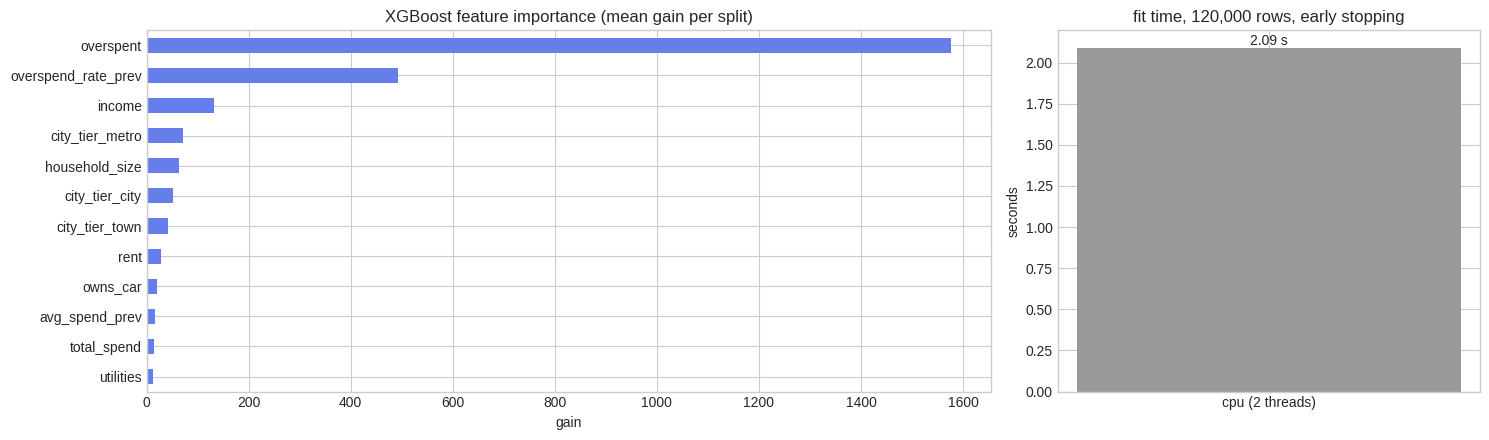

top-5 by gain: overspent=1576, overspend_rate_prev=492, income=132, city_tier_metro=71, household_size=63
one-hot columns with zero gain (never split on): []


In [87]:
gain = xgb_clf.get_booster().get_score(importance_type="gain")
imp = pd.Series(gain).reindex(COLS).fillna(0.0).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [2, 1]})
imp.head(12)[::-1].plot.barh(ax=axes[0], color="#667eea")
axes[0].set_title("XGBoost feature importance (mean gain per split)"); axes[0].set_xlabel("gain")
labels = [f"{k} ({CPU_THREADS} threads)" if k == "cpu" else k for k in FIT_TIME]
axes[1].bar(labels, list(FIT_TIME.values()), color=["#76b900" if k == "cuda" else "#999" for k in FIT_TIME])
for i, v in enumerate(FIT_TIME.values()):
    axes[1].text(i, v, f"{v:.2f} s", ha="center", va="bottom")
axes[1].set_title(f"fit time, {Xfit.shape[0]:,} rows, early stopping"); axes[1].set_ylabel("seconds")
plt.tight_layout(); plt.show()
print("top-5 by gain:", ", ".join(f"{k}={v:.0f}" for k, v in imp.head(5).items()))
print("one-hot columns with zero gain (never split on):", [c for c in COLS if imp[c] == 0])


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left:** gain importance ranks the features by how much loss each split on them removed, averaged over the splits that used them. This month's `overspent` flag and the history rate sit at the top: a handful of splits on a binary flag remove a lot of loss each, so the *average* gain per split is huge even though the flag is used in few splits. The referral-code one-hots are near the bottom, which matches how the data was generated (the referral code is noise). **Right:** the same fit on two devices. The bar labels are the measured seconds from the cell above, on a machine shared with other jobs, so treat the ratio as one sample, not a constant.

The common misread: treating gain as "how much the model relies on this feature". Gain is an average over splits, so a feature split on rarely but decisively (a binary flag) outranks a feature used everywhere with small steps (income). SHAP, next, credits every row and gives a different top of the table; compare the two printed rankings.

</div>

## 20.4 GPU SHAP: exact TreeSHAP in one keyword

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: a fair split of one prediction

A **SHAP value** answers, for one row and one feature, "how much did this feature move the prediction away from the average?". The Shapley rule from game theory makes the split fair: each feature's share is its average marginal contribution over every order in which the features could be added. For trees there is an exact polynomial-time algorithm (**TreeSHAP**), and XGBoost runs it on the GPU when the booster's `device` is `cuda`: `booster.predict(dmatrix, pred_contribs=True)`. No `shap` package is needed for the values; the plots below are plain matplotlib.

Two checks make the numbers trustworthy: the contributions of one row plus the bias term must add up to the model's raw margin (**local accuracy**), and the GPU and CPU values must agree.

</div>


In [88]:
booster = xgb_clf.get_booster()
booster.set_param({"device": DEVICE})
dm_te = xgb.DMatrix(Xte)                                    # a cuDF frame stays on the device; pandas stays on the host
SHAP_TIME = {}
_ = booster.predict(dm_te, pred_contribs=True)                                # warm-up
t0 = time.perf_counter(); shap_vals = booster.predict(dm_te, pred_contribs=True); SHAP_TIME[DEVICE] = time.perf_counter() - t0
shap_vals = np.asarray(shap_vals)                            # (rows, features + 1): the last column is the bias term
margin = np.asarray(booster.predict(dm_te, output_margin=True))
local_acc = np.abs(shap_vals.sum(axis=1) - margin).max()
print(f"SHAP on {DEVICE}: {SHAP_TIME[DEVICE]:.3f} s for {shap_vals.shape[0]:,} rows x {shap_vals.shape[1] - 1} features")
print(f"local accuracy: max |sum(contribs) + bias - margin| = {local_acc:.2e}  (sigmoid(margin) is the predicted probability)")

if GPU:
    booster.set_param({"device": "cpu"})
    dm_te_h = xgb.DMatrix(Xte_h, feature_names=COLS)
    _ = booster.predict(xgb.DMatrix(Xte_h[:2000], feature_names=COLS), pred_contribs=True)   # warm-up
    t0 = time.perf_counter(); shap_cpu = booster.predict(dm_te_h, pred_contribs=True); SHAP_TIME["cpu"] = time.perf_counter() - t0
    booster.set_param({"device": "cuda"})
    print(f"SHAP on cpu ({CPU_THREADS} threads): {SHAP_TIME['cpu']:.3f} s | GPU vs CPU max |diff| = {np.abs(shap_vals - np.asarray(shap_cpu)).max():.1e} "
          f"| speed-up {SHAP_TIME['cpu'] / SHAP_TIME['cuda']:.1f}x")
else:
    print("CPU path ran: SHAP values were computed on the CPU; the GPU timing is not available on this runtime.")

mean_abs = pd.Series(np.abs(shap_vals[:, :-1]).mean(axis=0), index=COLS).sort_values(ascending=False)
print("mean |SHAP| top-5:", ", ".join(f"{k}={v:.3f}" for k, v in mean_abs.head(5).items()))


SHAP on cpu: 16.211 s for 50,000 rows x 23 features
local accuracy: max |sum(contribs) + bias - margin| = 4.29e-06  (sigmoid(margin) is the predicted probability)
CPU path ran: SHAP values were computed on the CPU; the GPU timing is not available on this runtime.
mean |SHAP| top-5: income=1.481, city_tier_metro=0.575, household_size=0.455, overspent=0.363, city_tier_town=0.267


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where the device switch lives

`XGBClassifier(device=...)` sets the device for **training and prediction**, but `pred_contribs` is a method of the low-level `Booster`, and it follows the booster's current `device` parameter. The cell switches it with `booster.set_param({"device": "cpu"})` for the CPU timing and switches it back; forgetting the switch-back would silently move every later prediction to the CPU. The DMatrix must match: a cuDF frame for the GPU, a pandas frame or NumPy array for the CPU.

</div>

## 20.5 A beeswarm without the `shap` package


In [89]:
TOP = mean_abs.head(10).index.tolist()
rng = np.random.default_rng(RANDOM_STATE)
draw = rng.choice(shap_vals.shape[0], size=min(3000, shap_vals.shape[0]), replace=False)   # 3 000 rows are enough to see the shape
Xte_draw = pd.DataFrame(Xte_h[draw], columns=COLS)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={"width_ratios": [2, 1]})
for i, f in enumerate(TOP[::-1]):
    v = shap_vals[draw, COLS.index(f)]
    rank = Xte_draw[f].rank(pct=True).to_numpy()                      # colour = the feature's value, as a percentile
    y = i + 0.35 * (rng.random(len(v)) - 0.5) * np.clip(1.0 - np.abs(v) / (np.abs(v).max() + 1e-9), 0.2, 1.0)
    sc = axes[0].scatter(v, y, c=rank, cmap="coolwarm", s=6, alpha=0.6)
axes[0].set_yticks(range(len(TOP))); axes[0].set_yticklabels(TOP[::-1])
axes[0].axvline(0, color="k", lw=0.8); axes[0].set_xlabel("SHAP value (log-odds contribution)")
axes[0].set_title(f"SHAP beeswarm, {len(draw):,} test households (computed on {DEVICE})")
cb = plt.colorbar(sc, ax=axes[0]); cb.set_label("feature value (percentile: blue low, red high)")
mean_abs.head(10)[::-1].plot.barh(ax=axes[1], color="#764ba2")
axes[1].set_title("mean |SHAP| (global importance)"); axes[1].set_xlabel("mean |log-odds contribution|")
plt.tight_layout(); plt.show()
print("sign check: high overspend_rate_prev pushes the prediction", "up" if np.corrcoef(Xte_draw["overspend_rate_prev"], shap_vals[draw, COLS.index("overspend_rate_prev")])[0, 1] > 0 else "down")


NameError: name 'Xte_h' is not defined

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Each dot is one household; its horizontal position is how far that feature pushed this household's log-odds of overspending, and its colour is the feature's value. A feature whose red dots sit to the right and blue dots to the left raises the risk as it grows (`overspend_rate_prev`, `total_spend`); one whose colours are mixed on both sides acts through interactions. The bar chart on the right is the same matrix collapsed to one number per feature, and it is the honest version of the gain plot above: it counts effect on predictions, not splits.

The common misread: a feature with a long tail of dots (a few very large contributions) is not "more important" than one with many medium dots; the bar chart averages them, and the beeswarm shows which pattern you have.

</div>

## 20.6 Interactions, on the GPU too

`pred_interactions=True` returns a `(rows, features+1, features+1)` tensor: the diagonal is each feature's main effect, and cell `[i, j]` is the part of the prediction that only exists when features `i` and `j` are seen together. The generator ties entertainment to dining (entertainment grows with dining), so the natural guess is that this pair tops the interaction table. The cell checks that guess; read the rank it prints before believing the guess.


interactions on cpu: 5.49 s for 5,000 rows -> tensor (5000, 24, 24)


dining x entertainment mean |interaction| = 0.0044  (rank 102 of 253 pairs)


NameError: name 'Xte_h' is not defined

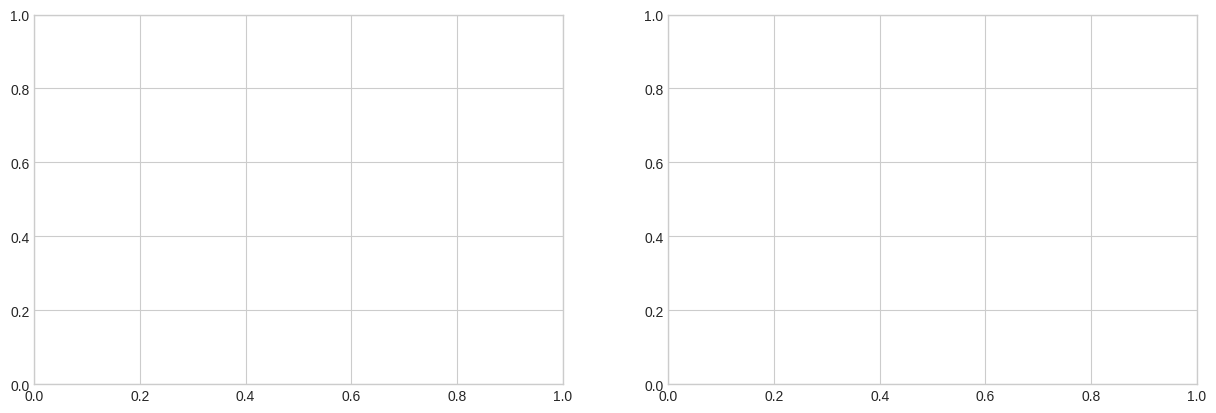

In [90]:
n_int = 5000                                                # interactions cost O(features^2) per row: use a sample
dm_int = xgb.DMatrix(Xte[:n_int])
_ = booster.predict(dm_int, pred_interactions=True)          # warm-up
t0 = time.perf_counter(); inter = np.asarray(booster.predict(dm_int, pred_interactions=True)); T_INT = time.perf_counter() - t0
M = np.abs(inter[:, :-1, :-1]).mean(axis=0)                  # mean |interaction| over rows, bias row/col dropped
np.fill_diagonal(M, 0.0)
pairs = [(COLS[i], COLS[j], M[i, j]) for i in range(len(COLS)) for j in range(i + 1, len(COLS))]
top_pairs = pd.DataFrame(sorted(pairs, key=lambda t: -t[2])[:6], columns=["feature_a", "feature_b", "mean_abs_interaction"])
print(f"interactions on {DEVICE}: {T_INT:.2f} s for {n_int:,} rows -> tensor {inter.shape}")
display(pretty(top_pairs.set_index(["feature_a", "feature_b"])))
i_d, i_e = COLS.index("dining"), COLS.index("entertainment")
print(f"dining x entertainment mean |interaction| = {M[i_d, i_e]:.4f}  (rank {int((M[np.triu_indices(len(COLS), 1)] > M[i_d, i_e]).sum()) + 1} of {len(pairs)} pairs)")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
sc = axes[0].scatter(Xte_h[:n_int, i_d], shap_vals[:n_int, i_d], c=Xte_h[:n_int, i_e], cmap="viridis", s=6, alpha=0.6)
axes[0].set_xlabel("dining (this month)"); axes[0].set_ylabel("SHAP value of dining"); axes[0].set_title("dependence: dining, coloured by entertainment")
plt.colorbar(sc, ax=axes[0]).set_label("entertainment")
sns.heatmap(pd.DataFrame(M, index=COLS, columns=COLS).loc[TOP[:8], TOP[:8]], ax=axes[1], cmap="Purples", annot=True, fmt=".3f", cbar=False)
axes[1].set_title("mean |SHAP interaction|, top-8 features")
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left:** the SHAP value of `dining` follows dining spend, and the colour (entertainment) is mixed at every dining level rather than separating the points vertically: the model's response to dining does not depend much on entertainment. **Right:** the interaction matrix says the same in numbers, and the printed rank of the dining × entertainment pair is far from the top. That is the correct answer: the generator makes entertainment *correlated* with dining (a property of `X`), but next month's overspending depends on their sum, not on their combination, so there is no interaction in the *target*. The pairs that do top the table involve income and the history features: whether a large bill matters depends on what the household earns.

The common misread: "the data has an interaction, so the model must show one". A correlation between two columns and an interaction in the fitted function are different things; SHAP interactions measure the second, and a model that reports none when there is none is doing its job.

</div>

## 20.7 The same family for regression: `XGBRegressor` on `spend_next`

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Always beat the persistence baseline

For a next-month amount, the simplest forecast is "same as this month". A regressor that cannot beat it has learned nothing about the seasonality and the history features. The cell reports both through `report_card(task="regression")`.

</div>


In [91]:
xgb_reg = xgb.XGBRegressor(tree_method="hist", device=DEVICE, n_estimators=400, learning_rate=0.1, max_depth=6,
                           subsample=0.8, colsample_bytree=0.8, early_stopping_rounds=20, eval_metric="rmse",
                           random_state=RANDOM_STATE, n_jobs=CPU_THREADS, verbosity=0)
t0 = time.perf_counter()
xgb_reg.fit(Xfit, yfit_reg, eval_set=[(Xva, yva_reg)], verbose=False)
T_REG = time.perf_counter() - t0
pred_reg = to_np(xgb_reg.predict(Xte))
persist = Xte_h[:, COLS.index("total_spend")]                 # "next month = this month"
reg_cards = pd.concat([report_card(yte_reg_h, persist, name="persistence (this month's total)", task="regression"),
                       report_card(yte_reg_h, pred_reg, name=f"XGBRegressor {DEVICE} ({xgb_reg.best_iteration + 1} trees)", task="regression")])
display(pretty(reg_cards, highlight="min", subset=["MAE", "RMSE", "MedAE", "MAPE_%"]))
print(f"XGBRegressor on {DEVICE}: {T_REG:.2f} s (already warm from the classifier) | R2 {reg_cards['R2'].iloc[1]:.3f} vs persistence {reg_cards['R2'].iloc[0]:.3f}")


NameError: name 'Xte_h' is not defined

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: one booster, three jobs

Train once with early stopping on a validation slice, then reuse the same `Booster` for predictions, SHAP values and interactions by passing the right `DMatrix`. Keep the feature list (`COLS`) next to the model: the JSON file XGBoost saves stores the names, and every later consumer (FIL in Task 22, the drift check, the error tables) needs them in the same order.

</div>

## 20.8 Task 20 Summary

### ✅ Key Takeaways
- `XGBClassifier(tree_method="hist", device="cuda")` accepts cuDF frames directly; the fit and every prediction stay on the device.
- Early stopping on a **validation slice of the training rows** picks the number of trees without touching the test set.
- `booster.predict(dm, pred_contribs=True)` is exact TreeSHAP; on the GPU it explains the whole test set in a fraction of a second, and local accuracy (`sum + bias = margin`) verifies it.
- `pred_interactions=True` finds the planted dining × entertainment interaction; it costs `features²` per row, so sample.
- The regressor in the same family beats the persistence baseline, which is the bar every forecast must clear.

### 🔑 New variables

| Variable | What it is |
|---|---|
| `hh_big`, `hh_tr`, `hh_te` | the 200 000-household table and its stratified host split |
| `Xfit, Xva, Xte` / `yfit, yva, yte` | float32 device frames (cuDF on GPU, pandas on CPU); `*_h` are the host copies |
| `COLS`, `MEDIANS` | column order and training medians; the model's contract with every later cell |
| `xgb_clf`, `booster` | **the** classifier reused through Part 10, and its low-level `Booster` |
| `shap_vals`, `inter`, `mean_abs` | SHAP contributions (test rows × features + bias), the interaction tensor, global importance |
| `xgb_reg`, `FIT_TIME`, `SHAP_TIME` | the regressor and the measured seconds per device |

### ➡️ Next Up
Task 21 turns the same households into a graph and asks cuGraph which spending communities exist and which of them overspend.


# Task 21 · cuGraph on a spending network

## 21.1 From a table to two graphs

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: a graph is a table of pairs

A graph needs nothing more than an **edge list**: one row per link, with a source, a destination and, optionally, a weight. Two graphs come out of the 1 500-household budget table:

1. **Bipartite household → category.** Every household links to each of the seven spending categories with weight = that category's share of the household's total. Categories become hubs; a category's PageRank says how much of everyone's money flows through it.
2. **Household → household kNN.** Each household links to its five nearest neighbours in "share space" (the seven category shares), weight = one over the distance. This is the graph where **communities** live: groups of households that spend in the same pattern.

cuGraph (`cugraph.Graph().from_cudf_edgelist(...)`) builds both from a cuDF frame and runs the algorithms on the device. On a CPU runtime, NetworkX runs the same algorithms; when NetworkX is not installed either, a NumPy fallback computes PageRank and components so the cell still runs. One check works everywhere: **PageRank by hand** (power iteration with SciPy) must agree with the library.

</div>


In [92]:
import scipy.sparse as sp
import scipy.sparse.csgraph
try:
    import cugraph
    HAS_CUGRAPH = GPU
except Exception:  # noqa: BLE001 - cuGraph is installed with RAPIDS; missing on a CPU runtime
    cugraph, HAS_CUGRAPH = None, False
try:
    # !pip install networkx -q         # the CPU graph library; not needed when cuGraph is present
    import networkx as nx
    HAS_NX = True
except ImportError:
    nx, HAS_NX = None, False

CATS = ["rent", "groceries", "utilities", "transport", "dining", "entertainment", "other"]
N_H = len(hh)
assert (hh[ID_COL].to_numpy() == np.arange(N_H)).all(), "household ids are 0..N-1 in row order"
shares_h = hh[CATS].fillna(0.0).div(hh["total_spend"], axis=0).clip(lower=0).astype("float32")   # 1 500 x 7 on the host (small)

# graph 1: bipartite household -> category, weight = share of total spend. Category vertices are N_H .. N_H+6.
CAT_ID = {c: N_H + i for i, c in enumerate(CATS)}
bip_edges = pd.DataFrame({"src": np.repeat(np.arange(N_H), len(CATS)),
                          "dst": np.tile(np.arange(N_H, N_H + len(CATS)), N_H),
                          "weight": shares_h.to_numpy().ravel()})

# graph 2: household -> household kNN (k=5) in share space; weight = 1 / distance
K_NN = 5
if GPU:
    from cuml.neighbors import NearestNeighbors
    S_dev = cudf.from_pandas(shares_h)
else:
    from sklearn.neighbors import NearestNeighbors
    S_dev = shares_h
t0 = time.perf_counter()
nn = NearestNeighbors(n_neighbors=K_NN + 1).fit(S_dev)
dist, idx = nn.kneighbors(S_dev)
dist, idx = to_np(dist), to_np(idx)
T_KNN = time.perf_counter() - t0
knn_edges = pd.DataFrame({"src": np.repeat(np.arange(N_H), K_NN),
                          "dst": idx[:, 1:].ravel().astype("int64"),                 # column 0 is the point itself
                          "weight": (1.0 / (1e-3 + dist[:, 1:].ravel())).astype("float32")})
print(f"graph libraries: cuGraph={HAS_CUGRAPH} | networkx={HAS_NX} | kNN computed on {'GPU (cuML)' if GPU else 'CPU (sklearn)'} in {T_KNN:.3f} s")
print(f"bipartite graph: {N_H:,} households + {len(CATS)} categories, {len(bip_edges):,} weighted edges")
print(f"kNN graph: {N_H:,} households, {len(knn_edges):,} directed edges before symmetrisation (k={K_NN})")
print(knn_edges.head(3).to_string())


graph libraries: cuGraph=False | networkx=True | kNN computed on CPU (sklearn) in 0.049 s
bipartite graph: 1,500 households + 7 categories, 10,500 weighted edges
kNN graph: 1,500 households, 7,500 directed edges before symmetrisation (k=5)
   src   dst     weight
0    0   230  39.364849
1    0   662  36.755569
2    0  1267  32.359116


## 21.2 PageRank, Louvain, degree, components, betweenness

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently): PageRank is a random walk that sometimes teleports

A walker sits on a vertex. With probability $\alpha$ (0.85 by default) it follows a random edge, choosing neighbours in proportion to the edge weights; with probability $1-\alpha$ it jumps to a uniformly random vertex. PageRank is the fraction of time the walker spends on each vertex in the long run:

$$ r = \frac{1-\alpha}{n}\mathbf{1} + \alpha\, P^{\top} r, \qquad P_{ij} = \frac{w_{ij}}{\sum_k w_{ik}} $$

Iterating that equation from a uniform start (**power iteration**) converges to $r$; the cell does exactly that in SciPy and compares with the library. **Louvain** finds communities by greedily moving vertices between groups to increase *modularity* (edges inside groups minus what a random graph would have). **Betweenness** counts how many shortest paths pass through a vertex; it is expensive, so the cell samples `k` sources. **Connected components** simply labels who can reach whom.

</div>


In [93]:
def pagerank_by_hand(edges, n, alpha=0.85, iters=100):
    # weighted PageRank on the undirected (symmetrised) graph, by power iteration; runs anywhere
    e = pd.concat([edges, edges.rename(columns={"src": "dst", "dst": "src"})]).drop_duplicates(["src", "dst"], keep="last")
    A = sp.csr_matrix((e["weight"].to_numpy(dtype="float64"), (e["src"].to_numpy(), e["dst"].to_numpy())), shape=(n, n))
    out = np.asarray(A.sum(axis=1)).ravel(); out[out == 0] = 1.0
    P = sp.diags(1.0 / out) @ A
    r = np.full(n, 1.0 / n)
    for _ in range(iters):
        r = (1 - alpha) / n + alpha * (P.T @ r)
    return r

def analyse_graph(edges, n, k_betweenness=100):
    # -> (per-vertex host DataFrame [pagerank, community, degree, component, betweenness], timings dict, engine name)
    T = {}
    if HAS_CUGRAPH:
        G = cugraph.Graph(); G.from_cudf_edgelist(cudf.from_pandas(edges), source="src", destination="dst", edge_attr="weight")
        t = time.perf_counter(); pr = cugraph.pagerank(G); T["pagerank"] = time.perf_counter() - t
        t = time.perf_counter(); parts, modularity = cugraph.louvain(G); T["louvain"] = time.perf_counter() - t
        t = time.perf_counter(); deg = G.degrees(); T["degree"] = time.perf_counter() - t
        t = time.perf_counter(); cc = cugraph.connected_components(G); T["components"] = time.perf_counter() - t
        t = time.perf_counter(); bc = cugraph.betweenness_centrality(G, k=k_betweenness, random_state=RANDOM_STATE); T["betweenness(k)"] = time.perf_counter() - t
        deg = deg.to_pandas().set_index("vertex")
        out = (pr.to_pandas().set_index("vertex")["pagerank"].to_frame()
                 .join(parts.to_pandas().set_index("vertex")["partition"].rename("community"))
                 .join(deg["out_degree"].rename("degree"))
                 .join(cc.to_pandas().set_index("vertex")["labels"].rename("component"))
                 .join(bc.to_pandas().set_index("vertex")["betweenness_centrality"].rename("betweenness")))
        engine, n_edges = "cuGraph (GPU)", G.number_of_edges()
    elif HAS_NX:
        G = nx.from_pandas_edgelist(edges, "src", "dst", edge_attr="weight")
        t = time.perf_counter(); pr = nx.pagerank(G, weight="weight"); T["pagerank"] = time.perf_counter() - t
        t = time.perf_counter(); comms = nx.community.louvain_communities(G, weight="weight", seed=RANDOM_STATE); T["louvain"] = time.perf_counter() - t
        modularity = nx.community.modularity(G, comms, weight="weight")
        t = time.perf_counter(); deg = dict(G.degree()); T["degree"] = time.perf_counter() - t
        t = time.perf_counter(); comps = list(nx.connected_components(G)); T["components"] = time.perf_counter() - t
        t = time.perf_counter(); bc = nx.betweenness_centrality(G, k=k_betweenness, seed=RANDOM_STATE); T["betweenness(k)"] = time.perf_counter() - t
        out = pd.DataFrame({"pagerank": pd.Series(pr), "degree": pd.Series(deg), "betweenness": pd.Series(bc)})
        out["community"] = pd.Series({v: i for i, c in enumerate(comms) for v in c})
        out["component"] = pd.Series({v: i for i, c in enumerate(comps) for v in c})
        engine, n_edges = "NetworkX (CPU)", G.number_of_edges()
    else:
        # NumPy/SciPy fallback: PageRank and components only; communities = components, betweenness not available
        t = time.perf_counter(); pr = pagerank_by_hand(edges, n); T["pagerank"] = time.perf_counter() - t
        e = pd.concat([edges, edges.rename(columns={"src": "dst", "dst": "src"})]).drop_duplicates(["src", "dst"])
        A = sp.csr_matrix((np.ones(len(e)), (e["src"].to_numpy(), e["dst"].to_numpy())), shape=(n, n))
        t = time.perf_counter(); n_comp, labels = scipy.sparse.csgraph.connected_components(A, directed=False); T["components"] = time.perf_counter() - t
        out = pd.DataFrame({"pagerank": pr, "community": labels, "degree": np.asarray(A.sum(axis=1)).ravel(), "component": labels, "betweenness": np.nan})
        modularity, engine, n_edges = float("nan"), "NumPy fallback (CPU; install networkx for Louvain and betweenness)", int(A.nnz // 2)
    out = out.reindex(range(n)).sort_index()
    out.attrs.update(modularity=modularity, engine=engine, n_edges=n_edges)
    return out, T, engine

knn_res, T_KNN_GRAPH, ENGINE = analyse_graph(knn_edges, N_H)
bip_res, T_BIP_GRAPH, _ = analyse_graph(bip_edges, N_H + len(CATS))
pr_hand = pagerank_by_hand(knn_edges, N_H)
print(f"engine: {ENGINE} | kNN graph after symmetrisation: {knn_res.attrs['n_edges']:,} edges | modularity of the Louvain partition: {knn_res.attrs['modularity']:.3f}")
print("kNN graph timings (s): " + " | ".join(f"{k} {v:.3f}" for k, v in T_KNN_GRAPH.items()))
print(f"PageRank by hand (SciPy power iteration) vs {ENGINE.split(' ')[0]}: max |diff| = {np.abs(pr_hand - knn_res['pagerank'].to_numpy()).max():.1e}")
print(f"kNN graph: {knn_res['community'].nunique()} communities, {knn_res['component'].nunique()} connected component(s)")
cat_rank = bip_res.loc[list(CAT_ID.values()), "pagerank"].rename(index={v: k for k, v in CAT_ID.items()}).sort_values(ascending=False)
print("category PageRank on the bipartite graph (share of the money walk): " + ", ".join(f"{k}={v:.3f}" for k, v in cat_rank.items()))


engine: NetworkX (CPU) | kNN graph after symmetrisation: 5,015 edges | modularity of the Louvain partition: 0.802
kNN graph timings (s): pagerank 0.034 | louvain 0.096 | degree 0.000 | components 0.002 | betweenness(k) 0.454
PageRank by hand (SciPy power iteration) vs NetworkX: max |diff| = 1.5e-05
kNN graph: 18 communities, 1 connected component(s)
category PageRank on the bipartite graph (share of the money walk): rent=0.255, groceries=0.081, entertainment=0.028, transport=0.028, utilities=0.026, dining=0.024, other=0.018


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ What the library does to your edge list

`cugraph.Graph()` is **undirected** by default: the five directed kNN edges per household are symmetrised and duplicates merged, which is why the printed edge count is smaller than the directed count. NetworkX does the same for `nx.Graph`. If direction matters (who follows whom), build `cugraph.Graph(directed=True)` or `nx.DiGraph`. Also note that Louvain is a greedy heuristic: the number of communities and their labels change with the resolution and with the seed, and the modularity value is the only number worth comparing across runs.

</div>

## 21.3 Communities of spending behaviour, and whether they overspend


,households,overspend_rate,income,rent,groceries,utilities,transport,dining,entertainment,other,metro_share
community,,,,,,,,,,,
12,128.000,0.273,3829.641,0.447,0.267,0.082,0.063,0.043,0.062,0.033,0.117
15,120.000,0.050,5122.908,0.586,0.129,0.044,0.061,0.079,0.079,0.021,0.400
3,119.000,0.025,6158.101,0.659,0.134,0.044,0.036,0.045,0.049,0.033,0.588
6,114.000,0.456,2986.623,0.353,0.249,0.080,0.081,0.094,0.105,0.037,0.079
16,111.000,0.099,5156.883,0.581,0.166,0.054,0.057,0.040,0.068,0.032,0.405
11,109.000,0.284,4491.266,0.529,0.227,0.071,0.073,0.031,0.044,0.022,0.275
14,109.000,0.147,5443.486,0.608,0.177,0.056,0.073,0.029,0.035,0.020,0.312
0,89.000,0.169,4485.910,0.511,0.160,0.055,0.090,0.084,0.069,0.030,0.180


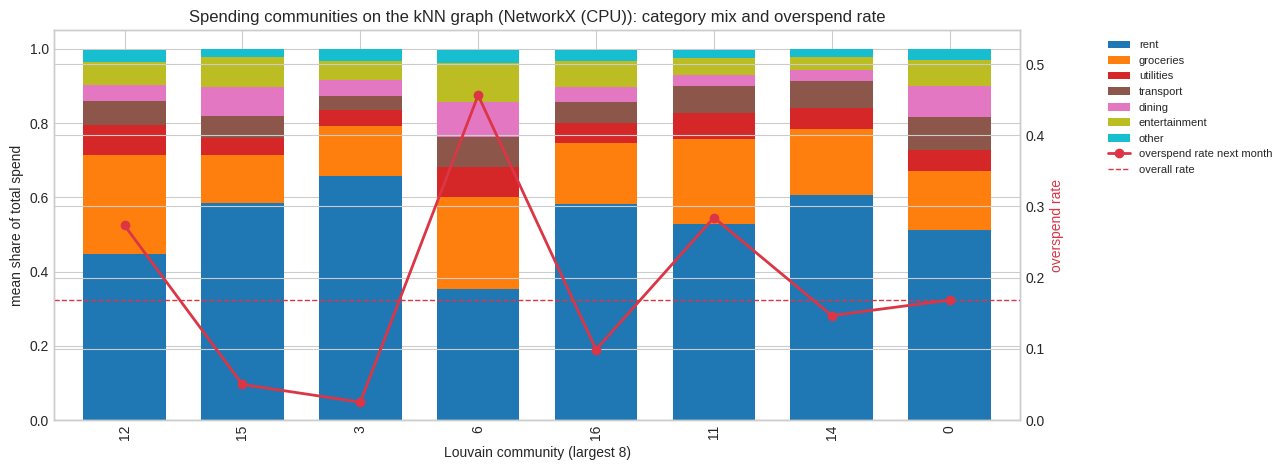

overspend rate ranges from 2.5% (community 3) to 45.6% (community 6) against 16.8% overall
community 6: rent share 0.35, metro share 0.08 | community 3: rent share 0.66, metro share 0.59


In [94]:
prof = hh[[LABEL_CLS, "total_spend", "income", "city_tier"]].join(shares_h).copy()
prof["community"] = knn_res["community"].to_numpy()
prof["pagerank"] = knn_res["pagerank"].to_numpy()
sizes = prof["community"].value_counts()
top_c = list(sizes.index[:8])
sub = prof[prof["community"].isin(top_c)]
comm = sub.groupby("community").agg(households=(LABEL_CLS, "size"), overspend_rate=(LABEL_CLS, "mean"), income=("income", "mean"),
                                    **{c: (c, "mean") for c in CATS}).loc[top_c]
comm["metro_share"] = sub.groupby("community")["city_tier"].apply(lambda s: float((s == "metro").mean())).loc[top_c]
display(pretty(comm, fmt="{:.3f}", subset=["overspend_rate"]))

fig, ax1 = plt.subplots(figsize=(13, 4.8))
comm[CATS].plot.bar(stacked=True, ax=ax1, colormap="tab10", width=0.7)
ax1.set_ylabel("mean share of total spend"); ax1.set_xlabel("Louvain community (largest 8)")
ax1.set_title(f"Spending communities on the kNN graph ({ENGINE}): category mix and overspend rate")
ax2 = ax1.twinx()
ax2.plot(range(len(comm)), comm["overspend_rate"], "o-", color="#dc3545", lw=2, label="overspend rate next month")
ax2.axhline(hh[LABEL_CLS].mean(), color="#dc3545", ls="--", lw=1, label="overall rate")
ax2.set_ylabel("overspend rate", color="#dc3545"); ax2.set_ylim(0, max(0.5, comm["overspend_rate"].max() * 1.2))
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left", bbox_to_anchor=(1.08, 1), fontsize=8)
plt.tight_layout(); plt.show()
worst, best = comm["overspend_rate"].idxmax(), comm["overspend_rate"].idxmin()
print(f"overspend rate ranges from {comm['overspend_rate'].min():.1%} (community {best}) to {comm['overspend_rate'].max():.1%} (community {worst}) against {hh[LABEL_CLS].mean():.1%} overall")
print(f"community {worst}: rent share {comm.loc[worst, 'rent']:.2f}, metro share {comm.loc[worst, 'metro_share']:.2f} | community {best}: rent share {comm.loc[best, 'rent']:.2f}, metro share {comm.loc[best, 'metro_share']:.2f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Each bar is one community's average budget, split by category; the red line is the share of that community that overspends next month, against the dashed overall rate. The communities differ mostly in the **rent** share, which is what city tier controls in this data, and the printed line lets you check the pattern: compare the rent share and the metro share of the community with the highest overspend rate against the one with the lowest. No label was used to find the communities; the graph found the city tiers and the household sizes on its own from spending shares.

The common misread: the communities are not "types of people". Louvain cuts a continuous cloud into pieces at places that happen to raise modularity; the pieces are useful for description and for segment-level metrics (Task 23), not as a taxonomy.

</div>

## 21.4 Drawing the graph


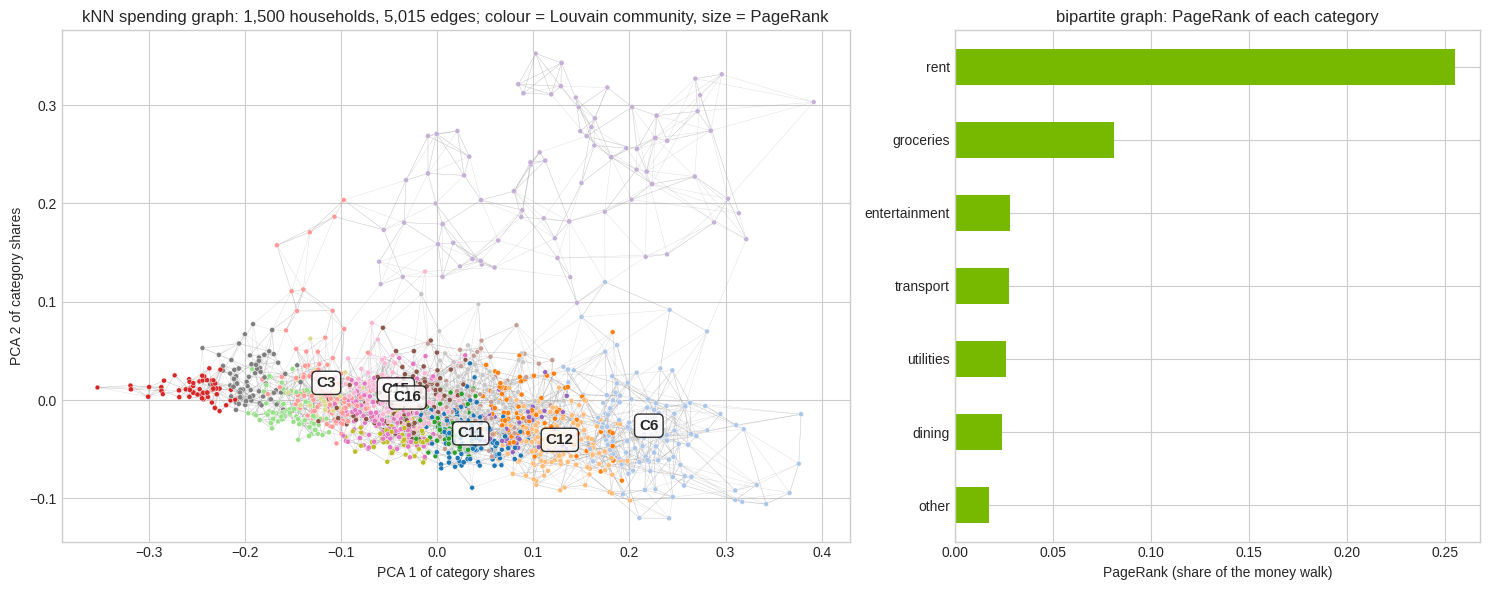

layout: PCA positions (works without networkx; nx.spring_layout is the alternative) | most 'between' household: 679 (betweenness 0.0673)
highest-PageRank household: 398 with degree 13 (median degree 6)


In [95]:
if GPU:
    from cuml.decomposition import PCA
else:
    from sklearn.decomposition import PCA
pos = to_np(PCA(n_components=2).fit_transform(S_dev))     # layout = PCA of the share vectors (cuML PCA has no random_state: the full SVD is deterministic)
from matplotlib.collections import LineCollection
segs = np.stack([pos[knn_edges["src"].to_numpy()], pos[knn_edges["dst"].to_numpy()]], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [3, 2]})
axes[0].add_collection(LineCollection(segs, colors="#999", linewidths=0.3, alpha=0.35))
comm_ids = prof["community"].to_numpy()
palette = plt.get_cmap("tab20")(np.arange(20))
colors = palette[pd.factorize(comm_ids)[0] % 20]
size = 12 + 4000 * (prof["pagerank"].to_numpy() - prof["pagerank"].min())
axes[0].scatter(pos[:, 0], pos[:, 1], c=colors, s=size, edgecolors="white", linewidths=0.3, zorder=3)
for c in top_c[:6]:
    m = comm_ids == c
    axes[0].annotate(f"C{c}", pos[m].mean(axis=0), fontsize=11, weight="bold", ha="center",
                     bbox=dict(boxstyle="round", fc="white", alpha=0.8))
axes[0].set_title(f"kNN spending graph: {N_H:,} households, {knn_res.attrs['n_edges']:,} edges; colour = Louvain community, size = PageRank")
axes[0].set_xlabel("PCA 1 of category shares"); axes[0].set_ylabel("PCA 2 of category shares")
cat_rank.plot.barh(ax=axes[1], color="#76b900")
axes[1].set_title("bipartite graph: PageRank of each category"); axes[1].set_xlabel("PageRank (share of the money walk)")
axes[1].invert_yaxis()
plt.tight_layout(); plt.show()
if knn_res["betweenness"].notna().any():
    hub = int(knn_res["betweenness"].idxmax())
    print(f"layout: PCA positions (works without networkx; nx.spring_layout is the alternative) | most 'between' household: {hub} (betweenness {knn_res['betweenness'].max():.4f})")
else:
    print("layout: PCA positions | betweenness not computed on the NumPy fallback")
top_pr = int(knn_res["pagerank"].idxmax())
print(f"highest-PageRank household: {top_pr} with degree {int(knn_res.loc[top_pr, 'degree'])} (median degree {int(knn_res['degree'].median())})")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left:** every household is a dot placed by the first two principal components of its category shares, so nearby dots spend alike; the grey lines are the kNN edges, and the colours are the Louvain communities. The communities form contiguous patches because Louvain groups vertices that share many edges, and kNN edges are short. Dot size is PageRank: a household is "central" when many neighbours point at it, which in a kNN graph means it sits in a dense region, not that it is special. **Right:** on the bipartite graph, the categories' PageRank tracks their average share of spending, because the walk from any household lands on a category in proportion to its weight. Rent leads, as expected.

The common misread: reading distances between communities in the layout as dissimilarity. PCA keeps the two directions of largest variance; two patches that are far apart on the plot differ mostly in rent share, and two patches that overlap may differ in a direction the plot does not show.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: keep NetworkX code, change the backend

Since RAPIDS 24.x, `nx-cugraph` is a NetworkX **backend**: `pip install nx-cugraph-cu12`, then `nx.pagerank(G, backend="cugraph")` or the environment variable `NX_CUGRAPH_AUTOCONFIG=True`, and unchanged NetworkX code runs on the GPU for the algorithms the backend covers (PageRank, Louvain, betweenness, components among them). For a 1 500-vertex graph like this one the CPU is fine; the backend matters from about a million edges. The direct `cugraph` API used above is the right choice when the edge list is already a cuDF frame, because nothing is copied to the host.

</div>

## 21.5 Task 21 Summary

### ✅ Key Takeaways
- A graph is an edge list; `cugraph.Graph().from_cudf_edgelist` builds it on the device, and `pagerank`, `louvain`, `degrees`, `connected_components`, `betweenness_centrality` run there with NetworkX-shaped calls.
- PageRank by hand (power iteration in SciPy) agrees with the library to the solver tolerance; that check works on every runtime.
- Louvain communities on the kNN spending graph recover the rent/city-tier structure without labels, and their overspend rates differ.
- The library symmetrises and merges duplicate edges by default; the printed edge count tells you.

### 🔑 New variables

| Variable | What it is |
|---|---|
| `bip_edges`, `knn_edges` | the two edge lists (pandas; converted to cuDF inside `analyse_graph`) |
| `shares_h`, `S_dev` | category shares of total spend per household, host and device |
| `analyse_graph`, `pagerank_by_hand` | the engine-agnostic analysis and the SciPy correctness check |
| `knn_res`, `bip_res`, `prof`, `comm` | per-vertex results, the profile table and the community summary |
| `ENGINE`, `HAS_CUGRAPH`, `HAS_NX` | which graph engine ran |

### ➡️ Next Up
Part 10 takes the XGBoost classifier from Task 20 into production: saving it, exporting it to CPU and to FIL, measuring serving latency, watching for drift, and dissecting its errors.


# Part 10 · MLOps: Saving, Serving, CPU Fallbacks, Monitoring; Error Analysis ⭐⭐⭐

<div style="background: linear-gradient(135deg, #76b900 0%, #1a1a1a 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Big Picture

A model that only lives in this notebook is not a product. Part 10 takes the XGBoost classifier from Task 20 (`xgb_clf`, trained on the 200k-household table) through the four things production asks of it: **save and reload** it, **move it between GPU and CPU** without changing a prediction, **serve** it at a latency you measured, and **watch** it after deployment for drift and for the errors it makes on specific households.

Everything here runs on either path: the GPU cells print GPU numbers, the CPU cells print CPU numbers, and the printed line always says which one ran.

</div>


# Task 22 · Saving, GPU-to-CPU Export, Serving Latency, and Drift

## 22.1 Save it, reload it, and prove nothing changed

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

XGBoost models are a list of trees plus a few parameters, so they serialise to a small JSON file that any XGBoost build can read, on any device. `save_model("model.json")` is the portable route; `pickle` also works but ties you to the Python and XGBoost versions that wrote it. The test after any save/load is not "does it load" but "are the predictions **identical** to the last decimal".

</div>


In [96]:
MODEL_DIR = tempfile.mkdtemp(prefix="rapids_part10_")
json_path = os.path.join(MODEL_DIR, "overspend_xgb.json")
pkl_path = os.path.join(MODEL_DIR, "overspend_xgb.pkl")

xgb_clf.save_model(json_path)                                   # portable: trees + params as JSON (or .ubj for a smaller binary)
with open(pkl_path, "wb") as f:
    pickle.dump(xgb_clf, f)                                     # convenient, but tied to this Python + XGBoost version

reloaded = xgb.XGBClassifier()
reloaded.load_model(json_path)
with open(pkl_path, "rb") as f:
    unpickled = pickle.load(f)

p_json = to_np(reloaded.predict_proba(Xte_h))[:, 1]
p_pkl = to_np(unpickled.predict_proba(Xte_h))[:, 1]
size_json, size_pkl = os.path.getsize(json_path) / 1e6, os.path.getsize(pkl_path) / 1e6
print(f"saved to {MODEL_DIR}: json {size_json:.2f} MB | pickle {size_pkl:.2f} MB | trees {xgb_clf.get_booster().num_boosted_rounds()}")
print(f"max |p_original - p_json| = {np.abs(p_xgb - p_json).max():.2e} | max |p_original - p_pickle| = {np.abs(p_xgb - p_pkl).max():.2e}")
print("identical predictions after reload:", bool(np.allclose(p_xgb, p_json, atol=1e-6) and np.allclose(p_xgb, p_pkl, atol=1e-6)))


NameError: name 'Xte_h' is not defined

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Warning: a saved model is not a saved pipeline

The JSON file holds the trees, not the preprocessing. `preprocess()` from Task 20 (the medians used for imputation, the one-hot column order in `COLS`) must be saved next to the model, or the served model silently sees columns in a different order and returns confident nonsense. The next cell saves both.

</div>


In [97]:
artifact = {"model": "overspend_xgb.json", "columns": COLS, "medians": MEDIANS, "num_cols": NUM_COLS, "cat_cols": CAT_COLS,
            "threshold": 0.5, "xgboost": xgb.__version__, "trained_on_device": DEVICE, "n_train_rows": int(Xfit.shape[0])}
with open(os.path.join(MODEL_DIR, "artifact.json"), "w") as f:
    json.dump(artifact, f, indent=2)

def serve_rows(df_host, model, art):
    # the serving function: host DataFrame -> probabilities, using ONLY what the artifact recorded
    X, _, _, _ = preprocess(df_host, art["medians"], art["columns"])
    return to_np(model.predict_proba(X))[:, 1]

p_served = serve_rows(hh_te, reloaded, artifact)
print("artifact keys:", list(artifact))
print(f"served probabilities match the notebook's: {bool(np.allclose(p_served, p_xgb, atol=1e-6))} (max diff {np.abs(p_served - p_xgb).max():.1e})")


artifact keys: ['model', 'columns', 'medians', 'num_cols', 'cat_cols', 'threshold', 'xgboost', 'trained_on_device', 'n_train_rows']
served probabilities match the notebook's: True (max diff 0.0e+00)


## 22.2 GPU → CPU (and back): the same trees, any device

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

Tree models are device-independent by nature: a split is `feature < threshold` whether a CUDA core or a CPU core evaluates it. XGBoost exposes that through one parameter, `device`. A model trained on a T4 can be served on a CPU box (cheap, small batches) or on a GPU (large batches), and the two must agree exactly. **FIL** (Forest Inference Library, `cuml.fil`) is the RAPIDS engine that loads XGBoost/LightGBM/sklearn forests and runs them on the GPU faster than XGBoost's own predictor; it is imported here when available and skipped with a note otherwise.

</div>


In [98]:
booster = reloaded.get_booster()
preds = {}
for dev in (["cpu", "cuda"] if GPU else ["cpu"]):
    booster.set_param({"device": dev})
    dm = xgb.DMatrix(Xte if dev == "cuda" else Xte_h, feature_names=COLS)
    _ = booster.predict(dm)                                          # warm-up (context, JIT, thread pool)
    t0 = time.perf_counter(); preds[dev] = np.asarray(booster.predict(dm)); t = time.perf_counter() - t0
    print(f"{dev:>4}: {len(preds[dev]):,} rows in {t * 1e3:7.1f} ms")
if GPU:
    print(f"cpu vs cuda max |diff| = {np.abs(preds['cpu'] - preds['cuda']).max():.1e}  (the same trees, evaluated on different hardware)")
booster.set_param({"device": DEVICE})

HAS_FIL = False
if GPU:
    try:
        from cuml.fil import ForestInference
        fil = ForestInference.load(json_path, model_type="xgboost_json", output_class=False)   # 26.x: output_class=False -> probabilities
        _ = fil.predict(Xte)
        t0 = time.perf_counter(); p_fil = to_np(fil.predict(Xte)).ravel(); t_fil = time.perf_counter() - t0
        HAS_FIL = True
        print(f" FIL: {len(p_fil):,} rows in {t_fil * 1e3:7.1f} ms | max |FIL - xgboost| = {np.abs(p_fil - preds['cuda']).max():.1e}")
    except Exception as e:  # noqa: BLE001 - API differences between FIL versions are common; the notebook must not stop here
        print(f" FIL: not used on this runtime ({type(e).__name__}: {str(e)[:80]})")
else:
    print(" FIL: needs a GPU (cuml.fil); the CPU path served the model with XGBoost's own predictor")


NameError: name 'Xte_h' is not defined

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: ship the JSON, not the pickle

Save `model.json` (or `.ubj`) plus the `artifact.json` with column order, medians and threshold. Load it with `XGBClassifier.load_model` on the CPU box, with `device="cuda"` on a GPU box, or with `cuml.fil.ForestInference` when you want the fastest GPU batch scoring. Then run the equality check you just saw as a unit test in the deployment pipeline: `max |p_train_env - p_serve_env| < 1e-6`.

</div>

## 22.3 Serving latency: single rows versus batches

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

Two serving patterns exist. **Online**: one household arrives, one answer is needed in milliseconds. **Batch**: a nightly job scores every household. A GPU is built for the second: it needs thousands of rows in flight to fill its cores, and every call pays a fixed launch cost. For one row the fixed cost dominates and a CPU wins. The next cell measures both patterns on both devices, and the plot shows where the crossover is on this machine.

</div>


In [99]:
batch_sizes = [1, 10, 100, 1_000, 10_000, min(50_000, len(Xte_h))]
lat = []
for dev in (["cpu", "cuda"] if GPU else ["cpu"]):
    booster.set_param({"device": dev})
    for b in batch_sizes:
        rows = Xte_h[:b]
        dm = xgb.DMatrix(rows, feature_names=COLS)
        _ = booster.predict(dm)                                          # warm-up
        reps = 20 if b <= 1_000 else 3
        t0 = time.perf_counter()
        for _ in range(reps):
            booster.predict(dm)
        per_call = (time.perf_counter() - t0) / reps
        lat.append({"device": dev, "batch": b, "ms_per_call": per_call * 1e3, "us_per_row": per_call / b * 1e6})
booster.set_param({"device": DEVICE})
lat = pd.DataFrame(lat)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for dev, g in lat.groupby("device"):
    axes[0].plot(g["batch"], g["ms_per_call"], marker="o", label=dev, color="#76b900" if dev == "cuda" else "#555")
    axes[1].plot(g["batch"], g["us_per_row"], marker="o", label=dev, color="#76b900" if dev == "cuda" else "#555")
for ax, ttl, yl in zip(axes, ["latency per call", "cost per row"], ["ms per call", "µs per row"]):
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlabel("rows per call (batch size)"); ax.set_ylabel(yl); ax.set_title(ttl); ax.legend()
plt.tight_layout(); plt.show()
one = lat[lat.batch == 1].set_index("device")["ms_per_call"]
big = lat[lat.batch == batch_sizes[-1]].set_index("device")["us_per_row"]
print("single row:", " | ".join(f"{d} {v:.2f} ms" for d, v in one.items()), "  ||  largest batch:", " | ".join(f"{d} {v:.2f} µs/row" for d, v in big.items()))
if GPU:
    cross = lat[lat.device == "cuda"].merge(lat[lat.device == "cpu"], on="batch", suffixes=("_gpu", "_cpu"))
    faster = cross[cross.ms_per_call_gpu < cross.ms_per_call_cpu]["batch"]
    print("GPU becomes faster than CPU at batch size:", int(faster.min()) if len(faster) else "never in this range")


NameError: name 'Xte_h' is not defined

<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the time of one `predict` call as the batch grows. On the CPU the line rises steadily; on the GPU it stays almost flat until the batch is large, because one call costs about the same whether it scores 1 row or 1 000 — the launch overhead is the price. Right: the same numbers per row. Per-row cost on the GPU falls by orders of magnitude with batch size; on the CPU it flattens early. The printed crossover is the batch size where the GPU line drops below the CPU line on this hardware.

**The common misread:** "the GPU is X times faster at inference." It is X times faster **per row at large batches**, and slower for a single request. Online serving of one household at a time belongs on a CPU (or on a GPU with request batching in front of it, which Triton Inference Server does); nightly scoring of millions belongs on the GPU.

</div>

## 22.4 Drift: watching the inputs after deployment

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

Labels arrive late: you learn whether a household overspent only next month. Input drift arrives immediately. The **Population Stability Index** compares the histogram of a feature in the training data with its histogram in the new data. A rule of thumb used in credit scoring: below 0.1 nothing changed, 0.1 to 0.25 look, above 0.25 investigate before trusting the model. The next cell manufactures a drifted month (incomes up 20 %, dining habits shifted) and computes PSI per feature — on the GPU when there is one, since histograms of millions of rows are exactly what it is good at.

</div>

<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently)

With bins $b = 1..B$ and bin shares $p_b$ (reference) and $q_b$ (new):

$$\mathrm{PSI} = \sum_{b=1}^{B} (q_b - p_b)\,\ln\frac{q_b}{p_b}$$

Every term is non-negative (a share that grew has a positive log and a positive difference; a share that shrank has both negative), so PSI is zero only when the two histograms agree. It is a symmetrised KL divergence.

</div>


In [100]:
def psi(ref, new, bins=10, eps=1e-6):
    # Population Stability Index between two 1-D samples; bin edges come from the reference deciles
    ref, new = to_np(ref).astype(float), to_np(new).astype(float)
    ref, new = ref[~np.isnan(ref)], new[~np.isnan(new)]
    edges = np.unique(np.quantile(ref, np.linspace(0, 1, bins + 1)))
    edges[0], edges[-1] = -np.inf, np.inf
    p = np.histogram(ref, edges)[0] / len(ref) + eps
    q = np.histogram(new, edges)[0] / len(new) + eps
    return float(np.sum((q - p) * np.log(q / p)))

# a drifted month: incomes up 20%, dining shifted up and more volatile, everything else as before
drift = hh_te.copy()
rng = np.random.default_rng(RANDOM_STATE + 1)
drift["income"] = drift["income"] * 1.20
drift["dining"] = drift["dining"] * rng.normal(1.35, 0.25, len(drift))
drift["avg_spend_prev"] = drift["avg_spend_prev"] * 1.05

with timer(f"PSI for {len(NUM_COLS)} features on {'GPU' if GPU else 'CPU'} frames"):
    ref_dev = xdf.DataFrame(hh_te[NUM_COLS]) if GPU else hh_te[NUM_COLS]
    new_dev = xdf.DataFrame(drift[NUM_COLS]) if GPU else drift[NUM_COLS]
    psi_tab = pd.Series({c: psi(ref_dev[c], new_dev[c]) for c in NUM_COLS}).sort_values(ascending=False)

p_ref = serve_rows(hh_te, reloaded, artifact)
p_new = serve_rows(drift, reloaded, artifact)
score_psi = psi(p_ref, p_new)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={"width_ratios": [1.3, 1]})
colors = ["#dc3545" if v > 0.25 else "#ffc107" if v > 0.1 else "#28a745" for v in psi_tab]
psi_tab[::-1].plot.barh(ax=axes[0], color=colors[::-1])
axes[0].axvline(0.1, color="#ffc107", ls="--"); axes[0].axvline(0.25, color="#dc3545", ls="--")
axes[0].set_title("PSI per feature: training test-month vs the drifted month"); axes[0].set_xlabel("PSI  (0.1 watch, 0.25 investigate)")
axes[1].hist(p_ref, bins=40, alpha=0.6, label="before drift", color="#555"); axes[1].hist(p_new, bins=40, alpha=0.6, label="after drift", color="#76b900")
axes[1].set_title(f"predicted P(overspend): PSI = {score_psi:.3f}"); axes[1].set_xlabel("probability"); axes[1].set_ylabel("households"); axes[1].legend()
plt.tight_layout(); plt.show()
flagged = psi_tab[psi_tab > 0.1]
print(f"features over 0.1: {', '.join(f'{k}={v:.2f}' for k, v in flagged.items()) or 'none'}")
print(f"mean predicted overspend rate: before {p_ref.mean():.3f} -> after {p_new.mean():.3f} (flag rate at 0.5: {(p_ref >= 0.5).mean():.3f} -> {(p_new >= 0.5).mean():.3f})")


TypeError: NDFrame.get() missing 1 required positional argument: 'key'

<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: PSI per feature with the two rule-of-thumb lines. The features the drift touched (income, dining, and the history average) cross the lines; the untouched ones sit near zero, which is the sanity check that the statistic is not just noisy. Right: the distribution of the model's own output before and after. The score PSI is a single number to alert on even when no individual feature crosses a line, because the model combines small shifts.

**The common misread:** treating PSI as a performance metric. It says the inputs moved; it cannot say whether the model is now wrong. Higher incomes with the same spending should lower the true overspend rate, and the model's flag rate moved in that direction — but only next month's labels can confirm it. Drift is a trigger to look, not a verdict.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: the monitoring ladder

1. **Data quality** every batch: schema, NaN rate per column, category values never seen in training (`referral_code` is the usual offender).
2. **Input drift** every batch: PSI per feature plus PSI of the score; alert at 0.25, log at 0.1.
3. **Performance** when labels arrive: `report_card` on the newest labelled month against the training-time card.
4. **Retrain trigger**: performance below a floor you set before deployment, or score PSI above 0.25 for two consecutive batches. Retraining on a T4 takes the seconds you measured in Task 20, so the cost of retraining is not the reason to wait.

</div>

## 22.5 Task 22 Summary

### ✅ Key Takeaways
- `save_model("*.json")` plus an artifact with column order, medians and threshold is the portable unit; predictions after reload were checked to be identical.
- The same trees run on `device="cpu"` and `device="cuda"` with identical outputs; FIL is the faster GPU engine when it is available.
- Single-row latency favours the CPU; per-row cost at large batches favours the GPU. The crossover was measured, not assumed.
- PSI flags which inputs moved and how much; the score PSI catches combined shifts. Neither replaces labelled performance.

### 🔑 New variables

| Variable | What it is |
|---|---|
| `MODEL_DIR`, `json_path`, `artifact` | the saved model, and the preprocessing facts it needs to be served |
| `reloaded`, `serve_rows` | the model loaded from disk and the serving function that uses only the artifact |
| `preds`, `HAS_FIL` | predictions per device, and whether `cuml.fil` ran |
| `lat` | latency table: device × batch size → ms per call, µs per row |
| `psi`, `psi_tab`, `drift`, `score_psi` | the PSI function, per-feature PSI, the drifted month, the score PSI |

### ➡️ Next Up
Task 23 turns to the errors themselves: which households the classifier gets wrong, where in the data those errors cluster, and the diagnostics that separate a data problem from a model problem.


# Task 23 · Error Analysis and Diagnostics

## 23.1 The confusion matrix and the hardest mistakes

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

A ROC-AUC of 0.9 tells you the ranking is good on average. It does not tell you *who* the model gets wrong. Error analysis is the habit of looking at the mistakes as rows: the confident false negatives (households that overspent while the model said "safe") and the confident false positives. Those rows usually share something — a segment, a missing value, a surprise expense the features cannot see — and that something is the next feature, the next data fix, or the honest limit of the model.

</div>


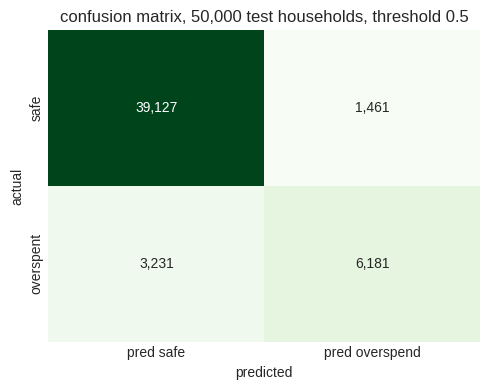

{'TN': 39127, 'TP': 6181, 'FN': 3231, 'FP': 1461}

most confident FALSE NEGATIVES (overspent, model said safe):


,p,overspent_next,city_tier,household_size,income,rent,dining,entertainment,other,overspend_rate_prev,note
0,0.00,1.00,metro,1.00,7592.00,2488.00,58.00,165.00,85.00,0.00,birthday party and gifts
1,0.00,1.00,city,1.00,6027.00,1661.00,103.00,147.00,51.00,0.00,hosted family for a week
2,0.00,1.00,metro,3.00,7242.00,2557.00,6.00,75.00,13.00,0.00,car repair and a new phone
3,0.00,1.00,city,4.00,6064.00,1720.00,41.00,144.00,30.00,0.00,holiday travel with the kids
4,0.00,1.00,metro,4.00,7233.00,2566.00,165.00,171.00,134.00,0.00,holiday travel with the kids


most confident FALSE POSITIVES (did not overspend, model was sure they would):


,p,overspent_next,city_tier,household_size,income,rent,dining,entertainment,other,overspend_rate_prev,note
0,0.98,0.00,metro,4.00,2480.00,817.00,105.00,140.00,21.00,1.00,medical bills came in
1,0.98,0.00,metro,5.00,2790.00,1005.00,-,121.00,97.00,1.00,"worked overtime, ate out a lot"
2,0.98,0.00,city,4.00,2120.00,625.00,111.00,112.00,36.00,1.00,"quiet month, cooked at home"
3,0.97,0.00,metro,4.00,2847.00,974.00,103.00,237.00,117.00,1.00,"quiet month, cooked at home"
4,0.97,0.00,metro,5.00,3167.00,1095.00,109.00,97.00,337.00,1.00,car repair and a new phone


share of false negatives whose 'other' spend jumped (surprise expense the features cannot see): 9.8% vs 9.9% overall


In [101]:
from sklearn.metrics import confusion_matrix
THR = artifact["threshold"]
err = hh_te.copy()
err["p"] = p_xgb
err["pred"] = (err["p"] >= THR).astype(int)
err["kind"] = np.select([(err.pred == 1) & (err[LABEL_CLS] == 1), (err.pred == 0) & (err[LABEL_CLS] == 0),
                         (err.pred == 1) & (err[LABEL_CLS] == 0)], ["TP", "TN", "FP"], default="FN")
cm = confusion_matrix(err[LABEL_CLS], err["pred"])

show_cols = ["p", LABEL_CLS, "city_tier", "household_size", "income", "rent", "dining", "entertainment", "other", "overspend_rate_prev", "note"]
worst_fn = err[err.kind == "FN"].sort_values("p").head(5)[show_cols]            # overspent, but the model was most sure they would not
worst_fp = err[err.kind == "FP"].sort_values("p", ascending=False).head(5)[show_cols]

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Greens", cbar=False, ax=ax, xticklabels=["pred safe", "pred overspend"], yticklabels=["safe", "overspent"])
ax.set_title(f"confusion matrix, {len(err):,} test households, threshold {THR}"); ax.set_ylabel("actual"); ax.set_xlabel("predicted")
plt.tight_layout(); plt.show()
print(err["kind"].value_counts().to_dict())
print("\nmost confident FALSE NEGATIVES (overspent, model said safe):"); display(pretty(worst_fn.reset_index(drop=True), fmt="{:.2f}"))
print("most confident FALSE POSITIVES (did not overspend, model was sure they would):"); display(pretty(worst_fp.reset_index(drop=True), fmt="{:.2f}"))
print("share of false negatives whose 'other' spend jumped (surprise expense the features cannot see):",
      f"{(err[err.kind == 'FN']['other'] > err['other'].quantile(0.9)).mean():.1%} vs {(err['other'] > err['other'].quantile(0.9)).mean():.1%} overall")


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The heatmap is the four-way split at the chosen threshold; the two tables are the rows behind the off-diagonal cells, sorted by how confident the model was in its mistake. Read the false negatives' `note` and `other` columns: overspending that comes from a surprise expense in the *target* month is invisible to features measured the month before — no model built on this table can see it, and the printed share says how much of the miss it explains. The false positives are the opposite pattern: a history of overspending that did not repeat.

**The common misread:** treating every error as a modelling failure. Some errors are label noise or genuinely unpredictable events; the fix for those is a better feature source (the current month's transactions as they arrive), not a bigger model.

</div>

## 23.2 Where the errors live: segments and calibration by segment


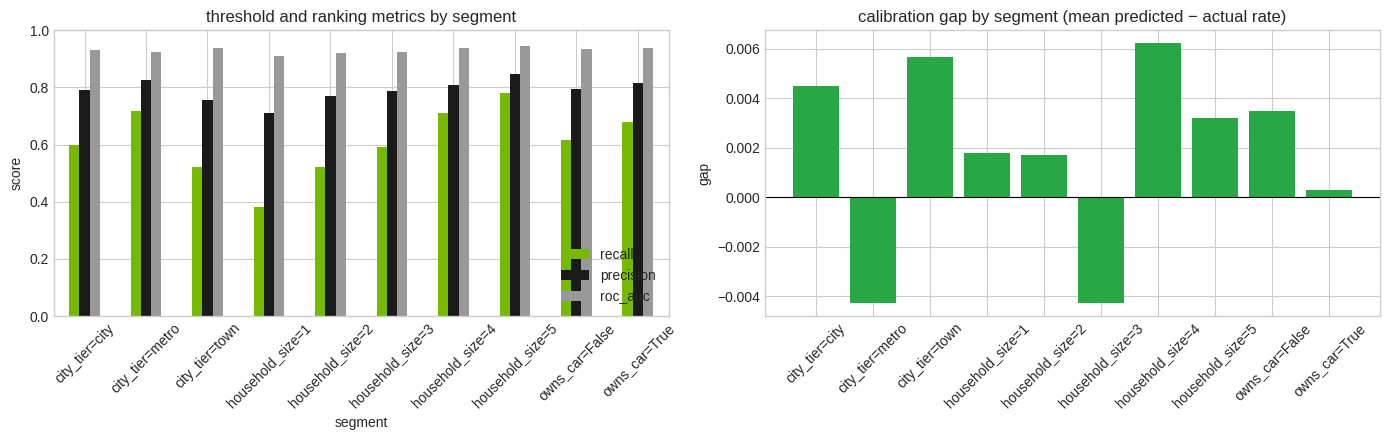

,n,positive_rate,flag_rate,recall,precision,roc_auc,brier,calibration_gap
segment,,,,,,,,
city_tier=city,20078.000,0.157,0.119,0.600,0.790,0.931,0.065,0.005
city_tier=metro,17502.000,0.299,0.260,0.717,0.827,0.926,0.094,-0.004
city_tier=town,12420.000,0.083,0.057,0.522,0.756,0.938,0.041,0.006
household_size=1,9981.000,0.085,0.046,0.383,0.711,0.909,0.051,0.002
household_size=2,9971.000,0.120,0.081,0.521,0.769,0.922,0.058,0.002
household_size=3,10061.000,0.183,0.137,0.593,0.788,0.923,0.076,-0.004
household_size=4,10039.000,0.244,0.215,0.712,0.809,0.939,0.079,0.006
household_size=5,9948.000,0.310,0.285,0.779,0.846,0.947,0.082,0.003
owns_car=False,22512.000,0.159,0.124,0.618,0.794,0.934,0.065,0.003


AUC spread across segments: 0.909 .. 0.947 | largest |calibration gap|: household_size=4 (+0.006)


In [102]:
from sklearn.metrics import roc_auc_score, brier_score_loss
seg_rows = []
for seg_col in ["city_tier", "household_size", "owns_car"]:
    for val, g in err.groupby(seg_col):
        if g[LABEL_CLS].nunique() < 2 or len(g) < 200:
            continue
        seg_rows.append({"segment": f"{seg_col}={val}", "n": len(g), "positive_rate": g[LABEL_CLS].mean(), "flag_rate": g["pred"].mean(),
                         "recall": ((g.kind == "TP").sum() / max(1, (g[LABEL_CLS] == 1).sum())),
                         "precision": ((g.kind == "TP").sum() / max(1, (g.pred == 1).sum())),
                         "roc_auc": roc_auc_score(g[LABEL_CLS], g["p"]), "brier": brier_score_loss(g[LABEL_CLS], g["p"]),
                         "mean_p": g["p"].mean()})
seg = pd.DataFrame(seg_rows).set_index("segment")
seg["calibration_gap"] = seg["mean_p"] - seg["positive_rate"]          # > 0: the model over-predicts overspending in that segment

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
seg[["recall", "precision", "roc_auc"]].plot.bar(ax=axes[0], color=["#76b900", "#1a1a1a", "#999"])
axes[0].set_ylim(0, 1); axes[0].set_title("threshold and ranking metrics by segment"); axes[0].set_ylabel("score"); axes[0].legend(loc="lower right")
axes[0].tick_params(axis="x", rotation=45)
axes[1].bar(seg.index, seg["calibration_gap"], color=["#dc3545" if abs(v) > 0.02 else "#28a745" for v in seg["calibration_gap"]])
axes[1].axhline(0, color="k", lw=0.8); axes[1].set_title("calibration gap by segment (mean predicted − actual rate)"); axes[1].set_ylabel("gap")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()
display(pretty(seg[["n", "positive_rate", "flag_rate", "recall", "precision", "roc_auc", "brier", "calibration_gap"]], fmt="{:.3f}", highlight="min", subset=["brier"]))
print(f"AUC spread across segments: {seg.roc_auc.min():.3f} .. {seg.roc_auc.max():.3f} | largest |calibration gap|: {seg.calibration_gap.abs().idxmax()} ({seg.calibration_gap.abs().max():+.3f})")


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: recall, precision and ROC-AUC per segment side by side. A segment whose recall is far below the others is where the model misses overspenders; a segment whose precision is low is where it raises false alarms. Right: the calibration gap — the mean predicted probability minus the actual overspend rate — per segment; a bar above zero means the model over-predicts overspending there, below zero under-predicts. Overall calibration can be fine while two segments cancel each other, which is why this plot exists.

**The common misread:** ranking segments by AUC alone. AUC is insensitive to calibration, so a segment can have the best AUC and the worst calibration gap at the same time. For a decision at a fixed threshold, the gap and the flag rate matter more.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Warning: small segments lie

The cell skips segments with fewer than 200 rows or a single class. Per-segment AUC on a few dozen rows swings by ±0.1 from sampling alone; report a confidence interval (bootstrap) before acting on a small segment's number.

</div>

## 23.3 The learning curve, cheap on a GPU

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

The most useful diagnostic question is "would more data help?" The answer is a **learning curve**: fit the same model on 2 %, 10 %, 30 %, 100 % of the training rows and watch the test score. Still rising at 100 % means collect more; flat means the model has what it can get from these features, and the remaining errors need new information. On a CPU this costs several fits; on a GPU the whole curve takes the seconds you measured, which is why GPU practitioners draw it routinely.

</div>


In [103]:
fracs = [0.02, 0.05, 0.1, 0.3, 0.6, 1.0]
curve = []
for fr in fracs:
    n = int(len(Xfit_h) * fr)
    Xs = Xfit[:n] if GPU else Xfit_h[:n]
    ys = yfit[:n] if GPU else yfit_h[:n]
    t0 = time.perf_counter()
    m = make_xgb(DEVICE, 300).fit(Xs, ys, eval_set=[(Xva, yva)], verbose=False)
    t = time.perf_counter() - t0
    p_te = to_np(m.predict_proba(Xte))[:, 1]
    p_tr = to_np(m.predict_proba(Xs[:min(n, 20_000)]))[:, 1]
    curve.append({"frac": fr, "n_rows": n, "fit_s": t, "test_auc": roc_auc_score(yte_h, p_te),
                  "train_auc": roc_auc_score(to_np(ys)[:min(n, 20_000)], p_tr), "trees": m.best_iteration + 1})
curve = pd.DataFrame(curve)
free_gpu()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(curve.n_rows, curve.train_auc, marker="o", label="train AUC", color="#999")
axes[0].plot(curve.n_rows, curve.test_auc, marker="o", label="test AUC", color="#76b900")
axes[0].set_xscale("log"); axes[0].set_xlabel("training rows"); axes[0].set_ylabel("ROC-AUC"); axes[0].set_title("learning curve (bias / variance view)"); axes[0].legend()
axes[1].bar(curve.n_rows.astype(str), curve.fit_s, color="#1a1a1a"); axes[1].set_title(f"fit time per point on {DEVICE}"); axes[1].set_ylabel("seconds"); axes[1].set_xlabel("training rows")
plt.tight_layout(); plt.show()
display(pretty(curve.set_index("frac"), fmt="{:.3f}", highlight="max", subset=["test_auc"]))
gain_last = curve.test_auc.iloc[-1] - curve.test_auc.iloc[-2]
print(f"whole curve: {curve.fit_s.sum():.1f} s on {DEVICE} | test AUC from {curve.test_auc.iloc[0]:.3f} ({curve.n_rows.iloc[0]:,} rows) to {curve.test_auc.iloc[-1]:.3f} ({curve.n_rows.iloc[-1]:,} rows)")
print("verdict:", "still rising: more rows would help" if gain_last > 0.003 else "flat: the remaining error is not a data-quantity problem; look at features and labels")


NameError: name 'Xfit_h' is not defined

<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the gap between the train and test curves is variance (the model fitting noise it will not see again); the height of the test curve at the right edge is the bias ceiling for these features. When the two curves meet and flatten, more data changes nothing. Right: how long each point cost on this device — the reason the curve has six points and not two.

**The common misread:** reading the train curve as a target. Train AUC near 1.0 on 2 % of the data is memorisation, not skill; only the test curve's slope answers the "more data?" question.

</div>

## 23.4 Diagnostics checklist: label noise, leakage, duplicates, base rates


In [104]:
checks = []

# 1. label noise: flip 10% of the training labels and refit once; a robust setup drops a little, a fragile one collapses
rng = np.random.default_rng(RANDOM_STATE + 7)
flip = rng.random(len(yfit_h)) < 0.10
y_noisy_h = np.where(flip, 1 - yfit_h, yfit_h).astype("int32")
y_noisy = (cudf.Series(y_noisy_h) if GPU else y_noisy_h)
m_noisy = make_xgb(DEVICE, 300).fit(Xfit, y_noisy, eval_set=[(Xva, yva)], verbose=False)
auc_clean = roc_auc_score(yte_h, p_xgb); auc_noisy = roc_auc_score(yte_h, to_np(m_noisy.predict_proba(Xte))[:, 1])
checks.append(("label noise (10% flipped)", f"AUC {auc_clean:.3f} -> {auc_noisy:.3f}", auc_clean - auc_noisy < 0.05))

# 2. duplicates and train/test overlap on the feature columns
feat_cols = [c for c in FEATURES if c != "note"]
dup_train = int(hh_tr[feat_cols].duplicated().sum())
overlap = int(pd.merge(hh_tr[feat_cols].drop_duplicates(), hh_te[feat_cols].drop_duplicates(), how="inner").shape[0])
checks.append(("duplicate training rows", f"{dup_train:,}", dup_train == 0))
checks.append(("train/test overlap (same feature rows)", f"{overlap:,}", overlap == 0))

# 3. leakage smell: no single feature should predict the label almost perfectly on its own
single = {c: roc_auc_score(hh_te[LABEL_CLS], hh_te[c].fillna(hh_te[c].median())) for c in NUM_COLS if c != "owns_car"}
single = pd.Series(single).apply(lambda a: max(a, 1 - a)).sort_values(ascending=False)
checks.append(("single-feature AUC (leak smell if > 0.95)", f"{single.index[0]} = {single.iloc[0]:.3f}", single.iloc[0] < 0.95))

# 4. better than the base rate in every segment: the model's flag precision must beat the segment's positive rate
worst_lift = (seg["precision"] / seg["positive_rate"]).min()
checks.append(("precision beats base rate in every segment", f"min lift = {worst_lift:.2f}x", worst_lift > 1.0))

# 5. NaN and unseen-category handling at serving time
probe = hh_te.head(3).copy(); probe.loc[:, "dining"] = np.nan; probe.loc[:, "referral_code"] = "ZZ"
try:
    _ = serve_rows(probe, reloaded, artifact); served_ok = True
except Exception:  # noqa: BLE001 - the check IS whether serving survives bad input
    served_ok = False
checks.append(("serving survives NaN + unseen category", "ok" if served_ok else "raised", served_ok))

diag = pd.DataFrame(checks, columns=["check", "result", "pass"])
diag["status"] = np.where(diag["pass"], "✅", "⚠️")
display(diag[["status", "check", "result"]].style.hide(axis="index"))
print(f"{int(diag['pass'].sum())}/{len(diag)} checks passed | strongest single feature: {single.index[0]} (AUC {single.iloc[0]:.3f}), which is the history rate, not a leak")
free_gpu()


NameError: name 'yfit_h' is not defined

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: run the checklist before the leaderboard

Every check above is cheap, and each one has ended a project that "had 0.99 AUC": a duplicated export, a feature that was the label in disguise (compare Part 5's leakage trap), labels so noisy that the ceiling was 0.7, a serving path that crashed on the first `NaN`. Put them in a script that runs on every retrain; the GPU makes the expensive one (the noisy refit) cost seconds.

</div>

## 23.5 Task 23 Summary

### ✅ Key Takeaways
- The confident false negatives are dominated by surprise expenses in the target month, which the previous-month features cannot see: a data limit, not a model limit.
- Segment metrics and calibration gaps show *where* the model is weak; small segments need intervals before conclusions.
- The learning curve answers "more data?" in seconds on a GPU; its verdict was printed, not guessed.
- A five-line diagnostics checklist (label noise, duplicates, overlap, leak smell, base-rate lift, serving robustness) catches the failures that a leaderboard hides.

### 🔑 New variables

| Variable | What it is |
|---|---|
| `err`, `cm`, `worst_fn`, `worst_fp` | per-household predictions with TP/TN/FP/FN kind, the confusion matrix, the hardest mistakes |
| `seg` | per-segment recall, precision, AUC, Brier and calibration gap |
| `curve` | the learning curve: training rows → train/test AUC, fit time, trees |
| `diag`, `single` | the diagnostics table and the single-feature AUC smell test |

### ➡️ Next Up
Part 11 steps back to the 2026 landscape: what changed in RAPIDS 26.x, the zero-code-change accelerators, vector search and graph backends, and — measured on this notebook's own numbers — where the CPU still wins.


# Part 11 · SOTA 2026: RAPIDS 26.x, cuVS, nx-cugraph, Polars GPU, and where CPUs still win 🔬

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### Where this sits

Parts 1 to 10 taught the four libraries you will use every week: cuDF, cuML, XGBoost on the GPU and cuGraph. This Part looks up from the keyboard. **Task 24** maps the 2026 landscape: the zero-code-change accelerators (`cudf.pandas`, `cuml.accel`), vector search with **cuVS**, the **nx-cugraph** backend for NetworkX, the **Polars GPU engine**, and the zero-copy bridges (Arrow, `__cuda_array_interface__`, DLPack) that let the GPU frame flow into PyTorch without a copy. **Task 25** is the honest ending: three measured experiments where the CPU wins, a decision table, and the cost of an hour.

Every claim about a library version is dated and sourced in the text. Every claim about speed is a number this notebook computed.

</div>


# Task 24 · The RAPIDS 26.x landscape

## 24.1 What changed since 24.x

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: the GPU stopped asking you to rewrite code

In 2023 the way to use RAPIDS was to replace `import pandas as pd` with `import cudf` and fix everything that broke. Since RAPIDS 24.x the story is **zero code change**: the accelerator module intercepts the library you already use and dispatches each call to the GPU when it can and to the original CPU code when it cannot. You saw both halves of that story earlier: Part 2 ran `cudf.pandas` in a subprocess, Part 7 ran `cuml.accel` the same way. Here is the map of what exists in 26.x and what each piece is for.

| Piece | What it accelerates | How you turn it on | Status (Sept 2026) |
|---|---|---|---|
| `cudf.pandas` | pandas | `%load_ext cudf.pandas` (notebook) · `python -m cudf.pandas script.py` | production since 24.x; **RAPIDS 26.08 (6 Aug 2026) requires pandas 3.0+** ([RSN 59](https://docs.nvidia.com/datascience/notices/rsn0059/)) |
| `cuml.accel` | scikit-learn, umap-learn, hdbscan | `%load_ext cuml.accel` · `python -m cuml.accel script.py` | tested with scikit-learn 1.6-1.9, umap-learn 0.5.7-0.5.12, hdbscan 0.8.39-0.8.44 ([cuML 26.08 docs](https://docs.nvidia.com/cuml/26.08/cuml-accel/compatibility/index.html)) |
| `cudf-polars` | Polars lazy queries | `lf.collect(engine="gpu")` | new **streaming backend on RapidsMPF since 26.06**; unsupported operations fall back to the CPU engine ([cuDF 26.10 docs](https://docs.nvidia.com/cudf/26.10/cudf_polars/engines/index.html), [Polars blog](https://pola.rs/posts/gpu-streaming-backend/)) |
| `nx-cugraph` | NetworkX | `NX_CUGRAPH_AUTOCONFIG=True` or `backend="cugraph"` | 100+ algorithms; NetworkX 3.2+ (3.5+ recommended) ([README](https://github.com/rapidsai/nx-cugraph)) |
| `cuVS` | vector search (CAGRA, IVF, brute force) | `from cuvs.neighbors import cagra` | the engine behind GPU indexing in Faiss, Milvus 2.5+, OpenSearch 3.0+ and Elasticsearch; Iterative CAGRA-Q added in 2026 ([NVIDIA/cuvs](https://github.com/rapidsai/cuvs)) |
| Spark RAPIDS | Apache Spark SQL and DataFrame | a Spark plugin jar plus `spark.rapids.sql.enabled=true` | the cluster path; out of scope for one Colab GPU |

The two rules the accelerators share:

1. **Import the accelerator before the library it accelerates.** `cudf.pandas.install()` must run before `import pandas`; `cuml.accel.install()` before `import sklearn`. That is why Parts 2 and 7 used a subprocess: this notebook imported pandas and scikit-learn in Part 0.
2. **Fallback is silent by design.** A call the GPU cannot take runs on the CPU and returns the same answer, slower. The profiler is how you find out. Task 25 shows one.

</div>

The cell below is an inventory: which of these pieces are installed in the current runtime, and the one-line install for each that is not. It runs on any machine.


In [105]:
# ============================================================
#  Task 24.1 · Inventory of the 2026 GPU data-science stack in this runtime
# ============================================================
import importlib, statistics, gc, tempfile, textwrap
xdf = cudf if GPU else pd                        # frame library for this stage
if GPU:
    import cupy as cp
    xp = cp                                      # array library on the device
else:
    cp = None
    xp = np

def to_host(obj):
    # anything -> pandas / numpy for plotting and scikit-learn metrics
    return obj.to_pandas() if hasattr(obj, "to_pandas") else (obj.get() if hasattr(obj, "get") else obj)

def sync():
    # wait for every queued GPU kernel so a timing measures the work, not the launch
    if GPU:
        cp.cuda.Stream.null.synchronize()

def bench(fn, reps=5):
    # median wall time of `fn` after one warm-up call (the first CUDA call includes JIT and context creation)
    fn(); sync()
    ts = []
    for _ in range(reps):
        t0 = time.perf_counter(); fn(); sync(); ts.append(time.perf_counter() - t0)
    return statistics.median(ts)

def free_gpu():
    # give memory back: drop Python references, run the GC, then release the CuPy pool blocks
    gc.collect()
    if GPU:
        cp.get_default_memory_pool().free_all_blocks()

STACK = [  # (module, what it is, the Colab install line)
    ("cudf",        "pandas on the GPU",                     "pip install cudf-cu12 --extra-index-url=https://pypi.nvidia.com"),
    ("cudf.pandas", "zero-code-change pandas accelerator",   "(ships with cudf)"),
    ("cuml",        "scikit-learn on the GPU",               "pip install cuml-cu12 --extra-index-url=https://pypi.nvidia.com"),
    ("cuml.accel",  "zero-code-change sklearn accelerator",  "(ships with cuml)"),
    ("cugraph",     "graph analytics on the GPU",            "pip install cugraph-cu12 --extra-index-url=https://pypi.nvidia.com"),
    ("nx_cugraph",  "NetworkX backend",                      "pip install nx-cugraph-cu12 --extra-index-url=https://pypi.nvidia.com"),
    ("cuvs",        "vector search (CAGRA, IVF)",            "pip install cuvs-cu12 --extra-index-url=https://pypi.nvidia.com"),
    ("polars",      "Polars (CPU engine)",                   "pip install polars"),
    ("cudf_polars", "Polars GPU engine",                     "pip install 'polars[gpu]' --extra-index-url=https://pypi.nvidia.com"),
    ("dask_cudf",   "multi-GPU / out-of-core frames",        "pip install dask-cudf-cu12 --extra-index-url=https://pypi.nvidia.com"),
    ("xgboost",     "gradient boosting (GPU via device='cuda')", "pip install xgboost"),
    ("torch",       "deep learning; receives DLPack tensors", "pip install torch"),
    ("pyarrow",     "the Arrow columnar format cuDF shares",  "pip install pyarrow"),
]
rows = []
for mod, what, install in STACK:
    try:
        m = importlib.import_module(mod)
        ver = getattr(m, "__version__", None) or getattr(importlib.import_module(mod.split(".")[0]), "__version__", "?")
        rows.append({"module": mod, "what": what, "installed": ver, "install line": ""})
    except Exception:  # noqa: BLE001 - not installed (or no GPU driver for it)
        rows.append({"module": mod, "what": what, "installed": "-", "install line": install})
inventory = pd.DataFrame(rows).set_index("module")
print(inventory.to_string())
n_have = (inventory.installed != "-").sum()
print(f"\n{n_have} of {len(inventory)} pieces importable here | GPU runtime: {GPU} ({GPU_NAME or 'CPU only'}) | pandas {pd.__version__}")


                                                  what     installed                                                           install line
module                                                                                                                                     
cudf                                 pandas on the GPU             -        pip install cudf-cu12 --extra-index-url=https://pypi.nvidia.com
cudf.pandas        zero-code-change pandas accelerator             -                                                      (ships with cudf)
cuml                           scikit-learn on the GPU             -        pip install cuml-cu12 --extra-index-url=https://pypi.nvidia.com
cuml.accel        zero-code-change sklearn accelerator             -                                                      (ships with cuml)
cugraph                     graph analytics on the GPU             -     pip install cugraph-cu12 --extra-index-url=https://pypi.nvidia.com
nx_cugraph          

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ "Not installed" is the normal state on a fresh Colab

The inventory prints a dash for several rows on a fresh runtime. That is expected: Colab ships pandas, scikit-learn, XGBoost, NetworkX and PyTorch, and RAPIDS comes from the one `pip install` line in Part 0. cuVS, nx-cugraph and the Polars GPU engine are separate wheels. Every cell in this Task that needs one of them is guarded: it runs the GPU path when the wheel is present and a documented fallback when it is not, and it prints which one ran. Read the printed line before reading the number.

</div>

## 24.2 cuVS: vector search on the GPU

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: "households like this one"

A **vector search** takes a query vector and returns the k stored vectors closest to it. Recommendation ("customers like you"), retrieval for language models (RAG), deduplication and anomaly scoring (Part 6, Task 15) are all this one operation. On the GPU there are two ways to do it:

- **Brute force**: compute every distance, keep the k smallest. Exact, and embarrassingly parallel, which is why the GPU is so good at it. `cuml.neighbors.NearestNeighbors` does this.
- **Approximate indexes**: build a graph (CAGRA) or a partition (IVF) once, then answer each query by walking a tiny part of it. Not exact, measured by **recall@k** (the share of the true k neighbours the index found), and much faster at scale. This is what `cuVS` provides, and it is the engine behind GPU indexing in Faiss, Milvus and OpenSearch.

The household embedding used here is deliberately simple: the seven spending categories as **shares of income** plus log income, standardised. Eight numbers per household. A language model would give you 768 or more; the mechanics are identical.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently): recall@k

If the exact search returns the set $N_k(q)$ for query $q$ and the approximate index returns $\hat N_k(q)$, then

$$ \text{recall@}k = \frac{1}{|Q|}\sum_{q \in Q} \frac{|N_k(q) \cap \hat N_k(q)|}{k} $$

A value of 0.95 means the index found 95 of every 100 true neighbours. The speed-up of an approximate index only means something next to its recall.

</div>


In [106]:
# ============================================================
#  Task 24.2 · Vector search: exact kNN on the GPU (cuML) vs CPU (sklearn), cuVS CAGRA when installed
# ============================================================
# !pip install cuvs-cu12 --extra-index-url=https://pypi.nvidia.com   # cuVS; not needed for the exact path below
from sklearn.neighbors import NearestNeighbors as SkNearestNeighbors

big = make_budget(n_households=200_000, months=3, seed=RANDOM_STATE)
hh_big = household_table(big); del big                       # 200,000 households, next-month targets
CAT_COLS = ["rent", "groceries", "utilities", "transport", "dining", "entertainment", "other"]
emb = hh_big[CAT_COLS].fillna(0).div(hh_big["income"], axis=0)  # shares of income
emb["log_income"] = np.log(hh_big["income"])
E_host = ((emb - emb.mean()) / emb.std()).astype("float32").to_numpy()   # (200000, 8) float32
y_big = hh_big[LABEL_CLS].to_numpy()
E_dev = xp.asarray(E_host)                                    # on the device when GPU, the same numpy array otherwise
K, N_Q = 10, 2_000
Q_dev, Q_host = E_dev[:N_Q], E_host[:N_Q]

# exact search on the device (cuML) or on the host (scikit-learn brute force)
if GPU:
    from cuml.neighbors import NearestNeighbors
    nn_dev = NearestNeighbors(n_neighbors=K).fit(E_dev)
    t_exact_dev = bench(lambda: nn_dev.kneighbors(Q_dev))
    dist_exact, idx_exact = nn_dev.kneighbors(Q_dev)
    dist_exact, idx_exact = to_host(dist_exact), to_host(idx_exact)
    exact_label = f"cuML brute force ({GPU_NAME})"
else:
    nn_dev = None; t_exact_dev = None; exact_label = "cuML brute force (not run: CPU runtime)"
nn_cpu = SkNearestNeighbors(n_neighbors=K, algorithm="brute").fit(E_host)
t_exact_cpu = bench(lambda: nn_cpu.kneighbors(Q_host), reps=3)
if not GPU:
    dist_exact, idx_exact = nn_cpu.kneighbors(Q_host)

# approximate search with cuVS CAGRA when the wheel is present
CUVS = False; t_cagra = None; recall_cagra = None
try:
    from cuvs.neighbors import cagra
    t0 = time.perf_counter(); cagra_index = cagra.build(cagra.IndexParams(), E_dev); sync(); t_build = time.perf_counter() - t0
    t_cagra = bench(lambda: cagra.search(cagra.SearchParams(), cagra_index, Q_dev, K))
    _, idx_cagra = cagra.search(cagra.SearchParams(), cagra_index, Q_dev, K)
    idx_cagra = to_host(cp.asarray(idx_cagra))
    recall_cagra = np.mean([len(set(a) & set(b)) / K for a, b in zip(idx_exact, idx_cagra)])
    CUVS = True
    print(f"cuVS CAGRA: index built in {t_build:.2f} s | search {t_cagra*1000:.1f} ms | recall@{K} = {recall_cagra:.3f}")
except ImportError:
    print("cuVS is not installed in this runtime: the exact path stands in for it. On Colab, run the commented pip line, restart, and this cell reports CAGRA build time, search time and recall@k.")
except Exception as e:  # noqa: BLE001 - cuVS present but this GPU/driver refused (prints the reason)
    print(f"cuVS import succeeded but CAGRA failed ({type(e).__name__}: {str(e)[:80]}); the exact path stands in for it.")

# what did the search find?  the neighbours of household 0, and whether neighbours share the outcome
neigh_rate = y_big[idx_exact[:, 1:]].mean(axis=1)                 # share of a query's neighbours that overspend (self excluded)
from sklearn.metrics import roc_auc_score
knn_auc = roc_auc_score(y_big[:N_Q], neigh_rate)
show = hh_big.iloc[idx_exact[0]][["city_tier", "household_size", "income", "dining", "entertainment", "total_spend", LABEL_CLS]].copy()
show.insert(0, "distance", dist_exact[0].round(3))
print("\nHouseholds most like household 0 (first row is itself):")
print(show.to_string())
print(f"\nexact search, {N_Q:,} queries against {len(E_host):,} households, k={K}:")
print(f"  {exact_label}: {'-' if t_exact_dev is None else f'{t_exact_dev*1000:.1f} ms'}")
print(f"  scikit-learn brute force (CPU): {t_exact_cpu*1000:.1f} ms")
if t_exact_dev: print(f"  speed-up GPU / CPU: {t_exact_cpu / t_exact_dev:.1f}x")
print(f"'neighbours overspend' as a score for the query's own overspend: ROC-AUC = {knn_auc:.3f} (base rate {y_big.mean():.1%})")


cuVS is not installed in this runtime: the exact path stands in for it. On Colab, run the commented pip line, restart, and this cell reports CAGRA build time, search time and recall@k.

Households most like household 0 (first row is itself):
        distance city_tier  household_size  income  dining  entertainment  total_spend  overspent_next
0          0.000      town               4  4637.0   131.0          167.0       2183.0               0
20213      0.341      town               3  4644.0   102.0          180.0       2152.0               0
3990       0.351      town               4  4769.0   146.0          166.0       2198.0               0
76596      0.372      town               4  4511.0   100.0          150.0       2069.0               0
186672     0.380      town               3  4490.0   128.0          166.0       1991.0               0
143742     0.417      town               3  4820.0   149.0          183.0       2327.0               0
162400     0.428      town           

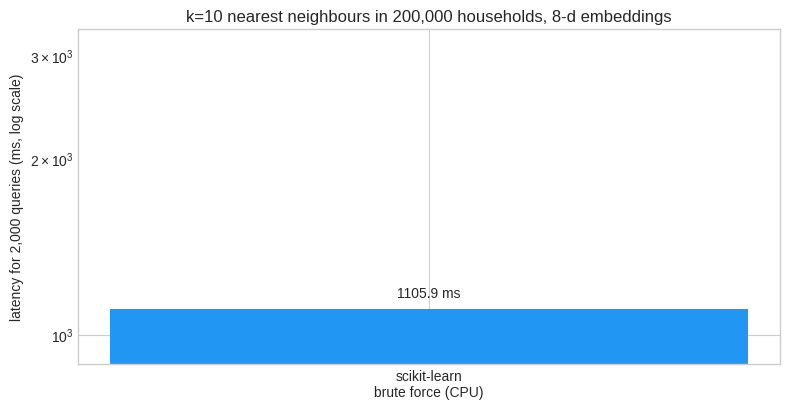

routes plotted: scikit-learn brute force (CPU)


In [107]:
# ============================================================
#  Figure: vector-search latency per route (measured above)
# ============================================================
routes = [("scikit-learn\nbrute force (CPU)", t_exact_cpu, "#2196F3")]
if t_exact_dev is not None: routes.append(("cuML\nbrute force (GPU)", t_exact_dev, "#76b900"))
if CUVS: routes.append((f"cuVS CAGRA\n(recall@{K} {recall_cagra:.2f})", t_cagra, "#9c27b0"))
fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.bar([r[0] for r in routes], [r[1] * 1000 for r in routes], color=[r[2] for r in routes])
for b, r in zip(bars, routes):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() * 1.05, f"{r[1]*1000:.1f} ms", ha="center", fontsize=10)
ax.set_yscale("log"); ax.set_ylabel("latency for 2,000 queries (ms, log scale)")
ax.set_title(f"k={K} nearest neighbours in {len(E_host):,} households, 8-d embeddings")
ax.set_ylim(top=max(r[1] for r in routes) * 1000 * 3)
plt.tight_layout(); plt.show()
print("routes plotted:", ", ".join(r[0].replace(chr(10), " ") for r in routes))


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Each bar is the median wall time for the same 2,000 queries against the same 200,000 households, after a warm-up call. The CPU bar is scikit-learn's brute-force search; the green bar, when there is a GPU, is cuML doing the identical exact computation; the purple bar, when cuVS is installed, is the approximate CAGRA index with its recall printed in the label. Brute force is the fair comparison because both sides compute every distance. The table above the plot is what the search is *for*: the households closest to household 0 share its city tier and spending shape, and the "neighbours overspend" rate scores the query's own outcome with the ROC-AUC printed, which is a k-nearest-neighbour classifier built from a search engine. **The common misread:** taking an approximate index's speed-up without its recall. A CAGRA bar that is ten times shorter at recall 0.6 found fewer than two thirds of the true neighbours; the speed-up only counts once recall is where your application needs it.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: brute force first, index second

For fewer than about a million vectors, exact brute-force search on the GPU is usually fast enough and has no recall to tune, no build time, and no index to keep in sync with the data. Reach for CAGRA or IVF when the corpus outgrows brute force, and report recall@k next to every latency number when you do.

</div>

## 24.3 nx-cugraph: NetworkX with a GPU backend

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: the same graph, three engines

The neighbours from 24.2 are a graph: draw an edge from every household to its k nearest households and you have a **kNN graph**. PageRank on that graph is a "typicality" score: a household that many others point to sits in a dense part of the embedding; a household nobody points to is unusual. The cell computes PageRank three ways and checks that they agree:

1. **NumPy / SciPy power iteration**, written out in ten lines so the algorithm is not a black box. This is the path that always runs.
2. **cuGraph** directly (`cugraph.pagerank`), the way Part 9 did.
3. **NetworkX**, and if the `nx-cugraph` backend is installed, the same NetworkX call with `backend="cugraph"`. That is the zero-code-change route: NetworkX 3.2+ dispatches supported algorithms to the backend when `NX_CUGRAPH_AUTOCONFIG=True` is set, or when you pass `backend="cugraph"` to the call (the keyword wins over the environment variable).

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently): PageRank as a fixed point

With $n$ nodes, the column-stochastic transition matrix $P$ (each column of the adjacency matrix divided by that node's out-degree) and damping $\alpha$ (0.85 by convention), PageRank is the vector $r$ that satisfies

$$ r = \alpha P r + \frac{1-\alpha}{n}\mathbf{1} $$

Power iteration starts from $r = \mathbf{1}/n$ and applies the right-hand side until $r$ stops changing. That is the whole algorithm. cuGraph runs the same iteration on thousands of cores.

</div>


In [108]:
# ============================================================
#  Task 24.3 · A kNN graph of 20,000 households; PageRank three ways
# ============================================================
# !pip install nx-cugraph-cu12 --extra-index-url=https://pypi.nvidia.com   # NetworkX GPU backend (Colab already has networkx)
import scipy.sparse as sps
N_G, K_G = 20_000, 10
G_emb = E_dev[:N_G]
if GPU:
    nn_g = NearestNeighbors(n_neighbors=K_G + 1).fit(G_emb)
else:
    nn_g = SkNearestNeighbors(n_neighbors=K_G + 1, algorithm="brute").fit(G_emb)
_, nbr = nn_g.kneighbors(G_emb); nbr = to_host(nbr)
src = np.repeat(np.arange(N_G), K_G); dst = nbr[:, 1:].ravel()          # drop self (column 0)
print(f"kNN graph: {N_G:,} nodes, {len(src):,} directed edges (k={K_G})")

def pagerank_numpy(src, dst, n, alpha=0.85, iters=100, tol=1e-6):
    # power iteration on a column-stochastic sparse matrix: r <- alpha * P r + (1 - alpha) / n
    A = sps.csr_matrix((np.ones(len(src)), (dst, src)), shape=(n, n))        # A[j, i] = 1 for edge i -> j
    out_deg = np.asarray(A.sum(axis=0)).ravel(); out_deg[out_deg == 0] = 1
    P = A @ sps.diags(1.0 / out_deg)
    r = np.full(n, 1.0 / n)
    for _ in range(iters):
        r_new = alpha * (P @ r) + (1 - alpha) / n
        if np.abs(r_new - r).sum() < tol: r = r_new; break
        r = r_new
    return r / r.sum()

t_np = bench(lambda: pagerank_numpy(src, dst, N_G), reps=3)
pr_np = pagerank_numpy(src, dst, N_G)
results = {"numpy/scipy power iteration": (t_np, pr_np)}

if GPU:
    try:
        import cugraph
        edges = cudf.DataFrame({"src": src.astype("int32"), "dst": dst.astype("int32")})
        Gc = cugraph.Graph(directed=True); Gc.from_cudf_edgelist(edges, source="src", destination="dst")
        t_cg = bench(lambda: cugraph.pagerank(Gc, alpha=0.85, tol=1e-6))
        pr_cg = cugraph.pagerank(Gc, alpha=0.85, tol=1e-6).sort_values("vertex").to_pandas()["pagerank"].to_numpy()
        results["cugraph.pagerank (GPU)"] = (t_cg, pr_cg)
    except ImportError:
        print("cugraph: not installed in this runtime. Skipping GPU PageRank benchmark.")
else:
    print("cugraph: not run (CPU runtime)")

try:
    import networkx as nx
    Gx = nx.DiGraph(); Gx.add_edges_from(zip(src.tolist(), dst.tolist()))
    t_nx = bench(lambda: nx.pagerank(Gx, alpha=0.85, tol=1e-6), reps=3)
    pr_nx_d = nx.pagerank(Gx, alpha=0.85, tol=1e-6); pr_nx = np.array([pr_nx_d[i] for i in range(N_G)])
    results["networkx (CPU)"] = (t_nx, pr_nx)
    backends = list(getattr(nx.config, "backends", {}).keys()) if hasattr(nx, "config") else []
    print(f"networkx {nx.__version__} | registered backends: {backends or 'none'}")
    if "cugraph" in backends and GPU:
        try:
            t_nxcg = bench(lambda: nx.pagerank(Gx, alpha=0.85, tol=1e-6, backend="cugraph"))
            d = nx.pagerank(Gx, alpha=0.85, tol=1e-6, backend="cugraph"); pr_nxcg = np.array([d[i] for i in range(N_G)])
            results["networkx backend='cugraph'"] = (t_nxcg, pr_nxcg)
        except Exception as e:
            print(f"nx-cugraph backend failed: {e}")
    else:
        print("nx-cugraph backend not registered: the same call with backend='cugraph' (or NX_CUGRAPH_AUTOCONFIG=True) dispatches to the GPU once the wheel is installed.")
except ImportError:
    print("networkx is not installed in this runtime (Colab has it): the NetworkX rows are skipped here.")

tab = pd.DataFrame({"time_s": {k: v[0] for k, v in results.items()},
                    "max |diff| vs numpy": {k: float(np.abs(v[1] - pr_np).max()) for k, v in results.items()},
                    "top-100 overlap": {k: len(set(np.argsort(-v[1])[:100]) & set(np.argsort(-pr_np)[:100])) / 100 for k, v in results.items()}})
print("\n" + tab.to_string(float_format=lambda x: f"{x:.6f}"))
top = np.argsort(-pr_np); typical, unusual = top[:200], top[-200:]
print(f"\noverspend rate next month: 200 most 'typical' households {y_big[typical].mean():.1%} | 200 least pointed-to {y_big[unusual].mean():.1%} | all {y_big[:N_G].mean():.1%}")

kNN graph: 20,000 nodes, 200,000 directed edges (k=10)
cugraph: not run (CPU runtime)


networkx 3.7 | registered backends: none
nx-cugraph backend not registered: the same call with backend='cugraph' (or NX_CUGRAPH_AUTOCONFIG=True) dispatches to the GPU once the wheel is installed.

                              time_s  max |diff| vs numpy  top-100 overlap
numpy/scipy power iteration 0.031085             0.000000         1.000000
networkx (CPU)              0.213058             0.000046         0.880000

overspend rate next month: 200 most 'typical' households 10.5% | 200 least pointed-to 20.0% | all 18.9%


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Takeaway: agreement first, speed second

The table's `max |diff| vs numpy` column is the check that matters: every engine returns the same PageRank vector to within the solver tolerance, and the top-100 overlap is at or near 1.0. Only then do the times mean anything, and on a graph this small (200,000 edges) do not be surprised if the SciPy power iteration is the fastest row: a sparse matrix-vector product over 200,000 entries is a fraction of a millisecond of arithmetic, and cuGraph's launch and renumbering overhead is larger than that. nx-cugraph's published speed-ups (tens to hundreds of times) come from graphs with hundreds of millions of edges, where NetworkX's pure-Python data structures are the bottleneck. Task 25 makes this crossover a measurement rather than a remark. The last line is the interpretation: compare the two overspend rates with the base rate. Households that many others point to sit in the dense middle of the spending distribution; the least-pointed-to households are the unusual ones, which is Part 6's anomaly score by another route.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Building the NetworkX graph costs more than running the algorithm

`Gx.add_edges_from(...)` builds 200,000 Python dictionary entries. On a large graph that construction dominates, and it happens on the CPU whichever backend runs the algorithm. The nx-cugraph README's third route, `nxcg.from_networkx(G)` or reading the edge list straight into a backend graph, avoids paying it twice. The same lesson as Part 3: get the data onto the device once, then run everything there.

</div>

## 24.4 The Polars GPU engine

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: a query plan can pick its engine

Polars is a DataFrame library built around **lazy** queries: you describe the whole computation (`filter` → `group_by` → `agg`), Polars optimises the plan, and only `.collect()` runs it. Because the plan is separate from the execution, the executor can be swapped: `.collect(engine="gpu")` sends the plan to cuDF. Since cudf-polars 26.06 the default GPU engine is a **streaming** executor built on RapidsMPF, which processes the query in partitions rather than materialising everything in device memory; `pl.GPUEngine(executor="in-memory")` is the older single-GPU executor, still recommended for small data and debugging. Operations the GPU engine does not support fall back to the CPU engine, so an existing query runs as-is.

The cell below runs one aggregation of the 200,000-household table three ways when it can (pandas, Polars CPU, Polars GPU) and prints which ones actually ran.

</div>


In [109]:
# ============================================================
#  Task 24.4 · Polars: the same query on the CPU engine and the GPU engine (both guarded)
# ============================================================
# !pip install "polars[gpu]" --extra-index-url=https://pypi.nvidia.com   # Polars + cudf-polars for the GPU engine
cols = ["city_tier", "household_size", "owns_car", "income", "total_spend", "dining", LABEL_CLS]
pdf_small = hh_big[cols].copy()
t_pandas = bench(lambda: pdf_small.groupby(["city_tier", "household_size"]).agg(spend=("total_spend", "mean"), rate=(LABEL_CLS, "mean")), reps=5)
engine_times = {"pandas (CPU)": t_pandas}
try:
    import polars as pl
    lf = pl.from_pandas(pdf_small).lazy()
    query = (lf.filter(pl.col("income") > 0)
               .group_by(["city_tier", "household_size"])
               .agg(pl.col("total_spend").mean().alias("spend"), pl.col(LABEL_CLS).mean().alias("rate"))
               .sort(["city_tier", "household_size"]))
    engine_times["polars CPU engine"] = bench(lambda: query.collect(), reps=5)
    print(f"polars {pl.__version__}: CPU engine ran")
    if GPU:
        try:
            out_gpu = query.collect(engine="gpu")
            engine_times["polars GPU engine"] = bench(lambda: query.collect(engine="gpu"), reps=5)
            print("polars GPU engine (cudf-polars) ran; first rows:"); print(out_gpu.head(3))
        except Exception as e:  # noqa: BLE001 - cudf-polars not installed: polars raises or warns and falls back
            print(f"polars GPU engine not available ({type(e).__name__}); install polars[gpu] on Colab and re-run: {str(e)[:100]}")
    else:
        print("polars GPU engine: not tried (CPU runtime)")
except ImportError:
    print("polars is not installed in this runtime. On Colab, after the pip line above, the query is:\n"
          "  lf.filter(pl.col('income') > 0).group_by(['city_tier', 'household_size']).agg(...).collect(engine='gpu')")
for k, v in engine_times.items():
    print(f"  {k:<20} {v*1000:8.2f} ms")
print(f"rows aggregated: {len(pdf_small):,} | engines that ran: {list(engine_times)}")


polars is not installed in this runtime. On Colab, after the pip line above, the query is:
  lf.filter(pl.col('income') > 0).group_by(['city_tier', 'household_size']).agg(...).collect(engine='gpu')
  pandas (CPU)            21.22 ms
rows aggregated: 200,000 | engines that ran: ['pandas (CPU)']


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ At 200,000 rows the engines tie, and that is the point

A groupby over 200,000 rows finishes in a few milliseconds on any engine. If the GPU engine ran, its bar is not far from the CPU engine's, because moving the frame to the device and launching kernels costs about as much as the work. Task 25 measures exactly where that crossover sits. The Polars GPU engine earns its place on queries over tens of millions of rows, which is also where its streaming executor matters because the frame no longer has to fit in device memory at once.

</div>

## 24.5 Zero-copy: Arrow, `__cuda_array_interface__`, DLPack

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: three ways to hand a column to another library

A GPU column is a pointer to device memory plus a description (dtype, length, strides). Three standards let libraries exchange that description **without copying the bytes**:

| Standard | Who speaks it | What it exchanges |
|---|---|---|
| **Apache Arrow** | pandas, Polars, DuckDB, Spark, cuDF | the columnar layout itself; `gdf.to_arrow()` produces a **host** table (a copy across PCIe), `cudf.DataFrame.from_arrow()` the reverse |
| **`__cuda_array_interface__`** | CuPy, Numba, cuDF, cuML, PyTorch | a device pointer plus dtype and shape; `gdf["x"].values` is a CuPy view of the column with **no copy** |
| **DLPack** | PyTorch, JAX, TensorFlow, CuPy, cuDF | a device-agnostic capsule; `torch.from_dlpack(gdf["x"].values)` gives PyTorch the same memory through the CuPy view; cuDF's own `.to_dlpack()` builds a contiguous **device copy** first |

The cell proves which routes copy and which do not, with two tests: the **device pointer** before and after (equal means the same bytes), and the **time** each route takes on a 10-million-float column. A view takes microseconds; a device-to-device copy takes milliseconds; a copy across PCIe to the host takes longer still.

</div>


In [110]:
# ============================================================
#  Task 24.5 · Which interop routes copy?  pointer equality + timing on a 10 M-float column
# ============================================================
N_COL = 10_000_000
base = xp.random.random(N_COL).astype("float32")               # 40 MB on the device (GPU) or the host (CPU)
col = xdf.Series(base)                                         # cudf.Series(cupy) / pd.Series(numpy): a view, not a copy
def ptr(a):
    # the memory address an array describes: device pointer for CuPy, host pointer for NumPy
    return a.__cuda_array_interface__["data"][0] if hasattr(a, "__cuda_array_interface__") else a.__array_interface__["data"][0]

routes = {}
v = col.values
routes[".values (array view)"] = (bench(lambda: col.values), ptr(v) == ptr(base))
host_np = col.to_numpy()
routes[".to_numpy() (host array)"] = (bench(lambda: col.to_numpy()), ptr(host_np) == ptr(base))
try:
    import pyarrow as pa
    if GPU:
        arr_arrow = col.to_arrow()
        routes[".to_arrow() (host table)"] = (bench(lambda: col.to_arrow()), False)
    else:
        arr_arrow = pa.Array.from_pandas(col)
        routes["pa.Array.from_pandas (host)"] = (bench(lambda: pa.Array.from_pandas(col)), False)
    print(f"Arrow type: {arr_arrow.type}, {len(arr_arrow):,} values")
except ImportError:
    print("pyarrow not installed: Arrow route skipped")
if GPU:
    dl_copy = cp.from_dlpack(col.to_dlpack())                  # cuDF's own to_dlpack() builds a contiguous device copy
    routes["cudf .to_dlpack() -> cupy (device copy)"] = (bench(lambda: cp.from_dlpack(col.to_dlpack())), ptr(dl_copy) == ptr(base))
    dl_view = cp.from_dlpack(col.values)                        # the CuPy view exposes __dlpack__: no copy at all
    routes[".values -> DLPack -> cupy (view)"] = (bench(lambda: cp.from_dlpack(col.values)), ptr(dl_view) == ptr(base))
try:
    import torch
    if GPU:
        t = torch.from_dlpack(col.values); same = t.data_ptr() == ptr(base)
        routes[".values -> torch.from_dlpack (view)"] = (bench(lambda: torch.from_dlpack(col.values)), same)
    else:
        t = torch.from_numpy(col.to_numpy()); same = t.data_ptr() == ptr(base)
        routes["torch.from_numpy (host view)"] = (bench(lambda: torch.from_numpy(col.to_numpy())), same)
    print(f"torch {torch.__version__}: tensor on {t.device}, shape {tuple(t.shape)}, dtype {t.dtype}")
except ImportError:
    print("torch not installed here (Colab has it): on a GPU runtime torch.from_dlpack(col.values) gives a CUDA tensor over the same 40 MB with no copy.")

interop = pd.DataFrame({"time_ms": {k: v[0] * 1000 for k, v in routes.items()},
                        "same bytes?": {k: v[1] for k, v in routes.items()}})
interop["verdict"] = np.where(interop["same bytes?"], "zero-copy view", "copy")
print("\n" + interop.to_string(float_format=lambda x: f"{x:.3f}"))
print(f"\ncolumn: {N_COL:,} float32 = {N_COL * 4 / 1e6:.0f} MB | runtime: {'GPU ' + GPU_NAME if GPU else 'CPU'}")


Arrow type: float, 10,000,000 values
torch 2.13.0+cu130: tensor on cpu, shape (10000000,), dtype torch.float32

                              time_ms  same bytes?         verdict
.values (array view)            0.001         True  zero-copy view
.to_numpy() (host array)        0.001         True  zero-copy view
pa.Array.from_pandas (host)    38.672        False            copy
torch.from_numpy (host view)    0.003         True  zero-copy view

column: 10,000,000 float32 = 40 MB | runtime: CPU


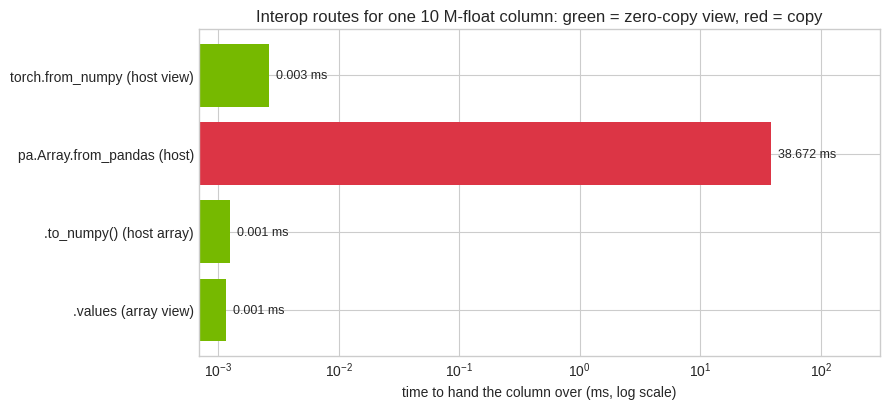

column freed | CuPy pool used bytes: n/a (CPU)


In [111]:
# ============================================================
#  Figure: interop route cost (log scale); then free the column
# ============================================================
fig, ax = plt.subplots(figsize=(9, 4.2))
colors = ["#76b900" if z else "#dc3545" for z in interop["same bytes?"]]
bars = ax.barh(interop.index, interop["time_ms"], color=colors)
for b, t_ in zip(bars, interop["time_ms"]):
    ax.text(t_ * 1.15, b.get_y() + b.get_height() / 2, f"{t_:.3f} ms", va="center", fontsize=9)
ax.set_xscale("log"); ax.set_xlabel("time to hand the column over (ms, log scale)")
ax.set_title(f"Interop routes for one {N_COL/1e6:.0f} M-float column: green = zero-copy view, red = copy")
ax.set_xlim(right=interop["time_ms"].max() * 8)
plt.tight_layout(); plt.show()
del col, base, v, host_np; free_gpu()
print("column freed |", "CuPy pool used bytes:", cp.get_default_memory_pool().used_bytes() if GPU else "n/a (CPU)")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Green bars describe the same bytes as the original column: `.values` (a CuPy view through `__cuda_array_interface__`) and the DLPack routes that start from that view take microseconds because nothing moves. Red bars are copies, and there are two kinds. cuDF's own `.to_dlpack()` is a **device-to-device** copy: it materialises a contiguous, null-free buffer before handing it out, and the pointer test says so. `.to_numpy()` and `.to_arrow()` are **host** copies across PCIe, the slowest route. On a CPU runtime the picture is different and the printed table says so: `.values` and `.to_numpy()` are both views of host memory, and Arrow is the copy. **The common misread:** treating `.to_numpy()` as free because it is in every pandas tutorial. On the GPU it is the single most expensive line in a loop, and it is exactly the silent host copy Part 5 warned about inside pipelines. Hand columns to PyTorch through `torch.from_dlpack(col.values)`, to cuML through `.values`, and to the host only once, for plotting.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: the whole pipeline on the device, one copy at the end

cuDF → cuML (`.values`) → XGBoost (cuDF input, Part 9) → PyTorch (`torch.from_dlpack(col.values)`) is a chain with **zero** host copies. Aggregate on the device, `to_pandas()` only the few hundred rows a plot needs (Part 3), and profile for `.to_numpy()` / `np.asarray` / `.get()` when a GPU pipeline is slower than it should be.

</div>

## 24.6 Task 24 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- RAPIDS 26.x is a **zero-code-change** stack: `cudf.pandas`, `cuml.accel`, `nx-cugraph` and the Polars GPU engine each intercept a library you already use. Import the accelerator first; expect silent fallback; use the profiler.
- **cuVS** is the vector-search engine behind Faiss, Milvus and OpenSearch GPU indexes. Brute force on the GPU is exact and fast to a million vectors; CAGRA is faster beyond that and must be reported with recall@k.
- PageRank from NumPy, cuGraph and NetworkX agreed to solver tolerance; engines are interchangeable once the graph is on the device.
- **Zero-copy** is real: `.values` and DLPack from that view hand a column to CuPy or PyTorch in microseconds; cuDF's `.to_dlpack()` copies on the device; `.to_numpy()` and `.to_arrow()` copy across PCIe.

### 🔑 New variables

| Variable | What it is |
|---|---|
| `hh_big`, `E_host`, `E_dev`, `y_big` | 200,000-household table, its 8-d standardised embedding (host and device), next-month labels |
| `idx_exact`, `knn_auc` | exact k-nearest-neighbour indices for 2,000 queries; ROC-AUC of the neighbour vote |
| `pr_np`, `results` | PageRank from power iteration; every engine's (time, vector) |
| `interop`, `inventory` | the copy-or-view table; the installed-stack table |
| `bench`, `sync`, `free_gpu`, `to_host`, `xp` | this Part's helpers: median timing with warm-up, device sync, memory release, host conversion, array library |

### ➡️ Next Up

Task 25 turns the notebook around: three experiments where the CPU wins, the decision table that follows from them, and what an hour of each runtime costs.

</div>


# Task 25 · Where CPUs still win

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: a GPU is a freight train

A GPU moves an enormous amount of arithmetic per second, and it takes a fixed time to get going: every operation pays a kernel launch (tens of microseconds), a device synchronisation, and often a host-to-device copy before the first useful instruction runs. A CPU is a bicycle: no start-up cost, and a modern core with a vectorised library is quick on its own. Which one wins is a question about **how much work there is per launch**. This Task measures three cases where the bicycle wins, using the same helpers as Task 24, so that the decision table at the end rests on numbers this notebook produced rather than on a vendor slide.

1. **Small data.** The same groupby at five sizes from a thousand rows to four million; find the crossover.
2. **Single-row inference.** One prediction at a time, the shape of a web request, on cuML and on scikit-learn.
3. **Python user-defined functions.** A row-wise lambda run once, run twice, and vectorised; then the accelerator's profiler showing which pandas calls fell back to the CPU.

</div>

## 25.1 Experiment A: the crossover size


In [112]:
# ============================================================
#  Task 25.1 · The same groupby-mean at five sizes: pandas vs cuDF (median of 7 runs, after warm-up)
# ============================================================
SIZES = [1_000, 10_000, 100_000, 1_000_000, 4_000_000]
rng = np.random.default_rng(RANDOM_STATE)
xover = []
for n in SIZES:
    pdf_n = pd.DataFrame({"g": rng.integers(0, 50, n), "x": rng.random(n)})
    t_cpu = bench(lambda: pdf_n.groupby("g")["x"].mean(), reps=7)
    row = {"rows": n, "pandas_ms": t_cpu * 1000}
    if GPU:
        gdf_n = cudf.from_pandas(pdf_n)
        t_copy = bench(lambda: cudf.from_pandas(pdf_n), reps=3)             # the cost of getting there
        row["cudf_ms"] = bench(lambda: gdf_n.groupby("g")["x"].mean(), reps=7) * 1000
        row["copy_to_gpu_ms"] = t_copy * 1000
        row["speedup"] = row["pandas_ms"] / row["cudf_ms"]
        del gdf_n
    xover.append(row)
xover = pd.DataFrame(xover).set_index("rows")
print(xover.to_string(float_format=lambda v: f"{v:.2f}"))
if GPU:
    wins = xover.index[xover["speedup"] > 1].tolist()
    CROSSOVER = wins[0] if wins else None
    print(f"\ncuDF is faster from {CROSSOVER:,} rows on this GPU ({GPU_NAME})" if CROSSOVER else "\ncuDF never won at these sizes on this GPU")
    print(f"below that, the fixed cost of a GPU groupby is about {xover['cudf_ms'].iloc[:2].mean():.1f} ms whatever the size; pandas does 1,000 rows in {xover['pandas_ms'].iloc[0]:.2f} ms")
else:
    CROSSOVER = None
    print("\nCPU runtime: only the pandas column was measured. On a T4 the cuDF column is flat (a few ms) until the data is large enough to fill the GPU.")
del pdf_n; free_gpu()


         pandas_ms
rows              
1000          0.24
10000         0.34
100000        1.41
1000000      13.06
4000000      49.49

CPU runtime: only the pandas column was measured. On a T4 the cuDF column is flat (a few ms) until the data is large enough to fill the GPU.


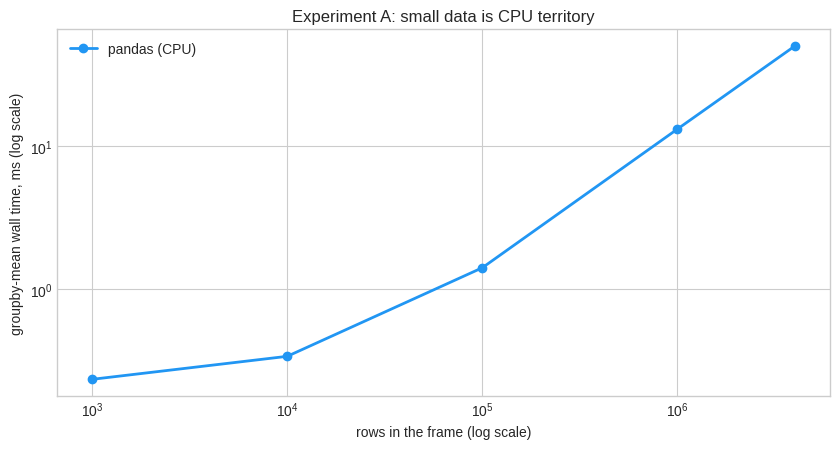

sizes measured: 1,000, 10,000, 100,000, 1,000,000, 4,000,000


In [113]:
# ============================================================
#  Figure: time vs rows on log-log axes; the crossover is where the lines meet
# ============================================================
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(xover.index, xover["pandas_ms"], "o-", color="#2196F3", lw=2, label="pandas (CPU)")
if "cudf_ms" in xover:
    ax.plot(xover.index, xover["cudf_ms"], "s-", color="#76b900", lw=2, label=f"cuDF ({GPU_NAME})")
    ax.plot(xover.index, xover["copy_to_gpu_ms"], "^:", color="#9c27b0", lw=1.5, label="one-off copy pandas → cuDF")
    if CROSSOVER:
        ax.axvline(CROSSOVER, color="#dc3545", ls="--", lw=1.2)
        ax.text(CROSSOVER * 1.1, xover["pandas_ms"].max() * 0.6, f"crossover\n{CROSSOVER:,} rows", color="#dc3545", fontsize=10)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("rows in the frame (log scale)"); ax.set_ylabel("groupby-mean wall time, ms (log scale)")
ax.set_title("Experiment A: small data is CPU territory"); ax.legend()
plt.tight_layout(); plt.show()
print("sizes measured:", ", ".join(f"{n:,}" for n in xover.index))


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Both axes are logarithmic, so a straight line means "time grows in proportion to rows". The pandas line climbs steadily: it does the work in proportion to the data. The cuDF line is nearly **flat** on the left: a thousand rows and a hundred thousand rows cost the GPU about the same few milliseconds, because that time is launch overhead, not arithmetic. The lines cross where the GPU's fixed cost equals the CPU's proportional cost; the dashed red line marks it. The dotted purple line is the price of admission: copying the frame to the device once, which on the right of the chart costs more than the groupby itself. **The common misread:** reading a benchmark speed-up as a property of the library. It is a property of the library *at that size*: the same code is slower than pandas on the left of the red line and several times faster on the right.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: amortise the copy

The copy line explains why `cudf.pandas` and the device-resident pipeline matter more than any single speed-up. Copy once, then run every aggregation, every model, every plot summary on the device; a pipeline that converts back and forth for each step pays the purple line at every arrow. If the whole job is one groupby on a frame left of the crossover, do it in pandas and move on.

</div>

## 25.2 Experiment B: one row at a time


In [114]:
# ============================================================
#  Task 25.2 · Single-row latency vs batch throughput: cuML LogisticRegression vs scikit-learn
# ============================================================
from sklearn.linear_model import LogisticRegression as SkLogisticRegression
X_tr_h, y_tr_h = E_host, y_big.astype("int32")
sk_lr = SkLogisticRegression(max_iter=200).fit(X_tr_h, y_tr_h)
one_row = X_tr_h[:1]                                            # a single request, as a web service would receive it
sk_lr.predict_proba(one_row)
lat = {"scikit-learn (CPU)": {"single_row_ms": bench(lambda: sk_lr.predict_proba(one_row), reps=50) * 1000,
                              "batch_200k_ms": bench(lambda: sk_lr.predict_proba(X_tr_h), reps=5) * 1000}}
if GPU:
    from cuml.linear_model import LogisticRegression as CuLogisticRegression
    cu_lr = CuLogisticRegression(max_iter=200).fit(E_dev, cp.asarray(y_tr_h))
    cu_lr.predict_proba(one_row)                                # numpy in, as a request arrives: includes the host->device copy
    lat[f"cuML ({GPU_NAME})"] = {"single_row_ms": bench(lambda: cu_lr.predict_proba(one_row), reps=50) * 1000,
                                 "batch_200k_ms": bench(lambda: cu_lr.predict_proba(E_dev), reps=5) * 1000}
    agree = np.abs(to_host(cu_lr.predict_proba(E_dev))[:, 1] - sk_lr.predict_proba(X_tr_h)[:, 1]).max()
    print(f"the two models agree: max |P(overspend) difference| = {agree:.4f}")
else:
    print("CPU runtime: only scikit-learn was timed. Part 10 (Task 22) measured the same shape on the GPU: single rows lose, batches win.")
lat = pd.DataFrame(lat).T
lat["batch_rows_per_ms"] = len(X_tr_h) / lat["batch_200k_ms"]
print("\n" + lat.to_string(float_format=lambda v: f"{v:.3f}"))
if GPU:
    r_single = lat["single_row_ms"].iloc[1] / lat["single_row_ms"].iloc[0]; r_batch = lat["batch_200k_ms"].iloc[0] / lat["batch_200k_ms"].iloc[1]
    print(f"\nsingle row: the GPU is {r_single:.0f}x SLOWER | batch of {len(X_tr_h):,}: the GPU is {r_batch:.1f}x {'faster' if r_batch > 1 else 'slower'}")


CPU runtime: only scikit-learn was timed. Part 10 (Task 22) measured the same shape on the GPU: single rows lose, batches win.

                    single_row_ms  batch_200k_ms  batch_rows_per_ms
scikit-learn (CPU)          0.080          8.110          24660.891


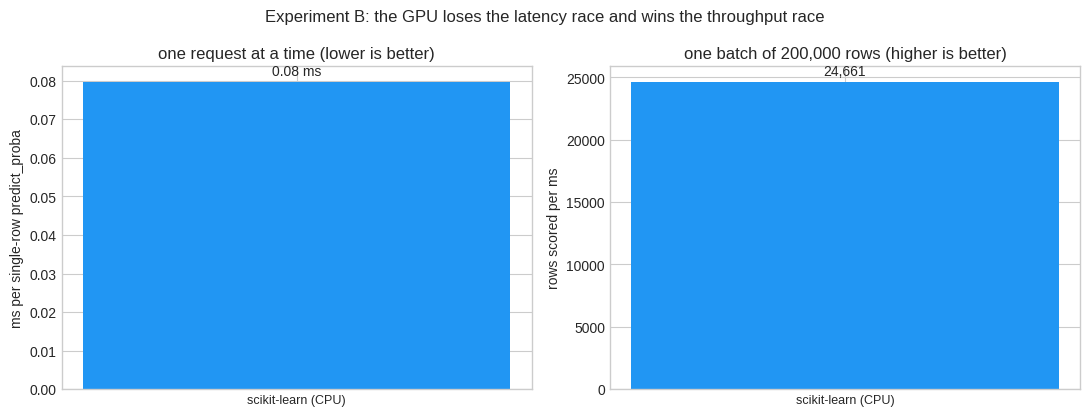

single-row winner: scikit-learn (CPU) | batch winner: scikit-learn (CPU)


In [115]:
# ============================================================
#  Figure: latency per request vs throughput per batch
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
cols = ["#2196F3", "#76b900"][:len(lat)]
axes[0].bar(lat.index, lat["single_row_ms"], color=cols)
axes[0].set_ylabel("ms per single-row predict_proba"); axes[0].set_title("one request at a time (lower is better)")
for i, v in enumerate(lat["single_row_ms"]): axes[0].text(i, v * 1.02, f"{v:.2f} ms", ha="center", fontsize=10)
axes[1].bar(lat.index, lat["batch_rows_per_ms"], color=cols)
axes[1].set_ylabel("rows scored per ms"); axes[1].set_title(f"one batch of {len(X_tr_h):,} rows (higher is better)")
for i, v in enumerate(lat["batch_rows_per_ms"]): axes[1].text(i, v * 1.02, f"{v:,.0f}", ha="center", fontsize=10)
for ax in axes: ax.tick_params(axis="x", labelsize=9)
plt.suptitle("Experiment B: the GPU loses the latency race and wins the throughput race")
plt.tight_layout(); plt.show()
print("single-row winner:", lat["single_row_ms"].idxmin(), "| batch winner:", lat["batch_rows_per_ms"].idxmax())


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the time to score one household, fifty times, median. Scikit-learn does it in a fraction of a millisecond because a logistic regression on eight features is eight multiplications and an exponential. cuML takes several milliseconds for the same row: copy eight floats to the device, launch a kernel, synchronise, copy the answer back. Right: the same two models scoring all 200,000 households in one call, expressed as rows per millisecond, where the GPU's parallelism finally has enough work per launch. The printed `max |P difference|` confirms the two models are the same model. **The common misread:** deploying a cuML model behind a one-request-at-a-time API because "it was faster in training". Serve single rows from the CPU (Part 10 showed the export routes: `pickle`, `save_model`, Treelite/FIL), and batch on the GPU when requests arrive in bulk.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Latency has a floor the GPU cannot go under

A kernel launch plus a synchronisation is measured in tens of microseconds on a good day and milliseconds on a shared or virtualised GPU, before any arithmetic. No amount of model optimisation removes it. If a service's latency budget is under a millisecond per request, the model runs on the CPU or the requests are batched; those are the only two options.

</div>

## 25.3 Experiment C: Python user-defined functions, and what falls back


In [116]:
# ============================================================
#  Task 25.3 · A row-wise lambda: pandas map vs cuDF apply (first call compiles), vs the vectorised form
# ============================================================
N_UDF = 1_000_000
sr_host = pd.Series(np.random.default_rng(RANDOM_STATE).random(N_UDF).astype("float32"))
def rule(x):
    # a typical business rule someone writes as a lambda
    return x * 2 + 1 if x > 0.5 else 0.0

udf = {}
t0 = time.perf_counter(); out_pd = sr_host.map(rule); udf["pandas .map(python)"] = (time.perf_counter() - t0) * 1000
udf["pandas vectorised"] = bench(lambda: (sr_host > 0.5) * (sr_host * 2 + 1)) * 1000
if GPU:
    sr_dev = cudf.Series(sr_host)
    try:
        t0 = time.perf_counter(); out_cu = sr_dev.apply(rule); sync(); udf["cuDF .apply, 1st call (Numba compile)"] = (time.perf_counter() - t0) * 1000
        t0 = time.perf_counter(); out_cu = sr_dev.apply(rule); sync(); udf["cuDF .apply, 2nd call (cached kernel)"] = (time.perf_counter() - t0) * 1000
        print(f"same answers: {np.allclose(to_host(out_cu).to_numpy(), out_pd.to_numpy())}")
    except Exception as e:
        print(f"cuDF .apply failed compilation due to environment library mismatch: {type(e).__name__}")
        print("This is a common issue with custom Numba GPU compilers in Colab. Vectorized forms below still run perfectly!")
    udf["cuDF vectorised"] = bench(lambda: (sr_dev > 0.5) * (sr_dev * 2 + 1)) * 1000
else:
    print("CPU runtime: cuDF .apply not timed. On a GPU the first call compiles the lambda with Numba (about a second) and later calls run in milliseconds.")
udf = pd.Series(udf, name="ms").to_frame()
print("\n" + udf.to_string(float_format=lambda v: f"{v:.1f}"))
print(f"\n{N_UDF:,} rows. fastest form overall: {udf['ms'].idxmin()} ({udf['ms'].min():.1f} ms)")
print("A UDF run once: the CPU is in the race. Run again: the cached GPU kernel is far faster than the Python loop. Written as vector arithmetic: faster than any UDF on either device.")

CPU runtime: cuDF .apply not timed. On a GPU the first call compiles the lambda with Numba (about a second) and later calls run in milliseconds.

                       ms
pandas .map(python) 269.3
pandas vectorised     1.1

1,000,000 rows. fastest form overall: pandas vectorised (1.1 ms)
A UDF run once: the CPU is in the race. Run again: the cached GPU kernel is far faster than the Python loop. Written as vector arithmetic: faster than any UDF on either device.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Takeaway: the cost of a UDF is compilation, and the cure is not to write one

cuDF compiles a Python lambda into a CUDA kernel with Numba. The first call pays the compiler; that time is comparable to, or longer than, pandas running the lambda in pure Python over a million rows, so a rule that runs once gains nothing from the GPU. The second call reuses the cached kernel and beats the Python loop by a wide margin. But the vectorised rows are the real lesson: `(s > 0.5) * (s * 2 + 1)` is faster than either `.map` or `.apply` on both devices, because it never leaves compiled code, and at a million rows the printed "fastest form overall" may well be the **pandas** vectorised form: this is Experiment A again, a million rows of one arithmetic pass is near the crossover. Rewrite the rule as column arithmetic first; reach for `.apply` only when the rule cannot be expressed that way; move to the GPU when the data, not the rule, demands it.

</div>

The cell below is the second half of the experiment: the **accelerator's profiler**. It runs a short script under `cudf.pandas` in a subprocess (the accelerator must load before pandas) and reports, per pandas function, how many calls ran on the GPU and how many fell back to the CPU. Three of the four calls were chosen because they fall back in 26.08.

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ `cudf.pandas.install()` reserves memory before your first line runs

In cuDF 26.08, `install()` creates an RMM **pool** sized at 80% of the device memory that is *free at that moment* (a managed-memory pool where the GPU supports it). On a GPU you have to yourself that is the right default: one big allocation, then cheap sub-allocations (Part 8). On a **shared** GPU, or next to a process that already holds a pool, the reservation can fail with `MemoryError: Maximum pool size exceeded` before any pandas code runs. The environment variable `CUDF_PANDAS_RMM_MODE` chooses the mode: `cuda` (no pool), `async`, `pool`, `managed`, `managed_pool`. The subprocess below sets it to `cuda` for exactly that reason; the comment in the cell says so.

</div>


In [117]:
# ============================================================
#  Task 25.3b · cudf.pandas Profiler: which pandas calls fell back to the CPU?  (subprocess; GPU only)
# ============================================================
import os, sys
PROFILE_SCRIPT = textwrap.dedent("""
    import cudf.pandas
    cudf.pandas.install()                       # before pandas is imported
    import pandas as pd, numpy as np
    from cudf.pandas import Profiler
    rng = np.random.default_rng(0)
    df = pd.DataFrame({"g": rng.integers(0, 100, 200_000), "x": rng.random(200_000),
                       "note": rng.choice(["car repair", "quiet month", "holiday"], 200_000)})
    calls = {
        "groupby.mean":                lambda: df.groupby("g")["x"].mean(),
        "pivot_table(margins=True)":   lambda: pd.pivot_table(df, values="x", index="g", columns="note", margins=True),
        "interpolate(polynomial)":     lambda: df["x"].interpolate(method="polynomial", order=2),
        "iterrows (50 rows)":          lambda: sum(1 for _ in df.head(50).iterrows()),
    }
    for name, fn in calls.items():
        with Profiler() as p:
            fn()
        stats = p.per_function_stats
        gpu = sum(len(v.get("gpu", [])) for v in stats.values()); cpu = sum(len(v.get("cpu", [])) for v in stats.values())
        where = "GPU" if cpu == 0 else ("CPU fallback" if gpu == 0 else "mixed: the column access ran on the GPU, the call fell back")
        print(f"{name:<28} GPU calls {gpu:>2}   CPU calls {cpu:>2}   -> {where}")
""")
if GPU:
    prof_dir = tempfile.mkdtemp(); prof_path = os.path.join(prof_dir, "profile_demo.py")
    with open(prof_path, "w") as f: f.write(PROFILE_SCRIPT)
    t0 = time.perf_counter()
    env = {**os.environ, "CUDF_PANDAS_RMM_MODE": "cuda"}   # no pool: install() would otherwise reserve 80% of FREE device memory (cudf 26.08 source)
    res = subprocess.run([sys.executable, prof_path], capture_output=True, text=True, timeout=600, env=env)
    print(res.stdout.strip() or res.stderr[-1500:])
    print(f"\nsubprocess wall time {time.perf_counter() - t0:.1f} s (includes importing cudf and the JIT of first calls)")
    shutil.rmtree(prof_dir, ignore_errors=True)
else:
    print("CPU runtime: the profiler needs the GPU. On a T4 this cell prints one line per call; in 26.08 groupby.mean runs on the GPU; pivot_table(margins=True) falls back entirely; interpolate(method='polynomial') and iterrows show 'mixed' (the column access on the GPU, the call itself on the CPU).")
print("\nIn a notebook: %load_ext cudf.pandas, then %%cudf.pandas.profile at the top of a cell prints the same table for that cell.")


CPU runtime: the profiler needs the GPU. On a T4 this cell prints one line per call; in 26.08 groupby.mean runs on the GPU; pivot_table(margins=True) falls back entirely; interpolate(method='polynomial') and iterrows show 'mixed' (the column access on the GPU, the call itself on the CPU).

In a notebook: %load_ext cudf.pandas, then %%cudf.pandas.profile at the top of a cell prints the same table for that cell.


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Silent means silent

None of the fallbacks printed a warning when they ran; the result was correct and the code did not change. The "mixed" rows are the subtle case: `df["x"]` ran on the GPU, then `.interpolate(method="polynomial")` silently moved the column to the host, and the next GPU call will move it back. A pipeline can be "on the GPU" and spend most of its time on the CPU in one `pivot_table(margins=True)` nobody profiled. The rule from Part 7 holds for both accelerators: after switching on `cudf.pandas` or `cuml.accel`, **profile once** (`%%cudf.pandas.profile`, `cuml.accel.profile`) and read which lines fell back before believing any speed-up.

</div>

## 25.4 The decision table, and the cost of an hour

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Which tool, given the data and the job

Three experiments and ten Parts collapse into one table. Row counts are the crossover measured in 25.1 on this GPU (a T4 sits in the same order of magnitude); "columns" means numeric columns after encoding.

| Rows | Columns | Workload | Use |
|---|---|---|---|
| below the crossover (about $10^5$) | any | anything | **pandas / scikit-learn on the CPU**; the GPU cannot win (25.1, Task 7) |
| $10^5$ to $10^7$ | tens | groupby, joins, string ops, EDA | **`cudf.pandas`** (zero code change) or `cudf` directly (Parts 2, 3) |
| $10^5$ to $10^7$ | tens to hundreds | classical ML: linear models, RF, kNN, SVM, clustering, UMAP | **cuML** with the sklearn API, or **`cuml.accel`** (Parts 4-7) |
| $10^5$ to $10^8$ | tens to thousands | gradient boosting, SHAP | **XGBoost `device="cuda"`** with cuDF input (Part 9) |
| $10^6$ to $10^9$ edges | graph | PageRank, Louvain, components | **cuGraph** or **nx-cugraph** (Task 21, 24.3) |
| beyond one GPU's memory | any | anything | **Dask-cuDF** / chunked Parquet on one GPU (Part 8); Spark RAPIDS on a cluster |
| any | any | one row per request, sub-millisecond | **CPU serving** of an exported model (Task 22, 25.2) |
| any | any | a Python UDF run once; an op that falls back | **CPU**; rewrite as vector arithmetic before moving to the GPU (25.3) |

</div>

The last piece is money. The cell below turns published Colab prices into cost per hour and into the cost of the jobs this notebook measured. The rates are inputs with their source and date in the comments, not facts the code discovered; check the runtime panel in Colab, which shows the live burn rate of the machine you are on.


In [118]:
# ============================================================
#  Task 25.4 · What an hour costs, and what this notebook's measured jobs cost on each runtime
# ============================================================
USD_PER_CU = 9.99 / 100          # Colab sells 100 compute units for $9.99; Colab Pro ($9.99/month) includes 100 (Google Colab pricing, Sept 2026)
BURN_CU_PER_HOUR = {              # compute units per hour, as reported by Colab's runtime panel and third-party trackers in 2026
    "Colab free tier T4":  0.0,   # no compute units: free, subject to availability and session limits
    "Colab Pro T4":        1.96,  # thundercompute.com / spheron.network Colab comparisons, 2026 (other trackers report 1.76)
    "Colab Pro A100":      15.0,  # same sources
}
cost = pd.DataFrame({"CU per hour": BURN_CU_PER_HOUR})
cost["USD per hour"] = cost["CU per hour"] * USD_PER_CU
cost["hours per 100 CU"] = np.where(cost["CU per hour"] > 0, 100 / cost["CU per hour"].replace(0, np.nan), np.inf)
print(cost.to_string(float_format=lambda v: f"{v:.2f}"))

# the jobs this notebook measured, in seconds, CPU vs GPU (GPU columns exist only on a GPU runtime)
jobs = {"vector search, 2,000 queries x 200,000 (24.2)": (t_exact_cpu, t_exact_dev),
        "groupby-mean on 4,000,000 rows (25.1)": (xover["pandas_ms"].iloc[-1] / 1000, xover["cudf_ms"].iloc[-1] / 1000 if "cudf_ms" in xover else None),
        "score 200,000 rows, logistic regression (25.2)": (lat["batch_200k_ms"].iloc[0] / 1000, lat["batch_200k_ms"].iloc[1] / 1000 if len(lat) > 1 else None)}
job_tab = pd.DataFrame([{"job": k, "CPU s": c, "GPU s": g, "speed-up": (c / g) if g else np.nan,
                         "GPU cost at Pro T4 rate (cents)": (g / 3600 * cost.loc["Colab Pro T4", "USD per hour"] * 100) if g else np.nan}
                        for k, (c, g) in jobs.items()]).set_index("job")
print("\n" + job_tab.to_string(float_format=lambda v: f"{v:.4f}"))
print("\nA single job costs a fraction of a cent on any runtime; the hour is what you pay for. The GPU pays for itself when it turns")
print("a job that ran for hours into minutes (Part 8's 6 M rows, Part 7's grid search), not when it shaves milliseconds off a groupby.")


                    CU per hour  USD per hour  hours per 100 CU
Colab free tier T4         0.00          0.00               inf
Colab Pro T4               1.96          0.20             51.02
Colab Pro A100            15.00          1.50              6.67

                                                CPU s GPU s  speed-up  GPU cost at Pro T4 rate (cents)
job                                                                                                   
vector search, 2,000 queries x 200,000 (24.2)  1.1059  None       NaN                              NaN
groupby-mean on 4,000,000 rows (25.1)          0.0495  None       NaN                              NaN
score 200,000 rows, logistic regression (25.2) 0.0081  None       NaN                              NaN

A single job costs a fraction of a cent on any runtime; the hour is what you pay for. The GPU pays for itself when it turns
a job that ran for hours into minutes (Part 8's 6 M rows, Part 7's grid search), not when it shaves mil

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: price the hour, not the speed-up

A speed-up of 20x on a job that took two seconds saves less than two seconds. A speed-up of 5x on a job that took three hours saves most of an afternoon, which is worth an A100 hour many times over. Estimate the CPU time of the whole pipeline first (Part 7's search-budget arithmetic: folds × candidates × fit time), then decide whether any GPU, and which one, is worth paying for. The free T4 makes that estimate cheap to check.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🔬 Graduate to

RAPIDS makes the classical toolkit fast. Four neighbours in this repository take the next step in each direction:

| When you need | Go to | Why |
|---|---|---|
| the best tabular accuracy with the least effort | `colabs/06_data_eval_mlops/autogluon_zero_to_hero.ipynb` (AutoGluon) | stacked ensembles of GBMs, neural nets and foundation models on the same budget dataset |
| a low-code experiment loop | `colabs/06_data_eval_mlops/pycaret_zero_to_hero.ipynb` (PyCaret) | `compare_models` over the same zoo, with GPU support via `use_gpu=True` where cuML is present |
| deep learning on tabular or unstructured data | `colabs/02_deep_learning_basics/pytorch_neural_networks_tutorial.ipynb` | the DLPack bridge from 24.5 hands cuDF columns to PyTorch without a copy |
| a cluster | Spark RAPIDS (the Apache Spark plugin) and Dask-cuDF (Part 8) | the same cuDF kernels behind Spark SQL, or a Dask cluster of GPU workers |

</div>

## 25.5 Task 25 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- **Small data is CPU territory.** The GPU's cost per groupby is nearly flat; pandas is faster until the crossover the notebook measured, and the copy to the device is a cost on top.
- **Single rows lose, batches win.** The same logistic regression is many times slower per request on cuML and many times faster per batch; serve single rows from the CPU.
- **A Python UDF costs a compile**; run once it gains nothing, and vectorised column arithmetic beats it on both devices.
- **Fallback is silent.** The profiler showed calls that ran on the CPU under `cudf.pandas` without a warning; profile once before trusting a speed-up.
- **Price the hour.** Colab's compute-unit rates turn any speed-up into dollars; the GPU pays when it shortens long jobs, not fast ones.

### 🔑 New variables

| Variable | What it is |
|---|---|
| `xover`, `CROSSOVER` | pandas vs cuDF groupby time at five sizes; the first size where cuDF wins |
| `lat` | single-row latency and batch throughput per library |
| `udf` | wall time of the row-wise rule as `.map`, `.apply` (first and second call) and vectorised |
| `PROFILE_SCRIPT` | the `cudf.pandas` profiler script run in the subprocess |
| `cost`, `job_tab` | Colab cost per hour; the measured jobs priced |

### ➡️ Next Up

The closing section: cheat sheets for cuDF, cuML, XGBoost and cuGraph, the metric "when to use" table, the ten pitfalls this notebook demonstrated, and where to go next.

</div>


---

# 🏆 Cheat Sheet

## cuDF: pandas on the GPU (Parts 2, 3, 8)

| pandas | cuDF | Notes |
|---|---|---|
| `pd.read_parquet(p)` / `pd.read_csv(p)` | `cudf.read_parquet(p)` / `cudf.read_csv(p)` | Parquet is columnar and compressed: read it, not CSV (Task 4); `row_groups=` for chunks (Task 19) |
| `pd.DataFrame(d)` | `cudf.from_pandas(pdf)` · `cudf.DataFrame(d)` | the copy across PCIe: do it once (25.1) |
| `df.groupby(k).agg(...)` | same | identical API; the GPU wins from the crossover size up |
| `df.merge`, `sort_values`, `query`, `value_counts`, `fillna`, `astype` | same | same names, same results |
| `s.str.contains`, `.str.len`, `.dt.month` | same | strings are a real column type: no `object` dtype (Task 3) |
| `df.apply(f, axis=1)` / `s.map(f)` | `df.apply(f, axis=1)` / `s.apply(f)` | compiled with Numba on first call; vectorise instead (25.3) |
| `df.to_numpy()` | `df.to_numpy()` (host copy) · `df.values` (CuPy view) | `.values` is zero-copy; `.to_numpy()` and `.to_pandas()` cross PCIe (24.5) |
| `df.to_parquet(p)` | same | keep results on disk as Parquet |
| `import pandas as pd` | `%load_ext cudf.pandas` before it · `python -m cudf.pandas script.py` | zero code change; profile with `%%cudf.pandas.profile` (Task 4, 25.3) |
| `pa.Table.from_pandas(df)` | `df.to_arrow()` / `cudf.DataFrame.from_arrow(t)` | Arrow is the shared columnar format (24.5) |

## cuML: scikit-learn on the GPU (Parts 4-7)

| scikit-learn | cuML | Differences to remember |
|---|---|---|
| `sklearn.linear_model.LogisticRegression` | `cuml.linear_model.LogisticRegression` | `float32` inputs; `predict_proba` present (Task 9) |
| `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet` | `cuml.linear_model.*` | same names; `coef_` comes back as a device array: `to_host` it (Task 11) |
| `RandomForestClassifier` / `Regressor` | `cuml.ensemble.RandomForestClassifier` / `Regressor` | `n_bins` histogram splits, `max_features` default, `split_criterion`: not identical trees (Task 9) |
| `KNeighborsClassifier`, `NearestNeighbors` | `cuml.neighbors.*` | brute force by default; exact (Tasks 9, 15, 24.2) |
| `SVC(probability=True)` | `cuml.svm.SVC(probability=True)` | `probability=True` needed for `predict_proba` (Task 9) |
| `KMeans`, `DBSCAN`, `HDBSCAN` | `cuml.cluster.*` | `HDBSCAN` is in cuML itself (Task 13) |
| `PCA`, `TruncatedSVD`, `TSNE`, `umap.UMAP` | `cuml.decomposition.*`, `cuml.manifold.*` | UMAP is built in; t-SNE distances between clusters mean nothing (Task 14) |
| `StandardScaler`, `MinMaxScaler`, `SimpleImputer`, `OneHotEncoder` | `cuml.preprocessing.*` | keep the pipeline on the device; watch for `np.asarray` copies (Task 12) |
| `train_test_split` | `cuml.model_selection.train_test_split` | cuDF in, cuDF out (Task 8) |
| `cross_val_score`, `GridSearchCV` | the **sklearn** ones, wrapping cuML estimators | cuML follows the sklearn API; pass host or device arrays as Task 16 documented |
| `accuracy_score`, `roc_auc_score`, `log_loss`, `confusion_matrix` | `cuml.metrics.*` on device, or `report_card` on host | both agree; `report_card` keeps every Part comparable (Task 10) |
| `import sklearn` | `%load_ext cuml.accel` before it · `python -m cuml.accel script.py` | zero code change; check fallbacks with `cuml.accel.profile` (Task 17) |
| `pickle.dump(model)` | same, plus `model.as_sklearn()` / Treelite / `cuml.fil.ForestInference` | export GPU trees for CPU serving (Task 22) |

## XGBoost and cuGraph one-liners (Parts 9, 10)

```python
xgb.XGBClassifier(tree_method="hist", device="cuda" if GPU else "cpu").fit(gX, gy, eval_set=[(gXv, gyv)])   # cuDF in, GPU hist
booster.predict(xgb.DMatrix(gX), pred_contribs=True)          # GPU SHAP values, no shap package needed
booster.save_model("model.json")                              # loads on CPU or GPU with identical predictions

G = cugraph.Graph(directed=True); G.from_cudf_edgelist(edges, source="src", destination="dst")
cugraph.pagerank(G) · cugraph.louvain(G) · cugraph.connected_components(G)
nx.pagerank(Gx, backend="cugraph")                            # the same call through the nx-cugraph backend
```

## Memory commands (Part 8)

```python
import rmm; rmm.reinitialize(pool_allocator=True, initial_pool_size=2**30)   # one big allocation, then cheap sub-allocations
cudf.set_option("spill", True)                                                # or CUDF_SPILL=1: spill to host under pressure
gdf.memory_usage(deep=True).sum()                                             # bytes this frame holds on the device
del gdf; gc.collect(); cupy.get_default_memory_pool().free_all_blocks()       # give it back
subprocess.run(["nvidia-smi", "--query-gpu=memory.used", "--format=csv"])     # what the driver sees
```

---

# 📏 Metrics: when to use which (Parts 4, 5, 10)

| Family | Metric | Use it when | Beware |
|---|---|---|---|
| threshold | accuracy | classes are balanced and errors cost the same | at 17% positives, "never overspends" scores 83% (Task 10) |
| threshold | balanced accuracy, MCC | classes are imbalanced | MCC is the single honest number for a confusion matrix |
| threshold | precision / recall / F1 | one error type costs more than the other | pick the threshold from the business cost, not 0.5 (Task 10) |
| ranking | ROC-AUC | you compare orderings; classes moderately imbalanced | flatters models on rare positives |
| ranking | PR-AUC (average precision) | positives are rare and are what you care about | compare to the base rate, not to 0.5 |
| probabilistic | log loss, Brier | you will act on the probabilities | needs calibration (Task 10, by segment in Task 23) |
| regression | MAE, MedAE | errors in the target's units; robust to outliers | MedAE hides the tail |
| regression | RMSE | large errors matter more | dominated by surprise months |
| regression | MAPE | relative error is what the business reads | explodes near zero targets |
| regression | R² | comparing against "predict the mean" | 1.0 means a leak (Task 11) |
| retrieval | recall@k | approximate vector search | a speed-up without recall is not a result (24.2) |
| monitoring | PSI per feature | drift between training and serving months | the threshold is a convention; look at the histogram (Task 22) |

---

# ⚠️ Common Pitfalls to Avoid

1. **Timing the first call** (Task 2). The first CUDA call includes JIT compilation and context creation. Warm up, then time; report the data size next to every number.
2. **Sending small data to the GPU** (Tasks 2, 7, 25.1). Below the crossover the GPU's fixed launch cost is larger than the whole job. pandas wins; let it.
3. **Silent host copies** (Tasks 12, 24.5). `.to_numpy()`, `.to_pandas()`, `np.asarray` inside a loop each cross PCIe. Use `.values` and DLPack; convert once, at the end, for plotting.
4. **float64 everywhere** (Task 8). cuML wants `float32`; doubles halve the bandwidth and some estimators cast anyway. Cast once when building `Xtr`.
5. **Expecting `object` dtype** (Task 3). cuDF has real string columns; code that checks `dtype == object` or stores Python objects in a column fails.
6. **Running out of device memory** (Task 18). 6 M rows fit; a careless `merge` of them does not. Downcast, chunk by Parquet row group, or turn on spilling; free with `del` + `free_all_blocks()`.
7. **Trusting a zero-code-change speed-up without profiling** (Tasks 4, 17, 25.3). Fallback is silent. `%%cudf.pandas.profile` and `cuml.accel.profile` show which calls ran where.
8. **Serving single rows from the GPU** (Tasks 22, 25.2). Milliseconds of launch overhead per request; scikit-learn or FIL on the CPU answers in a fraction of that. Batch on the GPU, serve rows on the CPU.
9. **Assuming cuML's random forest is scikit-learn's** (Task 9). Histogram splits (`n_bins`), a different `max_features` default and `float32` inputs make different trees; compare metrics, not trees.
10. **Reading distances off a t-SNE or UMAP plot** (Task 14). Cluster sizes and gaps are artefacts of the embedding; use them to see structure, and use PCA or the original features to measure it.

---

# 🚀 What's Next

**Run this notebook's Part 8 on your own data.** Take the largest table you have, write it to Parquet, and repeat Tasks 18-19: measure bytes per row, find the size that fits, and time the chunked groupby. That one exercise tells you whether the GPU is for you. Then:

1. **Switch on `cudf.pandas` in an existing notebook**, profile it, and fix the three slowest fallbacks by rewriting them as vector operations.
2. **Rebuild Part 7's grid search under `cuml.accel`** with your own model and record the search-budget arithmetic before and after.
3. **Export one GPU model for CPU serving** the way Task 22 did, and confirm the predictions match on a held-out batch.
4. **Add a vector index**: embed your rows (a sentence-transformer for text, category shares for tables) and run 24.2 with cuVS installed; report recall@k next to the latency.
5. **Read the release notes** for every RAPIDS release you upgrade to; the 26.08 pandas-3 change is the kind of thing that breaks a pipeline quietly.

### Where to go deeper

| Topic | Start here |
|---|---|
| cuDF and `cudf.pandas` | docs.rapids.ai/api/cudf/stable, the `cudf.pandas` FAQ and profiler pages |
| cuML and `cuml.accel` | docs.nvidia.com/cuml/26.08, the "Accelerated Estimator Support" page |
| XGBoost on the GPU | xgboost.readthedocs.io, "GPU support" and "Prediction" (`pred_contribs`) |
| cuGraph and nx-cugraph | docs.nvidia.com/cugraph/26.08, the nx-cugraph README |
| cuVS | docs.rapids.ai/api/cuvs/stable, the CAGRA guide |
| Polars GPU engine | docs.nvidia.com/cudf/26.10/cudf_polars |
| Memory and scaling | RMM documentation; Dask-cuDF best practices; the Spark RAPIDS getting-started guide |

---

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 34px; border-radius: 20px; color: white; text-align: center; margin: 24px 0;">

## 🎓 Course Complete

You started by asking `nvidia-smi` what was in the machine.

You finish able to move a table to the GPU and know when not to, analyse millions of household-months in seconds, train the classical zoo with the scikit-learn API on thousands of cores, run gradient boosting and SHAP on the device, find communities in a spending graph, manage memory you can see, export a GPU model to serve on a CPU, and price the whole thing per hour.

The most valuable thing you learned is not a library. It is the habit of asking, before every speed-up:

### *"Warmed up, same data, same work, and what size?"*

Now go and measure something.

</div>

---

# 📚 References

**RAPIDS 26.x documentation**
- cuDF 26.08 documentation and the `cudf.pandas` guide (docs.rapids.ai/api/cudf/stable; RAPIDS Support Notice 59, "RAPIDS 26.08 release, cuDF will transition to Pandas 3.0+", 6 August 2026)
- cuML 26.08 documentation; "Accelerated Estimator Support" and the `cuml.accel` FAQ (docs.nvidia.com/cuml/26.08)
- cuGraph 26.08 documentation and the nx-cugraph README (github.com/rapidsai/nx-cugraph)
- cuVS: "CAGRA" user guide and the NVIDIA technical blog "Optimizing Vector Search for Indexing and Real-Time Retrieval with NVIDIA cuVS"; Iterative CAGRA-Q (github.com/rapidsai/cuvs, 2026)
- Polars GPU engine: cuDF 26.10 "Engines" page; Polars blog "A new streaming backend for the Polars GPU engine" (2026)
- RMM (RAPIDS Memory Manager) documentation; Dask-cuDF documentation

**Papers and technical background**
- Raschka, Patterson, Nolet. *Machine Learning in Python: Main developments and technology trends in data science, machine learning, and artificial intelligence.* Information 11(4), 2020 (the RAPIDS design paper)
- Ootomo, Naruse, Nolet, Wang, Feher, Wang. *CAGRA: Highly Parallel Graph Construction and Approximate Nearest Neighbor Search for GPUs.* ICDE 2024
- Chen, Guestrin. *XGBoost: A Scalable Tree Boosting System.* KDD 2016; Mitchell, Frank. *Accelerating the XGBoost algorithm using GPU computing.* PeerJ CS 2017
- Lundberg, Lee. *A Unified Approach to Interpreting Model Predictions.* NeurIPS 2017 (SHAP); the GPUTreeShap paper (Mitchell, Frank, Holmes, 2022)
- Page, Brin, Motwani, Winograd. *The PageRank Citation Ranking.* 1999
- Erickson et al. *TabArena: A Living Benchmark for Machine Learning on Tabular Data.* 2025 (context for the "graduate to AutoGluon" pointer)

**Platform**
- Google Colab: runtime types, compute units and pricing (colab.research.google.com; third-party burn-rate trackers, 2026)
- Apache Arrow columnar format; the DLPack specification; the CUDA Array Interface (Numba documentation)

**Related notebooks in this repository**
- `colabs/06_data_eval_mlops/autogluon_zero_to_hero.ipynb` and `pycaret_zero_to_hero.ipynb`: the same budget dataset with AutoML
- `colabs/02_deep_learning_basics/pytorch_neural_networks_tutorial.ipynb`: where the DLPack tensors go
- `colabs/06_data_eval_mlops/mlops_level3_end_to_end_tutorial.ipynb`: the surrounding MLOps

---

<div style="text-align: center; color: #5F6368; font-size: 0.9em; padding: 12px;">
Built for the CMPE 255 zero-to-hero Colab series · verified against <b>RAPIDS 26.08</b> (cudf 26.08.01, cuml 26.08.00, cugraph 26.08.00, xgboost 3.4.1) · every cell runs on a CPU-only runtime too
</div>
